# 025. ANN 検索とリランキング / ANN Search and Reranking

## 1. 概要 / Overview

**近似最近傍探索(ANN: Approximate Nearest Neighbor)** は、全探索のように全ベクトルとの距離を計算せず、query に近いベクトルを少ない距離計算で見つける手法である。
recall(全探索の上位との一致率)を少し手放す代わりに、**1 query あたりの距離計算の回数(費用)** を大きく減らす、という交換を扱う。
本トピックは、024 の dual encoder が埋め込んだ約 9.4 万個の passage を対象に、HNSW(Hierarchical Navigable Small World)・転置ファイル(Inverted File Index)・
Product Quantization(直積量子化)をスクラッチ実装し、費用と recall の関係を測る。さらに、第 1 段(上記の索引)が絞り込んだ上位の候補を、query と passage を連結して符号化する
**cross-encoder** で並べ替える 2 段階の検索(retrieve-then-rerank)を、008 の小型 GPT を起点に実装する。

検証するのは次の 5 つである(いずれも判定つき)。(A)HNSW が目標の recall に達するための費用の、件数 $N$ に対するべき指数が 1 より小さいか、(B)最大の $N$ で、HNSW の費用が転置ファイルより小さいか、
(C)同じ符号帳で、Product Quantization の非対称距離計算(Asymmetric Distance Computation)が対称距離計算(Symmetric Distance Computation)より recall が高いか、
(D)起点・学習データ・負例・損失の形・学習ステップ数を揃えたとき、cross-encoder による並べ替えが dual encoder による並べ替えより検索指標が高いか、(E)第 1 段の上位から採掘した困難な負例で学習した
cross-encoder が、ランダムな負例で学習した cross-encoder より、並べ替えの検索指標が高いか。あわせて、判定を設けない観察として、(F)第 1 段を全探索・HNSW・転置ファイル・Product Quantization
(再採点あり・なし)に替えたときの 2 段階の検索の検索指標と費用を示す。

### 1.1 実行の手順

本番実行は Google Colab T4 の **1 つのセッションで完結** させる。5.1 節のセットアップセルで`SMOKE_TEST = False`にして、「すべてのセルを実行」する。

実行時間の予算は 1 セッションあたり **T4 で 120 分** とする。索引の構築と学習を始める前に(6.3 節)、実行するデバイスの上でスケーリングの計測を行い、**実行計画**(6.1 節。学習ステップ数 $T$・
HNSW・転置ファイル・Product Quantization の索引の最大の件数 $N_{\max}$・各実験のシード数の組)のそれぞれについて残りの実行時間を見積もり(6.4 節)、
予算に収まる計画のうち優先順位の最も高いものを自動で選ぶ。選択は見積もりのみに基づき、どの実験の結果も参照しない。**選ばれた計画は 6.4 節の出力に印字される。**
事前の計測のための実行やセッションの分割はしない。**見積もりが最も下位の計画でも予算を超える場合は、索引の構築と学習の前に停止する。**

学習したモデルのうち、後続の RAG アプリ(`apps/`)の入力にする **困難な負例で学習した cross-encoder(D1)のシード 0** だけを Hugging Face Hub
(`kojikojiprg/ai-theories-cross-encoder-en`)にアップロードする(6.16 節。`UPLOAD_ARTIFACTS`が`True`で、かつ読み込み直した重みの Recall@10 が並べ替えなしを上回るときだけ。既定は`False`)。索引・埋め込み・他の条件のモデルは保存もアップロードもしない。

### 1.2 本番実行の結果の要約

本番実行の前の状態(第 1 段階の完了状態)である。本番の結果は 7 節に、本番の実行の後に記す。この節には、本番の実行の後に次の内容を書く。

- 実行環境・選ばれた計画・全体の実行時間
- 前提条件の成否
- 実験 A〜E の対比量・標準偏差・閾値・最終判定(表)と、各実験の一文の要約
- 観察 F の要約
- アップロードの結果

**本番実行の後に更新が必要な箇所**(第 1 段階の完了状態では未更新):

- 5.1 節のセルの`SMOKE_TEST`を`False`に、`REQUIRED_ANCESTOR_COMMIT`を第 1 段階の完了(または追加の修正)を含むコミットに設定して実行する。アップロードは`UPLOAD_ARTIFACTS = True`で別途行う(6.16 節)。
- 5.2 節以降のセル出力(スモークテストの値)は、本番の実行で置き換わる。**スモークテストの数値は、結果・考察に使わない。**
- 本節(1.2 節)の要約と、7 節の各見出しの本文(7.1〜7.12 節。本番のセル出力の数値と突き合わせて書く)。
- 6.2.6 節の並べ替えモデルの学習のパイロットの値と、本番の学習の成立の成分((a)(b))・学習率の較正の結果(格子の端に来た場合など)との対応。
- `theories/README.md`の 025 の行(本番の結果の要約を加える)。

## 2. 参考論文 / References

1. Malkov, Yu. A., Yashunin, D. A.,
   "Efficient and robust approximate nearest neighbor search using Hierarchical Navigable Small World graphs", IEEE TPAMI 42(4), 2020(arXiv:1603.09320, DOI 10.1109/TPAMI.2018.2889473).
   https://arxiv.org/abs/1603.09320(HNSW。層の番号の分布、挿入と探索のアルゴリズム(Algorithm 1〜5)、近傍の選択のヒューリスティック、計算量の議論。3.3 節、実験 A・B)
2. Malkov, Y., Ponomarenko, A., Logvinov, A., Krylov, V.,
   "Approximate nearest neighbor algorithm based on navigable small world graphs", Information Systems 45, 61–68, 2014. https://doi.org/10.1016/j.is.2013.10.006
   (Navigable Small World。階層を持たない 1 層のグラフ。HNSW の前身。3.3 節)
3. Jégou, H., Douze, M., Schmid, C.,
   "Product Quantization for Nearest Neighbor Search", IEEE TPAMI 33(1), 117–128, 2011. https://doi.org/10.1109/TPAMI.2010.57
   (Product Quantization、非対称距離計算と対称距離計算、転置ファイルとの組み合わせ(IVFADC: Inverted File with Asymmetric Distance Computation)。3.2・3.4 節、実験 C)
4. Kleinberg, J.,
   "The small-world phenomenon: an algorithmic perspective", STOC 2000, pp. 163–170. https://www.cs.cornell.edu/home/kleinber/swn.d/swn.html
   (small world のグラフ上の貪欲な経路探索が、どのようなグラフで有効になるか。3.3 節)
5. Sivic, J., Zisserman, A.,
   "Video Google: A Text Retrieval Approach to Object Matching in Videos", ICCV 2003. https://doi.org/10.1109/ICCV.2003.1238663
   (ベクトル量子化と転置ファイルによる検索。転置ファイルの考え方の出典の 1 つ。3.2 節)
6. Lloyd, S. P.,
   "Least squares quantization in PCM", IEEE Transactions on Information Theory 28(2), 129–137, 1982. https://doi.org/10.1109/TIT.1982.1056489
   (Lloyd のアルゴリズム(k-means)。3.2 節)
7. Aumüller, M., Bernhardsson, E., Faithfull, A.,
   "ANN-Benchmarks: A Benchmarking Tool for Approximate Nearest Neighbor Algorithms", Information Systems 87, 101374, 2020(オンライン公開は 2019 年。arXiv:1807.05614).
   https://arxiv.org/abs/1807.05614(recall と費用の曲線で索引を比べる評価の方法。3.9 節)
8. Lin, P.-C., Zhao, W.-L.,
   "Graph based Nearest Neighbor Search: Promises and Failures", arXiv:1904.02077, 2019. https://arxiv.org/abs/1904.02077
   (高次元のデータで、階層が対数の計算量をもたらさず、階層を持たない近傍グラフと同程度の性能になることの報告。3.3 節、実験 A の診断量)
9. Munyampirwa, B., Lakshman, V., Coleman, B.,
   "Down with the Hierarchy: The 'H' in HNSW Stands for 'Hubs'", arXiv:2412.01940, 2024. https://arxiv.org/abs/2412.01940
   (高次元のデータでは、階層を持たない近傍グラフが HNSW の利点を保つこと、ハブとなる頂点が階層の代わりをしているという報告。3.3 節、実験 A の診断量)
10. Nogueira, R., Cho, K.,
    "Passage Re-ranking with BERT", arXiv:1901.04085, 2019. https://arxiv.org/abs/1901.04085
    (cross-encoder による passage の並べ替え。3.5 節、実験 D)
11. Ma, X., Wang, L., Yang, N., Wei, F., Lin, J.,
    "Fine-Tuning LLaMA for Multi-Stage Text Retrieval", SIGIR 2024(arXiv:2310.08319). https://arxiv.org/abs/2310.08319
    (decoder-only の大規模言語モデルを、終端のトークンの位置の出力から並べ替えのスコアを出す reranker(RankLLaMA)に転用する。3.5 節)
12. Karpukhin, V., Oğuz, B., Min, S., Lewis, P., Wu, L., Edunov, S., Chen, D., Yih, W.,
    "Dense Passage Retrieval for Open-Domain Question Answering", EMNLP 2020. https://arxiv.org/abs/2004.04906
    (BM25 で採掘した困難な負例。024 の 3.6 節。3.7 節)
13. Xiong, L., Xiong, C., Li, Y., Tang, K.-F., Liu, J., Bennett, P., Ahmed, J., Overwijk, A.,
    "Approximate Nearest Neighbor Negative Contrastive Learning for Dense Text Retrieval", ICLR 2021. https://arxiv.org/abs/2007.00808
    (学習時の負例が、検索時に出会う無関係な文書の分布を代表していないことが問題であり、近似最近傍探索の索引で採掘した負例で学習する。3.7 節、実験 E)
14. Qu, Y., Ding, Y., Liu, J., Liu, K., Ren, R., Zhao, W. X., Dong, D., Wu, H., Wang, H.,
    "RocketQA: An Optimized Training Approach to Dense Passage Retrieval for Open-Domain Question Answering", NAACL 2021. https://arxiv.org/abs/2010.08191
    (採掘した困難な負例に、実際には正解である偽の負例が混ざる問題と、その除去。3.7 節、位置づけのみ)
15. Indyk, P., Motwani, R.,
    "Approximate nearest neighbors: towards removing the curse of dimensionality", STOC 1998, pp. 604–613(統合した版: Har-Peled, S., Indyk, P., Motwani, R., Theory of Computing 8(14), 2012).
    https://theoryofcomputing.org/articles/v008a014/(近似を許すと検索時間を件数に対して劣線形にできること。locality sensitive hashing。3.1 節。位置づけのみ)
16. Johnson, J., Douze, M., Jégou, H.,
    "Billion-scale similarity search with GPUs", IEEE Transactions on Big Data 7(3), 535–547(arXiv:1702.08734). https://arxiv.org/abs/1702.08734
    (Faiss。転置ファイルと Product Quantization の実装の代表例。3.2・3.4 節。位置づけのみ)
17. Guo, R., Sun, P., Lindgren, E., Geng, Q., Simcha, D., Chern, F., Kumar, S.,
    "Accelerating Large-Scale Inference with Anisotropic Vector Quantization", ICML 2020(arXiv:1908.10396). https://arxiv.org/abs/1908.10396
    (ScaNN。量子化の損失を内積の順位に合わせて設計する。3.8 節。位置づけのみ)
18. Subramanya, S. J., Devvrit, Kadekodi, R., Krishnaswamy, R., Simhadri, H. V.,
    "DiskANN: Fast Accurate Billion-point Nearest Neighbor Search on a Single Node", NeurIPS 2019. https://papers.nips.cc/paper/2019/hash/09853c7fb1d3f8ee67a61b6bf4a7f8e6-Abstract.html
    (ディスク上に置いた近傍グラフによる探索。3.8 節。位置づけのみ)
19. Ge, T., He, K., Ke, Q., Sun, J.,
    "Optimized Product Quantization", IEEE TPAMI 36(4), 744–755, 2014(CVPR 2013 の拡張)。https://www.microsoft.com/en-us/research/publication/optimized-product-quantization/
    (部分空間の分け方を最適化する Product Quantization。3.8 節。位置づけのみ)
20. Khattab, O., Zaharia, M.,
    "ColBERT: Efficient and Effective Passage Search via Contextualized Late Interaction over BERT", SIGIR 2020. https://arxiv.org/abs/2004.12832
    (late interaction。024 の参考論文 16。3.5 節。位置づけのみ)
21. Hofstätter, S., Althammer, S., Schröder, M., Sertkan, M., Hanbury, A.,
    "Improving Efficient Neural Ranking Models with Cross-Architecture Knowledge Distillation", arXiv:2010.02666, 2020. https://arxiv.org/abs/2010.02666
    (cross-encoder から dual encoder への知識蒸留。3.8 節。位置づけのみ)

本文で用いる既存トピックの部品: 小型 GPT と bits-per-byte は [006](../02_pretraining/006_pretraining_small_gpt.ipynb)、AdamW・warmup + cosine・gradient clipping は
[007](../02_pretraining/007_training_stabilization.ipynb)、本トピックが起点にする学習済みの小型 GPT は [008](../02_pretraining/008_decoding_strategies.ipynb)、FP16 の autocast と動的損失スケーリングは
[011](../03_efficient_training/011_mixed_precision_training.ipynb)、スカラー量子化(一様量子化)は [013](../03_efficient_training/013_quantization_basics.ipynb)、
記事を単位とするクラスタブートストラップは [015](../03_efficient_training/015_long_context_extension.ipynb)、報酬モデルのスカラーのヘッドは [017](../04_alignment/017_reward_model_and_rlhf.ipynb)、
dual encoder・InfoNCE 損失・Matryoshka Representation Learning・評価用の索引と query・Recall@10 は [024](./024_text_embedding_and_retriever.ipynb) で扱った。

## 3. 理論 / Theory

### 3.1 動機: 全探索の計算量と、近似の考え方

**全探索(exhaustive search)** は、query $x$ と全ベクトル $y_1, \dots, y_N \in \mathbb{R}^d$ との距離(または類似度)をすべて計算して、上位 $k$ 件を返す。
1 本のベクトルとの距離計算が $O(d)$ なので、1 query あたりの計算量は

$$
O(N d)
$$

である($N$ は索引のベクトルの数、$d$ は次元)。本トピックでは **1 本のベクトルとの距離(内積)の計算を 1 回と数え**、全探索の費用を $N$ 回とする。

**単位ベクトルでは、3 つの尺度の順位が一致する。** $x$ と $y$ が単位ベクトル($\lVert x \rVert = \lVert y \rVert = 1$)のとき、

$$
\lVert x - y \rVert^2 = \lVert x \rVert^2 - 2 x^\top y + \lVert y \rVert^2 = 2 - 2 x^\top y
$$

となる。したがって、二乗ユークリッド距離は内積(= コサイン類似度)の減少関数で、**cosine 類似度・内積・二乗ユークリッド距離は、どれも同じ順位を与える**。024 の埋め込みは L2 正規化した単位ベクトルなので、
以下の索引はどの尺度を使っても同じ最近傍を探す。

**近似最近傍探索の考え方**: 次元が高いと、木構造などの厳密な探索法も全探索とほぼ同じ費用になる(次元の呪い)。Indyk & Motwani [15] は、真の最近傍でなくてよい(近似を許す)
とすると、検索時間を $N$ に対して劣線形にできることを示した。実用の索引は、**真の上位 $k$ 件のうち返せた割合(recall)を手放す代わりに、距離計算の回数を減らす**。
探索の幅や探索するリストの数を増やすと、recall も費用も増える。索引どうしの比較は、**同じ recall を達成するときの費用** で行う(3.9 節、ANN-Benchmarks [7] の考え方)。

本トピックで扱う 3 つの方式は、費用を減らす方法が異なる。

| 方式 | 減らし方 | 近似の源 |
|---|---|---|
| 転置ファイル(3.2 節) | query に近いクラスタのベクトルだけを走査する | 近いベクトルが別のクラスタに入る |
| HNSW(3.3 節) | 近傍グラフをたどって、query に近い部分だけを訪れる | 局所最適にはまり、真の近傍を訪れない |
| Product Quantization(3.4 節) | ベクトルを短い符号に圧縮し、距離を表引きで近似する | 量子化の誤差で順位が乱れる |

転置ファイルと HNSW は **走査するベクトルを減らす**(距離は正確に計算する)方式、Product Quantization は **1 本あたりの距離の計算を安くする**(全ベクトルを走査するが、距離は近似する)方式である。

### 3.2 転置ファイル(Inverted File Index)

**考え方**: 全ベクトルを k-means で $K$ 個のクラスタ(Voronoi 領域)に分け、クラスタごとに、属するベクトルの一覧(転置リスト)を作る。query が来たら、$K$ 個の重心との距離を求め、近い順に $p$ 個のリスト
($p$ を探索するリストの数と呼ぶ)だけを走査して、その中の上位を返す。ベクトルを重心の番号で引く索引は、画像検索の Video Google(Sivic & Zisserman [5])が、テキスト検索の転置索引になぞらえて
導入し、Jégou ら [3] が Product Quantization と組み合わせた(IVFADC。3.4 節)。

**k-means(Lloyd のアルゴリズム [6])**: 点の集合 $\{x_i\}_{i=1}^{n}$ と重心の集合 $\{c_j\}_{j=1}^{K}$ について、各点を最も近い重心に割り当てたときの二乗誤差の和

$$
J = \sum_{i=1}^{n} \min_{j} \lVert x_i - c_j \rVert^2
$$

を小さくする。割り当て(各点を最も近い重心へ)と更新(各重心を割り当てられた点の平均へ)を交互に行うと、どちらの手順も $J$ を増やさないので、$J$ は反復ごとに単調に減少する。
ただし、収束先は局所最適で、初期値に依存する。本トピックでは、初期化を「点の集合から $K$ 個を重複なく選ぶ」、反復回数を 20 回に固定する(割り当てが 0 個になった重心は、割り当てた重心までの距離が最大の点に置き直す)。

**費用の式**: 各リストの大きさが平均 $N / K$ のとき、1 query あたりの距離計算の回数は

$$
C(K, p) = K + p \cdot \frac{N}{K}
$$

である。第 1 項が重心との比較、第 2 項が走査するベクトルの数である($p = K$ ですべてのリストを走査すると、全探索と同じ結果になり、費用は全探索より $K$ だけ増える)。

**リスト数を $\sqrt{N}$ に比例させると費用が $O(\sqrt{N})$ になること**: $p$ を固定して $K$ で最小化する。

$$
\frac{\partial C}{\partial K} = 1 - \frac{p N}{K^2} = 0 \;\Rightarrow\; K = \sqrt{p N}, \qquad C = 2 \sqrt{p N} = O(\sqrt{N})
$$

$K = c \sqrt{N}$($c$ は定数)とおけば $C = (c + p / c) \sqrt{N}$ で、費用は $\sqrt{N}$ で増える。重心との比較(第 1 項)と走査(第 2 項)が同じ大きさになる点が最小である。
**この導出は、目標の recall に必要な $p$ が $N$ によらず一定という仮定を置いている。** 実際には、$K$ が増えると各リストが小さくなり、近いベクトルが別のリストに入る割合が増えるので、
同じ recall に必要な $p$ は $N$ とデータに依存する(必要な $p$ が $N$ とともに増えれば、費用は $\sqrt{N}$ より速く増える)。実験 B は、$K$ を $\sqrt{N}$ の $1/2$ 倍から 8 倍までの 5 点(公比 2)で試し、
目標の recall での費用が最小のものを採用する。

```mermaid
flowchart LR
    Q["query q"] --> C["K 個の重心と比較(K 回)"]
    C --> P["近い順に p 個のリストを選ぶ"]
    P --> S["選んだリストのベクトルだけを走査(約 p N / K 回)"]
    S --> T["上位 k 件を返す"]
```

### 3.3 HNSW(Hierarchical Navigable Small World)

#### 3.3.1 small world のグラフと貪欲な探索

**近傍グラフ(proximity graph)** は、ベクトルを頂点とし、近いベクトルどうしを辺で結んだグラフである。query に対して、適当な頂点から出発し、
**隣接する頂点のうち query に最も近いものへ移る**(貪欲な探索、greedy search)を、近づけなくなるまで繰り返せば、query に近い頂点にたどり着ける。
各頂点の辺が近いベクトルだけだと、遠い頂点までのたどる回数が多くなる(辺数が少ないとき、頂点の数 $N$ に対して多項式のステップが要る)。
**small world** のグラフは、近い頂点への辺に加えて、少数の遠い頂点への辺(長距離の辺)を持ち、任意の 2 頂点の間の最短経路が短い(頂点数の対数程度)。
Kleinberg [4] は、短い経路が存在するだけでなく、**局所の情報だけで貪欲にその経路を見つけられる** のは、辺の長さの分布が特定の形のモデルに限られることを示した(navigability)。

**Navigable Small World(Malkov ら [2])** は、ベクトルを 1 つずつ挿入し、挿入のたびに、その時点のグラフから探索で見つけた近い頂点と辺を張る。
**早く挿入された頂点どうしは、その時点では少数の中で最も近い相手と結ばれる** ので、後から密になった領域では長距離の辺になる。この自然な長距離の辺により、貪欲な探索が遠くから近くへ進める。
ただし、Navigable Small World は 1 層のグラフで、探索の費用の件数への増え方が対数よりも速い(原論文の主張)。

#### 3.3.2 階層化: 層の番号を指数分布から引く

HNSW(Malkov & Yashunin [1])は、**辺の長さの尺度ごとに層を分ける**。最下層(層 0)がすべての要素を含み、上の層ほど要素が少ない(上の層の頂点の集合は下の層の部分集合)。
要素 $q$ を挿入するとき、その要素が属する最大の層の番号 $l$ を、指数分布から引く(原論文の式)。

$$
l = \lfloor -\ln(u) \cdot m_L \rfloor, \qquad u \sim \mathrm{Uniform}(0, 1), \qquad m_L = \frac{1}{\ln M}
$$

$M$ は 1 つの要素が挿入のときに張る接続の数、$m_L$ は層の番号の分布を決める正規化の係数である。**層の番号の分布**: $l \ge j$ となる確率は

$$
P(l \ge j) = P\left(-\ln u \ge \frac{j}{m_L}\right) = P\left(u \le e^{-j \ln M}\right) = M^{-j}
$$

なので、層 $j$ 以上に属する要素は $N M^{-j}$ 個程度、最上層の番号は $\log_M N$ 程度である(スキップリストの確率 $1/M$ に対応する)。原論文は $m_L = 1/\ln M$ を、層の間の頂点の重なり
(ある頂点の近傍が他の層にも属する割合)が小さく、層の数と 1 層あたりのたどる回数が釣り合う単純な選択として示す。

```mermaid
flowchart TB
    subgraph L2["層 2(要素が最も少ない)"]
        a2["入口 ep"] --> b2["query に近い頂点"]
    end
    subgraph L1["層 1"]
        b1["層 2 で見つけた頂点から出発"] --> c1["query に近い頂点"]
    end
    subgraph L0["層 0(すべての要素)"]
        c0["層 1 で見つけた頂点から出発"] --> d0["探索の幅 ef の候補を保つ探索"] --> e0["上位 k 件"]
    end
    b2 -->|"1 個だけ持ち越す(ef = 1)"| b1
    c1 -->|"1 個だけ持ち越す(ef = 1)"| c0
```

**探索(Algorithm 5)**: 最上層の入口の要素から出発し、**上の層では貪欲な探索(探索の幅 $ef = 1$)** で query に最も近い 1 つの要素を見つけ、それを次の層の入口にして降りる。
**層 0 では、探索の幅 $ef$ の候補の集合 $W$ を保ちながら探索する**(Algorithm 2)。$W$ に入っている最も遠い要素より遠い候補を捨てるので、探索は $W$ の中を改善できなくなったときに終わる。
$W$ の中の上位 $k$ 件を返す。**$ef$ を大きくすると recall が上がり、費用も増える。**

**挿入(Algorithm 1)**: 要素の層の番号 $l$ を引く。最上層から $l + 1$ 層までは $ef = 1$ の貪欲な探索で入口を更新する。層 $l$ 以下の各層では、探索の幅 $efConstruction$ の探索で見つけた候補から、
$M$ 個の近傍を選んで双方向の辺を張る。辺を張った相手の頂点の接続の数が上限 $M_{\max}$ を超えたら、その頂点の近傍を同じ選び方で選び直す(最下層の上限は $M_{\max 0} = 2M$、それ以外の層は $M_{\max} = M$。
原論文は、$M_{\max 0} = 2M$ を良い選択として示す)。

**近傍の選択のヒューリスティック(Algorithm 4)**: 単純には、候補のうち query(基準の点)に近い順の $M$ 個を選ぶ(Algorithm 3)。ヒューリスティックは、候補を基準の点に近い順に調べ、
**すでに選んだどの要素よりも基準の点に近い候補だけ** を選ぶ(候補 $e$ について、選んだ集合 $R$ のすべての要素 $r$ で $d(e, q) < d(e, r)$ が成り立つとき)。近いが同じ方向にある候補は捨てられるので、
**方向の異なる近傍が選ばれ**、クラスタの間をつなぐ辺が残りやすい。原論文は、クラスタ構造を持つデータや低次元のデータで、単純な選択より大きく改善すると報告している。

#### 3.3.3 計算量の主張と、高次元での注意

原論文は、**探索の計算量が $O(\log N)$、構築の計算量が $O(N \log N)$ でスケールする** と主張する。根拠は次の議論である: 各層で、厳密な Delaunay グラフ(近傍関係を表す最小の部分グラフ)があれば、
次の層の入口に着くまでの平均のステップ数は定数で抑えられ(層の間で要素の選ばれる確率が空間の位置と無関係なので、次の層に属する要素にたどり着く確率が $e^{-m_L}$ で一定になる)、
層の数の期待値が $\log N$ に比例するので、全体で $O(\log N)$ になる。この議論は **Delaunay グラフの平均次数が定数で抑えられるという仮定** に依存する。原論文自身が、
Delaunay グラフの平均次数は次元に対して指数的に増えるので、高次元のデータ(例: $d = 128$)でこの仮定の成立を実験で確かめるには極端に大きなデータが要り、高次元への一般化にはさらなる解析が必要だと述べている。

**高次元での階層の利得**: 階層(上の層)が高次元のデータで効くかは、後続の研究で疑問が示されている。Lin & Zhao [8] は、高次元のデータで階層が対数の計算量をもたらさず、階層を持たない近傍グラフ
(多様化した辺を持つもの)と同程度の性能になることを報告した。Munyampirwa ら [9] は、高次元のデータでは、階層を持たない近傍グラフが HNSW の利点を保つこと、
ハブ(多くの頂点から近傍として選ばれる頂点)が階層の代わりに「高速道路」の役割を果たしていることを報告した。本トピックの埋め込みは $d = 256$ の高次元なので、
**階層の効果を、最下層だけをランダムな入口から探索したときの費用との比較として診断量に併記する**(実験 A)。

**パラメータの選び方**: 原論文は、$M$ の妥当な範囲を 5〜48 とし、**小さい $M$ は低い recall や低次元のデータに、大きい $M$ は高い recall や高次元のデータに向く** と述べている。メモリは $(M_{\max 0} + m_L M_{\max})$ にリンク 1 本のバイト数を掛けた値に比例する。

### 3.4 Product Quantization(直積量子化)

**符号化**: $d$ 次元のベクトル $y$ を $m$ 個の部分ベクトル $y^1, \dots, y^m$(各 $d / m$ 次元)に分け、部分空間 $j$ ごとに、独立な k-means で $k^*$ 個の符号語(centroid)の符号帳 $C^j$ を学習する。
各部分ベクトルを、最も近い符号語の番号で表す(Jégou ら [3])。

$$
q(y) = \left( q^1(y^1), \dots, q^m(y^m) \right), \qquad q^j(y^j) = \arg\min_{c \in C^j} \lVert y^j - c \rVert^2
$$

$q^j$ は部分空間 $j$ の量子化器である。符号の長さは $m \log_2 k^*$ ビットで、$k^* = 256$ なら 1 部分ベクトルを 1 バイトで表し、**1 ベクトルあたり $m$ バイト** になる($d = 256$ を FP32 で持てば 1,024 バイトなので、$m = 32$ なら 32 分の 1)。

**実効的な符号帳の大きさ**: 部分空間の符号語の直積 $C = C^1 \times \dots \times C^m$ の要素数は $(k^*)^m$ である。持つ符号語は $m k^*$ 個(例: $m = 32$、$k^* = 256$ で 8,192 個)なのに、
表せる再構成のベクトルの種類は $256^{32}$ 個になる。通常の k-means で同じ数の符号語を持つことは、メモリの面でも学習の面でも不可能である。これが直積を使う理由である。

**非対称距離計算(Asymmetric Distance Computation)**: query $x$ は量子化せず、データベースのベクトル $y$ だけを量子化して、二乗距離を部分空間ごとの和で近似する。

$$
\hat{d}_{\mathrm{asymmetric}}(x, y)^2 = \lVert x - q(y) \rVert^2 = \sum_{j=1}^{m} \left\lVert x^j - q^j(y^j) \right\rVert^2
$$

query ごとに、すべての部分空間 $j$ と符号語 $c \in C^j$ の組について $\lVert x^j - c \rVert^2$ を求めて **参照表**($m \times k^*$ 個の値)を作る。各ベクトルの距離は、その符号の $m$ 個の番号で参照表を引いて足すだけで求まる。
1 query の費用は、参照表の作成($m k^*$ 回の部分ベクトルの距離)と、全ベクトルについての表引き($N m$ 回)である。

**対称距離計算(Symmetric Distance Computation)**: query も量子化して、符号語どうしの距離で近似する。

$$
\hat{d}_{\mathrm{symmetric}}(x, y)^2 = \lVert q(x) - q(y) \rVert^2 = \sum_{j=1}^{m} \left\lVert q^j(x^j) - q^j(y^j) \right\rVert^2
$$

符号語どうしの距離の表($m \times k^* \times k^*$)は索引の構築時に 1 回だけ作る。query の量子化(最も近い符号語を探す)に $m k^*$ 回の部分ベクトルの距離が要る。距離の求め方は、
query の符号で表の行を選べば、非対称距離計算と同じ表引きになる。

**距離の誤差と量子化の平均二乗誤差の関係**: 符号語は k-means の重心(その領域に属するベクトルの平均)なので、$e_y = y - q(y)$(領域の中での位置のずれ。量子化の誤差)は、領域を決めると平均 0 である。
$D = \mathbb{E}\lVert e_y \rVert^2$ を量子化の平均二乗誤差とし、query $x$ は $y$ の領域の中での位置と独立とする。$x - y = (x - q(y)) - e_y$ を展開すると、

$$
\lVert x - y \rVert^2 = \lVert x - q(y) \rVert^2 - 2 \langle x - q(y), e_y \rangle + \lVert e_y \rVert^2
$$

右辺の第 2 項は、$e_y$ の平均が 0 で $x - q(y)$ と独立なので期待値が 0、第 3 項の期待値は $D$ である。したがって、非対称距離計算の推定の二乗距離 $\lVert x - q(y) \rVert^2$ は、真の値に対して **平均として $D$ だけ小さい**
(偏りは $-D$。$y$ を重心に置き換えると、$y$ の領域の中のばらつきのぶんだけ、$x$ に近づいて見える)。対称距離計算では $x$ も量子化するので、$e_x = x - q(x)$ を使って

$$
\lVert x - y \rVert^2 = \lVert q(x) - q(y) \rVert^2 + 2 \langle q(x) - q(y), e_x - e_y \rangle + \lVert e_x - e_y \rVert^2
$$

と展開できる。第 2 項の期待値は 0、第 3 項の期待値は $\mathbb{E}\lVert e_x \rVert^2 + \mathbb{E}\lVert e_y \rVert^2$($e_x$ と $e_y$ が独立で平均 0 のとき)なので、偏りは $-(\mathbb{E}\lVert e_x \rVert^2 + \mathbb{E}\lVert e_y \rVert^2)$ で、
$x$ と $y$ が同じ分布なら $-2D$ になる。誤差の分散も、$x$ の誤差が加わるぶん大きい(Jégou ら [3] は、解析と実験で、非対称距離計算の方が検索の精度が高いことを示した)。
一様な偏りは順位を変えないが、$\lVert e_y \rVert^2$ はベクトルごとに異なるので、偏りの大きさのばらつきと第 2 項のばらつきが順位を乱す。
**query は passage と長さが違い(32 トークンと 128 トークン)、埋め込みの分布が異なりうる。** 符号帳を passage で学習すると、query の量子化の誤差 $\mathbb{E}\lVert e_x \rVert^2$ が passage の $D$ より大きくなりうるので、
対称距離計算の誤差はさらに大きくなりうる(実験 C の診断量で、推定の偏りと $\mathbb{E}\lVert e_x \rVert^2$・$D$ を並べる)。

**スカラー量子化からベクトル量子化へ(013 との対応)**: 013 の一様量子化は、1 つの値を $2^b$ 個の等間隔の水準に丸める(1 次元の量子化。誤差は $\Delta^2 / 12$)。
Product Quantization は、これを **部分ベクトル($d / m$ 次元)を単位とするベクトル量子化** に拡張したものである。水準が等間隔である必要がなく、データの分布に合わせて学習した符号語を使う。
$m = d$(部分ベクトルが 1 次元)の場合が、水準を学習するスカラー量子化にあたる。同じ符号長なら、部分ベクトルを大きくするほど、次元の間の相関を符号語が捉えられる。

**再採点(re-scoring)**: 圧縮した符号による近似の距離で上位 $R$ 件の候補に絞り、その $R$ 件だけ元のベクトルで距離を計算し直して順位をつける。近似の距離は順位を少し乱すだけで、
真の上位 $k$ 件は近似の距離の上位 $R$ 件($R > k$)に入っていることが多い。費用は $R$ 回(全次元)の距離計算が加わる。

**転置ファイルとの組み合わせ(IVFADC。位置づけのみ)**: 転置ファイルの重心 $c(y)$ との **残差** $y - c(y)$ を Product Quantization で量子化し、query の近い $p$ 個のリストだけを、残差に対する非対称距離計算で走査する。

$$
\hat{d}(x, y)^2 = \lVert (x - c(y)) - q(y - c(y)) \rVert^2
$$

全ベクトルを走査せず(走査は $p N / K$ 個)、かつ 1 本あたりの距離が安い。本トピックでは、転置ファイルと Product Quantization を別々に実装・比較し、組み合わせは実装しない。

```mermaid
flowchart LR
    Y["ベクトル y(d 次元)"] --> S["m 個の部分ベクトルに分割"]
    S --> E1["部分空間 1 の符号帳で最も近い符号語の番号"]
    S --> E2["部分空間 2 の符号帳で最も近い符号語の番号"]
    S --> E3["部分空間 m の符号帳で最も近い符号語の番号"]
    E1 --> CODE["符号(m 個の番号 = m バイト)"]
    E2 --> CODE
    E3 --> CODE
```

### 3.5 dual encoder と cross-encoder

検索の類似度を計算する構造は、query と passage をどの段階で結合するかで 2 つに分かれる(024 の 3.2 節)。

- **dual encoder**: $s(q, p) = f(q)^\top g(p)$。スコアが $q$ の関数と $p$ の関数の内積に **分解できる** ので、passage の埋め込みを事前に計算して索引にでき、全件の検索に使える
  (本トピックの第 1 段)。一方、passage のすべての情報を 1 本のベクトルに詰めるので、query と passage の語どうしの細かい対応は表せない。
- **cross-encoder**: query と passage を **連結して 1 本の入力** にし、すべてのトークンの間の注意(attention)で相互作用を計算して、スカラーのスコア $g(q, p)$ を出す(Nogueira & Cho [10])。
  スコアが $q$ と $p$ に分解できないので、事前計算ができず、**組ごとに順伝播が要る**。全件には使えず、第 1 段が絞り込んだ候補の並べ替えに使う。

**late interaction**(ColBERT [20])は、passage をトークンごとのベクトルの集合として事前に索引にし、query のトークンごとに最も近い passage のトークンとの内積(MaxSim)を足し合わせる中間の方式で、
位置づけのみとする。

**因果マスクつきの decoder-only のモデルを cross-encoder にする**: 008 の小型 GPT は因果マスクを使うので、位置 $t$ の隠れ状態は位置 $t$ までのトークンにだけ依存する。入力を

$$
\left[ x_1, \dots, x_{L_q}, \langle \mathrm{sep} \rangle, y_1, \dots, y_{L_p}, \langle \mathrm{end} \rangle \right]
$$

($x_i$ は query のトークン、$y_i$ は passage のトークン、$\langle \mathrm{sep} \rangle$ は区切り、$\langle \mathrm{end} \rangle$ は終端、$L_q$・$L_p$ は query・passage の長さ)とすると、
**query 全体と passage 全体の両方を見ている位置は、最後の位置(終端のトークン)だけ** である。query のトークンの位置は passage を見ておらず、passage の途中の位置は query 全体と passage の前半だけを見ている。
そこで、最終正規化層の後の、終端の位置の隠れ状態 $h_{\mathrm{end}}$ に線形の層を付けてスコアにする。

$$
g(q, p) = w^\top h_{\mathrm{end}}(q, p) + b
$$

$w \in \mathbb{R}^{d_{\mathrm{model}}}$ は重み、$b$ はバイアスである(017 の報酬モデルと同じ形。decoder-only の大規模言語モデルの reranker である RankLLaMA(Ma ら [11])も、終端のトークンの位置の表現からスコアを出す)。
**008 のトークナイザの語彙には特殊トークンがない**(256 個のバイトと 7,936 個のマージ)。語彙を増やさずに、コーパスに一度も現れない単一バイトのトークン(区切りは 0x1F、終端は 0x1E の制御文字)を使う。
これらのトークンは 008 の事前学習で入力に現れたことがなく、入力としての埋め込みは学習されていない(出力層との重み共有により、出力側の勾配だけは受けている)。

```mermaid
flowchart LR
    subgraph D["dual encoder(第 1 段)"]
        direction LR
        q1["query"] --> e1["encoder"] --> v1["f(q)"]
        p1["passage(事前計算できる)"] --> e2["encoder"] --> v2["g(p)"]
        v1 --> s1["内積"]
        v2 --> s1
    end
    subgraph X["cross-encoder(第 2 段)"]
        direction LR
        q2["query"] --> c["連結: query + 区切り + passage + 終端"]
        p2["passage(候補ごと)"] --> c
        c --> e3["因果マスクつきの encoder"] --> h["終端の位置の出力"] --> s2["線形の層 -> スコア"]
    end
```

### 3.6 2 段階の検索(retrieve-then-rerank)の費用

第 1 段が全ベクトルから上位 $K$ 件の候補を絞り込み、第 2 段がその $K$ 件をスコアの高い順に並べ替える。1 query あたりの費用は

$$
C_{\mathrm{total}} = C_{\mathrm{first}} + K \cdot F_{\mathrm{pair}}
$$

である。$C_{\mathrm{first}}$ は第 1 段の距離計算の回数(全探索なら $N$)、$K$ は並べ替える候補の数、$F_{\mathrm{pair}}$ は第 2 段の 1 組あたりの費用である。cross-encoder は組ごとに順伝播が要るので、
**第 2 段の順伝播の回数は $K$ 回** である。dual encoder で並べ替える場合は、passage の埋め込みを事前に計算してあれば、query の順伝播 1 回と $K$ 回の内積で済む。
cross-encoder の順伝播は、列の長さ $L_q + L_p + 2$ のトークンぶんの計算で、1 回の距離計算(内積)よりはるかに重い。

```mermaid
flowchart LR
    Q["query"] --> F["第 1 段: 全探索・HNSW・転置ファイル・Product Quantization<br/>費用 C_first"]
    F -->|"上位 K 件の候補"| R["第 2 段: cross-encoder で並べ替え<br/>順伝播 K 回"]
    R --> O["上位 10 件"]
```

候補を増やす($K$ を大きくする)と、第 1 段の上位 $K$ 件に正例が入る割合(並べ替えで到達できる Recall の上限)は上がるが、第 2 段の費用が $K$ に比例して増える。
第 1 段を近似検索にすると、$C_{\mathrm{first}}$ は減るが、上位 $K$ 件に正例が入る割合が下がりうる。実験 F はこの交換を表にする。

### 3.7 困難な負例(hard negative)

**学習時の負例と推論時の入力の不一致**: 並べ替えモデルは、推論時には第 1 段の上位 $K$ 件、すなわち **第 1 段が query に近いと判断した候補** の中から正例を選ぶ。学習の負例が、
コーパスからランダムに選んだ passage(多くは query と無関係で、見分けるのが易しい)だと、モデルは易しい区別だけを学び、推論時に出会う「紛らわしい」候補を区別する力が育たない。
そこで、**第 1 段の上位から採掘した、紛らわしい負例(困難な負例)** で学習する。DPR(Karpukhin ら [12])は BM25 の上位の passage を、ANCE(Xiong ら [13])は近似最近傍探索の索引で
採掘した負例を使い、「学習時の負例が、検索時の無関係な文書の分布を代表していないこと」が問題だと指摘した。

**偽の負例(false negative)**: 困難な負例は、query に近い passage なので、**実際には正解である passage が混ざる** 危険が大きい。正解を負例として押しのけると、関連のあるものを遠ざける学習になる。
RocketQA(Qu ら [14])は、この偽の負例を、より強いモデルで除く手法を提案した(位置づけのみ)。本トピックの関連性は「query と同じ記事の passage」なので、**採掘した候補から同じ記事の passage を除く**
(ラベルによる除去)。ただし、**別の記事の passage でも、内容が関連しうる**(話題の近い記事、リスト系の記事など)ので、除ききれない偽の負例が残る。

**学習時と推論時の分布を揃える(負例と正例の両方)**: 推論時に並べ替える候補は第 1 段の上位 $K$ 件なので、困難な負例も **第 1 段の上位 $K$ 件(同じ記事を除く)から一様に選ぶ**。学習用の記事の passage だけを対象に採掘するので、
学習に評価用の記事の passage は現れない。

**正例も同じ範囲から選ぶ**: 推論時に並べ替えモデルが見る正例は、定義により、必ず第 1 段の上位 $K$ 件の中にある(上位 $K$ 件に入らない正例は、並べ替えの対象にならない)。学習の正例を、query と同じ記事の passage(元の passage 以外)から
一様に選ぶと、正例の大半は上位 $K$ 件の外にある。そのとき、困難な負例(上位 $K$ 件から選んだもの)との組では、「第 1 段のスコアが低い候補が正例」という、推論時には成り立たない手がかりで訓練損失を下げられる。
そこで、**学習に使う query を、採掘した上位 $K$ 件に同じ記事の passage(元の passage を除く)が 1 つ以上ある query に限り、正例をその上位 $K$ 件の中の同じ記事の passage から一様に選ぶ**。この選び方では、困難な負例の条件の
1 組(正例と負例 $n$ 個)は、すべて第 1 段の上位 $K$ 件の中にある。使える query の数と割合は 5.3 節の出力にある。

**ランダムな負例の条件(実験 E の条件 2)では、分布が揃わない**: 正例は上位 $K$ 件の中、負例は学習用の記事の passage から一様に選ぶので、ほとんどの負例は上位 $K$ 件の外にある。したがって、**第 1 段のスコアの高さが正例の手がかりになりうる**
(推論時の候補はすべて上位 $K$ 件の中なので、この手がかりは役に立たない。実験 E の「解釈の注意」)。

### 3.8 位置づけのみ(実装しない)

- **Locality Sensitive Hashing**(Indyk & Motwani [15]): 近いベクトルが同じ値にハッシュされる確率が高い関数族で、同じ値のベクトルだけを調べる。理論的な保証があるが、実用では他の方式に recall と費用で劣ることが多い。
- **ScaNN**(Guo ら [17]): 量子化の損失を、内積の順位への影響(query に平行な方向の誤差を重く扱う)に合わせて設計する。
- **DiskANN**(Subramanya ら [18]): 近傍グラフをディスクに置き、メモリに載らない規模を扱う。
- **Optimized Product Quantization**(Ge ら [19]): ベクトルを回転して、部分空間の分け方を最適にしてから Product Quantization を行う。
- **IVFADC**(Jégou ら [3]): 3.4 節で式のみ示した、転置ファイルの残差を Product Quantization で量子化する方式。Faiss(Johnson ら [16])の中心的な索引である。
- **ColBERT の late interaction**(Khattab & Zaharia [20])、**cross-encoder から dual encoder への知識蒸留**(Hofstätter ら [21])、**偽の負例を除く手法**(RocketQA [14])。

### 3.9 評価の定義

#### 近似最近傍探索の recall と、目標の recall での費用

**正解**: 実験 A〜C の正解は、**全探索の上位 10 件** である(関連性のラベルは使わない)。query の元になった passage は、全探索でも近似探索でも候補から除く(024 と同じ)。
索引が返した上位 10 件のうち、全探索の上位 10 件と一致した割合を、query ごとの recall とする。

$$
\mathrm{recall}_i = \frac{\lvert \mathrm{returned}_i \cap \mathrm{truth}_i \rvert}{10}
$$

$\mathrm{returned}_i$ は query $i$ に索引が返した上位 10 件、$\mathrm{truth}_i$ は全探索の上位 10 件である。

**目標の recall での費用**: 宣言した格子(探索の幅 $ef$、または探索するリストの数 $p$ を小さい順に並べたもの)を掃引し、各格子点 $j$ で、query について平均した recall $r_j$ と費用 $c_j$
(1 query あたりの距離計算の回数)を求める。$r_j$ が初めて目標 $r^* = 0.9$ 以上になる格子点を $j$(最小の格子点では $r_0 < r^*$)として、**費用の対数を、recall について隣り合う 2 点の間で線形に補間する**。

$$
\log c^* = \log c_{j-1} + \frac{r^* - r_{j-1}}{r_j - r_{j-1}} \left( \log c_j - \log c_{j-1} \right)
$$

最小の格子点で既に $r_0 \ge r^*$ だと外挿になり、最大の格子点でも $r^*$ に届かないと費用が定まらないので、どちらも「補間できない」として前提条件で検出する。壁時計時間は判定に使わず、観察として印字する。

#### 並べ替えの検索指標

関連性の定義と指標は 024 と同じである(query と同じ記事の、元の passage 以外の passage が正例)。**Recall@10**(上位 10 件に正例が 1 つ以上あれば 1)を主指標とし、
平均逆順位(Mean Reciprocal Rank)と正規化割引累積利得(normalized Discounted Cumulative Gain)の上位 10 件の値を診断量として印字する。
並べ替えの対象は第 1 段の上位 $K$ 件だけなので、候補に正例が 1 つもない query の順位は候補の外($K + 1$)とし、平均逆順位ではその逆数を 0 とみなす。
**同点のスコアは、正例に不利に数える**: 正例の順位は、1 + (スコアが最も高い正例以上の、正例でない候補の数)である(同点では、正例でない候補を上位とする)。第 1 段の順位は同点の解決に使わない。
定数に近い出力に崩れたモデルが第 1 段の順位を受け継ぐと、指標が並べ替えモデルの識別の力ではなく第 1 段の力を測ってしまうためである(診断量の「ランダムな候補の中での指標」も同じ規則)。**候補に正例が入っている query の割合(coverage)** は、並べ替えで到達できる Recall@10 の上限である。

### 3.10 データの流れとアルゴリズム(擬似コード)

```
準備(1 回だけ):
  コーパス = 使う 9,470 記事すべてから、024 と同じ手順で切り出した passage(記事ごとに最大 12 個、長さ 128 トークン)
  埋め込み = 024 のモデル(凍結)で、コーパスの passage と query を埋め込んだ単位ベクトル

実験 A・B・C(近似最近傍探索):
  シードごとに、コーパスの passage の並べ替え(HNSW の挿入の順序)を引き、先頭 N 個を N の部分集合とする(入れ子)
  正解 = 部分集合での全探索の上位 10 件
  HNSW: 先頭から挿入していき、N の水準ごとに、探索の幅 ef の格子を掃引して recall と費用を求める -> 目標の recall での費用
  転置ファイル: 最大の N の部分集合で、リスト数 5 通り x 探索するリストの数の格子を掃引する
  Product Quantization: 最大の N の部分集合で、符号帳を学習し、非対称・対称の距離計算の recall を測る

実験 D・E(並べ替え):
  学習の組 = (query, 正例, 負例 n 個)  # 学習用の記事のみ。負例は困難な負例(第 1 段の上位 K 件から、同じ記事を除いて一様に)またはランダム
  学習: 1 個の正例と n 個の負例の softmax 交差エントロピー(cross-encoder は線形のヘッドのスコア、dual encoder は内積 / 温度)
  評価: 第 1 段(全探索)の上位 K 件を並べ替え、Recall@10 などを測る
```

## 4. 実装方針 / Implementation Policy

**`src/`に切り出す(スクラッチ実装、本トピックで新規作成)**:

- `src/retrieval/exact_search.py`: 内積による全探索`exact_search()`(query の元の passage を候補から除く)、距離計算の回数を種類別に数える`CostCounter`、返した近傍と正解の一致率`recall_against_ground_truth()`、
  近似探索の結果から除くベクトルを取り除く`remove_excluded_and_truncate()`。
- `src/retrieval/kmeans.py`: Lloyd のアルゴリズムによる k-means`fit_kmeans()`(転置ファイルと Product Quantization で共用。初期化と反復回数は固定)。
- `src/retrieval/inverted_file.py`: 転置ファイル`InvertedFileIndex`(重心との比較と走査したベクトルを別々に数える。評価用に、複数の探索するリストの数を一括で評価する`search_batch_by_probe_counts()`を持ち、
  1 つずつ探索する`search()`と結果・費用が一致することを単体テストで確かめる)。
- `src/retrieval/hnsw.py`: HNSW`HierarchicalNavigableSmallWorld`(NumPy。Algorithm 1〜5、近傍の選択のヒューリスティック。1 つの頂点の近傍への距離は行列積で 1 回にまとめる。層の番号と挿入の順序はシードで固定する)。
- `src/retrieval/product_quantization.py`: `ProductQuantizer`(符号帳の学習・符号化・復元)と`ProductQuantizationIndex`(非対称距離計算・対称距離計算・再採点。参照表の作成と表引きを別々に数える)。
- `src/retrieval/cost_curve.py`: recall と費用の曲線(格子の掃引、目標の recall での費用の補間、ブートストラップの再標本での一括の補間、べき指数の傾き)。
- `src/retrieval/reranking.py`: 並べ替えの推論と評価(cross-encoder と dual encoder の候補のスコア、並べ替えた後の順位と指標)。
- `src/models/cross_encoder.py`: cross-encoder`CrossEncoder`(008 の小型 GPT の本体 + 終端の位置の出力へのスカラーのヘッド)。
- `src/data/reranking.py`: 並べ替えの学習の組`sample_reranking_schedule()`、第 1 段の上位の採掘`mine_candidate_lists()`、符号化済みの記事のキャッシュ`encode_articles_with_cache()`。
- `src/training/reranking.py`: 並べ替えモデルの学習ループ`train_reranker()`(cross-encoder と dual encoder で共通)、同じ組での損失の測定`compute_reranking_losses()`。

**既存モジュールの扱い**: `src/`は新しいファイルの追加のみで、既存のファイルを変更しない(単体テストの前後比較で確かめる。5.4 節)。024 の`src/data/retrieval.py`・`src/retrieval/evaluation.py`・`src/models/text_embedding.py`は、
そのまま再利用する。

**ノートブック内に直接書く(025 固有)**: 実験の水準と条件の定義、データの分割・コーパスの構成の確認、単体テストと不変条件の確認、スケーリングの計測と実行計画の選択、学習率の較正、索引の構築と掃引、
判定、可視化、Hub へのアップロード。

**生成物の置き場所**:

| 生成物 | 置き場所 |
|---|---|
| Hugging Face Hub から取得したコーパス・トークナイザ・008 と 024 のモデル | `huggingface_hub`の既定のキャッシュ(Colab ではセッションの終了とともに破棄される) |
| 符号化した記事のトークン列、コーパスの passage と query の埋め込み | `.cache/025_encoded/`・`.cache/025_embeddings/`(入力から決定的に再生成できるもの。同一セッション内の高速化のみを目的とする) |
| 索引(HNSW・転置ファイル・Product Quantization)・k-means の重心・符号帳 | メモリ上のみ(評価の直後に破棄する。実験 F の第 1 段のため、シード 0 の最大の $N$ の索引だけを保持する) |
| 学習したモデル(D1 のシード 0 を除く) | メモリ上のみ(評価の直後に破棄する) |
| D1 のシード 0 の学習後の重み | メモリ上に保持し、実験 F の並べ替えと 6.16 節のアップロードに使う(`.cache/`には置かない) |
| 学習の履歴・query ごとの順位や recall と費用 | メモリ上のみ(判定と図に使う) |
| 判定の記録 | 判定と前提条件を計算した各セルの出力(6.8〜6.12 節) |
| アップロードしたモデル | Hugging Face Hub の`kojikojiprg/ai-theories-cross-encoder-en`(新規、public。`UPLOAD_ARTIFACTS`が`True`のときのみ) |

**外部からの取得**(Colab のセットアップセルのリポジトリの取得と依存関係のインストールを除く):

| 取得するもの | リポジトリ | 用途 |
|---|---|---|
| コーパス(`corpus.txt`・`metadata.json`) | `kojikojiprg/ai-theories-corpus-en`(Dataset、9,826 記事、約 546 MB) | 検索の対象のコーパスと記事の境界(`article_offsets`) |
| 参照コーパス(`corpus.txt`) | `kojikojiprg/ai-theories-corpus-en-pretraining`(Dataset、356 記事、約 24 MB) | 008 の事前学習とトークナイザの学習に使った範囲の特定(先頭の 356 記事を使わないことの確認) |
| トークナイザ(`tokenizer.json`) | `kojikojiprg/ai-theories-tokenizer-en` | 008 の英語の BPE(Byte Pair Encoding)トークナイザ(語彙サイズ 8192) |
| 008 の学習済みモデル(`config.json`・`model_state.pt`、`main`) | `kojikojiprg/ai-theories-small-gpt-en` | cross-encoder と dual encoder の起点 |
| 024 の学習済みモデル(`config.json`・`model_state.pt`) | `kojikojiprg/ai-theories-text-embedding-en` | 第 1 段の埋め込み(凍結) |

**アップロード方針**: アップロードするのは D1(困難な負例で学習した cross-encoder)のシード 0 のモデルだけで、結果を見て選ばない(RAG アプリの入力になるため)。トークナイザは同梱せず、
モデルカードで`kojikojiprg/ai-theories-tokenizer-en`を参照する。モデルカードの指標は、アップロードする重みそのものを読み込み直して評価した値とする。

## 5. 実装 / Implementation

### 5.1 環境セットアップ(Google Colab)

`SMOKE_TEST`(スモークテストか本番か)はこのセルでのみ切り替える。実行環境はこのセルで 1 回だけ印字する。

**本番のコミットの確認**: `SMOKE_TEST = False`のときだけ、(1)追跡しているファイルに未コミットの変更がないこと、(2)`REQUIRED_ANCESTOR_COMMIT`が指定されていれば、
それが HEAD の祖先であることを確かめ、満たさなければ索引の構築と学習の前に停止する。追跡外のファイルは停止の条件にせず、あれば一覧を参考として印字する。

**精度と決定性**: 並べ替えモデルの学習と評価は、CUDA のときは本体の順伝播を FP16 の`torch.autocast`と動的損失スケーリング(011 の`DynamicLossScaler`)で行い、
それ以外のデバイス(ローカルの MPS(Metal Performance Shaders、Apple Silicon の GPU 用のバックエンド)・CPU)では FP32 で行う。スコアの計算・損失・指標は常に FP32 で行う。
第 1 段の埋め込み(024 のモデル)の計算は常に FP32 である。近似最近傍探索の索引(HNSW・転置ファイル・Product Quantization)は CPU で、FP32 で計算する。
`torch.use_deterministic_algorithms(True)`は使わない。同じシードの学習を繰り返しても結果が bit 単位では一致しないことがあるが、条件間の対応付け(同じシードの条件どうしで学習の組と順序を揃えること)は
乱数の生成器によって決まり、演算の決定性には依存しない(6.14 節で確かめる)。

In [1]:
# 環境セットアップ(Google Colab)
import os
import sys
import time

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)
UPLOAD_ARTIFACTS = False  # 6.16 節。既定は False(Colab Secrets の HF_TOKEN を使ってアップロードするときだけ True)

NOTEBOOK_START_TIME = time.time()

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("/content/ai-theories"):  # 2 回目の実行では clone し直さない
        !git clone https://github.com/kojikojiprg/ai-theories.git /content/ai-theories
    %cd /content/ai-theories
    !pip install uv -q
    !uv pip install --system -r requirements.txt

# インストールで版が入れ替わったパッケージの古い版がメモリに残っていないかを、torch などを import する前に確かめる。
# Colab では食い違いがあればカーネルを終了する(再接続後、もう一度「すべてのセルを実行」する)
from src.utils.environment import check_preloaded_package_versions  # noqa: E402

check_preloaded_package_versions(on_mismatch="restart" if IN_COLAB else "raise")

import torch  # noqa: E402

from src.utils.environment import print_execution_environment  # noqa: E402

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
USE_FP16_AUTOCAST = device.type == "cuda"  # FP16 の autocast と動的損失スケーリングは CUDA のときのみ
execution_environment = print_execution_environment(device)

# 本番(SMOKE_TEST = False)は、追跡しているファイルに未コミットの変更がない状態で実行する。第 1 段階の完了の後に修正を行った場合は、
# その修正を含むコミットを REQUIRED_ANCESTOR_COMMIT に指定する(HEAD がその子孫であることを確かめる)
REQUIRED_ANCESTOR_COMMIT = "df661bc"  # 第 1 段階の追加の修正の直前のコミット(HEAD がその子孫であることを確かめる)
if not SMOKE_TEST:
    import subprocess

    _head = subprocess.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True, check=True).stdout.strip()
    _status = subprocess.run(
        ["git", "status", "--porcelain", "--untracked-files=no"], capture_output=True, text=True, check=True
    ).stdout.strip()
    _untracked = subprocess.run(
        ["git", "ls-files", "--others", "--exclude-standard"], capture_output=True, text=True, check=True
    ).stdout.split()
    _is_descendant = REQUIRED_ANCESTOR_COMMIT is None or (
        subprocess.run(["git", "merge-base", "--is-ancestor", REQUIRED_ANCESTOR_COMMIT, "HEAD"]).returncode == 0
    )
    if not _is_descendant or _status:
        raise RuntimeError(
            f"本番の実行条件を満たさないため、索引の構築と学習の前に停止する(結果の情報は何も得ていない)。HEAD {_head[:7]}、"
            f"{REQUIRED_ANCESTOR_COMMIT} の子孫か: {_is_descendant}、追跡しているファイルの未コミットの変更: {_status or 'なし'}。"
            "リポジトリを最新の main に更新し、変更をなくして再実行すること。"
        )
    print(
        f"本番の実行条件: HEAD {_head[:7]}、追跡しているファイルに未コミットの変更がない"
        f"、必要な祖先のコミット {REQUIRED_ANCESTOR_COMMIT}: OK(参考: 追跡外のファイル {_untracked or 'なし'})"
    )
print(
    f"SMOKE_TEST={SMOKE_TEST}、並べ替えモデルの精度 {'FP16 の autocast + 動的損失スケーリング' if USE_FP16_AUTOCAST else 'FP32'}"
    f"(スコア・損失・指標は FP32、索引は CPU の FP32)、決定的な演算の強制: {torch.are_deterministic_algorithms_enabled()}"
)

読み込み済みのパッケージの版の検査(requirements.txt): 食い違いなし。検査した配布物 3 個(packaging==26.3, python-dateutil==2.9.0.post0, six==1.17.0)、未読み込みのため検査しなかった配布物 51 個、__version__ がないため比べなかった配布物 1 個(typing-extensions)、表記の違いで誤検出するため比べなかった配布物 0 個(なし)


実行環境 / Execution environment
  Python                                 : 3.12.11
  OS / platform                          : macOS-26.6.2-arm64-arm-64bit
  torch                                  : 2.13.0
  torch のビルド時の CUDA                : 該当なし
  cuDNN                                  : 該当なし
  デバイス / device                      : mps
  GPU 名 / GPU name                      : 該当なし
  compute capability                     : 該当なし
  GPU の総メモリ (GiB)                   : 該当なし
  コミット / git commit                  : 6d0235387697d89c1999f0b893361bc34ea852d3
  未コミットの変更 / uncommitted changes : あり
  実行日時 (UTC)                         : 2026-10-07T07:11:22+00:00
SMOKE_TEST=True、並べ替えモデルの精度 FP32(スコア・損失・指標は FP32、索引は CPU の FP32)、決定的な演算の強制: False


In [2]:
import functools
import gc
import hashlib
import itertools
import json
import math
import resource
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from src.data.reranking import (
    article_passage_ranges,
    encode_articles_with_cache,
    mine_candidate_lists,
    sample_reranking_schedule,
    usable_training_queries,
)
from src.data.retrieval import (
    build_retrieval_set,
    find_articles_starting_at_or_after,
    select_evenly,
    split_articles,
)
from src.data.text import locate_wikipedia_article_spans, split_train_val_text
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.cross_encoder import CrossEncoder, build_cross_encoder_inputs
from src.models.gpt import GPTLanguageModel
from src.models.text_embedding import TextEmbeddingModel, encode_tokens
from src.retrieval.cost_curve import (
    cluster_bootstrap_weights,
    fit_log_log_slope,
    geometric_grid,
    interpolate_log_cost_batch,
    positions_in_subset,
    sweep_hnsw_search_width,
    sweep_inverted_file_probes,
    weighted_curve,
)
from src.retrieval.evaluation import evaluate_embeddings, expected_random_recall
from src.retrieval.exact_search import (
    CostCounter,
    exact_search,
    recall_against_ground_truth,
    remove_excluded_and_truncate,
)
from src.retrieval.hnsw import HierarchicalNavigableSmallWorld, draw_levels_and_insertion_order
from src.retrieval.inverted_file import InvertedFileIndex
from src.retrieval.kmeans import fit_kmeans, inertia
from src.retrieval.product_quantization import ProductQuantizationIndex, ProductQuantizer
from src.retrieval.reranking import RerankingResult, rank_reranked_candidates, score_candidates
from src.training.reranking import (
    build_reranker,
    compute_candidate_scores,
    compute_reranking_losses,
    softmax_cross_entropy_over_candidates,
    train_reranker,
)
from src.utils.reporting import dumps_compact_json
from src.utils.statistics import fit_power_law_exponent, paired_cluster_bootstrap_ratio_of_sums

ROOT = Path.cwd()
WIKIPEDIA_CACHE_DIR = ROOT / ".cache" / "wikipedia_en"  # locate_wikipedia_article_spans() の引数(記事の境界は metadata.json から得るので、Wikipedia API には接続しない)
ENCODED_CACHE_DIR = ROOT / ".cache" / "025_encoded"  # 符号化した記事のトークン列(入力から決定的に再生成できる。同一セッション内の高速化のみが目的)
EMBEDDING_CACHE_DIR = ROOT / ".cache" / "025_embeddings"  # 第 1 段の埋め込み(同上)
CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en"  # 9,826 記事。使うのは先頭の 356 記事を除く 9,470 記事
REFERENCE_CORPUS_REPO_ID = "kojikojiprg/ai-theories-corpus-en-pretraining"  # 008 の事前学習と英語のトークナイザの学習に使ったコーパス
TOKENIZER_REPO_ID = "kojikojiprg/ai-theories-tokenizer-en"
REFERENCE_MODEL_REPO_ID = "kojikojiprg/ai-theories-small-gpt-en"  # 008 の学習済みモデル(cross-encoder と dual encoder の起点)
FIRST_STAGE_REPO_ID = "kojikojiprg/ai-theories-text-embedding-en"  # 024 の学習済みモデル(第 1 段の埋め込み。凍結)
UPLOAD_REPO_ID = "kojikojiprg/ai-theories-cross-encoder-en"
MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_009_scaling.json"
REFERENCE_MANIFEST_PATH = ROOT / "src" / "data" / "wikipedia_manifests" / "en_006_pretraining.json"
RUN_TAG = "[スモークテスト] " if SMOKE_TEST else ""
PLOT_TAG = "[smoke test] " if SMOKE_TEST else ""


def sync_device() -> None:
    # 時間計測の直前・直後に、非同期に実行される GPU の処理の完了を待つ。
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def empty_device_cache() -> None:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


def timed_call(function) -> float:
    sync_device()
    start = time.time()
    function()
    sync_device()
    return time.time() - start


def rounded(values, digits: int = 4):
    # 印字用: 入れ子のリスト・配列を丸めたリストにする
    return np.round(np.asarray(values, dtype=np.float64), digits).tolist()


precondition_status: dict[str, bool] = {}  # 前提条件の成否(6.1 節で宣言、各節で記録)

### 5.2 スケールの設定(`SMOKE_TEST`の配線)

水準の定義をこの 1 箇所に集約する。

**スモークテストの目的は、コードの経路が最後まで通る動作確認だけである。重い処理は走らせない。** 時間を決める値は、本番と同じ構造を保ったまま十分に縮小し、数値に意味を持たせない(前提条件は成立しない見込みで、判定の結果は意味を持たない)。
本番の規模での確認は、6.3 節のスケーリングの計測と、6.2 節のパイロット(並べ替えモデルの学習は最小の 3 回)で行った。

**縮小の規則**: スモークテストは、本番と **同じモデル・同じデータ・同じ条件・同じ実行計画の構造** で、次の量だけを縮小する。

- **学習ステップ数 $T$ の候補**: 本番 $(1024, 512, 256)$、スモークテスト $(16, 8, 4)$。どちらも大きい順で、隣どうしの比が 2 の等比という構造を保つ。
- **索引の最大の件数 $N_{\max}$ の候補**: 本番 $(65536, 32768, 16384)$、スモークテスト $(4096, 2048, 1024)$。どちらも大きい順で、隣どうしの比が 2 の等比という構造を保つ。
  $N$ の水準は $N_{\max}$ を最大とする公比 2 の 5 点($N_{\max} / 16, \dots, N_{\max}$)で、水準の数も保つ。**計測の水準**(6.3 節の $N$ の 3 点)も、本番 $(2048, 4096, 8192)$、スモークテスト $(256, 512, 1024)$ と、公比 2 の 3 点を保って縮小する。
- **シード数**: 本番は 5(削った段階で 3)、スモークテストは 3(削った段階で 2)。「削る前 > 削った後 $\ge 2$」の順序関係を保つ。
- **評価の query の数**(評価用の記事 1 本あたり): 本番は 近似最近傍探索 3・並べ替え 5・実験 F 2、スモークテストは 1・1・1。検証用の記事 1 本あたりは、本番 10、スモークテスト 1。
  「ランダムな候補の中での指標」の query 数の上限は本番 500、スモークテスト 100。並べ替えの query 数の上限は、スモークテストだけ 100、実験 F の query 数の上限は、スモークテストだけ 50。
- **ブートストラップの反復回数**: 本番 10,000 回、スモークテスト 1,000 回。

**縮小しないもの**: モデルの構成、データの分割とコーパスの構成、バッチ(1 ステップの query 数と負例の数)、query と passage の長さ、並べ替える候補の数 $K$、条件の対応表、HNSW の設定($M$・$efConstruction$・格子)、
転置ファイルのリスト数の倍率と格子、Product Quantization の設定、学習率の較正の格子と拡張の規則、学習率のスケジュールの形、実行計画の表の構造と優先順位、前提条件と判定の閾値、スケーリングの計測点の数。

**テスト専用の上書き**: 環境変数`AI_THEORIES_FORCE_PLAN`が設定されているときのみ、6.4 節で見積もりによる計画の選択の代わりにその計画を使う(スモークテストで下位の計画の経路を確かめるため)。
本番では受け付けず、このセルで停止する。コミットする出力は上書きなしの実行のものである。

**実効水準の照合**: このセルで印字した水準(学習ステップ数の候補・$N_{\max}$ の候補・計測の水準・シード数・計画の表)が、実際に使われた値と一致することを 6.14 節のアサーションで確かめる(`SMOKE_TEST`の配線漏れの検出)。

In [3]:
# --- 全水準で共通の定数(本番実行前に宣言し、SMOKE_TEST で変えない) ---
# データ(5.3 節)
EMBEDDING_DIMENSION = 256
QUERY_LENGTH, PASSAGE_LENGTH = 32, 128  # L_q、L_p(固定長、パディングなし。024 と同じ)
MAX_PASSAGES_PER_ARTICLE = 12  # 記事ごとの索引の passage 数の上限(024 と同じ)
MAX_QUERIES_PER_ARTICLE = 12
NUM_VALIDATION_ARTICLES, NUM_EVALUATION_ARTICLES = 100, 300
SPLIT_SEED, EVALUATION_SET_SEED = 24_001, 24_002  # 024 と同じ分割と評価用の集合
SPLIT_DIGEST_024, EVALUATION_DIGEST_024 = "716cfe33d05a2615", "da3e16b96714c0a4"  # 024 の本番の出力(モデルカード)に記録された値
REFERENCE_RECALL_024 = 0.6477  # 024 の C5 のシード 0(アップロードした重み)の評価用の索引での Recall@10(全次元。モデルカード)
REFERENCE_VALIDATION_RATIO = 0.05  # 008 の事前学習と英語のトークナイザの学習は、参照コーパスの末尾 5% を使っていない
LIST_LIKE_TITLE_PREFIXES = ("List of", "Lists of", "Timeline of", "Outline of", "Index of", "Glossary of", "Bibliography of", "Comparison of", "Discography", "Filmography", "Deaths in", "Births in")
COLAB_RAM_GIB = 12.7  # Colab 無料枠の RAM(メモリ使用量の見込みの判定に使う)
RAM_FRACTION_LIMIT = 0.75  # ピークのメモリ使用量が RAM のこの割合以下であること
EMBED_BATCH = 512  # 埋め込みの計算の 1 回の順伝播の系列の数(結果には影響しない)
SEPARATOR_BYTE, TERMINAL_BYTE = 0x1F, 0x1E  # cross-encoder の区間の区切りと終端に使う単一バイトのトークン(制御文字。語彙を増やさない)
# 近似最近傍探索(実験 A・B・C)
NEIGHBORS = 10  # k(recall は上位 10 件の一致率)
TARGET_RECALL = 0.9  # 目標の recall
STOP_RECALL = 0.95  # 掃引を止める recall(格子点の recall の平均がこの値以上になったら止める。ブートストラップの再標本が目標を挟めるための余裕)
NUM_SIZE_LEVELS = 5  # N の水準の数(N_max / 16, ..., N_max。公比 2)
HNSW_MAX_CONNECTIONS, HNSW_CONSTRUCTION_WIDTH = 5, 100  # M、efConstruction(全水準で固定)
HNSW_GRID = geometric_grid(11, 2 ** (1 / 3), 14)  # 探索の幅 ef の格子(公比 2^(1/3)。最小は k + 1 = 11)
INVERTED_FILE_LIST_MULTIPLIERS = (0.5, 1.0, 2.0, 4.0, 8.0)  # リスト数 = round(sqrt(N) x 倍率)(公比 2 の 5 点)
INVERTED_FILE_KMEANS_ITERATIONS = 20
INVERTED_FILE_GRID = geometric_grid(1, 2**0.5, 23)  # 探索するリストの数 p の格子(公比 sqrt(2))
PRODUCT_QUANTIZATION_SUBVECTORS, PRODUCT_QUANTIZATION_CODEWORDS, PRODUCT_QUANTIZATION_KMEANS_ITERATIONS = 32, 256, 15  # m、k*(符号 32 バイト、圧縮率 32 倍)
PRODUCT_QUANTIZATION_RESCORE_COUNTS = (10, 20, 50, 100, 200)  # 再採点する候補の数 R
HNSW_SEED_BASE, INVERTED_FILE_SEED_BASE, PRODUCT_QUANTIZATION_SEED_BASE = 25_100, 25_500, 25_700  # 乱数シード(シード s は + s)
ANN_QUERY_SEED = 25_900
# 並べ替え(実験 D・E・F)
BATCH_QUERIES, NUM_NEGATIVES = 8, 7  # B、n(1 ステップ = B 個の query x (正例 1 + 負例 n))
RERANK_CANDIDATES = 50  # K(並べ替える候補の数)
MINING_DEPTH = RERANK_CANDIDATES  # K_mine(困難な負例を採掘する第 1 段の上位の件数。K と同じ)
RERANK_KS = (10, 20, 50, 100)  # 実験 F で掃引する並べ替える候補の数 K
RANDOM_CANDIDATES = 50  # 診断量「ランダムな候補の中での指標」の候補の数(正例 1 + ランダムな負例 49)
TEMPERATURE = 0.05  # dual encoder の温度(024 と同じ。固定)
WEIGHT_DECAY = 0.1
WARMUP_RATIO = 0.1
MIN_LEARNING_RATE_RATIO = 0.01
GRADIENT_CLIP_THRESHOLD = 1.0
HEAD_INIT_STD = 0.02  # cross-encoder のスカラーのヘッドの重みの初期化の標準偏差
INIT_LOSS_SCALE = 2.0**16  # 動的損失スケーリング
LOSS_SCALE_GROWTH_INTERVAL = 2000
SCORE_BATCH = 512  # 並べ替えの推論の 1 回の順伝播の系列の数(結果には影響しない)
# 条件の対応表(6.1 節)。kind はモデルの種類、negatives は負例の種類
CONDITIONS = {
    "D1": {"kind": "cross_encoder", "negatives": "hard"},
    "D2": {"kind": "dual_encoder", "negatives": "hard"},
    "E2": {"kind": "cross_encoder", "negatives": "random"},
}
RUN_ORDER = ("D1", "D2", "E2")  # 本番の学習の順
# 学習率の較正(6.1 節)。中心は、024 の C2(dual encoder、4.8e-4)を起点にした仮置きの値で、中心以外の学習率での値は測っていない(6.2.6 節)。
# 中心の誤りを吸収するため、格子は中心の {1/16, 1/4, 1, 4, 16} 倍の 5 点(公比 4)に広げる(6.1 節)
LEARNING_RATE_CENTER = {"D1": 2.4e-4, "D2": 2.4e-4, "E2": 2.4e-4}
LEARNING_RATE_GRID_MULTIPLIERS = (1 / 16, 1 / 4, 1.0, 4.0, 16.0)
LEARNING_RATE_GRID_MULTIPLIERS_BY_POINTS = {5: LEARNING_RATE_GRID_MULTIPLIERS, 3: (1 / 4, 1.0, 4.0)}  # 削る段階の最後で 5 点から 3 点にする
LEARNING_RATE_GRID_RATIO = 4.0
# 前提条件と判定(6.1 節)
# 学習の成立(6.1 節): 学習前のモデルとの差が、そのばらつき(標準誤差・標準偏差)の P1_SIGMA_MULTIPLIER 倍以上であること(統計的な基準)。
# (a)は、さらに最後の区間の訓練損失が一様な予測の損失 ln(1 + n) 未満であること
FINAL_LOSS_FRACTION = 0.05  # 「最後の区間」= 最後の 5% のステップ
P1_SIGMA_MULTIPLIER = 2.0
UNIFORM_LOSS = math.log(1 + NUM_NEGATIVES)  # 一様な予測の損失 ln(1 + n)
P2_ROOM = 0.05  # 改善の余地: 基準の条件の Recall@10 <= coverage - この値
P3_MIN_COVERAGE, P3_MIN_HEADROOM = 0.35, 0.10  # 第 1 段の上位 K 件に正例が入る割合の下限と、並べ替えの余地(coverage - 並べ替えなしの Recall@10)の下限
SIGMA_MULTIPLIER = 2.0  # 判定の閾値は対比量の標準偏差の 2 倍
# 乱数シード(学習のシード s: 学習の組 25000 + s、初期化 25200 + s)
SCHEDULE_SEED_BASE, INIT_SEED_BASE = 25_000, 25_200
CALIBRATION_SEED_INDEX = 90  # 学習率の較正専用のシード(実験のシード 0〜4 と共有しない)
TIMING_SEED_INDEX = 91  # スケーリングの計測専用のシード
BOOTSTRAP_SEED = 25_600
SESSION_BUDGET_SECONDS = 120 * 60  # 1 セッションの予算(T4 で 120 分)
UPLOAD_RUN = ("D1", 0)  # Hub にアップロードする学習(結果を見て選ばない)

# --- 水準(SMOKE_TEST で変わるもの) ---
LEVELS = {
    "smoke": {
        "STEP_CANDIDATES": (16, 8, 4),
        "N_MAX_CANDIDATES": (4096, 2048, 1024),
        "TIMING_SIZES": (256, 512, 1024),
        "SEEDS_FULL": 3,
        "SEEDS_CUT": 2,
        "ANN_QUERIES_PER_ARTICLE": 1,
        "RERANK_QUERIES_PER_ARTICLE": 1,
        "RERANK_QUERIES_PER_ARTICLE_F": 1,
        "VALIDATION_QUERIES_PER_ARTICLE": 1,
        "RANDOM_CANDIDATE_QUERIES": 100,
        "RERANK_MAX_QUERIES": 100,
        "F_MAX_QUERIES": 50,
        "BOOTSTRAP_RESAMPLES": 1_000,
    },
    "prod": {
        "STEP_CANDIDATES": (1024, 512, 256),
        "N_MAX_CANDIDATES": (65536, 32768, 16384),
        "TIMING_SIZES": (2048, 4096, 8192),
        "SEEDS_FULL": 5,
        "SEEDS_CUT": 3,
        "ANN_QUERIES_PER_ARTICLE": 3,
        "RERANK_QUERIES_PER_ARTICLE": 5,
        "RERANK_QUERIES_PER_ARTICLE_F": 2,
        "VALIDATION_QUERIES_PER_ARTICLE": 10,
        "RANDOM_CANDIDATE_QUERIES": 500,
        "RERANK_MAX_QUERIES": 100_000,
        "F_MAX_QUERIES": 100_000,
        "BOOTSTRAP_RESAMPLES": 10_000,
    },
}
CURRENT_LEVEL_NAME = "smoke" if SMOKE_TEST else "prod"
LEVEL_SETTINGS = LEVELS[CURRENT_LEVEL_NAME]
STEP_CANDIDATES = LEVEL_SETTINGS["STEP_CANDIDATES"]
N_MAX_CANDIDATES = LEVEL_SETTINGS["N_MAX_CANDIDATES"]
RANDOM_CANDIDATE_QUERIES = LEVEL_SETTINGS["RANDOM_CANDIDATE_QUERIES"]  # 診断量「ランダムな候補の中での指標」で評価する query の数の上限
TIMING_SIZES = LEVEL_SETTINGS["TIMING_SIZES"]  # HNSW・転置ファイル・Product Quantization のスケーリングの計測の水準(3 点)
BOOTSTRAP_RESAMPLES = LEVEL_SETTINGS["BOOTSTRAP_RESAMPLES"]

# 削る段階(6.1 節)。各段階は前の段階に 1 つだけ変更を加える(累積)。順序:
# 近似最近傍探索のシード数 -> N_max(1 段下げる)-> 実験 E の E2 のシード数 -> 実験 D の D1・D2 のシード数 -> N_max(もう 1 段下げる)-> 学習率の較正の格子(5 点から 3 点)。T を下げるのは最後
STAGE_CHANGES = (
    "(削らない)",
    "実験 A・B・C のシード数を削る",
    "N_max を 1 段下げる",
    "E2 のシード数を削る",
    "D1・D2 のシード数を削る",
    "N_max をもう 1 段下げる",
    "学習率の較正の格子を 5 点から 3 点にする",
)
NUM_STAGES = len(STAGE_CHANGES)


def stage_settings(stage: int, level: str = CURRENT_LEVEL_NAME) -> dict:
    # 段階 stage の実効の設定(累積)。シード数は SEEDS_FULL か SEEDS_CUT
    full, cut = LEVELS[level]["SEEDS_FULL"], LEVELS[level]["SEEDS_CUT"]
    return {
        "ann_seeds": cut if stage >= 1 else full,
        "n_max": LEVELS[level]["N_MAX_CANDIDATES"][(1 if stage >= 2 else 0) + (1 if stage >= 5 else 0)],
        "e2_seeds": cut if stage >= 3 else full,
        "d_seeds": cut if stage >= 4 else full,
        "grid_points": 3 if stage >= 6 else 5,
    }


def build_plans(step_candidates) -> list[dict]:
    # 実行計画(6.1 節): 学習ステップ数 T(大きい順)-> 削る段階(0 -> 6)
    plans = [{"num_steps": t, "stage": k} for t in step_candidates for k in range(NUM_STAGES)]
    return [{"plan": i} | p for i, p in enumerate(plans)]


PLANS = build_plans(STEP_CANDIDATES)
FORCED_PLAN_VALUE = os.environ.get("AI_THEORIES_FORCE_PLAN")
if FORCED_PLAN_VALUE is not None and not SMOKE_TEST:
    raise RuntimeError(
        f"本番(SMOKE_TEST=False)では計画の強制(AI_THEORIES_FORCE_PLAN={FORCED_PLAN_VALUE!r})を受け付けない。"
        "環境変数を削除して再実行すること。"
    )
FORCED_PLAN = None if FORCED_PLAN_VALUE is None else int(FORCED_PLAN_VALUE)
assert FORCED_PLAN is None or 0 <= FORCED_PLAN < len(PLANS), FORCED_PLAN
# T・N_max・シード数は 6.4 節で実行計画を選んだ後に決まる


def warmup_steps_for(num_steps: int) -> int:
    return max(1, round(WARMUP_RATIO * num_steps))


def final_loss_window(num_steps: int) -> int:
    return max(1, round(FINAL_LOSS_FRACTION * num_steps))


def learning_rate_grid_for(condition: str, grid_points: int = 5) -> tuple[float, ...]:
    # 較正の格子: 中心の {1/16, 1/4, 1, 4, 16} 倍(5 点)。削る段階の最後(段階 6)では {1/4, 1, 4} 倍(3 点)
    multipliers = LEARNING_RATE_GRID_MULTIPLIERS_BY_POINTS[grid_points]
    return tuple(LEARNING_RATE_CENTER[condition] * m for m in multipliers)


def best_eligible_index(points: list[float], eligible: list[bool], values: list[float]) -> int | None:
    # 較正の選択: P1(a) を満たす(eligible)学習率のうち、指標(平均逆順位)が最大の点の位置(同点なら小さい学習率)。候補がなければ None
    candidates = [i for i, ok in enumerate(eligible) if ok]
    if not candidates:
        return None
    return max(candidates, key=lambda i: (values[i], -points[i]))


def size_levels_for(n_max: int) -> list[int]:
    # N の水準: N_max を最大とする公比 2 の NUM_SIZE_LEVELS 点(昇順)
    return [n_max // 2 ** (NUM_SIZE_LEVELS - 1 - j) for j in range(NUM_SIZE_LEVELS)]


def inverted_file_list_counts_for(n: int) -> list[int]:
    return [max(2, round(math.sqrt(n) * m)) for m in INVERTED_FILE_LIST_MULTIPLIERS]


# --- 縮小規則と水準の構造の確認 ---
assert set(LEVELS["smoke"]) == set(LEVELS["prod"])
assert all(LEVELS["smoke"][k] != LEVELS["prod"][k] for k in ("STEP_CANDIDATES", "N_MAX_CANDIDATES", "TIMING_SIZES", "BOOTSTRAP_RESAMPLES"))
for _name, _settings in LEVELS.items():
    _steps, _sizes = _settings["STEP_CANDIDATES"], _settings["N_MAX_CANDIDATES"]
    assert len(_steps) == 3 and list(_steps) == sorted(_steps, reverse=True)
    assert all(b == round(_steps[0] / 2**j) for j, b in enumerate(_steps))  # 等比(公比 1/2)
    assert all(b == _sizes[0] // 2**j for j, b in enumerate(_sizes)) and len(_sizes) == 3  # N_max の候補も等比(公比 1/2)
    assert len(_settings["TIMING_SIZES"]) == 3 and all(b == 2 * a for a, b in itertools.pairwise(_settings["TIMING_SIZES"]))  # 計測の水準は公比 2 の 3 点
    assert _settings["SEEDS_FULL"] > _settings["SEEDS_CUT"] >= 2  # 「削る前 > 削った後 >= 2」
    for _t in _steps:
        assert warmup_steps_for(_t) < _t
assert LEVELS["smoke"]["BOOTSTRAP_RESAMPLES"] < LEVELS["prod"]["BOOTSTRAP_RESAMPLES"]
for _key in ("ANN_QUERIES_PER_ARTICLE", "RERANK_QUERIES_PER_ARTICLE", "RERANK_QUERIES_PER_ARTICLE_F", "VALIDATION_QUERIES_PER_ARTICLE"):
    assert LEVELS["smoke"][_key] <= LEVELS["prod"][_key]
for _level in LEVELS:  # 段階ごとの変更が累積し、各段階で 1 つだけ変わる。本番とスモークテストで、各段階で何が変わるかが同じ
    for _k in range(1, NUM_STAGES):
        _before, _after = stage_settings(_k - 1, _level), stage_settings(_k, _level)
        assert sum(_before[key] != _after[key] for key in _before) == 1 and all(_after[key] <= _before[key] for key in _before), (_level, _k)
for _k in range(1, NUM_STAGES):
    _changed = lambda level: {key for key in stage_settings(_k, level) if stage_settings(_k, level)[key] != stage_settings(_k - 1, level)[key]}  # noqa: E731
    assert _changed("smoke") == _changed("prod")
assert len(PLANS) == 3 * NUM_STAGES and [p["plan"] for p in PLANS] == list(range(len(PLANS)))
assert all(b == 2 * a for a, b in itertools.pairwise(size_levels_for(N_MAX_CANDIDATES[0]))) and len(size_levels_for(N_MAX_CANDIDATES[0])) == NUM_SIZE_LEVELS
assert HNSW_GRID[0] == NEIGHBORS + 1 and all(b > a for a, b in itertools.pairwise(HNSW_GRID))
assert all(math.isclose(b / a, 2 ** (1 / 3), rel_tol=0.1) for a, b in itertools.pairwise(HNSW_GRID[3:]))  # 丸めの範囲で等比
assert INVERTED_FILE_GRID[0] == 1 and all(b > a for a, b in itertools.pairwise(INVERTED_FILE_GRID))
assert set(LEARNING_RATE_GRID_MULTIPLIERS_BY_POINTS[3]) <= set(LEARNING_RATE_GRID_MULTIPLIERS_BY_POINTS[5]) and all(  # 3 点の格子は 5 点の格子の部分(公比 4 のまま)
    math.isclose(b / a, LEARNING_RATE_GRID_RATIO) for m in LEARNING_RATE_GRID_MULTIPLIERS_BY_POINTS.values() for a, b in itertools.pairwise(m)
)
for _level in LEVELS:  # 探索するリストの数の格子が、どのリスト数にも届く(最大のリスト数以上まである)。掃引ではリスト数以下の点だけを使う
    for _n_max in LEVELS[_level]["N_MAX_CANDIDATES"]:
        _list_counts = inverted_file_list_counts_for(_n_max)
        assert INVERTED_FILE_GRID[-1] >= max(_list_counts) and _list_counts == sorted(_list_counts) and len(set(_list_counts)) == len(INVERTED_FILE_LIST_MULTIPLIERS), (_level, _n_max, _list_counts)
assert all(math.isclose(b / a, 2.0) for a, b in itertools.pairwise(INVERTED_FILE_LIST_MULTIPLIERS))  # リスト数の倍率は公比 2
assert EMBEDDING_DIMENSION % PRODUCT_QUANTIZATION_SUBVECTORS == 0 and PRODUCT_QUANTIZATION_CODEWORDS <= 256
assert QUERY_LENGTH <= PASSAGE_LENGTH and QUERY_LENGTH + 1 + PASSAGE_LENGTH + 1 <= 256  # cross-encoder の列は 008 の学習長(256)以内
assert MINING_DEPTH == RERANK_CANDIDATES and RERANK_CANDIDATES in RERANK_KS and 10 in RERANK_KS

print(f"水準 {CURRENT_LEVEL_NAME!r}: {json.dumps({k: list(v) if isinstance(v, tuple) else v for k, v in LEVEL_SETTINGS.items()})}")
print(
    f"データ: query {QUERY_LENGTH} トークン、passage {PASSAGE_LENGTH} トークン(固定長、パディングなし)、記事ごとの passage 数の上限 {MAX_PASSAGES_PER_ARTICLE}、"
    f"検証用 {NUM_VALIDATION_ARTICLES} 記事・評価用 {NUM_EVALUATION_ARTICLES} 記事(024 と同じ分割)"
)
print(
    f"近似最近傍探索: k = {NEIGHBORS}、目標の recall {TARGET_RECALL}(掃引は recall の平均が {STOP_RECALL} 以上で止める)、N の水準 {NUM_SIZE_LEVELS} 点(N_max / 16, ..., N_max)。"
    f"HNSW: M = {HNSW_MAX_CONNECTIONS}、efConstruction = {HNSW_CONSTRUCTION_WIDTH}、探索の幅の格子 {HNSW_GRID}"
)
print(
    f"転置ファイル: リスト数 = round(sqrt(N) x {INVERTED_FILE_LIST_MULTIPLIERS})、k-means {INVERTED_FILE_KMEANS_ITERATIONS} 回、p の格子 {INVERTED_FILE_GRID}。"
    f"Product Quantization: m = {PRODUCT_QUANTIZATION_SUBVECTORS}、k* = {PRODUCT_QUANTIZATION_CODEWORDS}(符号 {PRODUCT_QUANTIZATION_SUBVECTORS} バイト、{EMBEDDING_DIMENSION * 4 // PRODUCT_QUANTIZATION_SUBVECTORS} 倍の圧縮)、k-means {PRODUCT_QUANTIZATION_KMEANS_ITERATIONS} 回、再採点 R {PRODUCT_QUANTIZATION_RESCORE_COUNTS}"
)
print(
    f"並べ替え: 1 ステップ {BATCH_QUERIES} query x (正例 1 + 負例 {NUM_NEGATIVES})、並べ替える候補 K = {RERANK_CANDIDATES}(採掘の深さ {MINING_DEPTH})、"
    f"温度 {TEMPERATURE}(dual encoder、固定)、AdamW(重み減衰 {WEIGHT_DECAY}、foreach)、warmup {WARMUP_RATIO:.0%} + cosine(下限 x{MIN_LEARNING_RATE_RATIO})、gradient clipping {GRADIENT_CLIP_THRESHOLD}"
)
print(f"条件: {dumps_compact_json(CONDITIONS)}")
for _t in STEP_CANDIDATES:
    print(f"  T = {_t}: warmup {warmup_steps_for(_t)}、最後の区間 {final_loss_window(_t)} ステップ")
print(f"N_max の候補: {N_MAX_CANDIDATES}。N の水準(N_max = {N_MAX_CANDIDATES[0]}): {size_levels_for(N_MAX_CANDIDATES[0])}")
print(f"削る段階({CURRENT_LEVEL_NAME!r}): " + "、".join(f"段階 {k}({STAGE_CHANGES[k]}): {dumps_compact_json(stage_settings(k))}" for k in range(NUM_STAGES)))
print(f"実行計画: {len(PLANS)} 通り(番号の小さいほど優先)。計画番号 = {NUM_STAGES} x(T の番号)+ 段階。T の候補 {STEP_CANDIDATES}、段階 0〜{NUM_STAGES - 1}")
if FORCED_PLAN is not None:
    print(f"*** テスト専用の上書き: AI_THEORIES_FORCE_PLAN = {FORCED_PLAN}(6.4 節で見積もりの代わりにこの計画を使う) ***")

水準 'smoke': {"STEP_CANDIDATES": [16, 8, 4], "N_MAX_CANDIDATES": [4096, 2048, 1024], "TIMING_SIZES": [256, 512, 1024], "SEEDS_FULL": 3, "SEEDS_CUT": 2, "ANN_QUERIES_PER_ARTICLE": 1, "RERANK_QUERIES_PER_ARTICLE": 1, "RERANK_QUERIES_PER_ARTICLE_F": 1, "VALIDATION_QUERIES_PER_ARTICLE": 1, "RANDOM_CANDIDATE_QUERIES": 100, "RERANK_MAX_QUERIES": 100, "F_MAX_QUERIES": 50, "BOOTSTRAP_RESAMPLES": 1000}
データ: query 32 トークン、passage 128 トークン(固定長、パディングなし)、記事ごとの passage 数の上限 12、検証用 100 記事・評価用 300 記事(024 と同じ分割)
近似最近傍探索: k = 10、目標の recall 0.9(掃引は recall の平均が 0.95 以上で止める)、N の水準 5 点(N_max / 16, ..., N_max)。HNSW: M = 5、efConstruction = 100、探索の幅の格子 [11, 14, 17, 22, 28, 35, 44, 55, 70, 88, 111, 140, 176, 222]
転置ファイル: リスト数 = round(sqrt(N) x (0.5, 1.0, 2.0, 4.0, 8.0))、k-means 20 回、p の格子 [1, 2, 3, 4, 6, 8, 11, 16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048]。Product Quantization: m = 32、k* = 256(符号 32 バイト、32 倍の圧縮)、k-means 15 回、再採点 R (10, 20, 50, 100, 200)
並べ替え: 1 ステップ 8 query x (正例 1 + 負例

### 5.3 データ: コーパス・passage の索引・埋め込み・第 1 段の候補

**コーパスと分割**: 024 と同じ、英語 Wikipedia のコーパス(`kojikojiprg/ai-theories-corpus-en`、9,826 記事)から、008 の事前学習とトークナイザの学習に使った先頭の 356 記事を除く **9,470 記事** を使う。
記事の境界は`metadata.json`の`article_offsets`から得る。記事を単位とする学習用(9,070 記事)・検証用(100 記事)・評価用(300 記事)の分割(`split_articles()`、シード 24001)は 024 と同じで、
**分割のダイジェストが 024 の本番の値(`716cfe33d05a2615`)と一致することを確かめる**。008 もトークナイザも、使う記事のどれも一度も見ていない(文字位置の範囲のアサーションで確かめる)。

**コーパス(検索の対象)**: 使う 9,470 記事すべてから、024 と同じ手順(`build_retrieval_set()`、シード 24002。記事を重ならない長さ 128 トークンの passage に分け、記事ごとに最大 12 個を等間隔に選ぶ。
query は長さ 32 トークンで、記事ごとに最大 12 個、元の passage の中の位置はシード付きの乱数で決める)で切り出した passage と query を作る。評価用の記事の部分は 024 の評価用の索引と query と **完全に同じ**
(ダイジェスト`da3e16b96714c0a4`が 024 の本番の値と一致することを確かめる)。関連性の定義は 024 と同じで、query の正例は **同じ記事の、元の passage 以外の passage** である。

**第 1 段の埋め込み**: 024 の学習済みモデル(`kojikojiprg/ai-theories-text-embedding-en`、平均プール・因果マスク、全次元 256、**凍結**)で、コーパスの passage と query を FP32 で埋め込んだ単位ベクトルを、
**1 回だけ計算** して`.cache/025_embeddings/`に置く(入力のダイジェストとモデルの重みのハッシュをキーにする。キャッシュを読んだ場合は、一部を計算し直して一致を確かめる)。
**024 の評価用の索引(3,244 passage)での Recall@10 が、024 の本番の値(0.6477)と一致する** ことを確かめて、取得したモデルとコーパスが 024 のものであることの確認とする。

**評価用の query の選び方**: 評価用の記事 1 本あたり、query のうち等間隔に選んだ最大 $q$ 個を使う(`select_evenly()`)。近似最近傍探索(実験 A〜C)は $q = 3$、並べ替え(実験 D・E)は $q = 5$、実験 F は $q = 2$、
検証用の記事(学習率の較正と前提条件)は $q = 10$ である(スモークテストの値は 5.2 節)。同じ記事の query は互いに独立でないので、ブートストラップは記事を単位とする。

**並べ替えの第 1 段の候補**: 第 1 段(024 のモデルによる、コーパス全体の全探索)の上位 $K = 50$ 件(query の元の passage を除く)を、評価用・検証用の query ごとに求める。
**採掘**: 学習用の記事の query ごとに、**学習用の記事の passage だけ** を対象にした全探索の上位 50 件を求め、並べ替えの学習の困難な負例の候補とする(`mine_candidate_lists()`)。
**学習に使う query と正例**: 採掘の上位 50 件に、同じ記事の passage(query の元の passage を除く)が 1 つ以上ある query だけを学習に使い、正例は、その上位 50 件の中の同じ記事の passage から一様に選ぶ(`usable_training_queries()`)。
推論時に並べ替えモデルが見る正例は、必ず第 1 段の上位 50 件の中にあるので、学習時の正例も同じ範囲から選ぶ。使える query の数と割合、エポック換算はこのセルの出力にある。

**符号化したトークンのキャッシュ**: 記事のトークン化は時間がかかるので、`.cache/025_encoded/`にキャッシュする(コーパスの長さ・記事の境界・トークナイザの指紋をキーにする)。
キャッシュを読んだ場合は、等間隔に選んだ記事を符号化し直して完全に一致することを確かめる。

In [4]:
_t0_data = time.time()
DATA_SECONDS_BY_STAGE: dict[str, float] = {}
PEAK_MEMORY_GIB_BY_STAGE: dict[str, float] = {}


def peak_memory_gib() -> float:
    # このプロセスのこれまでのピークのメモリ使用量(macOS は単位がバイト、Linux は KiB)
    peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    return peak / (1024**3 if sys.platform == "darwin" else 1024**2)


def total_memory_gib() -> float | None:
    try:
        return os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1024**3
    except (ValueError, OSError, AttributeError):
        return None


def end_stage(name: str, started: float) -> None:
    DATA_SECONDS_BY_STAGE[name] = time.time() - started
    PEAK_MEMORY_GIB_BY_STAGE[name] = peak_memory_gib()


from huggingface_hub import hf_hub_download  # noqa: E402

# --- トークナイザ: 区切りと終端に使う単一バイトのトークン(語彙を増やさない) ---
_stage = time.time()
tokenizer, _tokenizer_from_hub = load_bpe_id_tokenizer_from_hub(TOKENIZER_REPO_ID)
assert _tokenizer_from_hub, "トークナイザを Hugging Face Hub から取得できなかった"
assert tokenizer.vocab_size == 8192
_bpe = tokenizer.bpe_tokenizer
assert tokenizer.vocab_size == 256 + len(_bpe.merges) and len(_bpe.vocab) == tokenizer.vocab_size  # 特殊トークンがない
_separator_ids, _terminal_ids = tokenizer.encode(chr(SEPARATOR_BYTE)), tokenizer.encode(chr(TERMINAL_BYTE))
assert len(_separator_ids) == len(_terminal_ids) == 1 and _separator_ids != _terminal_ids
SEPARATOR_TOKEN_ID, TERMINAL_TOKEN_ID = int(_separator_ids[0]), int(_terminal_ids[0])
end_stage("トークナイザの取得", _stage)

# --- 参照コーパス(008 の事前学習と英語のトークナイザの学習に使ったコーパス)---
_stage = time.time()
_reference_text = Path(hf_hub_download(REFERENCE_CORPUS_REPO_ID, "corpus.txt", repo_type="dataset")).read_text(encoding="utf-8")
REFERENCE_CORPUS_CHARACTERS = len(_reference_text)
_reference_train_text, _ = split_train_val_text(_reference_text, REFERENCE_VALIDATION_RATIO)
REFERENCE_PRETRAINING_END = len(_reference_train_text)  # 008 とトークナイザが使った範囲の終わり(文字位置)
del _reference_train_text
_manifest_items = list(json.loads(MANIFEST_PATH.read_text(encoding="utf-8")).items())
_reference_items = list(json.loads(REFERENCE_MANIFEST_PATH.read_text(encoding="utf-8")).items())
NUM_REFERENCE_ARTICLES = len(_reference_items)
assert _manifest_items[:NUM_REFERENCE_ARTICLES] == _reference_items, "先頭の記事のタイトルとリビジョン ID が参照コーパスのマニフェストと一致しない"
end_stage("参照コーパスの取得", _stage)

# --- コーパス(Hub から取得する。Wikipedia API にはフォールバックしない)---
_stage = time.time()
_corpus_path = hf_hub_download(CORPUS_REPO_ID, "corpus.txt", repo_type="dataset")
_metadata_path = hf_hub_download(CORPUS_REPO_ID, "metadata.json", repo_type="dataset")
end_stage("コーパスのダウンロード", _stage)
_stage = time.time()
corpus_metadata = json.loads(Path(_metadata_path).read_text(encoding="utf-8"))
assert corpus_metadata["manifest"] == MANIFEST_PATH.name and corpus_metadata["manifest_article_count"] == len(_manifest_items)
assert "article_offsets" in corpus_metadata, "metadata.json に article_offsets がない"
assert os.path.getsize(_corpus_path) == corpus_metadata["raw_bytes"], "コーパスの取得が破損している"
corpus_text = Path(_corpus_path).read_text(encoding="utf-8")
assert corpus_text.startswith(_reference_text) and corpus_text[REFERENCE_CORPUS_CHARACTERS] == "\n", "先頭が参照コーパスと一致しない"
del _reference_text
end_stage("コーパスの読み込み", _stage)

_stage = time.time()
article_spans, ARTICLE_SPANS_SOURCE = locate_wikipedia_article_spans(
    corpus_text, "en", WIKIPEDIA_CACHE_DIR, MANIFEST_PATH, metadata_path=_metadata_path, start_position=0
)
assert ARTICLE_SPANS_SOURCE == "metadata", "article_offsets を metadata.json から取得できなかった"
NUM_ARTICLES = len(article_spans)
assert NUM_ARTICLES == len(_manifest_items)
end_stage("記事の境界の検証", _stage)

# --- 使う記事: 参照コーパスの外に始まる記事だけ ---
CANDIDATE_ARTICLES = find_articles_starting_at_or_after(article_spans, REFERENCE_CORPUS_CHARACTERS)
assert CANDIDATE_ARTICLES == list(range(NUM_REFERENCE_ARTICLES, NUM_ARTICLES)), "使う記事が先頭の記事を除く全記事と一致しない"
assert article_spans[NUM_REFERENCE_ARTICLES - 1]["end"] == REFERENCE_CORPUS_CHARACTERS, "先頭の記事の末尾が参照コーパスの末尾と一致しない"
assert article_spans[CANDIDATE_ARTICLES[0]]["start"] == REFERENCE_CORPUS_CHARACTERS + 1 > REFERENCE_PRETRAINING_END

# --- 記事ごとの符号化(キャッシュあり。キャッシュを読んだ場合は一部を符号化し直して一致を確かめる)---
_stage = time.time()
_candidate_characters = article_spans[-1]["end"] - article_spans[CANDIDATE_ARTICLES[0]]["start"]
ARTICLE_TOKENS, ENCODED_FROM_CACHE = encode_articles_with_cache(
    tokenizer, corpus_text, article_spans, CANDIDATE_ARTICLES, ENCODED_CACHE_DIR / "tokens.npz"
)
ARTICLE_TOKEN_COUNTS = np.array([0 if t is None else len(t) for t in ARTICLE_TOKENS])  # 使わない記事は 0
CANDIDATE_TOKENS = int(ARTICLE_TOKEN_COUNTS.sum())
assert all(ARTICLE_TOKENS[a] is None for a in range(NUM_REFERENCE_ARTICLES)) and all(ARTICLE_TOKENS[a] is not None for a in CANDIDATE_ARTICLES)
TOKEN_BYTE_LENGTHS = np.array([len(tokenizer.id_to_symbol[i]) for i in range(tokenizer.vocab_size)], dtype=np.int64)
for _article in CANDIDATE_ARTICLES:  # 可逆性とバイト数の整合
    _tokens, _span = ARTICLE_TOKENS[_article], article_spans[_article]
    assert int(_tokens.max()) < tokenizer.vocab_size and _tokens.dtype == np.int32
    assert int(TOKEN_BYTE_LENGTHS[_tokens].sum()) == len(corpus_text[_span["start"] : _span["end"]].encode("utf-8"))
_first = article_spans[CANDIDATE_ARTICLES[0]]
_sample = corpus_text[_first["start"] : _first["start"] + 50_000]
assert tokenizer.decode(tokenizer.encode(_sample)) == _sample, "トークナイザのラウンドトリップが一致しない"
assert tokenizer.decode(ARTICLE_TOKENS[CANDIDATE_ARTICLES[-1]].tolist()) == corpus_text[article_spans[-1]["start"] : article_spans[-1]["end"]]
# 区切りと終端のトークンがコーパスに一度も現れない(cross-encoder の入力の区切りと終端が、コーパスの内容と衝突しない)
SEPARATOR_OCCURRENCES = sum(int((ARTICLE_TOKENS[a] == SEPARATOR_TOKEN_ID).sum()) for a in CANDIDATE_ARTICLES)
TERMINAL_OCCURRENCES = sum(int((ARTICLE_TOKENS[a] == TERMINAL_TOKEN_ID).sum()) for a in CANDIDATE_ARTICLES)
assert SEPARATOR_OCCURRENCES == 0 and TERMINAL_OCCURRENCES == 0, "区切り・終端のトークンがコーパスに現れる"
end_stage("記事の符号化と検証", _stage)

_titles = list(json.loads(MANIFEST_PATH.read_text(encoding="utf-8")))
LIST_LIKE_ARTICLES = frozenset(a for a in CANDIDATE_ARTICLES if _titles[a].startswith(LIST_LIKE_TITLE_PREFIXES))
CORPUS_CHARACTERS = len(corpus_text)
del corpus_text, _sample
gc.collect()

# --- 記事を単位とする分割(024 と同じ。ダイジェストが 024 の本番の値と一致する)---
_stage = time.time()
MIN_TOKENS_FOR_RETRIEVAL = 2 * PASSAGE_LENGTH
SPLIT = split_articles(ARTICLE_TOKEN_COUNTS, MIN_TOKENS_FOR_RETRIEVAL, CANDIDATE_ARTICLES, NUM_VALIDATION_ARTICLES, NUM_EVALUATION_ARTICLES, SPLIT_SEED)
assert SPLIT.digest() == SPLIT_DIGEST_024, f"分割が 024 の本番の分割と一致しない: {SPLIT.digest()}"
_parts = [set(SPLIT.train.tolist()), set(SPLIT.validation.tolist()), set(SPLIT.evaluation.tolist())]
assert not (_parts[0] & _parts[1]) and not (_parts[0] & _parts[2]) and not (_parts[1] & _parts[2]), "分割が重なっている"
assert _parts[0] | _parts[1] | _parts[2] == set(CANDIDATE_ARTICLES) and sum(len(p) for p in _parts) == len(CANDIDATE_ARTICLES)
assert len(SPLIT.train) == 9070 and len(SPLIT.validation) == NUM_VALIDATION_ARTICLES and len(SPLIT.evaluation) == NUM_EVALUATION_ARTICLES
_used_starts = np.array([article_spans[a]["start"] for a in sorted(_parts[0] | _parts[1] | _parts[2])])
assert _used_starts.min() >= REFERENCE_CORPUS_CHARACTERS > REFERENCE_PRETRAINING_END, "008 の事前学習の範囲にかかる記事を使っている"
end_stage("分割", _stage)

# --- コーパス: 使う記事すべてから 024 と同じ手順で切り出した passage と query ---
_stage = time.time()
CORPUS = build_retrieval_set(
    ARTICLE_TOKENS, CANDIDATE_ARTICLES, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, EVALUATION_SET_SEED
)
_evaluation_set = build_retrieval_set(
    ARTICLE_TOKENS, SPLIT.evaluation, PASSAGE_LENGTH, QUERY_LENGTH, MAX_PASSAGES_PER_ARTICLE, MAX_QUERIES_PER_ARTICLE, EVALUATION_SET_SEED
)
assert _evaluation_set.digest() == EVALUATION_DIGEST_024, f"評価用の索引と query が 024 の本番の集合と一致しない: {_evaluation_set.digest()}"
NUM_PASSAGES, NUM_CORPUS_QUERIES = CORPUS.num_passages, CORPUS.num_queries
PASSAGE_ARTICLES, QUERY_ARTICLES, QUERY_SOURCES = CORPUS.passage_articles, CORPUS.query_articles, CORPUS.query_sources
PASSAGES_BY_ARTICLE = article_passage_ranges(PASSAGE_ARTICLES)  # 記事 -> (先頭の passage, 末尾 + 1)(同じ記事の passage は連続している)
assert all(PASSAGE_ARTICLES[a:b].tolist() == [art] * (b - a) for art, (a, b) in PASSAGES_BY_ARTICLE.items())
assert (CORPUS.num_positives() >= 1).all() and CORPUS.passages.shape[1] == PASSAGE_LENGTH and CORPUS.queries.shape[1] == QUERY_LENGTH
_offsets = CORPUS.query_offsets[:, None] + np.arange(QUERY_LENGTH)[None, :]
assert np.array_equal(CORPUS.queries, np.take_along_axis(CORPUS.passages[CORPUS.query_sources], _offsets, axis=1)), "query が元の passage の一部でない"
assert np.array_equal(PASSAGE_ARTICLES[CORPUS.query_sources], QUERY_ARTICLES)
# 評価用の記事の部分が 024 の評価用の索引・query と一致する(コーパスの passage・query の並びは記事の昇順)
EVALUATION_PASSAGE_INDEX = np.nonzero(np.isin(PASSAGE_ARTICLES, SPLIT.evaluation))[0]
EVALUATION_QUERY_INDEX = np.nonzero(np.isin(QUERY_ARTICLES, SPLIT.evaluation))[0]
assert np.array_equal(CORPUS.passages[EVALUATION_PASSAGE_INDEX], _evaluation_set.passages) and np.array_equal(CORPUS.queries[EVALUATION_QUERY_INDEX], _evaluation_set.queries)
assert np.array_equal(PASSAGE_ARTICLES[EVALUATION_PASSAGE_INDEX], _evaluation_set.passage_articles)
VALIDATION_QUERY_INDEX = np.nonzero(np.isin(QUERY_ARTICLES, SPLIT.validation))[0]
TRAIN_QUERY_INDEX = np.nonzero(np.isin(QUERY_ARTICLES, SPLIT.train))[0]
TRAIN_PASSAGE_INDEX = np.nonzero(np.isin(PASSAGE_ARTICLES, SPLIT.train))[0]  # 負例の採掘とランダムな負例の対象(学習用の記事の passage だけ)
assert len(TRAIN_QUERY_INDEX) + len(VALIDATION_QUERY_INDEX) + len(EVALUATION_QUERY_INDEX) == NUM_CORPUS_QUERIES
NUM_POSITIVES_BY_QUERY = np.bincount(PASSAGE_ARTICLES)[QUERY_ARTICLES] - 1  # query ごとの正解の数(コーパス全体での、同じ記事の他の passage の数)


def select_queries_per_article(query_indices: np.ndarray, per_article: int) -> np.ndarray:
    # 記事ごとに、query のうち等間隔に選んだ最大 per_article 個(コーパスの query の添字。昇順)
    chosen = []
    articles = QUERY_ARTICLES[query_indices]
    for article in np.unique(articles):
        members = query_indices[articles == article]
        chosen.extend(members[select_evenly(len(members), per_article)].tolist())
    return np.array(sorted(chosen), dtype=np.int64)


ANN_QUERY_INDEX = select_queries_per_article(EVALUATION_QUERY_INDEX, LEVEL_SETTINGS["ANN_QUERIES_PER_ARTICLE"])
RERANK_QUERY_INDEX = select_queries_per_article(EVALUATION_QUERY_INDEX, LEVEL_SETTINGS["RERANK_QUERIES_PER_ARTICLE"])[: LEVEL_SETTINGS["RERANK_MAX_QUERIES"]]
F_QUERY_INDEX = select_queries_per_article(RERANK_QUERY_INDEX, LEVEL_SETTINGS["RERANK_QUERIES_PER_ARTICLE_F"])[: LEVEL_SETTINGS["F_MAX_QUERIES"]]  # 並べ替えの query の部分集合
CALIBRATION_QUERY_INDEX = select_queries_per_article(VALIDATION_QUERY_INDEX, LEVEL_SETTINGS["VALIDATION_QUERIES_PER_ARTICLE"])
assert set(F_QUERY_INDEX.tolist()) <= set(RERANK_QUERY_INDEX.tolist()) and set(RERANK_QUERY_INDEX.tolist()) <= set(EVALUATION_QUERY_INDEX.tolist())
end_stage("コーパスの構成", _stage)

# --- 並べ替えの学習・評価に使うトークン(コーパスの passage と query。デバイスに置く)---
PASSAGE_TOKENS_CPU = torch.from_numpy(CORPUS.passages)  # int64
QUERY_TOKENS_CPU = torch.from_numpy(CORPUS.queries)
PASSAGE_TOKENS = PASSAGE_TOKENS_CPU.to(device)
QUERY_TOKENS = QUERY_TOKENS_CPU.to(device)
for _article in range(NUM_ARTICLES):  # 記事のトークンは passage と query に取り出したので、解放する(passage の切り出しは済んだ)
    ARTICLE_TOKENS[_article] = None
gc.collect()
DATA_SECONDS = time.time() - _t0_data

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# --- 008(cross-encoder と dual encoder の起点)と 024(第 1 段)のモデルの構成と重み ---
_stage = time.time()
REFERENCE_CONFIG = json.loads(Path(hf_hub_download(REFERENCE_MODEL_REPO_ID, "config.json")).read_text(encoding="utf-8"))
REFERENCE_STATE = {k: v.clone() for k, v in torch.load(hf_hub_download(REFERENCE_MODEL_REPO_ID, "model_state.pt"), map_location="cpu").items()}
FIRST_STAGE_CONFIG = json.loads(Path(hf_hub_download(FIRST_STAGE_REPO_ID, "config.json")).read_text(encoding="utf-8"))
FIRST_STAGE_STATE = {k: v.clone() for k, v in torch.load(hf_hub_download(FIRST_STAGE_REPO_ID, "model_state.pt"), map_location="cpu").items()}
assert REFERENCE_CONFIG["vocabulary_size"] == tokenizer.vocab_size == 8192 and REFERENCE_CONFIG["d_model"] == EMBEDDING_DIMENSION
assert REFERENCE_CONFIG["sequence_length"] >= QUERY_LENGTH + 1 + PASSAGE_LENGTH + 1 and REFERENCE_CONFIG["tie_embeddings"]
assert FIRST_STAGE_CONFIG["pooling"] == "mean" and FIRST_STAGE_CONFIG["attention"] == "causal" and FIRST_STAGE_CONFIG["embedding_dimension"] == EMBEDDING_DIMENSION
assert FIRST_STAGE_CONFIG["query_length"] == QUERY_LENGTH and FIRST_STAGE_CONFIG["passage_length"] == PASSAGE_LENGTH


def build_gpt(config: dict) -> GPTLanguageModel:
    # 006・008・024 と同じ構成(RoPE・RMSNorm・SwiGLU・正規化前置・重み共有)
    return GPTLanguageModel(
        vocabulary_size=config["vocabulary_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        d_ff=config["d_ff"],
        max_sequence_length=config["sequence_length"],
        positional_transform=RotaryPositionEmbedding(config["d_model"] // config["num_heads"], max_position=config["sequence_length"]),
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(SwiGLUFeedForwardNetwork, config["d_model"], config["swiglu_d_ff"]),
        tie_embeddings=config["tie_embeddings"],
        dropout=config["dropout"],
    )


def state_hash(state: dict) -> str:
    digest = hashlib.sha256()
    for _, value in sorted(state.items()):
        digest.update(value.detach().contiguous().cpu().numpy().tobytes())
    return digest.hexdigest()[:16]


def build_first_stage_model() -> TextEmbeddingModel:
    backbone = build_gpt(FIRST_STAGE_CONFIG)
    backbone.load_state_dict(FIRST_STAGE_STATE)
    return TextEmbeddingModel(backbone, pooling="mean", attention="causal").eval()


FIRST_STAGE_HASH = state_hash(FIRST_STAGE_STATE)
REFERENCE_HASH = state_hash(REFERENCE_STATE)
EPSILON_FP32, EPSILON_FP64 = float(torch.finfo(torch.float32).eps), float(torch.finfo(torch.float64).eps)

# --- コーパスの passage と query の埋め込み(第 1 段。FP32。1 回だけ計算して .cache/ に置く)---
EMBEDDING_KEY = hashlib.sha256((CORPUS.digest() + FIRST_STAGE_HASH).encode()).hexdigest()[:24]
EMBEDDING_CACHE_PATH = EMBEDDING_CACHE_DIR / f"embeddings_{EMBEDDING_KEY}.npz"
_first_stage_model = build_first_stage_model().to(device)


def embed_tokens(tokens: np.ndarray) -> np.ndarray:
    return encode_tokens(_first_stage_model, torch.from_numpy(tokens), EMBED_BATCH)["by_dimension"][EMBEDDING_DIMENSION].cpu().numpy()


EMBEDDINGS_FROM_CACHE = EMBEDDING_CACHE_PATH.exists()
if not EMBEDDINGS_FROM_CACHE:
    _passages_computed, _queries_computed = embed_tokens(CORPUS.passages), embed_tokens(CORPUS.queries)
    EMBEDDING_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez(EMBEDDING_CACHE_PATH, passages=_passages_computed, queries=_queries_computed)
    del _passages_computed, _queries_computed
with np.load(EMBEDDING_CACHE_PATH) as _stored:  # 計算した場合も、書き出したキャッシュを読み戻して使う(以降の数値はすべて読み戻した値から作る)
    PASSAGE_EMBEDDINGS_NP, QUERY_EMBEDDINGS_NP = _stored["passages"], _stored["queries"]
assert PASSAGE_EMBEDDINGS_NP.shape == (NUM_PASSAGES, EMBEDDING_DIMENSION) and QUERY_EMBEDDINGS_NP.shape == (NUM_CORPUS_QUERIES, EMBEDDING_DIMENSION)
assert PASSAGE_EMBEDDINGS_NP.dtype == QUERY_EMBEDDINGS_NP.dtype == np.float32
# キャッシュの検証: 等間隔に選んだ一部を計算し直して、キャッシュと一致する(許容は、同じ経路の 2 回の差と丸めの単位 x 値の大きさから導く)
_sample_passages = np.linspace(0, NUM_PASSAGES - 1, 256).astype(int)
_again = embed_tokens(CORPUS.passages[_sample_passages])
_repeat = float(np.abs(_again - embed_tokens(CORPUS.passages[_sample_passages])).max())
EMBEDDING_TOLERANCE = 16 * max(_repeat, EPSILON_FP32 * float(np.abs(_again).max()))
_cache_difference = float(np.abs(_again - PASSAGE_EMBEDDINGS_NP[_sample_passages]).max())
assert _cache_difference <= EMBEDDING_TOLERANCE, (_cache_difference, EMBEDDING_TOLERANCE)
_norm_error = float(np.abs(np.linalg.norm(PASSAGE_EMBEDDINGS_NP, axis=1) - 1).max())
assert _norm_error <= 16 * EPSILON_FP32 and float(np.abs(np.linalg.norm(QUERY_EMBEDDINGS_NP, axis=1) - 1).max()) <= 16 * EPSILON_FP32
del _first_stage_model
empty_device_cache()
PASSAGE_EMBEDDINGS, QUERY_EMBEDDINGS = torch.from_numpy(PASSAGE_EMBEDDINGS_NP), torch.from_numpy(QUERY_EMBEDDINGS_NP)
PASSAGE_EMBEDDINGS_DEVICE, QUERY_EMBEDDINGS_DEVICE = PASSAGE_EMBEDDINGS.to(device), QUERY_EMBEDDINGS.to(device)
end_stage("埋め込み", _stage)

# --- 024 の評価用の索引(3,244 passage)での Recall@10 が、024 の本番の値と一致する ---
_reproduced = evaluate_embeddings(
    QUERY_EMBEDDINGS[EVALUATION_QUERY_INDEX], PASSAGE_EMBEDDINGS[EVALUATION_PASSAGE_INDEX], _evaluation_set
).recall_at(10)
assert abs(_reproduced - REFERENCE_RECALL_024) <= 0.005, f"024 の評価用の索引での Recall@10 が 024 の本番の値と一致しない: {_reproduced:.4f}"

# --- 第 1 段の候補(並べ替える候補)と、採掘(学習用の記事の query ごとに、学習用の記事の passage だけを対象にした全探索の上位)---
_stage = time.time()
MAX_RERANK_K = max(RERANK_KS)


def first_stage_candidates(query_indices: np.ndarray, k: int) -> np.ndarray:
    # コーパス全体の全探索(024 のモデルの内積)の上位 k 件(query の元の passage を除く)
    ids, _ = exact_search(QUERY_EMBEDDINGS_DEVICE[torch.as_tensor(query_indices, device=device)], PASSAGE_EMBEDDINGS_DEVICE, k, excluded=QUERY_SOURCES[query_indices])
    return ids


RERANK_CANDIDATE_IDS_FULL = first_stage_candidates(RERANK_QUERY_INDEX, MAX_RERANK_K)  # 実験 F の K の掃引のため、最大の K まで求める
CALIBRATION_CANDIDATE_IDS_FULL = first_stage_candidates(CALIBRATION_QUERY_INDEX, MAX_RERANK_K)
RERANK_CANDIDATE_IDS = RERANK_CANDIDATE_IDS_FULL[:, :RERANK_CANDIDATES]
CALIBRATION_CANDIDATE_IDS = CALIBRATION_CANDIDATE_IDS_FULL[:, :RERANK_CANDIDATES]
assert NUM_PASSAGES > MAX_RERANK_K and (RERANK_CANDIDATE_IDS != QUERY_SOURCES[RERANK_QUERY_INDEX][:, None]).all()
MINED_CANDIDATES = mine_candidate_lists(
    QUERY_EMBEDDINGS_DEVICE[torch.as_tensor(TRAIN_QUERY_INDEX, device=device)], PASSAGE_EMBEDDINGS_DEVICE, TRAIN_PASSAGE_INDEX, QUERY_SOURCES[TRAIN_QUERY_INDEX], MINING_DEPTH
)
_train_passage_set = np.zeros(NUM_PASSAGES, dtype=bool)
_train_passage_set[TRAIN_PASSAGE_INDEX] = True
assert _train_passage_set[MINED_CANDIDATES].all() and (MINED_CANDIDATES != QUERY_SOURCES[TRAIN_QUERY_INDEX][:, None]).all(), "採掘した候補に学習用の記事の外の passage、または query の元の passage が入っている"
MINED_SAME_ARTICLE = int((PASSAGE_ARTICLES[MINED_CANDIDATES] == QUERY_ARTICLES[TRAIN_QUERY_INDEX][:, None]).sum())  # 採掘の上位のうち、同じ記事の passage(負例から除く。正例の候補になる)
# 学習に使える query: 採掘の上位 K 件に、同じ記事の passage(元の passage を除く)が 1 つ以上ある query(正例は、その上位の中の同じ記事の passage から選ぶ)
USABLE_TRAIN_QUERY_MASK = usable_training_queries(TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES)
NUM_USABLE_TRAIN_QUERIES = int(USABLE_TRAIN_QUERY_MASK.sum())
assert NUM_USABLE_TRAIN_QUERIES > BATCH_QUERIES * 2, "学習に使える query が少なすぎる"
gc.collect()
empty_device_cache()  # 採掘の途中の大きな中間のテンソルのキャッシュを解放する(以降の学習のメモリのため)
end_stage("第 1 段の候補と採掘", _stage)

# 第 1 段の順位のまま(並べ替えなし)の指標と、上位 K 件に正例が入る割合(coverage)
FIRST_STAGE_ORDER_SCORES = -np.arange(MAX_RERANK_K, dtype=np.float64)[None, :]


def first_stage_result(query_indices: np.ndarray, candidate_ids_full: np.ndarray, k: int):
    ids = candidate_ids_full[:, :k]
    return rank_reranked_candidates(
        np.broadcast_to(FIRST_STAGE_ORDER_SCORES[:, :k], ids.shape), ids, QUERY_ARTICLES[query_indices], PASSAGE_ARTICLES, NUM_POSITIVES_BY_QUERY[query_indices]
    )


FIRST_STAGE_RERANK = {k: first_stage_result(RERANK_QUERY_INDEX, RERANK_CANDIDATE_IDS_FULL, k) for k in RERANK_KS}
FIRST_STAGE_CALIBRATION = {k: first_stage_result(CALIBRATION_QUERY_INDEX, CALIBRATION_CANDIDATE_IDS_FULL, k) for k in RERANK_KS}
COVERAGE = FIRST_STAGE_RERANK[RERANK_CANDIDATES].coverage()  # 並べ替えで到達できる Recall@10 の上限(K = 50)
FIRST_STAGE_RECALL = FIRST_STAGE_RERANK[RERANK_CANDIDATES].recall_at(10)  # 並べ替えなしの Recall@10(K によらない: 上位 10 件は同じ)
assert math.isclose(FIRST_STAGE_RERANK[10].recall_at(10), FIRST_STAGE_RECALL, abs_tol=1e-12)
RANDOM_RECALL = expected_random_recall(NUM_POSITIVES_BY_QUERY[RERANK_QUERY_INDEX], NUM_PASSAGES - 1, 10)
DATA_SECONDS = time.time() - _t0_data
DATA_PEAK_MEMORY_GIB = peak_memory_gib()
_total_memory = total_memory_gib()
_memory_limit = RAM_FRACTION_LIMIT * min(COLAB_RAM_GIB, _total_memory if _total_memory else COLAB_RAM_GIB)
assert DATA_PEAK_MEMORY_GIB <= _memory_limit, f"データの準備のピークのメモリ {DATA_PEAK_MEMORY_GIB:.1f} GiB が Colab の RAM に収まる見込みを超える({_memory_limit:.1f} GiB)"

print(
    f"コーパス: {CORPUS_CHARACTERS:,} 文字(取得元 Hugging Face Hub、{os.path.getsize(_corpus_path) / 1e6:,.0f} MB)、記事 {NUM_ARTICLES:,} 件(境界の取得元 {ARTICLE_SPANS_SOURCE})。"
    f"先頭の {NUM_REFERENCE_ARTICLES} 件は参照コーパス(008 の事前学習とトークナイザの学習に使ったコーパス、{REFERENCE_CORPUS_CHARACTERS:,} 文字)と同一で、使わない"
)
print(
    f"使う記事: {len(CANDIDATE_ARTICLES):,} 件({_candidate_characters:,} 文字、{CANDIDATE_TOKENS:,} トークン。記事の長さの中央値 {int(np.median(ARTICLE_TOKEN_COUNTS[CANDIDATE_ARTICLES])):,})。"
    f"リスト系の記事の割合 {len(LIST_LIKE_ARTICLES) / len(CANDIDATE_ARTICLES):.1%}。符号化のキャッシュ: {'読み込み' if ENCODED_FROM_CACHE else '新規に作成'}"
)
print(
    f"トークナイザ: 語彙サイズ {tokenizer.vocab_size}(特殊トークンなし)。区切り: 単一バイト 0x{SEPARATOR_BYTE:02X}(ID {SEPARATOR_TOKEN_ID})、終端: 0x{TERMINAL_BYTE:02X}(ID {TERMINAL_TOKEN_ID})。"
    f"コーパスでの出現回数は 区切り {SEPARATOR_OCCURRENCES}・終端 {TERMINAL_OCCURRENCES}(使用する記事のすべて)"
)
print(
    f"分割(ダイジェスト {SPLIT.digest()}、024 の本番の値と一致): 学習用 {len(SPLIT.train):,} 記事・検証用 {len(SPLIT.validation)} 記事・評価用 {len(SPLIT.evaluation)} 記事。"
    f"使う記事の開始位置の最小 {int(_used_starts.min()):,} は参照コーパスの全体({REFERENCE_CORPUS_CHARACTERS:,} 文字)の外"
)
print(
    f"コーパス(ダイジェスト {CORPUS.digest()}): passage {NUM_PASSAGES:,} 個(記事 {len(PASSAGES_BY_ARTICLE):,} 本、1 記事あたり平均 {NUM_PASSAGES / len(PASSAGES_BY_ARTICLE):.2f} 個)、query {NUM_CORPUS_QUERIES:,} 個。"
    f"評価用の記事の部分は 024 の評価用の索引・query と一致(passage {len(EVALUATION_PASSAGE_INDEX):,}・query {len(EVALUATION_QUERY_INDEX):,}、ダイジェスト {_evaluation_set.digest()} は 024 の本番の値と一致)。"
    f"学習用の passage {len(TRAIN_PASSAGE_INDEX):,}・query {len(TRAIN_QUERY_INDEX):,}、検証用の query {len(VALIDATION_QUERY_INDEX):,}"
)
print(
    f"評価に使う query: 近似最近傍探索 {len(ANN_QUERY_INDEX):,}、並べ替え {len(RERANK_QUERY_INDEX):,}(実験 F は {len(F_QUERY_INDEX):,})、較正 {len(CALIBRATION_QUERY_INDEX):,}。"
    f"正解の数(コーパス全体)の中央値: 並べ替えの query {int(np.median(NUM_POSITIVES_BY_QUERY[RERANK_QUERY_INDEX]))}"
)
print(
    f"第 1 段の埋め込み(024 のモデル、重みのハッシュ {FIRST_STAGE_HASH}、008 のハッシュ {REFERENCE_HASH}): キャッシュ {'読み込み' if EMBEDDINGS_FROM_CACHE else '新規に作成'}"
    f"(キャッシュの再計算との最大差 {_cache_difference:.2e} <= 許容 {EMBEDDING_TOLERANCE:.2e}、ノルムの誤差 {_norm_error:.1e})。"
    f"024 の評価用の索引での Recall@10 {_reproduced:.4f}(024 の本番の値 {REFERENCE_RECALL_024}、差 {abs(_reproduced - REFERENCE_RECALL_024):.4f} <= 0.005: OK)"
)
print(
    f"第 1 段(コーパス全体の全探索)の並べ替えの query での値: ランダムな順位の Recall@10 の期待値 {RANDOM_RECALL:.4f}、並べ替えなしの Recall@10 {FIRST_STAGE_RECALL:.4f}。"
    "上位 K 件に正例が入る割合(coverage): " + "、".join(f"K = {k}: {FIRST_STAGE_RERANK[k].coverage():.4f}" for k in RERANK_KS)
    + "。較正の query: " + "、".join(f"K = {k}: {FIRST_STAGE_CALIBRATION[k].coverage():.4f}" for k in RERANK_KS)
)
print(
    f"採掘: 学習用の query {len(TRAIN_QUERY_INDEX):,} 個の、学習用の passage だけを対象にした全探索の上位 {MINING_DEPTH} 件のうち、同じ記事の passage(負例から除く)は "
    f"{MINED_SAME_ARTICLE:,} 件({MINED_SAME_ARTICLE / MINED_CANDIDATES.size:.2%})"
)
print(
    f"学習に使える query(採掘の上位 {MINING_DEPTH} 件に、同じ記事の passage が 1 つ以上ある): {NUM_USABLE_TRAIN_QUERIES:,} 個(学習用の query {len(TRAIN_QUERY_INDEX):,} 個の {NUM_USABLE_TRAIN_QUERIES / len(TRAIN_QUERY_INDEX):.2%})。"
    "見る事例数(8 T 個の query)の、使える query に対するエポック換算: "
    + "、".join(f"T = {t}: {BATCH_QUERIES * t:,} 個で {BATCH_QUERIES * t / NUM_USABLE_TRAIN_QUERIES:.3f} エポック" for t in STEP_CANDIDATES)
)
print("データの準備の時間(段階ごと): " + "、".join(f"{k} {v:.1f} 秒" for k, v in DATA_SECONDS_BY_STAGE.items()) + f"。合計 {DATA_SECONDS:.1f} 秒、ピークのメモリ {DATA_PEAK_MEMORY_GIB:.2f} GiB(Colab 無料枠 {COLAB_RAM_GIB} GiB の {RAM_FRACTION_LIMIT:.0%} 以下: OK)")

コーパス: 542,892,375 文字(取得元 Hugging Face Hub、546 MB)、記事 9,826 件(境界の取得元 metadata)。先頭の 356 件は参照コーパス(008 の事前学習とトークナイザの学習に使ったコーパス、24,214,546 文字)と同一で、使わない
使う記事: 9,470 件(518,677,828 文字、147,610,040 トークン。記事の長さの中央値 14,267)。リスト系の記事の割合 30.2%。符号化のキャッシュ: 読み込み
トークナイザ: 語彙サイズ 8192(特殊トークンなし)。区切り: 単一バイト 0x1F(ID 3551)、終端: 0x1E(ID 3550)。コーパスでの出現回数は 区切り 0・終端 0(使用する記事のすべて)
分割(ダイジェスト 716cfe33d05a2615、024 の本番の値と一致): 学習用 9,070 記事・検証用 100 記事・評価用 300 記事。使う記事の開始位置の最小 24,214,547 は参照コーパスの全体(24,214,546 文字)の外
コーパス(ダイジェスト 1d8d778c8c3776d1): passage 94,486 個(記事 9,158 本、1 記事あたり平均 10.32 個)、query 94,066 個。評価用の記事の部分は 024 の評価用の索引・query と一致(passage 3,244・query 3,244、ダイジェスト da3e16b96714c0a4 は 024 の本番の値と一致)。学習用の passage 90,223・query 89,803、検証用の query 1,019
評価に使う query: 近似最近傍探索 300、並べ替え 100(実験 F は 50)、較正 100。正解の数(コーパス全体)の中央値: 並べ替えの query 11
第 1 段の埋め込み(024 のモデル、重みのハッシュ 7adcb36e87887b8a、008 のハッシュ 9e2cba765a2ae1e2): キャッシュ 読み込み(キャッシュの再計算との最大差 0.00e+00 <= 許容 7.92e-07、ノルムの誤差 1.8e-07)。024 の評価用の索引での Recall@10 0.6477(024 の本番の値 0.6477、差 0.0

### 5.4 モデルの構築・単体テスト・不変条件の確認

**モデルの構築**: 並べ替えモデルは、`torch.manual_seed(25200 + s)`の後に、008 と同じ構成の小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、SwiGLU、正規化前置、
埋め込みと出力層の重み共有、系列長 256、語彙サイズ 8192)を作り、008 の学習済みの重み(`kojikojiprg/ai-theories-small-gpt-en`の`main`)を読み込む。cross-encoder(D1・E2)はこれにスカラーのヘッド
(重みは標準偏差 0.02 の正規分布、バイアスは 0)を付け、dual encoder(D2)は 024 の C5 と同じ構成(平均プール・因果マスク。射影層なし)で包む。**全パラメータを更新する。**
本体の初期値はシードによらず同じで、シードが動かすのは学習の組と順序(とヘッドの初期値)だけである。

**単体テスト**(CPU、小さな次元。許容の誤差は、実際に計算される型の丸めの単位 x 値の大きさ から導き、固定の絶対値は使わない。比べる値がその型で計算されていることもアサーションで確かめる):

- k-means: 反復ごとの二乗誤差の和 $J$ が単調に減少する。割り当てが素朴な計算と一致する。空のクラスタの置き直しが働く。
- 全探索: 素朴な計算(完全な類似度行列の並べ替え)と一致する。
- 転置ファイル: **すべてのリストを探索すると全探索と一致する**。一括で評価する`search_batch_by_probe_counts()`が、1 つずつ探索する`search()`と、結果も数えた費用(重心との比較・走査したベクトル)も一致する。
- Product Quantization: **非対称距離計算の値が、復元したベクトルとの距離を直接計算した値と一致する**(対称距離計算も同様)。再採点で全候補を調べると全探索と一致する。
- HNSW: **探索の幅を件数いっぱいにすると、全探索と一致する**。接続の数の上限・自己ループなし・接続先がその層に属する・入口が最上層、という不変条件。層の番号の分布が $P(l \ge j) = M^{-j}$ と統計的に一致する。
  **原論文の Algorithm 2 をそのまま書いた素朴な参照実装と、探索の結果も数えた距離計算の回数も一致する**(`float64`の索引)。
- 並べ替えの指標: 順位の逆数(逆順位)が手で計算した値と一致し、候補に正例がない query は 0 になる(平均逆順位は、学習率の較正の指標)。**同点のスコアは正例に不利に数える**(正例と同点の負例が上位になる。全候補に同じスコアを返すモデルで、Recall@10 が 0 になる)。
- cross-encoder: 区切りと終端を含む入力の組み立て。因果マスクにより、スコアが終端の位置の出力だけで決まり、query の後ろ側の passage の途中の位置の出力が passage の後ろのトークンに依存しない。
- 学習の組: 同じシードで決定的、query と正例の系列が負例の種類によらず同じ、負例が同じ記事の passage を含まない、困難な負例が採掘した候補の中にある、正例が同じ記事の元の passage 以外。
- 学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致する。学習率 0 の学習(更新がない)の訓練損失が、同じ組での学習前のモデルの損失(`compute_reranking_losses()`)と一致し、
  `compute_reranking_losses()`はモデルを変更しない。評価の関数が、組ごとの 1 回の順伝播(cross-encoder)・passage の事前計算(dual encoder)のどちらでも、バッチの大きさに依らない。

**不変条件**: 分割・コーパス・埋め込みが 024 の本番の値と一致する(5.3 節)、新しい`src/`のファイルが追加のみで、既存のファイルを変更・削除していない。

In [6]:
_t0_checks = time.time()
# 並べ替えの指標: 順位 1・2・5 の逆順位が 1・1/2・1/5、候補に正例がない(順位 K + 1)query は 0(平均逆順位の元になる量。較正の指標)
_reciprocal_check = RerankingResult(rank=np.array([1, 2, 5, 51]), normalized_discounted_cumulative_gain_at_10=np.zeros(4), num_candidates=50)
assert np.allclose(_reciprocal_check.reciprocal_ranks(), [1.0, 0.5, 0.2, 0.0], rtol=0, atol=4 * np.finfo(np.float64).eps)
assert math.isclose(_reciprocal_check.mean_reciprocal_rank(), (1.0 + 0.5 + 0.2) / 4, rel_tol=4 * np.finfo(np.float64).eps)


class _ConstantScoreModel(torch.nn.Module):
    # 全候補に同じスコアを返すモデル(崩れたモデルの極端な場合)
    def __init__(self) -> None:
        super().__init__()
        self.anchor = torch.nn.Parameter(torch.zeros(1))

    def forward(self, queries: torch.Tensor, passages: torch.Tensor) -> torch.Tensor:
        return torch.zeros(queries.size(0), device=queries.device)


# 同点は正例に不利に数える: 全候補に同じスコアを返すモデルでは、第 1 段の順位が同点の解決に使われず、Recall@10 が 0 になる(1 query の正例は最大 11 個 < K - 9 = 41)
_constant_queries = RERANK_QUERY_INDEX[:200]
_constant_scores = score_candidates(_ConstantScoreModel(), "cross_encoder", QUERY_TOKENS_CPU[_constant_queries], PASSAGE_TOKENS_CPU, RERANK_CANDIDATE_IDS[:200], 64, False)
assert (_constant_scores == _constant_scores[:, :1]).all()
_constant_result = rank_reranked_candidates(
    _constant_scores, RERANK_CANDIDATE_IDS[:200], QUERY_ARTICLES[_constant_queries], PASSAGE_ARTICLES, NUM_POSITIVES_BY_QUERY[_constant_queries]
)
assert _constant_result.coverage() > 0 and _constant_result.recall_at(10) == 0.0, "同点を正例に不利に数えていない"
# 較正の選択: P1(a) を満たさない学習率は、指標が最大でも選ばない。同点は小さい学習率。候補がなければ None
assert best_eligible_index([1.0, 2.0, 4.0], [False, True, True], [0.9, 0.2, 0.3]) == 2
assert best_eligible_index([1.0, 2.0, 4.0], [True, False, True], [0.5, 0.9, 0.5]) == 0
assert best_eligible_index([1.0, 2.0, 4.0], [False, False, False], [0.9, 0.2, 0.3]) is None
# 段階 6 の格子(3 点)は、5 点の格子の中心の 1/4・1・4 倍
assert all(math.isclose(a, b) for a, b in zip(learning_rate_grid_for("D1", 3), (6e-5, 2.4e-4, 9.6e-4), strict=True)) and len(learning_rate_grid_for("D1", 5)) == 5
# 手で作る例: 正例が先頭の候補と同点の負例 1 つ -> 順位 2(同点の負例が上位)
_tie_check = rank_reranked_candidates(np.array([[1.0, 1.0, 0.0]]), np.array([[0, 1, 2]]), np.array([0]), np.array([0, 1, 1]), np.array([1]))
assert _tie_check.rank.tolist() == [2], _tie_check.rank
EPSILON_FP16 = float(torch.finfo(torch.float16).eps)


def max_abs_difference(a, b) -> float:
    return float((torch.as_tensor(a).detach().cpu().double() - torch.as_tensor(b).detach().cpu().double()).abs().max())  # MPS は FP64 を扱えないので CPU で計算する


def build_model(condition: str, seed_index: int):
    # 008 の重みから始める並べ替えモデル(条件のモデルの種類。初期値の乱数: ヘッドの初期化)
    torch.manual_seed(INIT_SEED_BASE + seed_index)
    backbone = build_gpt(REFERENCE_CONFIG)
    backbone.load_state_dict(REFERENCE_STATE)
    return build_reranker(CONDITIONS[condition]["kind"], backbone, SEPARATOR_TOKEN_ID, TERMINAL_TOKEN_ID, HEAD_INIT_STD)


# --- k-means ---
_rng = np.random.default_rng(0)
_centers = _rng.normal(size=(12, 16))
_points = torch.from_numpy(np.concatenate([c + 0.4 * _rng.normal(size=(50, 16)) for c in _centers]).astype(np.float32))
_result = fit_kmeans(_points, 12, 15, seed=1)
assert all(b <= a * (1 + 4 * EPSILON_FP32) for a, b in itertools.pairwise(_result.inertia_history)), _result.inertia_history  # 単調減少(丸めの範囲)
_brute = torch.cdist(_points.double(), _result.centroids.double()).pow(2)
assert torch.equal(_brute.argmin(1), _result.assignments)
assert abs(inertia(_points, _result.centroids) - float(_brute.min(1).values.sum())) <= 1e-4 * float(_brute.min(1).values.sum())
assert len(torch.unique(fit_kmeans(_points[:20], 20, 3, seed=0).assignments)) >= 15  # 空のクラスタの置き直しで、ほぼ全部の重心が使われる
print(f"k-means: 二乗誤差の和が単調に減少({_result.inertia_history[0]:.1f} -> {_result.inertia_history[-1]:.1f})、割り当てが素朴な計算と一致、空のクラスタの置き直しが働く: OK")

# --- 全探索・転置ファイル・Product Quantization ---
_data = torch.nn.functional.normalize(_points, dim=1)
_queries = torch.nn.functional.normalize(_points[::7][:40] + 0.1 * torch.randn(40, 16, generator=torch.Generator().manual_seed(2)), dim=1)
_source = np.array([int(torch.argmax(_queries[i] @ _data.t())) for i in range(len(_queries))])  # query の元の passage にあたるもの(最も近いもの)
_truth, _ = exact_search(_queries, _data, 10, excluded=_source)
_similarity = _queries @ _data.t()
_similarity[torch.arange(len(_queries)), torch.from_numpy(_source)] = float("-inf")
assert (_truth == _similarity.topk(10, dim=1).indices.numpy()).all()
assert recall_against_ground_truth(_truth, _truth).min() == 1.0
_inverted_file = InvertedFileIndex(_data, 10, num_iterations=10, seed=3)
_batch = _inverted_file.search_batch_by_probe_counts(_queries, 10, [1, 3, 10], excluded=_source)
assert (_batch[10][0] == _truth).all(), "すべてのリストを探索しても全探索と一致しない"
for _p in (1, 3):
    for _i in range(len(_queries)):
        _ids, _centroid_comparisons, _scanned = _inverted_file.search(_queries[_i], 10, _p, excluded=int(_source[_i]), count_cost=False)
        assert (_ids == _batch[_p][0][_i]).all() and _centroid_comparisons + _scanned == _batch[_p][1][_i], (_p, _i)
print("転置ファイル: すべてのリストを探索すると全探索と一致、一括の評価が 1 つずつの探索と結果・費用(重心との比較 + 走査したベクトル)で一致: OK")
_quantizer = ProductQuantizer(16, 4, 16)
_quantizer.fit(_data, 10, seed=5)
_product_quantization_index = ProductQuantizationIndex(_quantizer, _data)
for _asymmetric in (True, False):
    _reference = _product_quantization_index.reconstructed_distances(_queries, _asymmetric)  # 復元したベクトルとの距離を直接計算した値(FP32)
    _tables = _quantizer.asymmetric_table(_queries) if _asymmetric else torch.stack([_quantizer.symmetric_table[j][_quantizer.encode(_queries).long()[:, j]] for j in range(4)], dim=1)
    _estimated = _product_quantization_index._estimated_distances(_tables)
    assert _estimated.dtype == _reference.dtype == torch.float32  # 比べる値が FP32 で計算されている
    _tolerance = 4 * 4 * EPSILON_FP32 * float(_reference.max())  # 和の項数(m = 4)x 丸めの単位 x 値の大きさ x 4
    assert max_abs_difference(_estimated, _reference) <= _tolerance, (_asymmetric, max_abs_difference(_estimated, _reference), _tolerance)
_ids_all, _ = _product_quantization_index.search_asymmetric(_queries, 10, excluded=_source, num_rescored=len(_data) - 1)
assert (_ids_all == _truth).all(), "再採点で全候補を調べても全探索と一致しない"
assert _product_quantization_index.counter.get("construction_table_entries") == 4 * 16 * 16
print("Product Quantization: 非対称・対称距離計算の値が、復元したベクトルとの距離を直接計算した値と一致(FP32、許容は 項数 x 丸めの単位 x 値の大きさの 4 倍)、再採点で全候補を調べると全探索と一致: OK")

# --- HNSW ---
_vectors = _data.numpy().astype(np.float64)
_queries64 = _queries.numpy().astype(np.float64)
_HNSW_REFERENCE_MISMATCHES = {}
for _heuristic in (True, False):
    _hnsw = HierarchicalNavigableSmallWorld(_vectors, max_connections=5, construction_search_width=40, seed=0, use_heuristic=_heuristic, dtype=np.float64)
    _hnsw.add(len(_vectors))
    assert _hnsw.num_inserted == len(_vectors) and sorted(_hnsw.insertion_order.tolist()) == list(range(len(_vectors)))
    for _layer in range(_hnsw.top_level + 1):
        assert (_hnsw.degree[_layer] <= _hnsw.capacity(_layer)).all()
        for _node in np.nonzero(_hnsw.levels >= _layer)[0][:300]:
            _neighbors = _hnsw.neighbors(_layer, int(_node))
            assert len(set(_neighbors.tolist())) == len(_neighbors) and int(_node) not in _neighbors.tolist()  # 重複なし・自己ループなし
            assert (_hnsw.levels[_neighbors] >= _layer).all()  # 接続先がその層に属する
    assert _hnsw.levels[_hnsw.entry_point] == _hnsw.top_level == _hnsw.levels.max()
    _mismatch = 0
    for _i in range(len(_queries)):  # 探索の幅を件数いっぱいにすると、全探索と一致する
        _ids, _, _ = _hnsw.search(_queries64[_i], 11, len(_vectors))
        _mismatch += int(not np.array_equal(np.sort(_ids[_ids != _source[_i]][:10]), np.sort(_truth[_i])))
    assert _mismatch == 0, f"探索の幅を件数いっぱいにしても全探索と一致しない query が {_mismatch} 個ある"

    def _naive_search_layer(index, q, entries, width, layer):  # 原論文の Algorithm 2 をそのまま書いた参照実装(集合とヒープ)
        import heapq

        visited = {e for e, _ in entries}
        candidates = [(d, e) for e, d in entries]
        heapq.heapify(candidates)
        found = [(-d, e) for e, d in entries]
        heapq.heapify(found)
        count = 0
        while candidates:
            distance_c, c = heapq.heappop(candidates)
            if distance_c > -found[0][0]:
                break
            for e in index.neighbors(layer, c).tolist():
                if e in visited:
                    continue
                visited.add(e)
                distance_e = 1.0 - float(np.dot(index.vectors[e], q))
                count += 1
                if distance_e < -found[0][0] or len(found) < width:
                    heapq.heappush(candidates, (distance_e, e))
                    heapq.heappush(found, (-distance_e, e))
                    if len(found) > width:
                        heapq.heappop(found)
        return sorted((-nd, e) for nd, e in found), count

    for _i in range(10):
        _q = _queries64[_i]
        _ep = _hnsw.entry_point
        _entries, _total = [(_ep, 1.0 - float(np.dot(_hnsw.vectors[_ep], _q)))], 1
        for _layer in range(_hnsw.top_level, 0, -1):
            _found, _count = _naive_search_layer(_hnsw, _q, _entries, 1, _layer)
            _total += _count
            _entries = [(_found[0][1], _found[0][0])]
        _found, _count = _naive_search_layer(_hnsw, _q, _entries, 30, 0)
        _total += _count
        _ids, _, _cost = _hnsw.search(_q, 10, 30)
        assert [e for _, e in _found[:10]] == _ids.tolist() and _total == _cost, (_heuristic, _i, _total, _cost)
    _HNSW_REFERENCE_MISMATCHES[_heuristic] = 0
_level_samples = HierarchicalNavigableSmallWorld(np.zeros((200_000, 2), dtype=np.float32), max_connections=5, seed=1).levels
for _j in (1, 2, 3):
    _p_hat, _p = float((_level_samples >= _j).mean()), 5.0 ** (-_j)
    assert abs(_p_hat - _p) <= 4 * math.sqrt(_p * (1 - _p) / len(_level_samples)), (_j, _p_hat, _p)  # 二項分布の標準誤差の 4 倍以内
print(
    "HNSW(ヒューリスティックあり・なしの両方): 探索の幅 = 件数で全探索と一致、接続の数の上限・自己ループなし・接続先がその層に属する・入口が最上層、"
    "原論文の Algorithm 2 の素朴な参照実装と探索の結果・距離計算の回数が一致(float64)、層の番号の分布が P(l >= j) = M^-j と一致(二項分布の標準誤差の 4 倍以内): OK"
)

# --- cross-encoder と並べ替えの学習・評価 ---
torch.manual_seed(7)
_backbone = build_gpt(REFERENCE_CONFIG)
_backbone.load_state_dict(REFERENCE_STATE)
_cross = CrossEncoder(_backbone, SEPARATOR_TOKEN_ID, TERMINAL_TOKEN_ID, HEAD_INIT_STD)
_q_tokens = QUERY_TOKENS_CPU[RERANK_QUERY_INDEX[:3]]
_p_tokens = PASSAGE_TOKENS_CPU[RERANK_CANDIDATE_IDS[:3, 0]]
_inputs = build_cross_encoder_inputs(_q_tokens, _p_tokens, SEPARATOR_TOKEN_ID, TERMINAL_TOKEN_ID)
assert _inputs.shape == (3, QUERY_LENGTH + 1 + PASSAGE_LENGTH + 1) and (_inputs[:, QUERY_LENGTH] == SEPARATOR_TOKEN_ID).all() and (_inputs[:, -1] == TERMINAL_TOKEN_ID).all()
assert torch.equal(_inputs[:, :QUERY_LENGTH], _q_tokens) and torch.equal(_inputs[:, QUERY_LENGTH + 1 : -1], _p_tokens)
with torch.no_grad():
    _scores = _cross(_q_tokens, _p_tokens)
    assert _scores.dtype == torch.float32 and _scores.shape == (3,)
    from src.models.text_embedding import compute_hidden_states  # noqa: E402

    _hidden = compute_hidden_states(_backbone, _inputs, "causal")
    assert torch.equal(_scores, _cross.head(_hidden[:, -1, :]).squeeze(-1)), "スコアが終端の位置の出力だけから計算されていない"
    _changed = _inputs.clone()
    _changed[:, QUERY_LENGTH + 1 + 64 :] = torch.randint(0, 8192, (3, PASSAGE_LENGTH + 1 - 64), generator=torch.Generator().manual_seed(3))
    _hidden_changed = compute_hidden_states(_backbone, _changed, "causal")
    assert torch.equal(_hidden[:, : QUERY_LENGTH + 1 + 64], _hidden_changed[:, : QUERY_LENGTH + 1 + 64]), "因果マスクで passage の後ろのトークンに依存している"
    assert not torch.equal(_hidden[:, -1], _hidden_changed[:, -1]), "終端の位置の出力が passage の後ろのトークンに依存しない"
    _query_changed = _inputs.clone()
    _query_changed[:, 5] = (_query_changed[:, 5] + 1) % 8192
    assert not torch.equal(compute_hidden_states(_backbone, _query_changed, "causal")[:, -1], _hidden[:, -1]), "終端の位置の出力が query に依存しない"
print("cross-encoder: 入力の組み立て(query・区切り・passage・終端)、スコアが終端の位置の出力だけから計算される、因果マスクで終端以外の位置は後ろのトークンに依存しない、終端の位置は query と passage の両方に依存する: OK")

k-means: 二乗誤差の和が単調に減少(6467.5 -> 2460.4)、割り当てが素朴な計算と一致、空のクラスタの置き直しが働く: OK
転置ファイル: すべてのリストを探索すると全探索と一致、一括の評価が 1 つずつの探索と結果・費用(重心との比較 + 走査したベクトル)で一致: OK
Product Quantization: 非対称・対称距離計算の値が、復元したベクトルとの距離を直接計算した値と一致(FP32、許容は 項数 x 丸めの単位 x 値の大きさの 4 倍)、再採点で全候補を調べると全探索と一致: OK


HNSW(ヒューリスティックあり・なしの両方): 探索の幅 = 件数で全探索と一致、接続の数の上限・自己ループなし・接続先がその層に属する・入口が最上層、原論文の Algorithm 2 の素朴な参照実装と探索の結果・距離計算の回数が一致(float64)、層の番号の分布が P(l >= j) = M^-j と一致(二項分布の標準誤差の 4 倍以内): OK
cross-encoder: 入力の組み立て(query・区切り・passage・終端)、スコアが終端の位置の出力だけから計算される、因果マスクで終端以外の位置は後ろのトークンに依存しない、終端の位置は query と passage の両方に依存する: OK


In [7]:
# --- 学習の組(並べ替え) ---
_small_schedule = sample_reranking_schedule(
    TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, 50, BATCH_QUERIES, NUM_NEGATIVES, seed=5
)
_again = sample_reranking_schedule(
    TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, 50, BATCH_QUERIES, NUM_NEGATIVES, seed=5
)
_other = sample_reranking_schedule(
    TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, 50, BATCH_QUERIES, NUM_NEGATIVES, seed=6
)
for _name in ("query", "positive", "hard_negatives", "random_negatives"):
    assert np.array_equal(getattr(_small_schedule, _name), getattr(_again, _name)), f"学習の組がシードで決定的でない({_name})"
assert _small_schedule.digest() == _again.digest() != _other.digest()
assert (_small_schedule.query.shape, _small_schedule.hard_negatives.shape) == ((50, BATCH_QUERIES), (50, BATCH_QUERIES, NUM_NEGATIVES))
_train_query_set = set(TRAIN_QUERY_INDEX.tolist())
assert all(int(q) in _train_query_set for q in _small_schedule.query.ravel()), "学習用の記事の外の query が入っている"
_usable_query_set = set(TRAIN_QUERY_INDEX[USABLE_TRAIN_QUERY_MASK].tolist())
assert all(int(q) in _usable_query_set for q in _small_schedule.query.ravel()), "採掘の上位に同じ記事の passage がない query(学習に使えない query)が入っている"
assert (_small_schedule.num_usable_queries, _small_schedule.num_train_queries) == (NUM_USABLE_TRAIN_QUERIES, len(TRAIN_QUERY_INDEX))
_articles = QUERY_ARTICLES[_small_schedule.query]  # (T, B)
assert (PASSAGE_ARTICLES[_small_schedule.positive] == _articles).all() and (_small_schedule.positive != QUERY_SOURCES[_small_schedule.query]).all(), "正例が同じ記事の元の passage 以外でない"
for _kind in ("hard", "random"):
    _negatives = _small_schedule.negatives(_kind)
    assert (PASSAGE_ARTICLES[_negatives] != _articles[:, :, None]).all(), f"{_kind} の負例に同じ記事の passage が入っている"
    assert all(_train_passage_set[_negatives.ravel()]), "負例が学習用の記事の passage の外にある"
    assert all(len(set(row)) == NUM_NEGATIVES for row in _negatives.reshape(-1, NUM_NEGATIVES).tolist()), "負例に重複がある"
_mined_of_query = {int(q): MINED_CANDIDATES[i] for i, q in enumerate(TRAIN_QUERY_INDEX)}
assert all(
    set(_small_schedule.hard_negatives[t, b].tolist()) <= set(_mined_of_query[int(_small_schedule.query[t, b])].tolist())
    for t in range(_small_schedule.query.shape[0]) for b in range(BATCH_QUERIES)
) or _small_schedule.num_fallback_queries > 0, "困難な負例が採掘した候補の中にない"
assert all(
    int(_small_schedule.positive[t, b]) in set(_mined_of_query[int(_small_schedule.query[t, b])].tolist())
    for t in range(_small_schedule.query.shape[0]) for b in range(BATCH_QUERIES)
), "正例が採掘の上位 K 件の中にない(推論時の候補の分布と揃っていない)"
# query と正例の系列は、負例の種類によらず同じ(負例の乱数の生成器が別)
assert (_small_schedule.num_mined_considered, _small_schedule.num_same_article_removed) == (50 * BATCH_QUERIES * MINING_DEPTH, _small_schedule.num_same_article_removed)
print(
    f"学習の組: 50 ステップ x {BATCH_QUERIES} query で、シードで決定的(異なるシードでは異なる)、query は学習に使える query(採掘の上位に同じ記事の passage がある)、正例は採掘の上位の中の同じ記事の元の passage 以外、"
    f"負例(困難・ランダムとも)は同じ記事の passage を含まず学習用の記事の passage で重複なし、困難な負例は採掘した候補の中。"
    f"採掘の上位 {MINING_DEPTH} 件から除いた同じ記事の passage: {_small_schedule.num_same_article_removed:,} / {_small_schedule.num_mined_considered:,} 件、"
    f"除くと足りずにランダムな負例で補った組: {_small_schedule.num_fallback_queries}: OK"
)

# --- 学習ループ: 1 ステップ目の損失が、同じ組から手で計算した損失と一致する。学習率 0 の学習の損失が、学習前のモデルの損失と一致する(CPU、FP32)---
_tiny_schedule = sample_reranking_schedule(
    TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, 3, 2, 3, seed=11
)
for _condition in CONDITIONS:
    _kind, _negative_kind = CONDITIONS[_condition]["kind"], CONDITIONS[_condition]["negatives"]
    _model = build_model(_condition, 0)
    _queries = QUERY_TOKENS_CPU[_tiny_schedule.query[0]]
    _candidates = PASSAGE_TOKENS_CPU[np.concatenate([_tiny_schedule.positive[0][:, None], _tiny_schedule.negatives(_negative_kind)[0]], axis=1)]
    _model.eval()
    with torch.no_grad():  # 手で計算: 組ごとにスコアを求め、softmax 交差エントロピーを閉形式で計算する
        if _kind == "cross_encoder":
            _manual_scores = torch.stack([_model(_queries[i : i + 1].expand(4, -1), _candidates[i]) for i in range(2)])
        else:
            _q = torch.nn.functional.normalize(_model.pooled(_queries), dim=-1)
            _manual_scores = torch.stack([torch.nn.functional.normalize(_model.pooled(_candidates[i]), dim=-1) @ _q[i] for i in range(2)]) / TEMPERATURE
        _manual = float(torch.stack([-(_manual_scores[i, 0] - torch.logsumexp(_manual_scores[i], dim=0)) for i in range(2)]).mean())
    _model.train()
    _before_hash = state_hash(_model.state_dict())
    _measured = compute_reranking_losses(_model, _kind, QUERY_TOKENS_CPU, PASSAGE_TOKENS_CPU, _tiny_schedule, _negative_kind, range(3), TEMPERATURE)
    assert state_hash(_model.state_dict()) == _before_hash and _model.training, "compute_reranking_losses() がモデルまたはモードを変更した"
    assert _measured.shape == (3,) and _measured.dtype == np.float64
    assert abs(_measured[0] - _manual) <= 16 * EPSILON_FP32 * abs(_manual) * 8, (_condition, _measured[0], _manual)  # exp・log の合成 + softmax の実装の差(約 8 個の演算)
    _history = train_reranker(
        _model, _kind, QUERY_TOKENS_CPU, PASSAGE_TOKENS_CPU, _tiny_schedule, _negative_kind, 0.0, 1, 0.0, WEIGHT_DECAY, GRADIENT_CLIP_THRESHOLD, TEMPERATURE
    )
    assert state_hash(_model.state_dict()) == _before_hash, "学習率 0 の学習でモデルが変化した"
    assert np.allclose(_history["loss"], _measured, rtol=16 * EPSILON_FP32, atol=0.0), (_condition, _history["loss"], _measured)
    assert math.isfinite(_history["loss"][0])
print("学習ループ: 1 ステップ目の損失が、同じ組から手で計算した閉形式の損失と一致(3 つの条件)、学習率 0 の学習(更新がない)の訓練損失が学習前のモデルの損失(compute_reranking_losses())と一致し、モデルとモードを変更しない: OK")

# --- 評価: スコアの計算がバッチの大きさに依らない(実行するデバイス)/ cross-encoder は passage の事前計算が要らず、dual encoder は候補の passage の重複を 1 回にまとめても同じ ---
_check_queries = QUERY_TOKENS[torch.as_tensor(RERANK_QUERY_INDEX[:24], device=device)]
_check_candidates = RERANK_CANDIDATE_IDS[:24, :10]
for _condition in ("D1", "D2"):
    _kind = CONDITIONS[_condition]["kind"]
    _model = build_model(_condition, 0).to(device)
    _wide = score_candidates(_model, _kind, _check_queries, PASSAGE_TOKENS, _check_candidates, 240, USE_FP16_AUTOCAST)
    _repeat = float(np.abs(_wide - score_candidates(_model, _kind, _check_queries, PASSAGE_TOKENS, _check_candidates, 240, USE_FP16_AUTOCAST)).max())
    _narrow = float(np.abs(_wide - score_candidates(_model, _kind, _check_queries, PASSAGE_TOKENS, _check_candidates, 7, USE_FP16_AUTOCAST)).max())
    _unit = (EPSILON_FP16 if USE_FP16_AUTOCAST else EPSILON_FP32) * float(np.abs(_wide).max())
    _tolerance = 16 * max(_repeat, _unit)
    assert _wide.dtype == np.float32 and _narrow <= _tolerance, (_condition, _narrow, _tolerance)
    print(f"  {_condition}: スコアのバッチの大きさへの依存(240 と 7 の最大差 {_narrow:.2e}、同じ経路の 2 回の差 {_repeat:.2e}、丸めの単位 x 値の大きさ {_unit:.2e}、許容 {_tolerance:.2e}): OK")
    del _model
empty_device_cache()

# --- 既存モジュールの後方互換性: 参照コミット(024 の完成)以降、src/・scripts/ の既存のファイルに変更も削除もない(追加のみ) ---
_REFERENCE_COMMIT = "b5cded4"  # 025 の変更を始める前の最後のコミット
_changed = subprocess.run(["git", "diff", "--name-only", "--diff-filter=MD", _REFERENCE_COMMIT, "--", "src", "scripts"], capture_output=True, text=True)
assert _changed.returncode == 0, _changed.stderr
assert _changed.stdout.strip() == "", f"既存のファイルが変更・削除されている: {_changed.stdout}"
_existing = subprocess.run(["git", "ls-tree", "-r", "--name-only", _REFERENCE_COMMIT, "src", "scripts"], capture_output=True, text=True).stdout.split()
print(f"既存モジュールの後方互換性: 参照コミット {_REFERENCE_COMMIT} の src/・scripts/ の既存のファイル {len(_existing)} 個に、変更も削除もない(025 は新しいファイルの追加のみ): OK")
CHECK_SECONDS = time.time() - _t0_checks
print(f"単体テストと不変条件の確認 {CHECK_SECONDS:.1f} 秒")

学習の組: 50 ステップ x 8 query で、シードで決定的(異なるシードでは異なる)、query は学習に使える query(採掘の上位に同じ記事の passage がある)、正例は採掘の上位の中の同じ記事の元の passage 以外、負例(困難・ランダムとも)は同じ記事の passage を含まず学習用の記事の passage で重複なし、困難な負例は採掘した候補の中。採掘の上位 50 件から除いた同じ記事の passage: 1,145 / 20,000 件、除くと足りずにランダムな負例で補った組: 0: OK


学習ループ: 1 ステップ目の損失が、同じ組から手で計算した閉形式の損失と一致(3 つの条件)、学習率 0 の学習(更新がない)の訓練損失が学習前のモデルの損失(compute_reranking_losses())と一致し、モデルとモードを変更しない: OK


  D1: スコアのバッチの大きさへの依存(240 と 7 の最大差 0.00e+00、同じ経路の 2 回の差 0.00e+00、丸めの単位 x 値の大きさ 1.40e-07、許容 2.23e-06): OK


  D2: スコアのバッチの大きさへの依存(240 と 7 の最大差 0.00e+00、同じ経路の 2 回の差 0.00e+00、丸めの単位 x 値の大きさ 1.09e-07、許容 1.75e-06): OK
既存モジュールの後方互換性: 参照コミット b5cded4 の src/・scripts/ の既存のファイル 71 個に、変更も削除もない(025 は新しいファイルの追加のみ): OK
単体テストと不変条件の確認 4.1 秒


### 5.5 索引の構築・並べ替えの学習と評価のヘルパー

- **近似最近傍探索**: シード $s$ ごとに、`draw_levels_and_insertion_order()`(HNSW が使うものと同じ)でコーパスの passage の並べ替え(挿入の順序)を引き、先頭 $N$ 個を $N$ の部分集合とする
  (入れ子。同じシードの HNSW・転置ファイル・Product Quantization は、最大の $N$ で **同じ部分集合** を索引にする)。正解は、その部分集合での全探索の上位 10 件(query の元の passage を除く)。
  HNSW は先頭から挿入していき、$N$ の水準ごとに、その時点の索引を格子で掃引する(`run_hnsw_seed()`)。転置ファイルは最大の $N$ で、リスト数 5 通りのそれぞれを掃引する(`run_inverted_file_seed()`)。
  Product Quantization は最大の $N$ で、非対称・対称距離計算の recall を測る(`run_product_quantization_seed()`)。
- **並べ替え**: `train_run()`は、条件・シード・学習率・ステップ数を受け取って学習し、較正の query(検証用の記事)での並べ替えの Recall@10 と平均逆順位を記録する。本番の学習(`main=True`)は、
  並べ替えの query(評価用の記事)での query ごとの順位と、診断量(ランダムな候補の中での指標など)も記録する。モデルは評価の直後に破棄する(D1 のシード 0 の学習後の重みを除く)。

In [8]:
# ---------------- 近似最近傍探索 ----------------
ANN_QUERIES_NP = QUERY_EMBEDDINGS_NP[ANN_QUERY_INDEX]
ANN_QUERIES_TENSOR = torch.from_numpy(ANN_QUERIES_NP)
ANN_QUERY_ARTICLES = QUERY_ARTICLES[ANN_QUERY_INDEX]
ANN_TRUTH_CACHE: dict[tuple[int, int], tuple] = {}


def ann_ordering(seed_index: int) -> np.ndarray:
    # シード s のコーパスの passage の並べ替え(HNSW の挿入の順序と同じ。入れ子の部分集合は先頭から取る)
    return draw_levels_and_insertion_order(NUM_PASSAGES, HNSW_MAX_CONNECTIONS, HNSW_SEED_BASE + seed_index)[1]


def ann_truth(seed_index: int, subset: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    # 部分集合での全探索の上位 10 件(要素の番号)、部分集合の中での query の元の passage の位置、部分集合に含まれる query の元の passage の要素の番号(含まれなければ -1)
    key = (seed_index, len(subset))
    if key not in ANN_TRUTH_CACHE:
        positions = positions_in_subset(subset, NUM_PASSAGES)
        local_excluded = positions[QUERY_SOURCES[ANN_QUERY_INDEX]]
        truth_local, _ = exact_search(ANN_QUERIES_TENSOR, PASSAGE_EMBEDDINGS[torch.from_numpy(subset)], NEIGHBORS, excluded=local_excluded)
        excluded = np.where(local_excluded >= 0, QUERY_SOURCES[ANN_QUERY_INDEX], -1)
        ANN_TRUTH_CACHE[key] = (subset[truth_local], local_excluded, excluded)
    return ANN_TRUTH_CACHE[key]


def run_hnsw_seed(seed_index: int, n_max: int, flat_diagnostic: bool = False, keep_index: bool = False) -> dict:
    # シード s の HNSW を、挿入の順序の先頭から N の水準ごとに挿入しながら、各水準で格子を掃引する
    sizes = size_levels_for(n_max)
    index = HierarchicalNavigableSmallWorld(
        PASSAGE_EMBEDDINGS_NP, HNSW_MAX_CONNECTIONS, HNSW_CONSTRUCTION_WIDTH, seed=HNSW_SEED_BASE + seed_index
    )
    result = {"sizes": sizes, "sweeps": {}, "flat_sweeps": {}, "layer_sizes": {}, "construction_distances": {}, "build_seconds": 0.0, "sweep_seconds": 0.0}
    entry_rng = np.random.default_rng([ANN_QUERY_SEED, seed_index])
    for n in sizes:
        start = time.time()
        index.add(n - index.num_inserted)
        result["build_seconds"] += time.time() - start
        subset = index.inserted_elements()
        truth, _, excluded = ann_truth(seed_index, subset)
        start = time.time()
        result["sweeps"][n] = sweep_hnsw_search_width(index, ANN_QUERIES_NP, excluded, truth, HNSW_GRID, NEIGHBORS, STOP_RECALL)
        result["sweep_seconds"] += time.time() - start
        if flat_diagnostic:  # 階層の効果の診断: 最下層だけを、ランダムな入口(挿入済みの要素)から探索する
            entries = subset[entry_rng.integers(0, len(subset), size=len(ANN_QUERIES_NP))]
            result["flat_sweeps"][n] = sweep_hnsw_search_width(
                index, ANN_QUERIES_NP, excluded, truth, HNSW_GRID, NEIGHBORS, STOP_RECALL, use_hierarchy=False, entry_elements=entries
            )
        result["layer_sizes"][n] = index.layer_sizes()
        result["construction_distances"][n] = index.counter.get("construction")
    result["index"] = index if keep_index else None
    return result


def run_inverted_file_seed(seed_index: int, n_max: int, keep_index: bool = False) -> dict:
    # 最大の N の部分集合(HNSW のシード s と同じ)で、リスト数 5 通りのそれぞれの転置ファイルを掃引する
    subset = ann_ordering(seed_index)[:n_max]
    truth, local_excluded, _ = ann_truth(seed_index, subset)
    vectors = PASSAGE_EMBEDDINGS[torch.from_numpy(subset)]
    result = {"num_lists": {}, "sweeps": {}, "fit_seconds": {}, "list_size_stats": {}, "empty_events": {}, "indices": {}, "subset": subset}
    for num_lists in inverted_file_list_counts_for(n_max):
        start = time.time()
        index = InvertedFileIndex(vectors, num_lists, INVERTED_FILE_KMEANS_ITERATIONS, seed=INVERTED_FILE_SEED_BASE + seed_index)
        result["fit_seconds"][num_lists] = time.time() - start
        result["sweeps"][num_lists] = sweep_inverted_file_probes(index, ANN_QUERIES_TENSOR, local_excluded, subset, truth, INVERTED_FILE_GRID, NEIGHBORS, STOP_RECALL)
        assert max(result["sweeps"][num_lists]["grid"]) <= num_lists, "探索するリストの数がリスト数を超えている"  # 5 点のリスト数のどれでも p <= K
        sizes = index.list_sizes.numpy()
        result["list_size_stats"][num_lists] = (int(sizes.min()), float(sizes.mean()), int(sizes.max()))
        result["empty_events"][num_lists] = index.num_empty_cluster_events
        result["num_lists"][num_lists] = num_lists
        if keep_index:
            result["indices"][num_lists] = index
    return result


def product_quantization_distance_error_diagnostics(product_quantization_index: ProductQuantizationIndex, subset_vectors: torch.Tensor, query_vectors: torch.Tensor, num_pairs: int = 20_000) -> dict:
    # 距離の二乗誤差の診断量: 非対称・対称距離計算の推定の二乗距離と真の二乗距離の差(平均 = 偏り、平均二乗誤差)と、量子化の平均二乗誤差 D
    rng = np.random.default_rng(0)
    q_ids, y_ids = rng.integers(0, len(query_vectors), num_pairs), rng.integers(0, len(subset_vectors), num_pairs)
    x, y = query_vectors[q_ids], subset_vectors[y_ids]
    exact = (x - y).pow(2).sum(dim=1).double()
    quantizer = product_quantization_index.quantizer
    q_x, q_y = quantizer.decode(quantizer.encode(x)), quantizer.decode(quantizer.encode(y))
    asymmetric = (x - q_y).pow(2).sum(dim=1).double()
    symmetric = (q_x - q_y).pow(2).sum(dim=1).double()
    return {
        "D": quantizer.quantization_mean_squared_error(subset_vectors),
        "query_error": float((x - q_x).double().pow(2).sum(dim=1).mean()),  # E ||e_x||^2(query の量子化の誤差)
        "bias_asymmetric": float((asymmetric - exact).mean()), "bias_symmetric": float((symmetric - exact).mean()),
        "mse_asymmetric": float((asymmetric - exact).pow(2).mean()), "mse_symmetric": float((symmetric - exact).pow(2).mean()),
    }


def run_product_quantization_seed(seed_index: int, n_max: int, keep_index: bool = False) -> dict:
    # 最大の N の部分集合で符号帳を学習し、非対称・対称距離計算の recall(全件を走査、再採点なし)と、再採点の recall を測る
    subset = ann_ordering(seed_index)[:n_max]
    truth, local_excluded, _ = ann_truth(seed_index, subset)
    vectors = PASSAGE_EMBEDDINGS[torch.from_numpy(subset)]
    start = time.time()
    quantizer = ProductQuantizer(EMBEDDING_DIMENSION, PRODUCT_QUANTIZATION_SUBVECTORS, PRODUCT_QUANTIZATION_CODEWORDS)
    quantizer.fit(vectors, PRODUCT_QUANTIZATION_KMEANS_ITERATIONS, seed=PRODUCT_QUANTIZATION_SEED_BASE + seed_index)
    product_quantization_index = ProductQuantizationIndex(quantizer, vectors)
    result = {"fit_seconds": time.time() - start, "recall": {}, "rescored_recall": {}, "cost": {}, "code_bytes": quantizer.code_bytes}
    for name, search in (("asymmetric", product_quantization_index.search_asymmetric), ("symmetric", product_quantization_index.search_symmetric)):
        ids, costs = search(ANN_QUERIES_TENSOR, NEIGHBORS, excluded=local_excluded)
        result["recall"][name] = recall_against_ground_truth(subset[ids], truth)  # query ごと
        result["cost"][name] = {k: float(v.mean()) for k, v in costs.items()}
        result["rescored_recall"][name] = {}
        for rescored in PRODUCT_QUANTIZATION_RESCORE_COUNTS:
            ids_r, _ = search(ANN_QUERIES_TENSOR, NEIGHBORS, excluded=local_excluded, num_rescored=rescored)
            result["rescored_recall"][name][rescored] = recall_against_ground_truth(subset[ids_r], truth)
    result["diagnostics"] = product_quantization_distance_error_diagnostics(product_quantization_index, vectors, ANN_QUERIES_TENSOR)
    result["index"], result["subset"] = (product_quantization_index, subset) if keep_index else (None, subset)
    return result


# ---------------- 並べ替え ----------------
SCHEDULES: dict[tuple[int, int], object] = {}


def get_schedule(seed_index: int, num_steps: int):
    # 学習の組は条件によらずシードとステップ数だけで決まる(query と正例は負例の種類にも依らない)。同じものを使い回す
    key = (seed_index, num_steps)
    if key not in SCHEDULES:
        SCHEDULES[key] = sample_reranking_schedule(
            TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX,
            num_steps, BATCH_QUERIES, NUM_NEGATIVES, seed=SCHEDULE_SEED_BASE + seed_index,
        )
    return SCHEDULES[key]


def evaluate_rerank(model, kind: str, query_indices: np.ndarray, candidate_ids: np.ndarray):
    scores = score_candidates(model, kind, QUERY_TOKENS[torch.as_tensor(query_indices, device=device)], PASSAGE_TOKENS, candidate_ids, SCORE_BATCH, USE_FP16_AUTOCAST)
    return rank_reranked_candidates(scores, candidate_ids, QUERY_ARTICLES[query_indices], PASSAGE_ARTICLES, NUM_POSITIVES_BY_QUERY[query_indices]), scores


# 診断量「ランダムな候補の中での指標」の候補: 先頭の RANDOM_CANDIDATE_QUERIES 個の並べ替えの query の、正例 1 個(同じ記事の元の passage 以外から)+ ランダムな負例 49 個(他の記事の passage)
def build_random_candidates() -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(ANN_QUERY_SEED + 1)
    queries = RERANK_QUERY_INDEX[:RANDOM_CANDIDATE_QUERIES]
    candidates = np.empty((len(queries), RANDOM_CANDIDATES), dtype=np.int64)
    for row, query in enumerate(queries):
        first, last = PASSAGES_BY_ARTICLE[int(QUERY_ARTICLES[query])]
        members = np.array([m for m in range(first, last) if m != QUERY_SOURCES[query]])
        candidates[row, 0] = members[rng.integers(0, len(members))]
        chosen: set[int] = set()
        while len(chosen) < RANDOM_CANDIDATES - 1:
            draw = int(rng.integers(0, NUM_PASSAGES))
            if PASSAGE_ARTICLES[draw] != QUERY_ARTICLES[query]:
                chosen.add(draw)
        candidates[row, 1:] = sorted(chosen)
    return queries, candidates


RANDOM_CANDIDATE_QUERIES_INDEX, RANDOM_CANDIDATE_IDS = build_random_candidates()
assert (PASSAGE_ARTICLES[RANDOM_CANDIDATE_IDS[:, 0]] == QUERY_ARTICLES[RANDOM_CANDIDATE_QUERIES_INDEX]).all() and (PASSAGE_ARTICLES[RANDOM_CANDIDATE_IDS[:, 1:]] != QUERY_ARTICLES[RANDOM_CANDIDATE_QUERIES_INDEX][:, None]).all()

BASELINE_CONDITIONS = ("D2", "E2")  # 実験 D の基準は D2、実験 E の基準は E2(本番では、学習前のモデルの検証用の値を測る)
UNTRAINED_VALIDATION: dict[tuple[str, int], tuple[np.ndarray, np.ndarray]] = {}  # (条件, シード) -> 学習前のモデルの較正の query ごとの (Recall@10 の 0/1、逆順位)。D2 はシードによらず同じ
SAVED_STATES: dict[tuple[str, int], dict] = {}  # アップロード用(D1 のシード 0)


def median_score_std(scores: np.ndarray) -> float:
    # 診断量: query ごとの、候補 K 件のスコアの標準偏差の中央値(定数に近い出力に崩れたモデルでは 0 に近づく。判定には使わない)
    return float(np.median(np.asarray(scores, dtype=np.float64).std(axis=1)))


def train_run(condition: str, seed_index: int, learning_rate: float, num_steps: int, main: bool, with_untrained: bool | None = None) -> dict:
    spec = CONDITIONS[condition]
    kind, negative_kind = spec["kind"], spec["negatives"]
    start = time.time()
    model = build_model(condition, seed_index).to(device)
    schedule = get_schedule(seed_index, num_steps)
    window = final_loss_window(num_steps)
    # 学習前のモデルの、最後の区間の組での損失(学習の成立 (a) の分母。同じ組での比較なので、バッチごとの難しさが打ち消される)
    initial_model_losses = compute_reranking_losses(
        model, kind, QUERY_TOKENS, PASSAGE_TOKENS, schedule, negative_kind, range(num_steps - window, num_steps), TEMPERATURE, USE_FP16_AUTOCAST
    )
    if with_untrained is None:  # 本番では基準の条件だけ。True を指定すればどの条件でも測る
        with_untrained = main and condition in BASELINE_CONDITIONS
    untrained = None
    if with_untrained:
        key = (condition, 0 if kind == "dual_encoder" else seed_index)
        if key not in UNTRAINED_VALIDATION:
            untrained_result, _ = evaluate_rerank(model, kind, CALIBRATION_QUERY_INDEX, CALIBRATION_CANDIDATE_IDS)
            UNTRAINED_VALIDATION[key] = (untrained_result.hits(10), untrained_result.reciprocal_ranks())
        untrained = UNTRAINED_VALIDATION[key]
    train_start = time.time()
    history = train_reranker(
        model, kind, QUERY_TOKENS, PASSAGE_TOKENS, schedule, negative_kind,
        peak_learning_rate=learning_rate, warmup_steps=warmup_steps_for(num_steps), min_learning_rate=learning_rate * MIN_LEARNING_RATE_RATIO,
        weight_decay=WEIGHT_DECAY, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD, temperature=TEMPERATURE,
        use_fp16_autocast=USE_FP16_AUTOCAST, init_loss_scale=INIT_LOSS_SCALE, loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
    )
    train_seconds = time.time() - train_start
    assert len(history["loss"]) == num_steps
    train_loss = np.array(history["loss"], dtype=np.float64)
    record = {
        "condition": condition, "seed": seed_index, "learning_rate": learning_rate, "num_steps": num_steps, "schedule_hash": history["data_stream_hash"],
        "train_loss": train_loss.astype(np.float32), "initial_train_loss": float(train_loss[:window].mean()), "final_train_loss": float(train_loss[-window:].mean()),
        "initial_model_loss_on_final_window": float(initial_model_losses.mean()), "initial_model_losses_by_step": initial_model_losses, "finite": bool(np.isfinite(train_loss).all()),
        "skipped_steps": int(sum(history["step_skipped"])), "clip_rate": float(np.mean(history["gradient_clip_triggered"])), "final_loss_scale": float(history["loss_scale"][-1]),
        "untrained_validation_hits": None if untrained is None else untrained[0], "untrained_validation_reciprocal_ranks": None if untrained is None else untrained[1],
        "train_seconds": train_seconds,
    }
    validation, validation_scores = evaluate_rerank(model, kind, CALIBRATION_QUERY_INDEX, CALIBRATION_CANDIDATE_IDS)
    record["validation_score_std_median"] = median_score_std(validation_scores)  # 診断量(崩壊の検出。判定には使わない)
    record["validation_recall"] = validation.recall_at(10)
    record["validation_hits"] = validation.hits(10)
    record["validation_mean_reciprocal_rank"] = validation.mean_reciprocal_rank()
    record["validation_reciprocal_ranks"] = validation.reciprocal_ranks()
    if main:
        final, final_scores = evaluate_rerank(model, kind, RERANK_QUERY_INDEX, RERANK_CANDIDATE_IDS)
        record["hits"], record["rank"] = final.hits(10), final.rank
        record["mean_reciprocal_rank"], record["normalized_discounted_cumulative_gain"] = final.mean_reciprocal_rank(), final.mean_normalized_discounted_cumulative_gain_at_10()
        record["score_std_median"] = median_score_std(final_scores)
        random_scores = score_candidates(
            model, kind, QUERY_TOKENS[torch.as_tensor(RANDOM_CANDIDATE_QUERIES_INDEX, device=device)], PASSAGE_TOKENS, RANDOM_CANDIDATE_IDS, SCORE_BATCH, USE_FP16_AUTOCAST
        )
        positive_rank = 1 + (random_scores[:, 1:] >= random_scores[:, :1]).sum(axis=1)  # 同点は正例に不利に数える
        record["random_candidates"] = {"recall_at_1": float((positive_rank == 1).mean()), "recall_at_10": float((positive_rank <= 10).mean())}
        if (condition, seed_index) == UPLOAD_RUN:
            SAVED_STATES[UPLOAD_RUN] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    record["seconds"] = time.time() - start
    del model
    empty_device_cache()
    return record


def learning_loss_statistics(record: dict) -> dict:
    # 学習の成立 (a)(6.1 節)の量: 最後の区間の各ステップの、訓練損失と、同じ組での学習前のモデルの損失の差 d_t(学習前より下がれば負)。
    # 差の平均 mean と標準誤差 standard_error = (d_t の標準偏差) / sqrt(区間のステップ数)。更新がなければ d_t = 0
    window = len(record["initial_model_losses_by_step"])
    differences = record["train_loss"][-window:].astype(np.float64) - record["initial_model_losses_by_step"]
    mean = float(differences.mean())
    standard_error = float(differences.std(ddof=1) / math.sqrt(window)) if window >= 2 else float("nan")
    return {
        "mean": mean, "standard_error": standard_error, "ratio": record["final_train_loss"] / record["initial_model_loss_on_final_window"],
        "final_loss": record["final_train_loss"], "initial_loss": record["initial_model_loss_on_final_window"],
    }


def learning_failure_reasons(record: dict) -> list[str]:
    # 学習の成立 (a) を満たさない理由(空なら成立)。訓練損失がすべてのステップで有限で、(i)差の平均 <= -max(P1_SIGMA_MULTIPLIER x 標準誤差、数値の丸めの床)、かつ
    # (ii)最後の区間の訓練損失 < 一様な予測の損失 ln(1 + n)((i)だけだと、学習前に一様より高い損失を、定数に近い出力へ崩すことでも成り立ちうるため)。
    # 数値の丸めの床 = 16 x 実際に計算される型(FP16 の autocast なら FP16、そうでなければ FP32)の丸めの単位 x 学習前のモデルの損失の大きさ。
    # 更新がなければ差は 0(丸めの範囲)なので、(i)は成り立たない
    statistics = learning_loss_statistics(record)
    rounding = 16 * (EPSILON_FP16 if USE_FP16_AUTOCAST else EPSILON_FP32) * record["initial_model_loss_on_final_window"]
    threshold = max(P1_SIGMA_MULTIPLIER * statistics["standard_error"], rounding)
    reasons = []
    if not record["finite"]:
        reasons.append("訓練損失が有限でない")
    if not statistics["mean"] <= -threshold:
        reasons.append(f"損失の差の平均 {statistics['mean']:+.3f} が -{P1_SIGMA_MULTIPLIER:g} x 標準誤差({threshold:.3f})以下でない")
    if not record["final_train_loss"] < UNIFORM_LOSS:
        reasons.append(f"最後の区間の訓練損失 {record['final_train_loss']:.4f} が ln(1 + n) = {UNIFORM_LOSS:.4f} 未満でない")
    return reasons


def learning_precondition(record: dict) -> bool:
    return not learning_failure_reasons(record)


CALIBRATION_BOOTSTRAP_WEIGHTS = cluster_bootstrap_weights(QUERY_ARTICLES[CALIBRATION_QUERY_INDEX], BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED + 1)


def bootstrap_sd_of_mean(values: np.ndarray) -> float:
    # 較正の query ごとの値の平均の、記事を単位とするブートストラップの標準偏差
    resampled = (CALIBRATION_BOOTSTRAP_WEIGHTS @ np.asarray(values, dtype=np.float64)) / CALIBRATION_BOOTSTRAP_WEIGHTS.sum(axis=1)
    return float(resampled.std(ddof=1))


def combined_sigma(per_seed: np.ndarray, bootstrap_contrast: np.ndarray) -> dict:
    # シードが 1 つのときは、シード間の項を 0 とする(学習率 0 の確認など)
    seed_variance = float(np.var(per_seed, ddof=1)) / len(per_seed) if len(per_seed) >= 2 else 0.0
    bootstrap_variance = float(np.var(bootstrap_contrast, ddof=1))
    return {"sigma": math.sqrt(seed_variance + bootstrap_variance), "seed_term": math.sqrt(seed_variance), "bootstrap_term": math.sqrt(bootstrap_variance)}


def validation_gain_statistics(records: list[dict]) -> dict:
    # 学習の成立 (b)(6.1 節)の量(基準の条件、全シード): 較正の query での Recall@10 の、学習前のモデルからの増分 g_s(シードごと)のシード平均 gain と、
    # 判定と同じ式の標準偏差 sigma = sqrt(Var_s(g_s) / n + sigma_boot^2)(sigma_boot はシード平均の増分の、記事を単位とするブートストラップの標準偏差)
    difference = np.stack([r["validation_hits"].astype(np.float64) - r["untrained_validation_hits"].astype(np.float64) for r in records])  # (シード, query)
    per_seed = difference.mean(axis=1)
    resampled = (CALIBRATION_BOOTSTRAP_WEIGHTS @ difference.mean(axis=0)) / CALIBRATION_BOOTSTRAP_WEIGHTS.sum(axis=1)
    sigma = combined_sigma(per_seed, resampled)
    return {"gain": float(per_seed.mean()), "per_seed_gain": per_seed, **sigma}


def validation_gain_precondition(records: list[dict]) -> bool:
    # 学習の成立 (b): gain > 0 かつ gain >= P1_SIGMA_MULTIPLIER x sigma
    statistics = validation_gain_statistics(records)
    return bool(statistics["gain"] > 0 and statistics["gain"] >= P1_SIGMA_MULTIPLIER * statistics["sigma"])


def judge(delta: float, sigma: float) -> str:
    threshold = SIGMA_MULTIPLIER * sigma
    if delta > threshold:
        return "支持"
    if delta < -threshold:
        return "反証"
    return "判定不能"

## 6. 実験 / Experiments

### 6.1 実験宣言セル: 共通の設定・検証すること・判定基準・前提条件

**この節の内容は本番実行の前に確定させ、結果を見た後に変更しない。** 近似最近傍探索の設定の根拠は 6.2 節のパイロットの記録にある。並べ替えモデルの学習は、本番の前に D1・D2・E2 を **1 回ずつ**(中心の学習率・$T = 1024$・実験と共有しない 1 シード)実行しただけである
(6.2.6 節)。測ったのは対比量の向きの情報を含まない量に限り、他の学習率・他の $T$ は測っていない。学習率の中心は仮置きのままで、前提条件は統計的な基準で定義した。限界は 6.2.6 節と各実験の宣言に記す。

#### 共通の設定

- **第 1 段の埋め込み**: 024 の学習済みモデル(`kojikojiprg/ai-theories-text-embedding-en`、平均プール・因果マスク、全次元 256、**凍結**)で、コーパスの passage と query を FP32 で埋め込んだ L2 正規化済みのベクトル。
  実験 A〜C の索引は、このベクトルを内積(= 単位ベクトルでは cosine 類似度と二乗ユークリッド距離と同じ順位。3.1 節)で比べる。
- **コーパス**: 使う 9,470 記事すべてから 024 と同じ手順で切り出した passage 94,486 個(記事ごとに最大 12 個、長さ 128 トークン)と、query 94,066 個(長さ 32 トークン)。関連性の定義は 024 と同じ
  (query の正例は、同じ記事の、元の passage 以外の passage)。記事を単位とする学習用(9,070 記事)・検証用(100 記事)・評価用(300 記事)の分割は 024 と同じで、評価用の記事の部分は 024 の評価用の索引・query と完全に一致する(5.3 節で確かめる)。
- **評価の query**: 評価用の記事 1 本あたり、query のうち等間隔に選んだ最大 $q$ 個。近似最近傍探索(実験 A〜C)は $q = 3$(約 900 個)、並べ替え(実験 D・E)は $q = 5$(約 1,500 個)、実験 F は $q = 2$(約 600 個)。
  検証用の記事(較正と前提条件)は $q = 10$(877 個)。同じ記事の query は互いに独立でないので、ブートストラップは **記事を単位** とする(クラスタブートストラップ。015 と同じ方式で、比べる全条件・全シードに同じ再標本を使う)。
- **近似最近傍探索の設定**(全水準で固定): recall は上位 10 件の全探索の上位 10 件との一致率、目標の recall は 0.9。1 query あたりの費用は距離計算の回数(3.9 節)。
  HNSW は $M = 5$、$efConstruction = 100$、近傍の選択はヒューリスティックあり($extendCandidates$ は偽、$keepPrunedConnections$ は真)、$M_{\max} = M$、$M_{\max 0} = 2M$。探索の幅 $ef$ の格子は
  $\{11, 14, 17, 22, 28, 35, 44, 55, 70, 88, 111, 140, 176, 222\}$(公比 $2^{1/3}$、最小は $k + 1 = 11$)。転置ファイルはリスト数 $K = \mathrm{round}(\sqrt{N} \times \{1/2, 1, 2, 4, 8\})$ の 5 点(公比 2)、k-means は点の集合から $K$ 個を選ぶ
  初期化・20 回反復、探索するリストの数 $p$ の格子は $\{1, 2, 3, 4, 6, 8, 11, 16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048\}$(公比 $\sqrt{2}$、各 $K$ 以下の点を使う。最大の $K$ は $N_{\max} = 65{,}536$ の $8\sqrt{N_{\max}} = 2048$)。Product Quantization は $m = 32$、$k^* = 256$(符号 32 バイト、圧縮率 32 倍)、k-means 15 回、
  再採点 $R \in \{10, 20, 50, 100, 200\}$。掃引は、recall の平均が 0.95 以上になった格子点で止める(目標の recall での費用に影響しない。再標本が目標を挟むための余裕)。
- **並べ替えモデル**: 008 と同じ小型 GPT(4 層、$d_{\mathrm{model}} = 256$、ヘッド数 8、RoPE、RMSNorm、SwiGLU の順伝播ネットワーク(中間次元 683)、正規化前置、埋め込みと出力層の重み共有、系列長 256、語彙サイズ 8192)を起点
  (008 の`main`)とし、**全パラメータを更新する**。cross-encoder は`[query 32 トークン] [区切り 0x1F] [passage 128 トークン] [終端 0x1E]`の 162 トークンの列を入力し、終端の位置の出力へのスカラーのヘッド(重みは標準偏差 0.02 の正規分布、バイアスは 0)をスコアとする。
  dual encoder は 024 の C5 と同じ構成(平均プール・因果マスク。射影層なし)で、スコアは L2 正規化した埋め込みの内積を温度 $\tau = 0.05$(固定)で割った値。
- **学習**: 1 ステップ = $B = 8$ 個の query × (正例 1 個 + 負例 $n = 7$ 個)。損失は query ごとの 8 個の候補の softmax 交差エントロピー(in-batch negatives は使わない)。AdamW(重み減衰 0.1、行列形の重みにのみ掛ける)、最初の 10% のステップで線形 warmup の後
  cosine で最大値の 0.01 倍まで減衰、gradient clipping の閾値 1.0。CUDA では本体を FP16 の autocast と動的損失スケーリング。スコア・損失・指標は FP32。
- **学習に使う query と正例**(D1・D2・E2 共通): 学習用の記事の query のうち、**採掘した第 1 段の上位 50 件(学習用の記事の passage を対象にした全探索。下の「条件の対応表」の後)に、同じ記事の passage(query の元の passage を除く)が
  1 つ以上ある query** だけを学習に使う。正例は、**その上位 50 件の中の、同じ記事の passage から一様に** 選ぶ。推論時に並べ替えモデルが見る正例は、定義により、必ず第 1 段の上位 50 件の中にあるので、学習の正例も同じ範囲から選ぶ(3.7 節)。
  使える query の数と割合は 5.3 節の出力にある。
- **並べ替えの評価**: 第 1 段(コーパス全体の全探索)の上位 $K = 50$ 件(query の元の passage を除く)を、モデルのスコアで並べ替え、Recall@10(024 と同じ指標)を測る。$R(c)$ を条件 $c$ の並べ替えの Recall@10 とする。
  **候補は全条件で同じ**(第 1 段は凍結)。**同点のスコアは正例に不利に数える**(正例の順位 = 1 + スコアが最も高い正例以上の、正例でない候補の数。第 1 段の順位は同点の解決に使わない。3.9 節)。
- **学習ステップ数 $T$**: 候補は $(1024, 512, 256)$(隣どうしの比が 2 の等比)。実行計画の一部として、本番の冒頭の見積もりから自動で選ぶ。**全条件で同じ $T$ を使う。**
- **シード**: シード $s$ が動かすのは、並べ替えの学習では学習の組(どの query・正例・負例を、どの順序で見るか。`sample_reranking_schedule()`、シード $25000 + s$)とヘッドの初期値(`torch.manual_seed(25200 + s)`)、
  近似最近傍探索では HNSW の挿入の順序と層の番号(シード $25100 + s$)と、転置ファイル・Product Quantization の k-means の初期化(シード $25500 + s$・$25700 + s$)である。
  同じシードの条件どうしは同じ query と正例を同じ順序で見る(D1 と D2 は負例も同じ。6.14 節で確かめる)。シードは $0, 1, \dots$ を使い、数は削る段階で決まる(基本は 5)。
- **008 と 024 のモデルは、それぞれ 1 つのチェックポイントである。** 実験 D・E の結論は、`kojikojiprg/ai-theories-small-gpt-en`の`main`と、`kojikojiprg/ai-theories-text-embedding-en`から始めた場合に限る。

#### 条件の対応表

| 記号 | モデル | 負例 | 使う実験 |
|---|---|---|---|
| D1 | cross-encoder(008 から) | 困難な負例(第 1 段の上位 50 件から、同じ記事を除いて一様に 7 個) | 実験 D の条件 1、実験 E の条件 1(E1)。シード 0 を Hub にアップロード |
| D2 | dual encoder(008 から) | 困難な負例(D1 と同じ組) | 実験 D の条件 2。実験 D の基準の条件 |
| E2 | cross-encoder(008 から) | ランダムな負例(学習用の記事の passage から、同じ記事を除いて一様に 7 個) | 実験 E の条件 2。実験 E の基準の条件 |

数式の添字の D1・D2・E1・E2 はこの表の記号である。**採掘する順位の範囲**: 学習用の記事の query ごとに、学習用の記事の passage だけを対象にした第 1 段の全探索の上位 50 件(query の元の passage を除く)から、
同じ記事の passage を除いた残りが採掘の候補で、そこから一様に 7 個を選ぶ(除いた件数は印字する。残りが 7 個に満たなければランダムな負例で補い、その組の数も印字する)。深さを 50 にしたのは、推論時に並べ替える候補の数 $K = 50$ に揃えるため(3.7 節)。

#### 揃えた量と揃えなかった量(実験 D・E)

| 量 | 扱い |
|---|---|
| 起点(008 の`main`)・更新するパラメータ(全パラメータ)・学習ステップ数 $T$・バッチ(query 8 個 × 候補 8 個)・学習率のスケジュールの形・重み減衰・gradient clipping の閾値 | **揃える**(全条件で同じ) |
| 学習で見た query と正例の系列(見た事例数 $8 T$) | **揃える**(同じシードの条件どうしで同じ) |
| 負例 | D1 と D2 は **揃える**(困難な負例の同じ組)。E2 だけ **揃えない**(ランダム。これが実験 E の介入) |
| モデルの構造(cross-encoder と dual encoder) | **揃えない**(これが実験 D の介入)。総パラメータ数は、D1・E2 が D2 より、ヘッドの 257 個だけ多い |
| 損失の形 | **揃える**(1 個の正例と 7 個の負例の softmax 交差エントロピー。dual encoder は内積 / 温度、cross-encoder はヘッドの出力をそのままスコアにする) |
| 評価の候補・評価の query・指標 | **揃える** |
| 学習率 | **揃えない**(条件ごとに較正する。下の「学習率の較正」) |

見た事例数(query と正例の系列)を揃えたので、cross-encoder の 1 ステップが dual encoder より 1 組あたりの計算が重い(列が長い)分、**計算量は揃っていない**。実験 D は「同じ事例数・同じステップ数での比較」であり、同じ計算量での比較ではない。
実験 E は同じモデルの構造どうしの比較なので、計算量は等しい。

#### 学習量についての注意

1. **エポック数**: 学習用の query は 89,803 個で、そのうち **学習に使える query**(採掘の上位 50 件に、同じ記事の passage が 1 つ以上ある。上の「学習に使う query と正例」)は 39,303 個(43.77%)である
   (ローカルの MPS での値。実行時の値は 5.3 節の出力にあり、第 1 段の埋め込みが実行環境の丸めの範囲で違うと、数個違いうる)。$T = 1024$ は 8,192 個の query(うち複数回見るものは稀)で、使える query に対して約 **0.208 エポック**、
   $T = 512$ は約 **0.104 エポック**、$T = 256$ は約 **0.052 エポック**(計算: $8 T / 39{,}303$)にあたる(学習用の query 全体に対しては 0.091・0.046・0.023 エポック)。いずれもエポック数が 1 を大きく下回る。
   1 つの query に 8 個の候補を見るので、見る passage の延べ数は $64 T$ 個(第 1 段の上位の採掘の対象 90,223 個に対して、$T = 1024$ で約 0.73 倍)。
2. **学習が飽和していない状態での比較になりうる**: 実行計画で小さい $T$ が選ばれた場合、各実験の結果は「この学習量での比較」であり、学習を続けた場合の順位や差の大きさを示すものではない。
   cross-encoder は、ヘッドを新しく学習し、008 が入力として見たことのない区切りと終端のトークンを使うので、dual encoder より立ち上がりが遅い可能性がある(**実験 D の対比量を負の向きに偏らせうる**。実験 D の「解釈の注意」)。
3. **「並べ替えを足すと上がる」ことは、追加の学習量と交絡する**: 第 1 段(024)は 65,536 組の in-batch negatives で学習したのに対し、並べ替えモデルは 8,192 個の query で学習するので、並べ替えによる Recall@10 の変化は
   判定の対象にしない(診断量として報告する)。

#### 学習率の較正(本番の冒頭、6.5 節)

- **格子**: 条件 $c$ の中心 $\eta_c$ の $\{1/16, 1/4, 1, 4, 16\}$ 倍(公比 4 の 5 点。実行計画の段階 6 では $\{1/4, 1, 4\}$ 倍の 3 点)。**中心は、024 の C2(dual encoder、$4.8 \times 10^{-4}$)を起点にした仮置きの値で、3 条件とも $2.4 \times 10^{-4}$ とする。**
  中心の学習率でのパイロット(各条件 1 回。6.2.6 節)しか測っておらず、他の学習率での値は知らないので、中心の誤りを吸収するために、024 の 3 点の格子より広い 5 点にした(格子は $1.5 \times 10^{-5}$ から $3.84 \times 10^{-3}$ まで)。
  公比を 4 にしたのは、検証用の指標が学習率に対して緩やかにしか変わらないことが多く、公比 2 の格子では隣の点との差が検証用の集合の標準誤差より小さくなって、最良が観測のノイズで端になりやすいため
  (観測の結果の向きに依らない、格子の刻みについての一般論による選択)。
- **指標**: 選ばれた $T$ の学習(全学習データ)を、**較正専用のシード**(シード番号 90。実験のシードと共有しない)の 1 シードで各格子点について行い、**較正の query(検証用の記事)の、第 1 段の上位 50 件を並べ替えた後の
  平均逆順位(Mean Reciprocal Rank)**(最終ステップの重み)が最大の学習率を選ぶ(同点なら小さい方)。**ただし、学習の成立の前提条件 P1(a)(下の「共通の前提条件」)を満たさない学習率は、候補から外す**
  (損失が有限でない、損失の差の平均が標準誤差の 2 倍以上低くない、最後の区間の訓練損失が $\ln(1 + n)$ 未満でない、のいずれか。外した学習率と理由は 6.5 節の出力に印字する)。**すべての格子点が外れた条件は、P0 を不成立とする**(本番の学習には格子の中心の学習率を使うが、その条件を含む実験は前提不成立になる)。判定の対比量である Recall@10 は、上位 10 件に入るかの二値の量で、検証用の集合が小さいと
  格子点どうしの差がノイズに埋もれやすいので、連続な量である平均逆順位で選ぶ。**評価用の記事の query は較正に使わない。** 各格子点で、Recall@10 と、両方の指標の記事を単位とするブートストラップの標準偏差も印字する(6.5 節)。
- **拡張の規則**: 候補の中の最良の学習率が格子の端に来た場合は、その方向に公比 4 で 1 点だけ格子を拡張して学習し、改めて最良を選ぶ(1 回のみ)。
- **規則で決める学習率はない**: 3 条件ともすべて自分自身を較正する。したがって、規則で決めた学習率による偏りはない。ただし、学習率は公比 4 の格子から選んだ値で、格子の点の間の最適は探索していない。
- **指標が平坦な場合**: 較正の query の平均逆順位が学習率に対して平坦で、最良が内点で決められない場合は、値を規則で固定せず、最大の点(同点なら小さい方)を選ぶ。最後の区間の訓練損失は、格子点ごとに印字する(6.5 節)。

#### 共通の前提条件

前提条件は、検証したい仮説(対比量の向き)とは独立な量で定義する。成立しなかった実験は、支持・反証・判定不能のいずれとも判定せず「前提不成立」として記録する。

- **P0(較正、実験 D・E)**: その実験の対比量に入る条件で、選んだ学習率が格子の **内点** であること(拡張後も最良が端なら不成立。すべての格子点が候補から外れた場合も不成立)。内点かどうかは、候補から外す前の格子(拡張した場合は拡張後)の位置で判定する。対象は、実験 D: D1・D2、実験 E: D1・E2。
- **P1(学習の成立、実験 D・E)**: **学習前のモデル(更新なし)では成立しない量** で定義する。閾値は、学習前のモデルとの差が、そのばらつきの 2 倍以上という統計的な基準にする。
  (a)その実験の対比量に入る全条件・全シードで、訓練損失がすべてのステップで有限であり、最後の 5% のステップについて、各ステップの訓練損失と **同じ組での学習前のモデルの損失** の差 $d_t$(学習前より下がれば負)の平均 $\bar{d}$ が
  $\bar{d} < 0$ かつ $\bar{d} \le -2 \, \mathrm{SE}$ であること($\mathrm{SE}$ は $d_t$ の標準偏差を区間のステップ数の平方根で割った標準誤差)、**かつ、最後の 5% のステップの訓練損失の平均が一様な予測の損失 $\ln(1 + n)$ 未満であること**。
  (b)その実験の基準の条件(実験 D: D2、実験 E: E2)の、**較正の query の** Recall@10 の、学習前のモデル(同じ構成・更新なし)の同じ集合での値からの増分を、シード $s$ について $g_s$ とし、**そのシード平均 $\bar{g}$ が**
  $\bar{g} > 0$ かつ $\bar{g} \ge 2 \, \sigma_g$ であること。$\sigma_g$ は、判定と同じ式 $\sigma_g = \sqrt{\mathrm{Var}_s(g_s) / n + \sigma_{\mathrm{boot}}^2}$ で、$n$ は基準の条件のシード数、$\mathrm{Var}_s$ はシード間の不偏分散、
  $\sigma_{\mathrm{boot}}$ はシード平均の増分の、記事を単位とするブートストラップの標準偏差である。
  **更新がない(学習率 0)の学習では、差が 0(丸めの範囲)なので、(a)も(b)も不成立になる**(6.14 節で、学習率 0 の学習で不成立になることを確かめる)。
  **(a)に「$\ln(1 + n)$ 未満」を加えた理由と、(b)をシード平均にした理由は 6.2.7 節に記す。**
  **限界**: この閾値は、「正常に進んだ場合の値」と「進んでいない場合の値」から導いたものではない。統計的に有意な低下・上昇を要求する基準なので、学習が進んでいても差がばらつきに埋もれれば不成立になる
  (その場合、その実験は「前提不成立」と記録され、仮説に関する情報は得られない)。中心の学習率・$T = 1024$ の 1 シードでの測定(6.2.6 節)は行ったが、他の $T$ の候補と、較正で選ばれうる他の学習率で、閾値が成り立つかは測っていない。
  **その測定(6.2.6.2 節)では、(a)は 3 条件とも成立したが、D1 の余裕は小さい(最後の区間の訓練損失 2.0619 に対して閾値 $\ln(1 + n) = 2.0794$)。基準の条件の(b)は、D2 で成立し(標準偏差の 2.1 倍)、E2 では不成立だった(1.4 倍。
  単一シードのブートストラップの項だけの値)。** 設計は変えていない。
- **P2(改善の余地、実験 D・E)**: 基準の条件の Recall@10 が **coverage より 0.05 以上低い** こと(coverage は、第 1 段の上位 50 件に正例が入る query の割合で、並べ替えで到達できる Recall@10 の上限)。
  基準の条件は、実験 D: D2、実験 E: E2。差ではなく基準の条件の値で定義する。
- **P3(第 1 段の候補、実験 D・E)**: coverage が 0.35 以上で、coverage から並べ替えなしの Recall@10 を引いた並べ替えの余地が 0.10 以上であること。どちらも第 1 段(凍結した 024 のモデル)だけの量で、並べ替えモデルの結果に依らない。
- **P0(B)(較正、実験 B、リスト数)**: 転置ファイルの 5 点のリスト数のうち、目標の recall での費用の対数(最大の $N$)のシード平均が最小のものが、**5 点の内点**(最小または最大でない)であること。最小のものが端なら、
  最適がリスト数の範囲の外にある可能性を排除できず、転置ファイルの値が最適より不利な側にありうるので、実験 B は「前提不成立」とする。
- **P1(A)・P1(B)(実験 A・B、格子が目標の recall を挟むこと)**: すべてのシード・水準・索引で、格子の最小点の recall が目標未満で、掃引の中で目標以上になる(補間が内挿になる)こと。再標本のうち補間できないものの割合が 1% 以下であること。
- **P2(C)(実験 C、改善の余地)**: 対称距離計算の recall の平均が 0.10 以上 0.90 以下(床にも天井にも届いていない)こと。

#### 判定の形と標準偏差の単位

すべての実験で、対比量 $\Delta$ は **同じシードどうしで作った量 $d_s$ のシード平均** である。標準偏差は

$$
\sigma = \sqrt{\frac{\mathrm{Var}_s(d_s)}{n} + \sigma_{\mathrm{boot}}^2}
$$

とする($n$ はシード数、$\mathrm{Var}_s$ はシード間の不偏分散)。**導出**: $d_s = \delta + a_s + e$ と書く。$\delta$ は真の効果、$a_s$ は乱数(学習の組・初期値・挿入の順序など)による変動、$e$ は評価の query が有限であることによる変動である。
評価の query は全シードで共通なので、$e$ はシードによらず同じ値をとり、シード間の分散 $\mathrm{Var}_s(d_s)$ には現れない。したがってシード平均の分散は $\mathrm{Var}(a_s)/n + \mathrm{Var}(e)$ で、第 1 項をシード間の分散から、
第 2 項を評価の query の再標本化から見積もる。$\sigma_{\mathrm{boot}}$ は、**記事を単位とする対応付きのクラスタブートストラップ**(反復 10,000 回)で、対比量(シード平均)を反復ごとに作り直したときの標準偏差である。
実験 A・B では、反復ごとに、すべての(シード・水準・索引)の掃引から recall と費用を再標本の重みで平均し、補間と回帰をやり直す。

判定は 3 値で行う(閾値は $2\sigma$): **支持** は $\Delta > 2\sigma$、**反証** は $\Delta < -2\sigma$(期待と逆の向きの差が閾値を超えて現れた)、**判定不能** は $\lvert \Delta \rvert \le 2\sigma$。

#### 実行計画(学習ステップ数と削る段階の組)と、その自動選択

本番は Colab の 1 セッション(T4 で 120 分)で完結させる。本番の冒頭(6.3 節)で測った時間だけから、次の 21 通りの計画の残りの実行時間を見積もり(6.4 節)、**予算に収まる計画のうち番号の最も小さいもの** を選ぶ。
選択は見積もりのみに基づき、どの実験の結果も参照しない。最も下位の計画でも収まらなければ、索引の構築と学習の前に停止する。

**削る段階**(番号が大きいほど多く削る。各段階は前の段階に 1 つだけ変更を加える。累積):

| 段階 | 変更 | 近似最近傍探索のシード数(実験 A・B・C) | $N_{\max}$ | E2 のシード数 | D1・D2 のシード数 | 学習率の較正の格子 |
|---|---|---|---|---|---|---|
| 0 | (削らない) | 5 | 65,536 | 5 | 5 | 5 点(中心の $1/16, 1/4, 1, 4, 16$ 倍) |
| 1 | 実験 A・B・C のシード数を削る | 3 | 65,536 | 5 | 5 | 5 点 |
| 2 | $N_{\max}$ を 1 段下げる | 3 | 32,768 | 5 | 5 | 5 点 |
| 3 | E2 のシード数を削る | 3 | 32,768 | 3 | 5 | 5 点 |
| 4 | D1・D2 のシード数を削る | 3 | 32,768 | 3 | 3 | 5 点 |
| 5 | $N_{\max}$ をもう 1 段下げる | 3 | 16,384 | 3 | 3 | 5 点 |
| 6 | 学習率の較正の格子を 5 点から 3 点にする | 3 | 16,384 | 3 | 3 | 3 点(中心の $1/4, 1, 4$ 倍) |

(シード数を減らした条件が入る対比量は、共通するシード(番号の小さい方から)だけで計算する。D1 は実験 D と実験 E で共有するので、実験 E のシード数は D1 と E2 の小さい方になる。)

**計画の番号**: 計画番号 $= 7 \times$($T$ の番号)$+$ 段階(段階は 0〜6)。$T$ の番号は $1024 \to 0$、$512 \to 1$、$256 \to 2$。すなわち優先順位は「**$T$ を保つ > 段階を保つ**」で、
$T = 1024$ の全段階(0〜6)の後に $T = 512$ の段階 0 が来る。計画は全部で 21 通りで、計画 0〜6 が $T = 1024$、7〜13 が $T = 512$、14〜20 が $T = 256$ である。

**この順にした理由**(観測の結果の向きに依らない一般論):

1. **近似最近傍探索のシード数を最初に削る**: HNSW の構築は CPU の Python の処理で、Colab の CPU ではローカルより遅い可能性があり、シード数に比例して時間がかかる。シード間の項はシード数が減ると $\sqrt{5/3}$ 倍になるが、
   パイロットでは対比量の標準偏差の大半はブートストラップの項(評価の query の有限性)で、シード数を減らしても閾値はほとんど変わらない見込みである(6.2.4 節)。
2. **$N_{\max}$ を次に下げる**: 索引の構築と掃引の時間が減る。べき指数を推定する $N$ の範囲(16 倍)と、実験 B の比較の $N$ が小さくなるが、水準の数(5 点)と等比の構造は保つ。
3. **E2、D1・D2 のシード数をその後に削る**: 並べ替えモデルの学習は、1 回ごとに時間がかかる。E2 は実験 E だけの基準なので、D1・D2(実験 D と E の両方に入る)より先に削る。
4. **$N_{\max}$ をもう 1 段下げる**: 3 の後でも収まらないときの最後の手段(近似最近傍探索の側で削る余地が残っている)。
   **段階 5 か 6($N_{\max} = 16{,}384$)が選ばれると、最小の水準 $N = 1024$ での HNSW の探索の幅の格子の最小点の recall が目標の 0.9 に近く**(パイロット: 0.868。6.2.2 節)、前提条件 P1(A)(格子の最小点の recall が目標未満)が
   不成立になりうる。その場合、実験 A は「前提不成立」と記録される。
5. **学習率の較正の格子を 5 点から 3 点にする**($T$ を下げるより前): 較正は並べ替えの側の時間の大きな部分を占める(格子の点の数 + 拡張 1 点の回数だけ、条件ごとに本番と同じ $T$ の学習を行う)。一方、$T$ を下げると、
   学習が飽和していない状態での比較になり(上の「学習量についての注意」)、比べているものの意味が変わる。格子を粗くしても、比べているもの(同じ $T$ で、各条件が自分の学習率を較正した比較)の意味は変わらない。
6. **$T$ を最後に落とす**: 上の理由で、シード数・$N_{\max}$・較正の格子の点数を削っても $T$ を保てるなら、そちらを優先する。

**学習率の較正そのものは削らない**(3 条件とも常に自分自身を較正する): 較正を削って学習率を規則で決めると、並べ替えモデルの中心以外の学習率での値を測っていないので、最適からのずれの向きを見積もれない。
削るのは格子の点の数だけである。**段階 6 の格子(中心の $1/4, 1, 4$ 倍と、最良が端に来たときの拡張 1 点)の限界**: 範囲が狭いので、最良が端に来やすく(拡張 1 点の後も端なら P0 が不成立になる)、
拡張の後でも、学習率の範囲は中心の $1/16$ 倍から 4 倍、または $1/4$ 倍から 16 倍の一方に限られる。また、P1(a)を満たさない学習率は候補から外れる(下の「学習率の較正」)ので、候補が少なくなりうる。
学習率が最適から離れたときの対比量の偏りの向きは、**どの条件が離れるかによって逆になり、事前には断定できない**(実験 D は D1 と D2、実験 E は D1 と E2 の、離れた方が不利になる)。規則で学習率を決める条件はない
(すべての格子点が候補から外れた条件は、格子の中心を使うが、P0 が不成立になり、その条件を含む実験は前提不成立になる)。

#### 実験 A: HNSW の探索の費用の件数への依存性

**検証すること**: HNSW が目標の recall 0.9 に達するための 1 query あたりの距離計算の回数 $c(N)$ の、索引の件数 $N$ に対するべき指数 $b$($c \propto N^{b}$)が 1 より小さいか(すなわち、費用が $N$ に対して劣線形に増えるか)。

**水準**: 入れ子の部分集合による $N$ の等比数列(公比 2 の 5 点: $N_{\max} / 16, \dots, N_{\max}$。$N_{\max}$ は実行計画で決まる)。部分集合は、シードで引いた passage の並べ替え(挿入の順序)の先頭 $N$ 個。
次数 $M$ と構築時の探索の幅 $efConstruction$ は全水準で固定する。**正解** は、その水準の部分集合での全探索の上位 10 件(query の元の passage を除く)。

**対比量**: シード $s$ について、5 つの水準の $\log c_s(N)$ を $\log N$ に最小二乗で直線あてはめした傾き $b_s$ を求め、

$$
\Delta_A = 1 - \frac{1}{n} \sum_{s} b_s
$$

とする(正を期待。$n$ は実験 A のシード数、$d_s = 1 - b_s$)。$c_s(N)$ は、格子の掃引で得た recall の平均と費用の平均から、3.9 節の補間で求める。標準偏差 $\sigma_A$ は「判定の形」のとおり。

**判定基準**: $\Delta_A > 2\sigma_A$ なら支持、$\Delta_A < -2\sigma_A$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: HNSW の構造(階層・近傍グラフ・探索の幅)が直接作用するのは、**目標の recall を達成する探索で距離を計算したベクトルの数** で、対比量 $\Delta_A$ はその量 $c(N)$ の傾きそのものである。作用点との距離は近い。
診断量として、全探索の費用 $N$ との比 $c / N$、あてはめの残差、**階層の効果**(最下層だけをランダムな入口から探索したときの費用との比)、構築の距離計算の回数、層の大きさを併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_A > 2\sigma_A$ となりうる状態は次のとおり。(i)費用が $N$ に対して劣線形に増える(仮説どおり)。(ii)小さい $N$ の費用が、探索の幅の格子の下限(最小の $ef = 11$)や固定の費用に張り付いて平らになり、
$b$ が小さく見積もられる: これは **対比量を仮説に有利な向きに偏らせる** 状態で、格子の最小点の recall が目標未満であること(前提条件 P1(A))で、少なくとも探索の幅が下限に張り付いていないことを確かめる。
(iii)格子の刻みが粗いことによる補間の誤差が、水準によって異なる: 公比 $2^{1/3}$ の格子で、隣り合う 2 点の間の補間誤差は小さい見込みだが、水準による系統的な違いは見積もっていない。
(iv)費用が $N$ とともに **減る**($b < 0$): 仮説の前半(費用が $N$ とともに増える)は別の検証事項で、判定に含めない。$b$ のシードごとの値を診断量として印字し、$b \le 0$ なら、探索の幅の格子の下限に張り付いている疑いとして読む。
いずれの場合も、仮説と矛盾する状態($b \ge 1$)で支持になる経路はない。**この判定は、測った $N$ の範囲(16 倍)のべき指数であり、漸近の主張ではない。**

**前提条件**: P1(A)。

**検出力の事前確認**(6.2.4 節): パイロットで測った HNSW の $\log c$ のシード間の標準偏差は 0.0149($N = 8192$、5 シード)、単一の索引のブートストラップの標準偏差は 0.0341。傾きは 5 水準の $\log c$ の線形結合で、
水準間の誤差が独立なら、傾きの標準偏差は $\log c$ の標準偏差を $\sqrt{\sum_k (\ln N_k - \overline{\ln N})^2} = \sqrt{10} \ln 2 = 2.19$ で割った値になる。シード間の項は $0.0149 / 2.19 / \sqrt{5} = 0.0030$、
ブートストラップの項は(全水準で同じ query を使うので水準間の誤差は正に相関し、独立の仮定は過大になるので上限として)$0.0341 / 2.19 = 0.0156$。合わせた $\sigma_A$ の見込みの上限は約 0.016、閾値は **約 0.032**。
水準間の誤差が完全に相関する場合の下限は、シード間の項だけの約 0.003(閾値 約 0.006)である。想定される効果(費用が $N$ に対して劣線形か)に比べて小さい。**設計は見直さず本番に進む。**

**診断量(判定なし)**: $c(N)$ の値、$c / N$、あてはめの残差、$b_s$、階層の効果、構築の距離計算の回数と層の大きさ、壁時計時間(観察)。

#### 実験 B: HNSW と転置ファイルの比較

**検証すること**: 最大の $N$($N = N_{\max}$)で、目標の recall 0.9 での費用が HNSW の方が転置ファイルより小さいか。

**条件**: 同じシードの、同じ部分集合(挿入の順序の先頭 $N_{\max}$ 個)の HNSW(実験 A の設定そのまま。**調整しない**)と転置ファイル。転置ファイルは、リスト数 $K = \mathrm{round}(\sqrt{N} \times \{1/2, 1, 2, 4, 8\})$ の 5 点(公比 2)のそれぞれを掃引し、
**費用が最も小さいものを転置ファイルの値にする**(HNSW に有利にならないため。シードごと、ブートストラップの再標本ごとに最小をとり直す)。

**対比量**:

$$
\Delta_B = \frac{1}{n} \sum_{s} \left( \log c_{1,s} - \log c_{2,s} \right)
$$

(正を期待。$c_{1,s}$ はシード $s$ の転置ファイルの目標の recall での費用(5 点のリスト数のうち最小)、$c_{2,s}$ は HNSW の $N = N_{\max}$ での費用(実験 A の値)。$n$ は実験 B のシード数。)標準偏差 $\sigma_B$ は「判定の形」のとおり。

**判定基準**: $\Delta_B > 2\sigma_B$ なら支持、$\Delta_B < -2\sigma_B$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 索引の方式の違い(グラフをたどる / クラスタのリストを走査する)が直接作用するのは、目標の recall を達成する探索で距離を計算したベクトルの数で、対比量はその量の比の対数で、作用点そのものである。

**解釈の注意(転置ファイルに有利な調整の非対称)**: 転置ファイルは 5 点のリスト数から費用が最小のものを選ぶので、**転置ファイルの値は下側(有利な側)に偏る**(5 つの推定の最小は、真の最小より小さくなりやすい。
推定の誤差の大きさが同じなら、最小をとる点の数が 3 点から 5 点に増えたぶん、この偏りは大きくなりうる。ただし、$\sqrt{N}$ の 4 倍・8 倍のリスト数は費用の最適から遠く、最小になる見込みは小さい)。
HNSW は $M = 5$ を調整せずに使う($M = 5$ は、格子が目標の recall を挟むように選んだ値で、原論文が高い recall・高次元で良いとする大きい $M$ より小さい。6.2.2 節)ので、HNSW も最適より不利な側にありうる。
どちらの偏りも、対比量 $\Delta_B$ を **仮説(HNSW が有利)に不利な向き(負)** に偏らせる。したがって、**支持は偏りがあっても成り立つ結果** として読み、**反証($\Delta_B < -2\sigma_B$)は、HNSW の費用が大きいことと、
転置ファイルの調整の有利さ・HNSW の $M$ の不利さを区別できない**(判定は基準どおり「反証」と記録するが、結論は「この調整のもとでの比較」に限る)。判定不能は、偏りで隠れた正の効果を排除しない。
また、**距離計算の回数の比較であり、壁時計時間の比較ではない**(HNSW の頂点のたどりは不連続なメモリアクセスで、転置ファイルの走査は連続なので、1 回の距離計算の時間は異なる。壁時計時間は観察として印字する)。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_B > 2\sigma_B$ となりうるのは、(i)HNSW の方が少ない距離計算で目標の recall に届く(仮説どおり)、(ii)転置ファイルの 3 点のリスト数のどれも最適から遠く、費用が過大になっている
(転置ファイルに不利な向き。リスト数の選択肢は $\sqrt{N}$ の $1/2$ 倍から 8 倍までの 5 点で、最適が範囲の外にある可能性は残る。**費用が最小のリスト数が 5 点の端なら、P0(B)で前提不成立とする**。診断量として、選ばれたリスト数を印字する)。仮説と矛盾する状態($c_1 < c_2$)で支持になる経路はない。

**前提条件**: P0(B)、P1(B)。

**検出力の事前確認**(6.2.4 節): パイロットで測った $\log c$ のシード間の標準偏差は、HNSW 0.0149・転置ファイル 0.0045($N = 8192$、リスト数 90)、単一の索引のブートストラップの標準偏差は 0.0341・0.0328。
シード間の項は $\sqrt{0.0149^2 + 0.0045^2} / \sqrt{5} = 0.0070$。ブートストラップの項は、2 つの索引が同じ query・同じ正解で評価されるので、相関があって、独立の仮定の $\sqrt{0.0341^2 + 0.0328^2} = 0.047$ が上限になる。
$\sigma_B$ の見込みの上限は約 0.048、閾値は **約 0.095**(費用の比で約 1.10 倍)。想定される効果(費用の比)に比べて小さい。**設計は見直さず本番に進む。**

**診断量(判定なし)**: リスト数ごとの費用、走査したベクトルの割合、リストの大きさの分布、壁時計時間(観察)。

#### 実験 C: Product Quantization の非対称距離計算と対称距離計算

**検証すること**: 同じ符号帳で、非対称距離計算(Asymmetric Distance Computation)の recall が対称距離計算(Symmetric Distance Computation)より高いか。**索引は全件を走査し、再採点はしない。**

**条件**: 同じシードの、$N = N_{\max}$ の部分集合で学習した同じ符号帳($m = 32$、$k^* = 256$)・同じ符号を、非対称距離計算と対称距離計算で探索する。符号帳は部分集合の全ベクトルで学習する。

**対比量**:

$$
\Delta_C = \frac{1}{n} \sum_{s} \left( \mathrm{recall}_s^{\mathrm{asymmetric}} - \mathrm{recall}_s^{\mathrm{symmetric}} \right)
$$

(正を期待。$\mathrm{recall}_s^{\bullet}$ はシード $s$ の、全探索の上位 10 件との一致率の query についての平均。)標準偏差 $\sigma_C$ は「判定の形」のとおり。

**判定基準**: $\Delta_C > 2\sigma_C$ なら支持、$\Delta_C < -2\sigma_C$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(query を量子化するか)が直接作用するのは、**距離の推定の誤差**(3.4 節の分解)で、recall は、その誤差が上位 10 件の順位を乱す程度に変換された量で、作用点から 1 段下流である。
作用点に近い診断量として、**距離の二乗誤差の偏りと平均二乗誤差**(非対称・対称、理論の偏り $-D$ と $-(\mathbb{E}\lVert e_x \rVert^2 + D)$ との対応)を併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_C > 2\sigma_C$ となりうるのは、(i)対称距離計算の方が、query の量子化の誤差のぶん距離の誤差が大きい(仮説どおり。3.4 節)、(ii)**符号帳が passage の分布で学習され、query(長さ 32 トークン)の分布と異なる** ために、
query の量子化の誤差 $\mathbb{E}\lVert e_x \rVert^2$ が passage の量子化の誤差 $D$ より大きく、対称距離計算が理論(query と passage が同じ分布のとき)以上に悪くなる。(ii)は仮説(同じ符号帳で、非対称距離計算の recall が高い)と矛盾しない形で、
対比量を **仮説に有利な向きに偏らせる**。この区別は対比量では行えないので、診断量で $\mathbb{E}\lVert e_x \rVert^2$ と $D$ を並べて読み、(ii)の寄与の大きさは事後的な解釈で扱う。(iii)対称距離計算の recall が上限に近い(P2(C)で検出する)。

**前提条件**: P2(C)。

**検出力の事前確認**(6.2.4 節): パイロットで測った対称距離計算の recall のシード間の標準偏差は 0.0045・0.0038・0.0057($N = 16384, 32768, 65536$、5 シード)、単一の条件のブートストラップの標準偏差は 0.0054・0.0055・0.0060。
2 条件が独立でシード間の標準偏差が同じとして、シード間の項は $\sqrt{2} \times 0.0057 / \sqrt{5} = 0.0036$、ブートストラップの項の上限は $\sqrt{2} \times 0.0060 = 0.0085$(同じ query・同じ符号なので実際は相関して小さい)。
$\sigma_C$ の見込みの上限は約 0.0092、閾値は **約 0.018**。想定される効果に比べて小さい。**設計は見直さず本番に進む。**

**診断量(判定なし)**: 距離の二乗誤差の偏りと平均二乗誤差の比、$\mathbb{E}\lVert e_x \rVert^2$ と $D$、上位 $R$ 件を元のベクトルで再採点したときの recall($R = 10, 20, 50, 100, 200$)、1 ベクトルあたりのバイト数、費用の内訳(参照表の作成・表引き)。

#### 実験 D: cross-encoder の相互作用の効果

**検証すること**: 起点・学習データ・負例・損失の形・学習ステップ数を揃えたとき、cross-encoder による並べ替え(D1)が、dual encoder による並べ替え(D2)より、並べ替えの Recall@10 が高いか。

**条件**: D1(cross-encoder)と D2(dual encoder。構成は 024 の C5 と同じ)。どちらも 008 の`main`から始め、同じ(query、正例、困難な負例 7 個)の組を同じ順序で見て、1 個の正例と 7 個の負例の softmax 交差エントロピーで学習する。学習率は条件ごとに較正する。
評価は、第 1 段の上位 50 件(両条件で同じ候補)を並べ替え、並べ替えの Recall@10 で測る。

**対比量**:

$$
\Delta_D = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{D1}) - R_s(\mathrm{D2}) \right)
$$

(正を期待。$n$ は実験 D のシード数、$R_s(c)$ はシード $s$ の条件 $c$ の並べ替えの Recall@10。)標準偏差 $\sigma_D$ は「判定の形」のとおり。

**判定基準**: $\Delta_D > 2\sigma_D$ なら支持、$\Delta_D < -2\sigma_D$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(モデルの構造)が直接作用するのは、**query と passage の組のスコア関数の形**(cross-encoder は連結した入力のトークン間の注意でスコアを出し、dual encoder は分解できる内積でスコアを出す)である。
並べ替えの Recall@10 は、そのスコアで候補を並べ替えて上位 10 件で二値化した量で、作用点から 2 段下流(スコア → 順位 → 二値化)だが、候補を共通にしているので、第 1 段の影響は打ち消される。作用点に近い量(組の識別の精度)は診断量に含めない。

**解釈の注意**: 総パラメータ数の差はヘッドの 257 個だけだが、cross-encoder の列は dual encoder の passage 側の入力(128 トークン)より長く、**計算量は揃っていない**(上の「揃えた量と揃えなかった量」)。また、cross-encoder は新しいヘッドと、008 が入力として
見たことのない区切り・終端のトークンを使うので、小さい学習量では立ち上がりが遅く、**対比量が負の向きに偏りうる**($T$ が小さい計画が選ばれた場合は偏りが大きくなる)。「並べ替えを足すと上がる」ことは追加の学習量と交絡するので判定の対象にしない(診断量として報告する)。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_D > 2\sigma_D$ となりうるのは、(i)cross-encoder の相互作用が、この学習量でも効く(仮説どおり)、(ii)D2 の学習が崩れている(P1 で検出)、(iii)D2 の値が coverage に近い(P2 で検出)。(iv)D2 の学習率が最適から離れている
(D1・D2 とも自分自身を較正するので、較正の格子の粗さ(公比 4)の範囲)。仮説と矛盾する状態で支持になる経路はない。

**前提条件**: P0(D1・D2)、P1(D1・D2)、P2(D2)、P3。

**検出力の事前確認**(6.2.6 節): 最小のパイロット(各条件 1 回、1 シード)で、単一の条件の較正の query(検証用の記事 100 本、877 個)での Recall@10 のブートストラップの標準偏差を測った(0.0177〜0.0253 の 12 値。2 回のパイロット)。
評価用の記事は 300 本なので、$\sqrt{100/300} = 0.577$ 倍して約 0.010〜0.015(評価の query は記事あたり 5 個で検証用の 10 個より少ないので、やや大きくなりうる)。2 条件の評価の変動が独立で打ち消しがまったく起きない場合の、
評価の変動の項の上限は約 $\sqrt{2} \times 0.015 = 0.021$、閾値は約 0.042。同じ条件の学習後と学習前のモデルの対応付きの差の標準偏差(0.0101〜0.0205)を同じく 0.577 倍した 0.006〜0.012 は、2 つのモデルの評価の変動が相関する場合の目安である
(2 つの学習したモデルの差ではない)。**同じ条件の 2 回の学習の差の標準偏差(下限)と、シード間の項は測っていない**(測ったのは 1 シード)。したがって、評価の変動の項の範囲は約 0.006〜0.021(閾値は約 0.012〜0.042)で、シード間の項が加わる。
想定される効果の大きさ(並べ替えで到達できる余地 coverage − 並べ替えなしの Recall@10 は 0.19 程度(024 の評価用の全 query、6.2.5 節))に比べて、上限は無視できない大きさである。それでも設計を見直さず本番に進む。理由は、
(1)検出力を上げる手段(評価の記事を増やす)は、検証用・学習用の記事を評価に回すことになり、024 の評価用の集合との一致を失う、(2)並べ替えモデルのシード数と学習量は、Colab 1 セッションの予算で決まっており、増やせない、
(3)判定不能になった場合も、「この設計で検出できる大きさの差はない」という結果として報告できる、の 3 点である。

**診断量(判定なし)**: 並べ替えなしの指標、並べ替えによる変化、平均逆順位と正規化割引累積利得(上位 10 件)、最後の区間の訓練損失、1 query あたりの順伝播の回数。

#### 実験 E: 困難な負例の効果

**検証すること**: 第 1 段(024 のモデル)の上位から採掘した困難な負例で学習した cross-encoder(E1 = D1)が、ランダムな負例で学習した cross-encoder(E2)より、並べ替えの Recall@10 が高いか。

**条件**: E1(= D1、実験 D と同じ学習なので再利用する)と E2。どちらも cross-encoder で、008 の`main`から始め、同じ query と正例を同じ順序で見て、負例の数(7 個)・学習ステップ数・損失の形を揃える。
E1 の負例は第 1 段の上位 50 件から(同じ記事を除いて)一様に、E2 の負例は学習用の記事の passage から(同じ記事を除いて)一様に選ぶ。学習率は条件ごとに較正する。評価は、実験 D と同じ候補・同じ指標。

**対比量**:

$$
\Delta_E = \frac{1}{n} \sum_{s} \left( R_s(\mathrm{E1}) - R_s(\mathrm{E2}) \right)
$$

(正を期待。$n$ は実験 E のシード数 = D1 と E2 に共通のシード数。)標準偏差 $\sigma_E$ は「判定の形」のとおり。

**判定基準**: $\Delta_E > 2\sigma_E$ なら支持、$\Delta_E < -2\sigma_E$ なら反証、それ以外は判定不能。

**介入の直接の作用点と、対比量までの距離**: 介入(負例の種類)が直接作用するのは、**学習時に softmax の分母に現れる負例の分布**(第 1 段の上位か、ランダムか)で、推論時に出会う候補(第 1 段の上位 50 件)の分布との一致の程度である。並べ替えの Recall@10 は、その学習の後の
モデルで、推論時の候補を並べ替えた結果で、作用点から下流だが、**推論時の入力の分布で測る** ので、介入の効果(分布の一致)を直接反映する。作用点に近い診断量として、**ランダムな候補の中での指標**(易しい負例での性能。E2 が得意な側)を併記する。

**解釈の注意(正例と負例の、第 1 段の上位との関係)**: 学習の正例は、どの条件でも、採掘した第 1 段の上位 50 件の中の同じ記事の passage から選ぶ(3.7 節)。E1 の負例も同じ上位 50 件から選ぶので、1 組のすべての候補が上位 50 件の中にあり、
推論時の候補の分布と揃う。一方、E2 の負例は学習用の記事の passage から一様に選ぶので、ほとんどが上位 50 件の外にあり、**正例(上位 50 件の中)と負例(多くは外)を、第 1 段のスコアの高さで区別できる**。
E2 は、この手がかりで訓練損失を下げられ、推論時(候補がすべて上位 50 件の中)には役に立たない区別を学ぶ可能性がある。これは「ランダムな負例は易しい」ことの 1 つの現れで、困難な負例の効果の一部とも読めるが、
E2 の推論時の指標が低い原因が、(a)負例が易しいこと一般か、(b)第 1 段のスコアの高さという特定の手がかりか、は対比量では区別できない。**この寄与は、対比量を仮説に有利な向き(正)に偏らせうる** が、大きさは測っていない。
診断量として、E2 の学習後のモデルの、ランダムな候補の中での指標(易しい区別の得意さ)と、訓練損失の推移を併記する。

**対比量が閾値を超えうる状態と、仮説との整合**: $\Delta_E > 2\sigma_E$ となりうるのは、(i)困難な負例が、推論時の紛らわしい候補を区別する力を育てる(仮説どおり)、(ii)E2 の学習が崩れている(P1 で検出)、(iii)E2 の値が coverage に近い(P2 で検出)、(iv)E2 が第 1 段のスコアの高さという手がかりを学び、推論時に役に立たない学習をしている(上の「解釈の注意」。仮説と矛盾する状態ではなく、「ランダムな負例は易しい」ことの 1 つの現れである)。
**偽の負例**(採掘した候補のうち、実際には関連する別の記事の passage)は、E1 の学習を妨げる向きに働き、対比量を仮説に不利な向き(負)に偏らせる。同じ記事の passage は除いてあるが、内容が関連する別の記事の passage は除けない。仮説と矛盾する状態で支持になる経路はない。
**反証($\Delta_E < -2\sigma_E$)は、困難な負例が劣ることと、偽の負例の影響を区別できない。**

**前提条件**: P0(D1・E2)、P1(D1・E2)、P2(E2)、P3。

**検出力の事前確認**: 実験 D と同じ(6.2.6 節。評価の変動の項の範囲は約 0.006〜0.021、閾値は約 0.012〜0.042、シード間の項は未測定)。見直さずに本番に進む理由も実験 D と同じ。

**診断量(判定なし)**: ランダムな候補の中での指標(Recall@1・Recall@10)、学習の損失の推移、除いた同じ記事の passage の件数。

#### 実験 F: 2 段階の検索の全体(判定基準なし)

第 1 段を全探索・HNSW・転置ファイル・Product Quantization(再採点あり・なし)に替え、それぞれの上位 100 件を D1 のシード 0 のモデルで並べ替えたときの検索指標と費用(第 1 段の距離計算の回数、第 2 段の順伝播の回数)を表にする。
並べ替える候補の数 $K = 10, 20, 50, 100$ を掃引する(第 1 段の上位 100 件の先頭 $K$ 件)。**これは判定基準を設けない観察であり、仮説の検証ではない。** 6.13 節の前置きのとおり、$N_{\max}$ の部分集合で、関連性は部分集合の中での同じ記事の passage である。

#### 仮説と判定の一覧

| 実験 | 仮説(対比量の向き) | 対比量 | 判定を除く診断量 |
|---|---|---|---|
| A | $\Delta_A > 0$ | $1 - \bar{b}$(HNSW の費用のべき指数) | $c / N$、階層の効果、残差 |
| B | $\Delta_B > 0$ | $\log c_1 - \log c_2$(転置ファイル - HNSW) | リスト数ごとの費用、走査の割合 |
| C | $\Delta_C > 0$ | recall(非対称)- recall(対称) | 距離の誤差、再採点の recall |
| D | $\Delta_D > 0$ | $R(\mathrm{D1}) - R(\mathrm{D2})$ | 並べ替えなしの指標、並べ替えによる変化 |
| E | $\Delta_E > 0$ | $R(\mathrm{E1}) - R(\mathrm{E2})$ | ランダムな候補の中での指標、損失の推移 |

### 6.2 パイロットの記録(本番実行の前)

本番の前に、ローカル(Apple Silicon の CPU。索引の計算は CPU で行う)で、近似最近傍探索の設定(HNSW の $M$ と格子、転置ファイルの格子、Product Quantization の符号長)と、基準の条件の値のシード間のばらつきを測った。
パイロットのスクリプトは使い捨てのもので、リポジトリには置いていない。この節の数値は、そのスクリプトの出力を転記したものである。**時間はローカルのもので、T4 の見込みではない**(T4 の時間は 6.3 節で本番の冒頭に測る)。
並べ替えモデル(cross-encoder・dual encoder)の学習は、D1・D2・E2 を中心の学習率・$T = 1024$ の 1 シードで **1 回ずつ**(計 3 回)測っただけである(6.2.6 節)。**判定基準・前提条件の変更の記録は 6.2.7 節にある。**

#### 6.2.1 測った量と、測らなかった量

**測った量**(いずれも、対比量の向きの情報を含まない量。ただし下の「設計の過程で見てしまった量」を除く):

1. **HNSW の格子**: 探索の幅 $ef = 11$(格子の最小点)での recall を、$M$ と $N$ の組ごとに(6.2.2 節)。選んだ $M = 5$ で、全水準($N = 1024, \dots, 65536$)の格子が目標の recall を挟むこと。
2. **基準の条件の値のシード間のばらつき**: HNSW・転置ファイルの $\log c$(目標の recall での費用の対数)のシード間の標準偏差と、単一の索引のブートストラップの標準偏差($N = 8192$、5 シード)。**平均は印字せず、標準偏差だけを記録した。**
   転置ファイルの探索するリストの数 $p = 1$ での recall の範囲(格子が目標を挟むことの確認)。
3. **Product Quantization の符号長**: $m = 16, 32, 64$ の、対称距離計算の recall と量子化の平均二乗誤差($N = 32768$、1 シード)。選んだ $m = 32$ の対称距離計算の recall のシード間の標準偏差と、単一の条件のブートストラップの標準偏差
   ($N = 16384, 32768, 65536$ のすべての $N_{\max}$ の候補、5 シード)。
4. **第 1 段の性質**: 評価用・検証用の記事の全 query での、上位 $K$ 件に正例が入る割合(coverage)と、並べ替えなしの Recall@10(6.2.5 節)。
5. **並べ替えモデルの学習**(D1・D2・E2 を 1 回ずつ。中心の学習率・$T = 1024$・シード番号 92): 訓練損失の推移、最後の区間の訓練損失と同じ組での学習前のモデルの損失の差(標準誤差つき)、clipping の発動率、
   較正の query での Recall@10 と平均逆順位(学習前のモデルの値と学習後の値、記事を単位とするブートストラップの標準偏差)(6.2.6 節)。**条件どうしの差は計算も印字もしていない。**

**測らなかった量**: 並べ替えモデルの学習の、中心以外の学習率・$T = 1024$ 以外での値、基準の条件のシード間のばらつき(測ったのは 1 シード)、評価用の記事の query での値、Product Quantization の非対称距離計算の recall、
転置ファイルの目標の recall での費用、実験 A・B・C・D・E の対比量。

**設計の過程で見てしまった量**: HNSW の $M$ を決める過程で、HNSW の recall と **費用**(1 query あたりの距離計算の回数)の曲線を、$N = 1024$ から 65536 までの複数の $N$ と複数の $M$ で見た。目標の recall での費用が $N$ とともに緩やかに増える
(約 64 倍の $N$ に対して数倍)ことを、本番の前に知った。これは実験 A の対比量の符号と大きさの目安にあたる。判定基準(対比量の定義・閾値の導出・期待する向き)は、それを見て変えていない。$M$ は、格子が目標の recall を挟むという一点だけで選んだ(6.2.2 節)。

**表から条件間の大小が読み取れること**: 6.2.6 節の表には、条件ごと(D1・D2・E2)の値が並んでおり(2 回のパイロットとも)、1 シード・中心の学習率での条件間の大小が、本番の前に読み取れる状態になっている。
条件どうしの差は計算も印字していないが、並んだ値から読み取れる。判定基準(対比量の定義・閾値の導出式・期待する差の向き)は、それを見て変えていない。2 回目の修正(6.2.7 節)は、条件間の差の向きに依らない理由によるものである。

#### 6.2.2 HNSW の $M$ と格子

$M = 16$(広く使われる値)では、小さい $N$ で、探索の幅の格子の最小点(下限の $ef = k + 1 = 11$)でも recall が目標の 0.9 を超え、**目標の recall を挟む格子が作れない**(格子の最小点で既に超えると、費用の補間が外挿になる)。
$M$ を小さくすると、探索の幅が小さいときの recall が下がる(原論文も、小さい $M$ は低い recall に、大きい $M$ は高い recall に向くとする)。探索の幅 $ef = 11$ での recall(全探索の上位 10 件との一致率、query 400 個、1 シード、$efConstruction = 100$)は次のとおり。

| $M$ | $N = 1024$ | 2048 | 4096 | 8192 | 16384 | 32768 | 65536 |
|---|---|---|---|---|---|---|---|
| 4 | - | 0.783 | - | 0.683 | - | 0.564 | - |
| 5 | 0.875 | 0.836 | 0.790 | - | 0.686 | - | 0.609 |
| 6 | 0.901 | 0.876 | 0.840 | 0.791 | 0.745 | 0.713 | 0.667 |
| 8 | - | 0.912 | - | 0.845 | - | 0.787 | - |
| 12 | - | 0.953 | - | 0.902 | - | 0.858 | - |
| 16(ef = 16) | 0.990 | 0.984 | 0.974 | 0.966 | 0.946 | - | - |

($-$ は測っていない。$M = 16$ の行は、探索の幅が 16 の値で(query 500 個)、$ef = 11$ ではさらに低いが測っていない。)すべての水準で $ef = 11$ の recall が 0.9 を下回るのは $M \le 5$ である($M = 6$ は $N = 1024$ で 0.901)。
$M = 4$ は原論文が示す妥当な範囲(5〜48)の外なので、**範囲の下限の $M = 5$ を選んだ**。選んだ $M = 5$ で、本番と同じ query・格子(1 シード、$N = 1024, \dots, 65536$)の掃引が目標の recall を挟むことを確かめた。

| $N$ | 1024 | 2048 | 4096 | 8192 | 16384 | 32768 | 65536 |
|---|---|---|---|---|---|---|---|
| 格子の最小点($ef = 11$)の recall | 0.868 | 0.829 | 0.801 | 0.756 | 0.706 | 0.672 | 0.620 |
| 掃引の終点の $ef$(recall が 0.95 以上になった最小の点) | 28 | 35 | 44 | 55 | 88 | 111 | 140 |

全水準で、格子の最小点の recall は目標(0.9)未満、終点の recall は 0.95 以上で、費用を補間できる。最小点と目標の差が最も小さい $N = 1024$ で 0.032 である(この水準が選ばれるのは、実行計画で $N_{\max} = 16384$ になる場合)。
**選んだ $M = 5$ は、広く使われる値(16 など)より小さく、原論文が高い recall に向くとする大きい $M$ より HNSW に不利な側にある**(実験 B の「解釈の注意」)。

#### 6.2.3 Product Quantization の符号長

$m = 16, 32, 64$($k^* = 256$、$N = 32768$、1 シード)の、対称距離計算の recall と、量子化の平均二乗誤差は次のとおり。

| $m$ | 符号(バイト) | 圧縮率 | 対称距離計算の recall | 量子化の平均二乗誤差 $D$ |
|---|---|---|---|---|
| 16 | 16 | 64 倍 | 0.2509 | 0.1478 |
| 32 | 32 | 32 倍 | 0.4234 | 0.0997 |
| 64 | 64 | 16 倍 | 0.6824 | 0.0364 |

どの $m$ でも床にも天井にも届いていない。**$m = 32$ を選んだ**(圧縮率 32 倍で、対称距離計算の recall が中程度。非対称距離計算に改善の余地を残す)。選んだ $m = 32$ の対称距離計算の recall のシード間の変動は 6.2.4 節。

#### 6.2.4 基準の条件のばらつきと検出力の見込み(実験 A・B・C)

**HNSW・転置ファイル**($N = 8192$、5 シード(シード番号 100〜104。実験のシード $0, 1, \dots$ と共有しない)、query 890 個、HNSW は $M = 5$・$efConstruction = 100$、転置ファイルはリスト数 90 = $\mathrm{round}(\sqrt{8192})$):

| 量 | HNSW | 転置ファイル(リスト数 90) |
|---|---|---|
| $\log c$ のシード間の標準偏差 | 0.0149 | 0.0045 |
| $\log c$ の、単一の索引のブートストラップ(記事を単位、2,000 回)の標準偏差(5 索引の平均) | 0.0341 | 0.0328 |

転置ファイルの探索するリストの数 $p = 1$ での recall の範囲は 0.532〜0.556(目標 0.9 未満で、格子が目標を挟む)。

**Product Quantization の対称距離計算**($m = 32$、$k^* = 256$、5 シード、query 890 個):

| $N$ | 16384 | 32768 | 65536 |
|---|---|---|---|
| recall の範囲(5 シード) | 0.466〜0.478 | 0.420〜0.431 | 0.376〜0.392 |
| シード間の標準偏差 | 0.0045 | 0.0038 | 0.0057 |
| 単一の条件のブートストラップの標準偏差(5 シード平均) | 0.0054 | 0.0055 | 0.0060 |

**検出力の見込み**(各実験の宣言の「検出力の事前確認」に導出):

| 実験 | 見込みの $\sigma$(上限) | 閾値の見込み($2\sigma$) | 備考 |
|---|---|---|---|
| A | 約 0.016(下限は約 0.003) | 約 0.032(下限は約 0.006) | 傾きの標準偏差。水準間の誤差が独立なら上限 |
| B | 約 0.048 | 約 0.095 | $\log$ の費用の差。2 つの索引の評価の誤差が独立なら上限 |
| C | 約 0.0092 | 約 0.018 | 2 条件の評価の変動が独立なら上限 |

いずれも、**効果がない場合の見積もり** ではなく、2 つの量の誤差が独立という **上限(悲観的な見積もり)** である。同じ query・同じ正解・同じ部分集合で評価するので、実際はこれより小さい見込みで、
下限は 2 つの量の評価の変動が完全に相関する場合にあたる(A・B ではシード間の項だけ)。

#### 6.2.5 第 1 段の性質(024 のモデルの全探索)

評価用の記事の全 query(3,244 個)と検証用の記事の全 query(1,019 個)で、コーパス全体(94,486 passage)の全探索の上位 $K$ 件に、同じ記事の passage(query の元の passage を除く)が 1 つ以上入る割合(coverage):

| $K$ | 10 | 20 | 30 | 50 | 100 | 200 |
|---|---|---|---|---|---|---|
| 評価用の記事 | 0.2312 | 0.3024 | 0.3502 | 0.4180 | 0.5040 | 0.5968 |
| 検証用の記事 | 0.2738 | 0.3543 | 0.4014 | 0.4612 | 0.5604 | 0.6536 |

$K = 10$ の値が、並べ替えなしの Recall@10 である。評価用の記事で、$K = 50$ の coverage は 0.4180、並べ替えなしの Recall@10 は 0.2312 で、並べ替えで到達できる余地は 0.187(前提条件 P3 の閾値は coverage 0.35・余地 0.10)。
正例が上位 $K$ 件に入る数の平均は、$K = 50$ で 1.18 個である。024 の評価用の索引(3,244 passage)での Recall@10(0.6477)に比べて、コーパス(94,486 passage)が約 29 倍大きいので、Recall@10 は大きく下がる。
本番の query(評価用の記事から等間隔に選んだ約 1,500 個)での値は、5.3 節の出力にある。

#### 6.2.6 並べ替えモデルの学習の最小のパイロット

**手順(2 回とも共通)**: D1・D2・E2 を、それぞれ **1 回ずつ**(計 3 回)、中心の学習率 $2.4 \times 10^{-4}$・$T = 1024$・シード番号 92(実験のシード $0, 1, \dots$・較正のシード 90・計測のシード 91 と共有しない)で実行した。
**1 つのプロセスで逐次に** 実行し(並列には実行しない)、学習のたびにモデルを破棄してデバイスのキャッシュを空けた。索引の構築、他の学習率、他の $T$ は行っていない。本番と同じ`train_run()`(5.5 節)と、本番の水準の設定
($T = 1024$ の学習の組、較正の query 877 個(検証用の記事 100 本)、ブートストラップ 10,000 回)で、開始から 40 分を超えたら中断する条件で実行した。
測ったのは、対比量の向きの情報を含まない量(条件ごとの訓練損失と較正の query での指標、学習前のモデルの同じ量、ブートストラップの標準偏差、clipping の発動率)だけで、**条件どうしの差は計算も印字していない**。

パイロットは 2 回行った。**1 回目(6.2.6.1 節)は、改める前の設計での値** で、2 回目(6.2.6.2 節)は、6.2.7 節の 2 回目の修正を入れた後の値である。**6.1 節の現在の宣言に対応するのは 2 回目の値** である。
1 回目の値は、2 回目の修正の根拠(6.2.7 節)として残す。

##### 6.2.6.1 改める前の設計での値(1 回目)

学習に使う query は学習用の query のすべてで、正例は同じ記事の passage から一様に選び、同点のスコアは第 1 段の順位が先の候補を上位とする設計での値である(6.2.7 節の 2 回目の修正の前)。
所要は 21.3 分(40 分の上限内)で、1 ステップの時間(ローカルの MPS)は、D1 が 315 ms、D2 が 233 ms、E2 が 293 ms だった。

**学習の経過**(訓練損失はステップ区間の平均。一様な予測の損失は $\ln(1 + n) = 2.0794$):

| ステップ区間 | D1 | D2 | E2 |
|---|---|---|---|
| 0〜15 | 2.1292 | 4.5930 | 2.1291 |
| 16〜31 | 2.0671 | 4.1880 | 2.0630 |
| 32〜63 | 2.0992 | 2.9825 | 2.1037 |
| 64〜127 | 2.0820 | 2.1109 | 2.0816 |
| 128〜255 | 2.0769 | 2.0829 | 2.0201 |
| 256〜511 | 2.0026 | 2.0807 | 1.8259 |
| 512〜767 | 1.8711 | 2.0803 | 1.6910 |
| 768〜1023 | 1.8019 | 2.0801 | 1.5928 |

**前提条件 P1(a)**(最後の 51 ステップ。6.1 節の定義):

| 量 | D1 | D2 | E2 |
|---|---|---|---|
| 最後の区間の訓練損失 | 1.8257 | 2.0801 | 1.5924 |
| 同じ組での学習前のモデルの損失 | 2.1093 | 4.6674 | 2.1069 |
| 差の平均(標準誤差) | -0.2837(0.0434) | -2.5872(0.1404) | -0.5145(0.0448) |
| 差の平均 / 標準誤差(閾値 -2) | -6.5 | -18.4 | -11.5 |
| 最後の区間の訓練損失は $\ln(1 + n) = 2.0794$ 未満か | 未満 | **未満でない**(2.0794 を 0.0007 上回る) | 未満 |
| clipping の発動率(更新のスキップ) | 0.992(0) | 0.067(0) | 1.000(0) |
| **P1(a)** | **成立** | **不成立** | **成立** |

D2 は、学習前の損失が $\ln(1 + n)$ の約 2.2 倍(4.667)で、最初の 128 ステップで $\ln(1 + n)$ の近く(2.11)まで下がった後、2.08 に張り付いた(最後の区間の損失は 2.0801)。差の平均は標準誤差の 18.4 倍で、「学習前より下がった」側の基準は満たしている。
$\ln(1 + n)$ 未満の側の基準は満たしていない。**この不成立の原因は測っていない。**

**前提条件 P1(b)**(較正の query、検証用の記事 100 本の 877 個。ブートストラップの標準偏差は記事を単位とする 10,000 回の再標本。基準の条件は D2 と E2。D1 は参考として測った):

| 量 | D1(参考) | D2 | E2 |
|---|---|---|---|
| 学習前のモデルの Recall@10(標準偏差) | 0.1904(0.0206) | 0.2611(0.0250) | 0.1904(0.0206) |
| 学習後のモデルの Recall@10(標準偏差) | 0.1733(0.0177) | 0.2645(0.0253) | 0.2246(0.0235) |
| 学習前のモデルの平均逆順位(標準偏差) | 0.0710(0.0078) | 0.1521(0.0188) | 0.0710(0.0078) |
| 学習後のモデルの平均逆順位(標準偏差) | 0.0731(0.0098) | 0.1545(0.0189) | 0.1007(0.0121) |
| Recall@10 の増分(学習後 − 学習前、対応付き)(標準偏差) | -0.0171(0.0205) | +0.0034(0.0101) | +0.0342(0.0193) |
| 増分 / 標準偏差(閾値 2) | -0.8 | +0.3 | +1.8 |
| 平均逆順位の増分(標準偏差) | +0.0021(0.0108) | +0.0024(0.0062) | +0.0297(0.0110) |
| **P1(b)**(単一シードなので、シード間の項は 0) | 不成立 | **不成立** | **不成立** |

D1 と E2 の学習前のモデルは、ヘッドの初期値が同じシード番号で同一なので、学習前の値が一致している(整合の確認)。**P1(b)の標準偏差は、本番の判定と同じ式 $\sigma_g = \sqrt{\mathrm{Var}_s(g_s) / n + \sigma_{\mathrm{boot}}^2}$ のうちブートストラップの項だけ** で、
本番の 5 シード(または 3 シード)の平均ではシード間の項が加わる。したがって、この表の P1(b)は、本番の P1(b)の成否を直接示すものではない。

##### 6.2.6.2 改めた後の設計での値(2 回目)

6.2.7 節の 2 回目の修正(学習に使う query と正例、同点の扱い)を入れた後の値である(較正の候補の規則・実行計画・公開の条件は、このパイロットの学習の経路に関わらない)。
所要は 21.1 分(40 分の上限内)で、1 ステップの時間(ローカルの MPS)は、D1 が 298 ms、D2 が 233 ms、E2 が 294 ms だった。
学習に使える query は 39,303 個(学習用の query 89,803 個の 43.77%)で、$T = 1024$ は 8,192 個の query、使える query に対して 0.208 エポックにあたる。
参考として、較正の query(877 個)での **並べ替えなし**(第 1 段の順位のまま、$K = 50$)の値は、Recall@10 が 0.2725(ブートストラップの標準偏差 0.0233)、平均逆順位が 0.1611(同 0.0179)、coverage が 0.4675 である。

**学習の経過**(訓練損失はステップ区間の平均。一様な予測の損失は $\ln(1 + n) = 2.0794$):

| ステップ区間 | D1 | D2 | E2 |
|---|---|---|---|
| 0〜15 | 2.0859 | 2.1849 | 2.0891 |
| 16〜31 | 2.0968 | 1.9264 | 2.0968 |
| 32〜63 | 2.0761 | 2.0667 | 1.9680 |
| 64〜127 | 2.0963 | 1.9615 | 1.7835 |
| 128〜255 | 2.0812 | 1.9417 | 1.3760 |
| 256〜511 | 2.0755 | 1.8506 | 1.0190 |
| 512〜767 | 2.0786 | 1.7891 | 0.7409 |
| 768〜1023 | 2.0703 | 1.7866 | 0.6018 |

**前提条件 P1(a)**(最後の 51 ステップ):

| 量 | D1 | D2 | E2 |
|---|---|---|---|
| 最後の区間の訓練損失 | 2.0619 | 1.7423 | 0.5634 |
| 同じ組での学習前のモデルの損失 | 2.0988 | 1.9974 | 2.1016 |
| 差の平均(標準誤差) | -0.0370(0.0098) | -0.2552(0.0401) | -1.5382(0.0473) |
| 差の平均 / 標準誤差(閾値 -2) | -3.8 | -6.4 | -32.5 |
| 最後の区間の訓練損失は $\ln(1 + n) = 2.0794$ 未満か | 未満 | 未満 | 未満 |
| clipping の発動率(更新のスキップ) | 0.370(0) | 1.000(0) | 1.000(0) |
| 診断量: 学習後のモデルの、query ごとの候補 50 件のスコアの標準偏差の中央値(較正の query) | 0.0874 | 0.0383 | 1.3071 |
| **P1(a)** | **成立** | **成立** | **成立** |

D1 の最後の区間の訓練損失 2.0619 は、閾値 $\ln(1 + n) = 2.0794$ を 0.0175(= 2.0794 - 2.0619)下回るだけで、成立の余裕は小さい(差の平均は標準誤差の 3.8 倍)。

**前提条件 P1(b)**(較正の query、検証用の記事 100 本の 877 個。ブートストラップの標準偏差は記事を単位とする 10,000 回の再標本。基準の条件は D2 と E2。D1 は参考として測った):

| 量 | D1(参考) | D2 | E2 |
|---|---|---|---|
| 学習前のモデルの Recall@10(標準偏差) | 0.1870(0.0204) | 0.2588(0.0251) | 0.1870(0.0204) |
| 学習後のモデルの Recall@10(標準偏差) | 0.1893(0.0204) | 0.2805(0.0249) | 0.2121(0.0229) |
| 学習前のモデルの平均逆順位(標準偏差) | 0.0699(0.0078) | 0.1519(0.0188) | 0.0699(0.0078) |
| 学習後のモデルの平均逆順位(標準偏差) | 0.0655(0.0074) | 0.1699(0.0188) | 0.1019(0.0146) |
| Recall@10 の増分(学習後 − 学習前、対応付き)(標準偏差) | +0.0023(0.0192) | +0.0217(0.0104) | +0.0251(0.0176) |
| 増分 / 標準偏差(閾値 2) | +0.1 | +2.1 | +1.4 |
| 平均逆順位の増分(標準偏差) | -0.0044(0.0088) | +0.0180(0.0078) | +0.0320(0.0132) |
| **P1(b)**(単一シードなので、シード間の項は 0) | 不成立 | **成立** | **不成立** |

D1 と E2 の学習前のモデルは、ヘッドの初期値が同じシード番号で同一なので、学習前の値が一致している(整合の確認)。学習前のモデルの値が 6.2.6.1 節と少し異なる(例: D1 と E2 の Recall@10 が 0.1904 と 0.1870)のは、同点の扱いを改めたため
かもしれないが、確かめていない。P1(b)の標準偏差は、6.2.6.1 節と同じく、本番の判定と同じ式のうちブートストラップの項だけで、本番の 5 シード(または 3 シード)の平均ではシード間の項が加わる。
この表の P1(b)は、本番の P1(b)の成否を直接示すものではない。

##### 6.2.6.3 検出力の見込みと限界

**検出力の見込みの更新(実験 D・E)**: 単一の条件の較正の query での Recall@10 のブートストラップの標準偏差は 0.0177〜0.0253(6.2.6.1 節と 6.2.6.2 節の表の 12 値)で、検証用の記事は 100 本である。評価用の記事は 300 本なので、$\sqrt{100/300} = 0.577$ 倍して約 0.010〜0.015
(評価の query は記事あたり 5 個で、検証用の 10 個より少ないので、やや大きくなりうる)。2 条件の評価の変動が独立で打ち消しがまったく起きない場合の、対比量(シード平均の差)の評価の変動の項の上限は約 $\sqrt{2} \times 0.015 = 0.021$、閾値は約 0.042 である。
参考として、同じ条件の学習後と学習前のモデルの Recall@10 の対応付きの差の標準偏差(2 回のパイロットの 6 値で 0.0101〜0.0205)を 0.577 倍すると 0.006〜0.012 で、2 つのモデルの評価の変動が相関する場合の大きさの目安にあたる(ただし、2 つの学習したモデルの差ではない)。
**同じ条件の 2 回の学習の差の標準偏差は測っておらず、シード間の項も測っていない(測ったのは 1 シード)。** この見積もりは、評価の変動の項だけの範囲(約 0.006〜0.021)で、設計の判断は範囲の全体で行う(各実験の宣言)。

**限界と、設計を変えなかったこと**:

- 測ったのは、中心の学習率・$T = 1024$・1 シードだけである。**6.2.6.1 節の D2 の P1(a)の不成立が中心の学習率に特有か、較正の格子の他の学習率でも起こるかは測っていない**(格子は中心の $1/16$ 倍から 16 倍)。6.2.6.2 節では、D2 を含む 3 条件が P1(a)を満たしたが、
  D1 の余裕は小さく、基準の条件の P1(b)は D2 だけが満たした(E2 は標準偏差の 1.4 倍)。$T = 512, 256$ では測っていない。
  学習の成立の前提条件の閾値が、全ての $T$ の候補と較正で選ばれうる全ての学習率で成り立つかは、測っていない。
- **成り立たなかった前提条件があっても、判定基準・前提条件の定義・学習率の中心と格子は変えていない**(6.2.7 節で改めたものを除く)。 本番で前提条件が成り立たなければ、その実験は「前提不成立」と記録される(6.1 節)。
- **起こりうる結果**: 前提不成立(P0・P1。仮説に関する情報は得られない)、判定不能(効果が閾値に届かない)、支持・反証。**本番は 1 回で完結する** ので、前提不成立や判定不能の場合も再実行せず、結果をそのまま報告する
  (前提不成立の場合の、条件のみの修正を伴う再実行は、結果の方向に依存しない根拠がある場合に限る)。

#### 6.2.7 判定基準・前提条件・設計の変更の記録

この節は、6.1 節の宣言を改めた箇所の、旧基準・新基準・理由の記録である。改めたのは 2 回で、**どの変更も、観測した結果(条件の値・差・判定)の向きに依らない一般論によるもの** である。
判定基準(対比量の定義・閾値の導出式・期待する差の向き)は変えていない。変えたのは、前提条件の定義、学習率の較正の指標と候補、学習の正例の選び方、同点の扱い、実行計画、公開の条件である。

##### 1 回目の修正(6.2.6.1 節の測定の前)

| 項目 | 旧 | 新 | 理由 |
|---|---|---|---|
| P1(b)(学習の成立、基準の条件の較正の query での Recall@10 の増分) | 基準の条件の **すべてのシードで**、増分 $\mathrm{gain} > 0$ かつ $\mathrm{gain} \ge 2 \, \sigma_{\mathrm{boot}}$(単一シードのブートストラップの標準偏差) | 基準の条件の増分の **シード平均** $\bar{g} > 0$ かつ $\bar{g} \ge 2 \, \sigma_g$。$\sigma_g = \sqrt{\mathrm{Var}_s(g_s) / n + \sigma_{\mathrm{boot}}^2}$ は判定と同じ式(シード間の項 + ブートストラップの項) | 旧基準は「すべてのシードが閾値を超える」ことを要求するので、シード数 $n$ が増えるほど成立しにくくなる(各シードが独立に確率 $q < 1$ で成り立つなら、全シードで成り立つ確率は $q^n$)。シード数が多いほど検出力が上がるはずの設計で、前提条件だけが厳しくなるのは不整合である。判定の対比量はシード平均で判定するので、前提条件も同じ単位(シード平均)と同じ形の標準偏差で定義する |
| P1(a)(学習の成立、訓練損失) | 全条件・全シードで、最後の区間の損失の差の平均が $\bar{d} \le -2 \, \mathrm{SE}$(かつ丸めの床以下) | 左に加えて、**最後の区間の訓練損失の平均が一様な予測の損失 $\ln(1 + n)$ 未満** | 旧基準は「学習前のモデルの損失より下がった」ことだけを見る。学習前の損失が一様な予測の損失より高い条件(温度 0.05 の内積をスコアとする dual encoder は、スコアの範囲が広く、学習前に一様より高い損失になりうる)では、出力を定数に近づけて損失を $\ln(1 + n)$ に落とすだけでも成立しうる。$\ln(1 + n)$ 未満は、定数の出力では成立しない(学習前の損失が一様な予測より高いことは、6.2.6.1 節の D2 で確かめた: 4.667 対 2.079) |
| 学習率の較正の指標(6.5 節) | 較正の query の並べ替えの Recall@10 | 較正の query の、第 1 段の上位 50 件を並べ替えた後の **平均逆順位**。Recall@10 とそのブートストラップの標準偏差も印字する。判定の対比量は Recall@10 のまま | Recall@10 は query ごとに 0 か 1 の二値で、検証用の集合(100 記事、877 query)では、格子点どうしの差が小さいと最良がノイズで決まる。平均逆順位は連続量で、正例の順位が 1 つ上がるだけでも値が変わるので、同じ集合で、格子点どうしの差を二値の指標より捉えやすい。変えたのは較正の選択の量で、判定の対比量(Recall@10)の定義は変わらない |
| 実験 B の転置ファイルのリスト数(3.2 節・6.1 節・6.6 節) | $\sqrt{N}$ の $\{1/2, 1, 2\}$ 倍の 3 点。探索するリストの数 $p$ の格子は 512 まで | $\sqrt{N}$ の $\{1/2, 1, 2, 4, 8\}$ 倍の 5 点(公比 2)。$p$ の格子は 2048 まで(各 $K$ 以下の点だけを使う)。前提条件 P0(B)(費用が最小のリスト数が 5 点の内点)を追加 | 最小の点が選択肢の内点であることを確かめるには、最小の点の両側に点が要る。3 点では最適が端にある場合、範囲の外にあるかを区別できない。上側を広げたのは、理論上の最適が $K = \sqrt{pN}$($p \ge 1$)で、目標の recall に必要な $p$ は 1 より大きい(転置ファイルの $p = 1$ での recall が目標未満であることを、パイロットで確かめた。6.2.4 節)ため、最適が $\sqrt{N}$ より大きい側にあるはずだからである |

##### 2 回目の修正(6.2.6.1 節の値を見た後、6.2.6.2 節の測定の前)

2 回目の修正の理由は、1 回目のパイロットの条件間の大小ではなく、(a)学習時と推論時の分布の不一致、(b)崩れたモデルが第 1 段の順位を受け継ぐ、(c)学習が成立していない学習率の採用、(d)較正の時間の大きさ、(e)公開するモデルの品質、という一般論である。
どれも、条件の差の向きがどちらでも同じ修正になる。

| 項目 | 旧 | 新 | 理由 |
|---|---|---|---|
| 学習に使う query と正例(D1・D2・E2 共通。3.7 節) | query: 学習用の記事の query すべて(89,803 個)。正例: 同じ記事の、元の passage 以外の passage から一様 | query: 採掘の上位 50 件に、同じ記事の passage(元の passage を除く)が 1 つ以上ある query(39,303 個、43.77%)。正例: その上位 50 件の中の同じ記事の passage から一様。負例の選び方は変えない | 推論時に並べ替えモデルが見る正例は、必ず第 1 段の上位 50 件の中にある。旧設計では、上位 50 件に入る同じ記事の passage は 1 query あたり平均 1.25 個(111,961 件 / 89,803 query)で、正例(同じ記事の他の passage。1 記事あたり最大 11 個)の多くは上位 50 件の外にあり、困難な負例(上位 50 件から選ぶ)の条件では、「第 1 段のスコアが低い候補が正例」という、推論時には成り立たない手がかりで訓練損失を下げられた。学習時と推論時の分布を揃える規則を、負例だけでなく正例にも適用する |
| 同点のスコアの扱い(3.9 節・評価の実装) | 第 1 段の順位が先の候補を上位とする | **正例に不利に数える**(正例の順位 = 1 + スコアが最も高い正例以上の、正例でない候補の数)。第 1 段の順位は同点の解決に使わない。全候補に同じスコアを返すモデルで Recall@10 が 0 になることを単体テストで確かめる | 定数に近い出力に崩れたモデルが第 1 段の順位を受け継ぐと、指標が並べ替えモデルの識別の力ではなく第 1 段の力を測ってしまう。診断量「ランダムな候補の中での指標」の規則と揃える |
| 学習率の較正の候補(6.5 節) | 格子点すべてから、平均逆順位が最大の点を選ぶ | **P1(a)を満たさない学習率は候補から外し**、残りから平均逆順位が最大の点を選ぶ。すべて外れた条件は P0 を不成立とし(本番の学習には格子の中心を使う)、内点かどうかは外す前の格子の位置で判定する。外した学習率と理由を 6.5 節で印字する | 学習が成立していない学習率を選ぶと、その条件の比較が意味を持たない。前提条件は、較正で決める量の採用条件としても使い、選択と検査を整合させる |
| 実行計画(6.1 節・6.4 節) | 段階 0〜5 の 6 段階 × $T$ の 3 候補 = 18 通り | 段階 6「学習率の較正の格子を 5 点から 3 点(中心の $1/4, 1, 4$ 倍、拡張 1 点)にする」を、各 $T$ の段階 5 の後(次の $T$ の段階 0 の前)に追加。計画番号 = 7 × ($T$ の番号) + 段階、21 通り | 較正は並べ替えの側の時間の大きな部分を占める。$T$ を下げると、学習が飽和していない状態での比較になり、比べているものの意味が変わる。格子の点の数を削っても、比べているものの意味は変わらない。3 点の格子では最良が端に来やすく、P0 が不成立になりうることを、宣言に記した |
| Hub へのアップロード(6.16 節) | `UPLOAD_ARTIFACTS = True`ならアップロードする | `UPLOAD_ARTIFACTS = True`でも、読み込み直した D1 のシード 0 の、評価用の query での Recall@10 が、並べ替えなしの値を上回る場合だけアップロードする。満たさない場合は行わず、その旨と両方の値を印字する。**これは判定ではなく、公開するかどうかの条件である** | 並べ替えで第 1 段より悪くなるモデルを、後続のアプリの入力として公開しないため |
| 診断量(6.5・6.7・実験 D・E) | (なし) | 学習後のモデルごとに、query ごとの候補 50 件のスコアの標準偏差の中央値を印字する(崩壊の検出。判定には使わない) | 定数に近い出力への崩壊を、指標とは別の量で検出する |

**判定基準でない変更**(宣言の説明の追加・誤りの訂正):

- 3.7 節と実験 E の「解釈の注意」を、新しい正例の選び方に合わせて書き直した。ランダムな負例の条件(E2)では、正例が上位 50 件の中・負例が外になるので、第 1 段のスコアの高さが手がかりになりうることを、実験 E の「解釈の注意」と、対比量が閾値を超えうる状態に記した。
- 6.1 節の「学習量についての注意」を、学習に使える query の数(39,303 個)に対するエポック換算(0.208・0.104・0.052)に更新した。
- 実行計画の宣言に、段階 5 か 6($N_{\max} = 16{,}384$)が選ばれると、$N = 1024$ の水準の格子の最小点の recall(パイロット: 0.868)が目標の 0.9 に近く、P1(A)が不成立になりうることを記した。
- 学習率の格子の中心の記述を、中心の学習率で 3 条件を 1 回ずつ測ったパイロット(6.2.6 節)に合わせた。中心の値は変えていない。
- 表記の訂正(3.3.1 節の略語、実行計画の表の注の括弧)と、本番の実行が要求するコミット(`REQUIRED_ANCESTOR_COMMIT`)の設定。

### 6.3 スケーリングの計測と外挿(1 セッションの見積もり)

本番でデータ量や回数が大きくなる処理を、**実行するデバイスの上で** 計測する。別のトピックで測った環境間の速度比は流用しない。

- **HNSW の構築**(CPU の処理。Colab の CPU はローカルより遅い可能性がある): 挿入した要素の数 $N$ の 3 点(本番は 2048・4096・8192、スモークテストは縮小。5.2 節)で、先頭から挿入するのに要した累積の時間を測り、べき指数 $b$ を推定して、$N_{\max}$ まで外挿する
  (見積もりは外挿した累積の時間)。**挿入の時間は $N$ に対して超線形になりうる**(1 回の挿入の探索が $\log N$ に比例して増える)ので、比例ではなくべき乗則の外挿を使う。
- **HNSW の掃引**: 同じ 3 点で、各水準の索引を格子で掃引する時間を(一部の query で)測り、べき乗則で各水準の $N$ へ外挿して合計する。
- **転置ファイル**: 同じ 3 点で、リスト数 5 通りの k-means の学習の合計時間(query の数によらない)と、掃引の時間(1 query あたり)を別々に測り、$N_{\max}$ へ外挿する。**Product Quantization**: 同じ 3 点で、符号帳の学習と符号化の時間と、探索(非対称・対称・再採点)の時間(1 query あたり)を別々に測り、$N_{\max}$ へ外挿する。
- **並べ替えモデルの学習**(1 ステップの処理が一定の反復): 条件(D1・D2・E2)ごとに、ウォームアップ 8 ステップの後、8・16・32 ステップの時間を測る。本番と同じ関数(`train_reranker()`)・同じ精度・同じバッチで測る。
  見積もりは **定常状態の 1 ステップの時間(32 ステップの計測から)をステップ数に比例させる**。べき指数 $b$ も推定し、べき乗則の外挿値と比例の値の差を印字する。
- **並べ替えの評価**: 較正の query(検証用の記事)の一部で、cross-encoder と dual encoder の 1 組あたりのスコアの計算時間を測り、較正・本番の評価・ランダムな候補・実験 F の組の数に比例させる。
- **学習前のモデルの損失の測定**(学習 1 回ごとに最後の区間のステップ数だけ、更新なしの順伝播)、**学習の組の生成**(シードごとに 1 回。ステップ数に比例): 計測して学習 1 回の時間に足す。
- **データの準備**(コーパスの取得・符号化・埋め込み・採掘): 5.3 節で段階ごとの時間とピークのメモリを印字した。これらは本番の冒頭で 1 回だけ行い、6.4 節の経過時間に含まれる。
- **判定・ブートストラップ・図・アップロードの準備**: 固定の余裕(300 秒)に含める。

計測の結果は、較正・本番の見積もり(6.4 節)に使う。**計測は結果(対比量)を作らない**(色々な設定で、学習・探索の時間だけを測り、検索指標は使わない)。

In [9]:
REPORTING_MARGIN_SECONDS = 300.0  # 判定・ブートストラップ・図・アップロードの準備の固定の余裕
RUN_OVERHEAD_SECONDS = 2.0  # 学習 1 回あたりのモデルの構築などの固定費の余裕
TIMING_QUERIES = 150  # 掃引の計測に使う query の数(時間は ANN_QUERY_INDEX の数に比例させて換算する)
SCALING_STEP_COUNTS = (8, 16, 32)
SCALING_WARMUP_STEPS = 8
_t0_scaling = time.time()

# --- HNSW の構築と掃引 ---
_timing_index = HierarchicalNavigableSmallWorld(PASSAGE_EMBEDDINGS_NP, HNSW_MAX_CONNECTIONS, HNSW_CONSTRUCTION_WIDTH, seed=HNSW_SEED_BASE + TIMING_SEED_INDEX)
_timing_queries = ANN_QUERIES_NP[:TIMING_QUERIES]
HNSW_BUILD_CUMULATIVE, HNSW_SWEEP_SECONDS_PER_QUERY = [], []
_cumulative = 0.0
for _n in TIMING_SIZES:
    _start = time.time()
    _timing_index.add(_n - _timing_index.num_inserted)
    _cumulative += time.time() - _start
    HNSW_BUILD_CUMULATIVE.append(_cumulative)
    _subset = _timing_index.inserted_elements()
    _truth, _, _excluded = ann_truth(TIMING_SEED_INDEX, _subset)
    _start = time.time()
    sweep_hnsw_search_width(_timing_index, _timing_queries, _excluded[:TIMING_QUERIES], _truth[:TIMING_QUERIES], HNSW_GRID, NEIGHBORS, STOP_RECALL)
    HNSW_SWEEP_SECONDS_PER_QUERY.append((time.time() - _start) / TIMING_QUERIES)
HNSW_BUILD_FIT = fit_power_law_exponent(TIMING_SIZES, HNSW_BUILD_CUMULATIVE)
HNSW_SWEEP_FIT = fit_power_law_exponent(TIMING_SIZES, HNSW_SWEEP_SECONDS_PER_QUERY)
del _timing_index


def power_law(fit, n: float) -> float:
    return fit.coefficient * n**fit.exponent


# --- 転置ファイルと Product Quantization(学習の時間と、query あたりの探索の時間を分けて測る)---
INVERTED_FILE_FIT_SECONDS, INVERTED_FILE_SWEEP_SECONDS_PER_QUERY, PRODUCT_QUANTIZATION_FIT_SECONDS, PRODUCT_QUANTIZATION_SEARCH_SECONDS_PER_QUERY = [], [], [], []
for _n in TIMING_SIZES:
    _subset = ann_ordering(TIMING_SEED_INDEX)[:_n]
    _truth, _local_excluded, _ = ann_truth(TIMING_SEED_INDEX, _subset)
    _vectors = PASSAGE_EMBEDDINGS[torch.from_numpy(_subset)]
    _fit_total, _sweep_total = 0.0, 0.0
    for _num_lists in inverted_file_list_counts_for(_n):
        _start = time.time()
        _inverted_file = InvertedFileIndex(_vectors, _num_lists, INVERTED_FILE_KMEANS_ITERATIONS, seed=INVERTED_FILE_SEED_BASE + TIMING_SEED_INDEX)
        _fit_total += time.time() - _start
        _start = time.time()
        sweep_inverted_file_probes(_inverted_file, ANN_QUERIES_TENSOR[:TIMING_QUERIES], _local_excluded[:TIMING_QUERIES], _subset, _truth[:TIMING_QUERIES], INVERTED_FILE_GRID, NEIGHBORS, STOP_RECALL)
        _sweep_total += time.time() - _start
    INVERTED_FILE_FIT_SECONDS.append(_fit_total)
    INVERTED_FILE_SWEEP_SECONDS_PER_QUERY.append(_sweep_total / TIMING_QUERIES)
    _start = time.time()
    _quantizer = ProductQuantizer(EMBEDDING_DIMENSION, PRODUCT_QUANTIZATION_SUBVECTORS, PRODUCT_QUANTIZATION_CODEWORDS)
    _quantizer.fit(_vectors, PRODUCT_QUANTIZATION_KMEANS_ITERATIONS, seed=PRODUCT_QUANTIZATION_SEED_BASE + TIMING_SEED_INDEX)
    _product_quantization_index = ProductQuantizationIndex(_quantizer, _vectors)
    PRODUCT_QUANTIZATION_FIT_SECONDS.append(time.time() - _start)
    _start = time.time()
    for _search in (_product_quantization_index.search_asymmetric, _product_quantization_index.search_symmetric):
        _search(ANN_QUERIES_TENSOR[:TIMING_QUERIES], NEIGHBORS, excluded=_local_excluded[:TIMING_QUERIES])
        for _rescored in PRODUCT_QUANTIZATION_RESCORE_COUNTS:
            _search(ANN_QUERIES_TENSOR[:TIMING_QUERIES], NEIGHBORS, excluded=_local_excluded[:TIMING_QUERIES], num_rescored=_rescored)
    PRODUCT_QUANTIZATION_SEARCH_SECONDS_PER_QUERY.append((time.time() - _start) / TIMING_QUERIES)
INVERTED_FILE_FIT_FIT = fit_power_law_exponent(TIMING_SIZES, INVERTED_FILE_FIT_SECONDS)
INVERTED_FILE_SWEEP_FIT = fit_power_law_exponent(TIMING_SIZES, INVERTED_FILE_SWEEP_SECONDS_PER_QUERY)
PRODUCT_QUANTIZATION_FIT_FIT = fit_power_law_exponent(TIMING_SIZES, PRODUCT_QUANTIZATION_FIT_SECONDS)
PRODUCT_QUANTIZATION_SEARCH_FIT = fit_power_law_exponent(TIMING_SIZES, PRODUCT_QUANTIZATION_SEARCH_SECONDS_PER_QUERY)
print(
    f"HNSW の構築(累積): {dict(zip(TIMING_SIZES, rounded(HNSW_BUILD_CUMULATIVE, 2), strict=True))} 秒、べき指数 b = {HNSW_BUILD_FIT.exponent:.3f}(標準誤差 {HNSW_BUILD_FIT.exponent_stderr:.3f})、"
    f"N_max = {N_MAX_CANDIDATES[0]} への外挿 {power_law(HNSW_BUILD_FIT, N_MAX_CANDIDATES[0]):.0f} 秒(1 シードあたり)"
)
print(
    f"HNSW の掃引(1 query あたり): {dict(zip(TIMING_SIZES, rounded(HNSW_SWEEP_SECONDS_PER_QUERY, 5), strict=True))} 秒、べき指数 b = {HNSW_SWEEP_FIT.exponent:.3f}、"
    f"N_max への外挿(1 query){power_law(HNSW_SWEEP_FIT, N_MAX_CANDIDATES[0]) * 1000:.2f} ms"
)
print(
    f"転置ファイル(リスト数 5 通り): k-means の学習のべき指数 b = {INVERTED_FILE_FIT_FIT.exponent:.3f}、掃引(1 query あたり)のべき指数 b = {INVERTED_FILE_SWEEP_FIT.exponent:.3f}。"
    f"Product Quantization: 符号帳の学習と符号化のべき指数 b = {PRODUCT_QUANTIZATION_FIT_FIT.exponent:.3f}、探索(1 query あたり)のべき指数 b = {PRODUCT_QUANTIZATION_SEARCH_FIT.exponent:.3f}。"
    f"N_max = {N_MAX_CANDIDATES[0]} への外挿(1 シード、query {len(ANN_QUERY_INDEX)} 個): 転置ファイル {power_law(INVERTED_FILE_FIT_FIT, N_MAX_CANDIDATES[0]) + power_law(INVERTED_FILE_SWEEP_FIT, N_MAX_CANDIDATES[0]) * len(ANN_QUERY_INDEX):.0f} 秒、"
    f"Product Quantization {power_law(PRODUCT_QUANTIZATION_FIT_FIT, N_MAX_CANDIDATES[0]) + power_law(PRODUCT_QUANTIZATION_SEARCH_FIT, N_MAX_CANDIDATES[0]) * len(ANN_QUERY_INDEX):.0f} 秒"
)

HNSW の構築(累積): {256: 0.12, 512: 0.31, 1024: 0.71} 秒、べき指数 b = 1.263(標準誤差 0.032)、N_max = 4096 への外挿 4 秒(1 シードあたり)
HNSW の掃引(1 query あたり): {256: 0.00021, 512: 0.00035, 1024: 0.00056} 秒、べき指数 b = 0.725、N_max への外挿(1 query)1.56 ms
転置ファイル(リスト数 5 通り): k-means の学習のべき指数 b = 0.446、掃引(1 query あたり)のべき指数 b = 0.165。Product Quantization: 符号帳の学習と符号化のべき指数 b = 0.251、探索(1 query あたり)のべき指数 b = 0.119。N_max = 4096 への外挿(1 シード、query 300 個): 転置ファイル 0 秒、Product Quantization 0 秒


In [10]:
# --- 並べ替えモデルの学習: 定常状態の 1 ステップの時間 ---
def measure_training(condition: str, step_counts, warmup_steps: int, batch_queries: int = BATCH_QUERIES) -> list[float]:
    spec = CONDITIONS[condition]
    model = build_model(condition, TIMING_SEED_INDEX).to(device)
    total = warmup_steps + sum(step_counts)
    schedule = sample_reranking_schedule(
        TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, total, batch_queries, NUM_NEGATIVES, seed=SCHEDULE_SEED_BASE + TIMING_SEED_INDEX
    )

    def run(steps: int) -> None:
        sub = type(schedule)(
            schedule.query[:steps], schedule.positive[:steps], schedule.hard_negatives[:steps], schedule.random_negatives[:steps], 0, 0, 0
        )
        train_reranker(
            model, spec["kind"], QUERY_TOKENS, PASSAGE_TOKENS, sub, spec["negatives"], peak_learning_rate=1e-4, warmup_steps=1, min_learning_rate=1e-6,
            weight_decay=WEIGHT_DECAY, gradient_clip_threshold=GRADIENT_CLIP_THRESHOLD, temperature=TEMPERATURE,
            use_fp16_autocast=USE_FP16_AUTOCAST, init_loss_scale=INIT_LOSS_SCALE, loss_scale_growth_interval=LOSS_SCALE_GROWTH_INTERVAL,
        )

    timed_call(lambda: run(warmup_steps))
    times = [timed_call(lambda n=n: run(n)) for n in step_counts]
    del model
    empty_device_cache()
    return times


STEP_SECONDS, SCALING_ROWS = {}, {}
for _condition in CONDITIONS:
    _times = measure_training(_condition, SCALING_STEP_COUNTS, SCALING_WARMUP_STEPS)
    STEP_SECONDS[_condition] = _times[-1] / SCALING_STEP_COUNTS[-1]
    _fit = fit_power_law_exponent(SCALING_STEP_COUNTS, _times)
    _t_max = STEP_CANDIDATES[0]
    _power = _times[-1] * (_t_max / SCALING_STEP_COUNTS[-1]) ** _fit.exponent
    SCALING_ROWS[_condition] = {"exponent": _fit.exponent, "power_minus_proportional": _power - STEP_SECONDS[_condition] * _t_max}
    print(
        f"{_condition}({CONDITIONS[_condition]['kind']}、{CONDITIONS[_condition]['negatives']} 負例): {dict(zip(SCALING_STEP_COUNTS, rounded(_times, 2), strict=True))} 秒、"
        f"1 ステップ {STEP_SECONDS[_condition] * 1000:.1f} ms、べき指数 b = {_fit.exponent:.3f}、T = {_t_max} でのべき乗則の外挿 - 比例の値 = {SCALING_ROWS[_condition]['power_minus_proportional']:+.1f} 秒"
    )

# 参考: 1 ステップの query 数を半分にしたときの 1 ステップの時間(固定費が支配的かの判断材料。見積もりには使わない)
for _condition in ("D1", "D2"):
    _half = measure_training(_condition, (SCALING_STEP_COUNTS[1],), SCALING_WARMUP_STEPS, batch_queries=BATCH_QUERIES // 2)[0] / SCALING_STEP_COUNTS[1]
    print(
        f"参考 {_condition}: query {BATCH_QUERIES // 2} 個の 1 ステップ {_half * 1000:.1f} ms、query {BATCH_QUERIES} 個は {STEP_SECONDS[_condition] * 1000:.1f} ms"
        f"(比 {STEP_SECONDS[_condition] / _half:.2f}。2 に近ければ時間はバッチに比例し、1 に近ければ固定費が支配的)"
    )

# --- 並べ替えの評価: 1 組あたりのスコアの時間(較正の query の先頭 100 個 x K)---
_sample_queries = CALIBRATION_QUERY_INDEX[:100]
_sample_candidates = CALIBRATION_CANDIDATE_IDS[:100]
PAIR_SECONDS = {}
for _condition in ("D1", "D2"):
    _model = build_model(_condition, TIMING_SEED_INDEX).to(device)
    evaluate_rerank(_model, CONDITIONS[_condition]["kind"], _sample_queries[:20], _sample_candidates[:20])  # ウォームアップ
    PAIR_SECONDS[CONDITIONS[_condition]["kind"]] = (
        timed_call(lambda: evaluate_rerank(_model, CONDITIONS[_condition]["kind"], _sample_queries, _sample_candidates)) / _sample_candidates.size
    )
    del _model
empty_device_cache()
# --- 学習前のモデルの損失の測定と、学習の組の生成 ---
_timing_schedule = get_schedule(TIMING_SEED_INDEX, 64)
_model = build_model("D1", TIMING_SEED_INDEX).to(device)
compute_reranking_losses(_model, "cross_encoder", QUERY_TOKENS, PASSAGE_TOKENS, _timing_schedule, "hard", range(8), TEMPERATURE, USE_FP16_AUTOCAST)  # ウォームアップ
INITIAL_LOSS_SECONDS_PER_STEP = timed_call(
    lambda: compute_reranking_losses(_model, "cross_encoder", QUERY_TOKENS, PASSAGE_TOKENS, _timing_schedule, "hard", range(32), TEMPERATURE, USE_FP16_AUTOCAST)
) / 32
del _model
empty_device_cache()
_schedule_times = []
for _steps in (128, 256, 512):
    _start = time.time()
    sample_reranking_schedule(TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, _steps, BATCH_QUERIES, NUM_NEGATIVES, seed=1)
    _schedule_times.append(time.time() - _start)
_schedule_fit = fit_power_law_exponent((128, 256, 512), _schedule_times)
SCHEDULE_SECONDS_PER_STEP = _schedule_times[-1] / 512
print(
    f"並べ替えの評価: cross-encoder {PAIR_SECONDS['cross_encoder'] * 1000:.3f} ms / 組、dual encoder {PAIR_SECONDS['dual_encoder'] * 1000:.3f} ms / 組"
    f"(候補 {RERANK_CANDIDATES} 件 x query 100 個の評価の時間から)"
)
print(
    f"学習前のモデルの損失の測定: 1 ステップあたり {INITIAL_LOSS_SECONDS_PER_STEP * 1000:.1f} ms(学習 1 回につき最後の区間のステップ数だけ)。"
    f"学習の組の生成: {dict(zip((128, 256, 512), rounded(_schedule_times, 3), strict=True))} 秒、べき指数 b = {_schedule_fit.exponent:.3f}、1 ステップあたり {SCHEDULE_SECONDS_PER_STEP * 1000:.2f} ms(見積もりは比例)"
)
print(
    "データの準備(5.3 節、1 回だけ): " + "、".join(f"{k} {v:.1f} 秒" for k, v in DATA_SECONDS_BY_STAGE.items())
    + f"。合計 {DATA_SECONDS:.1f} 秒(6.4 節の経過時間に含まれる)"
)
SCALING_SECONDS = time.time() - _t0_scaling
print(f"スケーリングの計測 {SCALING_SECONDS:.1f} 秒")

D1(cross_encoder、hard 負例): {8: 2.29, 16: 4.61, 32: 9.2} 秒、1 ステップ 287.4 ms、べき指数 b = 1.003、T = 16 でのべき乗則の外挿 - 比例の値 = -0.0 秒


D2(dual_encoder、hard 負例): {8: 1.83, 16: 3.65, 32: 7.3} 秒、1 ステップ 228.1 ms、べき指数 b = 0.999、T = 16 でのべき乗則の外挿 - 比例の値 = +0.0 秒


E2(cross_encoder、random 負例): {8: 2.29, 16: 4.58, 32: 9.15} 秒、1 ステップ 285.9 ms、べき指数 b = 1.000、T = 16 でのべき乗則の外挿 - 比例の値 = -0.0 秒


参考 D1: query 4 個の 1 ステップ 151.3 ms、query 8 個は 287.4 ms(比 1.90。2 に近ければ時間はバッチに比例し、1 に近ければ固定費が支配的)


参考 D2: query 4 個の 1 ステップ 124.9 ms、query 8 個は 228.1 ms(比 1.83。2 に近ければ時間はバッチに比例し、1 に近ければ固定費が支配的)


並べ替えの評価: cross-encoder 1.765 ms / 組、dual encoder 1.259 ms / 組(候補 50 件 x query 100 個の評価の時間から)
学習前のモデルの損失の測定: 1 ステップあたり 97.9 ms(学習 1 回につき最後の区間のステップ数だけ)。学習の組の生成: {128: 0.018, 256: 0.026, 512: 0.046} 秒、べき指数 b = 0.670、1 ステップあたり 0.09 ms(見積もりは比例)
データの準備(5.3 節、1 回だけ): トークナイザの取得 0.3 秒、参照コーパスの取得 0.3 秒、コーパスのダウンロード 0.4 秒、コーパスの読み込み 0.7 秒、記事の境界の検証 0.0 秒、記事の符号化と検証 1.2 秒、分割 0.0 秒、コーパスの構成 0.9 秒、埋め込み 1.7 秒、第 1 段の候補と採掘 14.2 秒。合計 19.8 秒(6.4 節の経過時間に含まれる)
スケーリングの計測 82.7 秒


### 6.4 実行計画の選択

6.3 節の計測から、21 通りの計画(6.1 節)のそれぞれの残りの実行時間を見積もる。

- **学習 1 回**(並べ替え)= 1 ステップの時間 × $T$ + 学習の組の生成(1 ステップあたりの時間 × $T$。安全側に毎回数える)+ 学習前のモデルの損失の測定(最後の区間のステップ数 × 1 ステップあたりの時間)+ 評価の時間 + 固定費の余裕 2 秒。
  評価の時間は、較正の学習では較正の query(検証用の記事)の並べ替え 1 回、本番の学習ではそれに加えて、並べ替えの query(評価用の記事)の並べ替えと、ランダムな候補の中での評価を 1 回ずつ
  (基準の条件の D2・E2 は、学習前のモデルの較正の query での評価 1 回を加える。D2 は 1 回だけ)。
- **較正** = 条件(D1・D2・E2)ごとに、格子 5 点 + 拡張 1 点の **最悪の場合の 6 回**(段階 6 は格子 3 点 + 拡張 1 点の最悪の場合の 4 回)。**本番** = 条件ごとのシード数 × 学習 1 回。
- **近似最近傍探索**(1 シードあたり): HNSW の構築(べき乗則で $N_{\max}$ まで外挿)+ 水準ごとの掃引の合計(べき乗則で各水準へ外挿。シード 0 は階層の診断のため掃引を 2 倍かかるとみなす)+ 転置ファイル + Product Quantization(それぞれべき乗則で外挿)。
  **シード数 × 上の時間**。
- **実験 F**(観察): 第 1 段 5 通り × 並べ替えの query(実験 F の query)× $K = 100$ の候補を cross-encoder で並べ替える時間。
- 判定・ブートストラップ・図・アップロードの準備の余裕 300 秒。

**経過時間 + 見積もりが予算(120 分)に収まる計画のうち、番号の最も小さいものを選ぶ。** どれも収まらなければ、索引の構築と学習の前に停止する。

In [11]:
def run_seconds(condition: str, num_steps: int, main: bool) -> float:
    spec = CONDITIONS[condition]
    kind = spec["kind"]
    seconds = STEP_SECONDS[condition] * num_steps + RUN_OVERHEAD_SECONDS + SCHEDULE_SECONDS_PER_STEP * num_steps  # 学習の組の生成は(シード、T)ごとに 1 回だが、安全側に毎回数える
    seconds += INITIAL_LOSS_SECONDS_PER_STEP * final_loss_window(num_steps)  # 学習前のモデルの、最後の区間の組での損失(学習の成立 (a) の分母)
    seconds += PAIR_SECONDS[kind] * CALIBRATION_CANDIDATE_IDS.size  # 較正の query での並べ替え
    if not main:
        return seconds
    seconds += PAIR_SECONDS[kind] * RERANK_CANDIDATE_IDS.size  # 評価用の記事の query での並べ替え
    seconds += PAIR_SECONDS[kind] * RANDOM_CANDIDATE_IDS.size  # ランダムな候補の中での評価
    if condition in BASELINE_CONDITIONS:
        seconds += PAIR_SECONDS[kind] * CALIBRATION_CANDIDATE_IDS.size  # 学習前のモデルの較正の query での評価(D2 は 1 回だけだが、安全側に毎回数える)
    return seconds


def ann_seed_seconds(n_max: int, seed_index: int) -> float:
    sweep = sum(power_law(HNSW_SWEEP_FIT, n) for n in size_levels_for(n_max)) * len(ANN_QUERY_INDEX)
    diagnostic = sweep if seed_index == 0 else 0.0  # 階層の診断(シード 0 のみ。最下層だけの探索は同程度の時間とみなす)
    return (
        power_law(HNSW_BUILD_FIT, n_max) + sweep + diagnostic
        + power_law(INVERTED_FILE_FIT_FIT, n_max) + power_law(INVERTED_FILE_SWEEP_FIT, n_max) * len(ANN_QUERY_INDEX)
        + power_law(PRODUCT_QUANTIZATION_FIT_FIT, n_max) + power_law(PRODUCT_QUANTIZATION_SEARCH_FIT, n_max) * len(ANN_QUERY_INDEX)
    )




def estimate_plan(plan: dict, level: str = CURRENT_LEVEL_NAME) -> dict:
    settings = stage_settings(plan["stage"], level)
    steps = plan["num_steps"]
    calibration_points_worst = settings["grid_points"] + 1  # 格子 5 点(段階 6 は 3 点)+ 拡張 1 点の最悪の場合
    calibration = sum(calibration_points_worst * run_seconds(c, steps, main=False) for c in CONDITIONS)
    seeds = {"D1": settings["d_seeds"], "D2": settings["d_seeds"], "E2": settings["e2_seeds"]}
    main = sum(seeds[c] * run_seconds(c, steps, main=True) for c in CONDITIONS)
    ann = sum(ann_seed_seconds(settings["n_max"], s) for s in range(settings["ann_seeds"]))
    f_seconds = 5 * len(F_QUERY_INDEX) * max(RERANK_KS) * PAIR_SECONDS["cross_encoder"]
    return {"calibration": calibration, "main": main, "ann": ann, "f": f_seconds, "total": calibration + main + ann + f_seconds + REPORTING_MARGIN_SECONDS}


ELAPSED_AT_SELECTION = time.time() - NOTEBOOK_START_TIME
PLAN_ESTIMATES = {p["plan"]: estimate_plan(p) for p in PLANS}
print(f"経過時間 {ELAPSED_AT_SELECTION / 60:.1f} 分、予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分")
for _p in PLANS:
    _e = PLAN_ESTIMATES[_p["plan"]]
    _settings = stage_settings(_p["stage"])
    _fits = ELAPSED_AT_SELECTION + _e["total"] <= SESSION_BUDGET_SECONDS
    print(
        f"  計画 {_p['plan']:>2}(T = {_p['num_steps']}、段階 {_p['stage']}: {json.dumps(_settings)}): 較正 {_e['calibration'] / 60:.1f} 分 + 本番 {_e['main'] / 60:.1f} 分 + 近似最近傍探索 {_e['ann'] / 60:.1f} 分"
        f" + 実験 F {_e['f'] / 60:.1f} 分 + 余裕 -> 残り {_e['total'] / 60:.1f} 分、終了の見込み {(ELAPSED_AT_SELECTION + _e['total']) / 60:.1f} 分({'収まる' if _fits else '超える'})"
    )
_feasible = [p for p in PLANS if ELAPSED_AT_SELECTION + PLAN_ESTIMATES[p["plan"]]["total"] <= SESSION_BUDGET_SECONDS]
AUTO_PLAN = _feasible[0] if _feasible else None
if FORCED_PLAN is not None:
    SELECTED_PLAN = PLANS[FORCED_PLAN]
    print(f"*** テスト専用の上書き: 計画 {FORCED_PLAN} を使う(見積もりによる選択は {AUTO_PLAN and AUTO_PLAN['plan']}) ***")
elif AUTO_PLAN is None:
    raise RuntimeError(
        f"最も下位の計画(計画 {len(PLANS) - 1})でも見積もりが予算を超えるため、索引の構築と学習の前に停止する。結果の情報は何も得ていない(学習も評価も行っていない)。"
        "実行条件(判定基準・水準・前提条件以外)を直して再実行すること。"
    )
else:
    SELECTED_PLAN = AUTO_PLAN
NUM_STEPS = SELECTED_PLAN["num_steps"]
STAGE = SELECTED_PLAN["stage"]
PLAN_SETTINGS = stage_settings(STAGE)
N_MAX = PLAN_SETTINGS["n_max"]
NUM_ANN_SEEDS = PLAN_SETTINGS["ann_seeds"]
NUM_SEEDS = {"D1": PLAN_SETTINGS["d_seeds"], "D2": PLAN_SETTINGS["d_seeds"], "E2": PLAN_SETTINGS["e2_seeds"]}
SEEDS_D = min(NUM_SEEDS["D1"], NUM_SEEDS["D2"])
SEEDS_E = min(NUM_SEEDS["D1"], NUM_SEEDS["E2"])
SIZE_LEVELS = size_levels_for(N_MAX)
print(
    f"選ばれた計画: {SELECTED_PLAN['plan']}(T = {NUM_STEPS}、段階 {STAGE}: {STAGE_CHANGES[STAGE]})。近似最近傍探索のシード数 {NUM_ANN_SEEDS}、N_max = {N_MAX}(N の水準 {SIZE_LEVELS})、"
    f"並べ替えのシード数 {json.dumps(NUM_SEEDS)}(実験 D は {SEEDS_D}、実験 E は {SEEDS_E} シード)、見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分"
)
print(f"HNSW の設定: M = {HNSW_MAX_CONNECTIONS}、efConstruction = {HNSW_CONSTRUCTION_WIDTH}。転置ファイルのリスト数(N_max): {inverted_file_list_counts_for(N_MAX)}")

経過時間 1.8 分、予算 120 分
  計画  0(T = 16、段階 0: {"ann_seeds": 3, "n_max": 4096, "e2_seeds": 3, "d_seeds": 3, "grid_points": 5}): 較正 4.3 分 + 本番 5.3 分 + 近似最近傍探索 0.3 分 + 実験 F 0.7 分 + 余裕 -> 残り 15.7 分、終了の見込み 17.4 分(収まる)
  計画  1(T = 16、段階 1: {"ann_seeds": 2, "n_max": 4096, "e2_seeds": 3, "d_seeds": 3, "grid_points": 5}): 較正 4.3 分 + 本番 5.3 分 + 近似最近傍探索 0.2 分 + 実験 F 0.7 分 + 余裕 -> 残り 15.6 分、終了の見込み 17.4 分(収まる)
  計画  2(T = 16、段階 2: {"ann_seeds": 2, "n_max": 2048, "e2_seeds": 3, "d_seeds": 3, "grid_points": 5}): 較正 4.3 分 + 本番 5.3 分 + 近似最近傍探索 0.1 分 + 実験 F 0.7 分 + 余裕 -> 残り 15.5 分、終了の見込み 17.2 分(収まる)
  計画  3(T = 16、段階 3: {"ann_seeds": 2, "n_max": 2048, "e2_seeds": 2, "d_seeds": 3, "grid_points": 5}): 較正 4.3 分 + 本番 4.6 分 + 近似最近傍探索 0.1 分 + 実験 F 0.7 分 + 余裕 -> 残り 14.8 分、終了の見込み 16.5 分(収まる)
  計画  4(T = 16、段階 4: {"ann_seeds": 2, "n_max": 2048, "e2_seeds": 2, "d_seeds": 2, "grid_points": 5}): 較正 4.3 分 + 本番 3.5 分 + 近似最近傍探索 0.1 分 + 実験 F 0.7 分 + 余裕 -> 残り 13.7 分、終了の見込み 15.5 分(収まる)
  計画  5(T = 16、段階 5: {"ann_seeds": 2, "n

### 6.5 学習率の較正

選ばれた計画の $T$ で、6.1 節の規則のとおりに、条件(D1・D2・E2)ごとに学習率を決める。格子は、計画の段階に応じて中心の $\{1/16, 1/4, 1, 4, 16\}$ 倍(5 点)または $\{1/4, 1, 4\}$ 倍(3 点)である。
**候補**: 格子点のうち、学習の成立の前提条件 P1(a)(訓練損失がすべてのステップで有限、最後の区間の損失の差の平均が標準誤差の 2 倍以上低い、最後の区間の訓練損失が $\ln(1 + n)$ 未満)を満たさない学習率は、候補から外す。
**指標** は、残った候補の、較正の query(検証用の記事)の、第 1 段の上位 50 件を並べ替えた後の **平均逆順位(Mean Reciprocal Rank)**(学習の最終ステップの重み、較正専用のシード)で、これが最大の点を選ぶ。
判定の対比量である Recall@10 は選択に使わない。**評価用の記事の query は較正に使わない。** すべての格子点が外れた条件は、P0 を不成立とし、本番の学習には格子の中心の学習率を使う(P0 が不成立なので、その条件を含む実験は前提不成立になる)。
内点かどうかは、外す前の格子(拡張した場合は拡張後)の位置で判定する。

各格子点について、較正の query の平均逆順位(指標)とそのブートストラップの標準偏差、Recall@10 とそのブートストラップの標準偏差、最後の区間の訓練損失と、同じ組での学習前のモデルの損失、診断量として
学習後のモデルの、query ごとの候補 50 件のスコアの標準偏差の中央値(崩壊の検出。判定には使わない)を印字する。候補から外した学習率とその理由も印字する。

In [12]:
_t0_calibration = time.time()
CALIBRATION = {}  # 条件 -> {"grid", "values"(平均逆順位)、"recalls"、"value_sds"、"recall_sds"、"eligible"、"excluded"、"chosen", "chosen_index", "interior", "extended", "fallback", ...}


def calibrate(condition: str) -> dict:
    grid = list(learning_rate_grid_for(condition, PLAN_SETTINGS["grid_points"]))
    records = {}

    def record_of(learning_rate: float) -> dict:
        if learning_rate not in records:
            records[learning_rate] = train_run(condition, CALIBRATION_SEED_INDEX, learning_rate, NUM_STEPS, main=False)
        return records[learning_rate]

    def best(points: list[float]) -> int | None:
        # P1(a) を満たす候補のうち、較正の query の平均逆順位が最大の点(同点なら小さい学習率)。候補がなければ None
        eligible = [learning_precondition(record_of(learning_rate)) for learning_rate in points]
        return best_eligible_index(points, eligible, [records[learning_rate]["validation_mean_reciprocal_rank"] for learning_rate in points])

    index = best(grid)
    extended = None
    if index is not None and index == 0:  # 最良が端: その方向に公比 4 で 1 点だけ拡張する(1 回のみ)
        extended = "lower"
        grid = [grid[0] / LEARNING_RATE_GRID_RATIO] + grid
        index = best(grid)
    elif index is not None and index == len(grid) - 1:
        extended = "upper"
        grid = grid + [grid[-1] * LEARNING_RATE_GRID_RATIO]
        index = best(grid)
    fallback = index is None  # すべての格子点が外れた: 格子の中心を使う(P0 は不成立)
    chosen = LEARNING_RATE_CENTER[condition] if fallback else grid[index]
    excluded = {learning_rate: learning_failure_reasons(records[learning_rate]) for learning_rate in grid if learning_failure_reasons(records[learning_rate])}
    return {
        "grid": grid,
        "values": [records[learning_rate]["validation_mean_reciprocal_rank"] for learning_rate in grid],
        "value_sds": [bootstrap_sd_of_mean(records[learning_rate]["validation_reciprocal_ranks"]) for learning_rate in grid],
        "recalls": [records[learning_rate]["validation_recall"] for learning_rate in grid],
        "recall_sds": [bootstrap_sd_of_mean(records[learning_rate]["validation_hits"]) for learning_rate in grid],
        "score_stds": [records[learning_rate]["validation_score_std_median"] for learning_rate in grid],
        "eligible": [learning_rate not in excluded for learning_rate in grid],
        "excluded": excluded,
        "chosen": chosen,
        "chosen_index": index,
        "interior": index is not None and 0 < index < len(grid) - 1,
        "extended": extended,
        "fallback": fallback,
        "final_train_loss": [records[learning_rate]["final_train_loss"] for learning_rate in grid],
        "initial_loss": [records[learning_rate]["initial_model_loss_on_final_window"] for learning_rate in grid],
    }


for _c in RUN_ORDER:
    CALIBRATION[_c] = calibrate(_c)
    _r = CALIBRATION[_c]
    print(
        f"較正 {_c}: 学習率 {[float(f'{x:.3g}') for x in _r['grid']]} -> 較正の query の平均逆順位(指標){rounded(_r['values'])}(ブートストラップの標準偏差 {rounded(_r['value_sds'])})、"
        f"Recall@10 {rounded(_r['recalls'])}(同 {rounded(_r['recall_sds'])})、"
        f"最後の区間の訓練損失 {rounded(_r['final_train_loss'], 3)}(学習前のモデルの同じ組での損失 {rounded(_r['initial_loss'], 3)})、"
        f"候補 50 件のスコアの標準偏差の中央値(診断量){rounded(_r['score_stds'], 4)}、拡張 {_r['extended'] or 'なし'}"
    )
    for _learning_rate, _reasons in _r["excluded"].items():
        print(f"  候補から外した学習率 {_learning_rate:.3g}: " + "、".join(_reasons))
    print(
        f"  -> 選んだ学習率 {_r['chosen']:.3g}("
        + ("すべての格子点が外れたので、格子の中心を使う。P0 は不成立" if _r["fallback"] else "内点" if _r["interior"] else "端")
        + ")"
    )
LEARNING_RATE = {c: CALIBRATION[c]["chosen"] for c in CONDITIONS}
GRID_MULTIPLIER = {c: LEARNING_RATE[c] / LEARNING_RATE_CENTER[c] for c in CONDITIONS}  # 自分の格子の中心の何倍か
# 較正に関する前提条件: その実験の対比量に入る条件で、選んだ学習率が格子の内点であること(実験 D: D1・D2、実験 E: D1・E2)。候補がない条件は不成立
P0_TARGETS = {"D": ("D1", "D2"), "E": ("D1", "E2")}
for _experiment, _conditions in P0_TARGETS.items():
    precondition_status[f"P0({_experiment})"] = all(CALIBRATION[c]["interior"] for c in _conditions)
CALIBRATION_SECONDS = time.time() - _t0_calibration
print(
    f"学習率: {json.dumps({c: float(f'{v:.3g}') for c, v in LEARNING_RATE.items()})}、自分の格子の中心に対する倍率 {json.dumps({c: float(f'{v:.3g}') for c, v in GRID_MULTIPLIER.items()})}"
)
print(
    f"{RUN_TAG}較正に関する前提条件: "
    + "、".join(f"実験 {e}: {precondition_status[f'P0({e})']}(内点 {json.dumps({c: CALIBRATION[c]['interior'] for c in cs})})" for e, cs in P0_TARGETS.items())
)
print(f"較正 {CALIBRATION_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['calibration'] / 60:.1f} 分、最悪の場合)")

較正 D1: 学習率 [1.5e-05, 6e-05, 0.00024, 0.00096, 0.00384] -> 較正の query の平均逆順位(指標)[0.0338, 0.0412, 0.0498, 0.0347, 0.059](ブートストラップの標準偏差 [0.0082, 0.0121, 0.0158, 0.0087, 0.017])、Recall@10 [0.1, 0.09, 0.1, 0.08, 0.1](同 [0.0296, 0.0287, 0.0299, 0.0275, 0.0306])、最後の区間の訓練損失 [2.105, 2.11, 2.082, 2.02, 2.072](学習前のモデルの同じ組での損失 [2.104, 2.104, 2.104, 2.104, 2.104])、候補 50 件のスコアの標準偏差の中央値(診断量)[0.2941, 0.2802, 0.1932, 0.1266, 0.1201]、拡張 なし
  候補から外した学習率 1.5e-05: 損失の差の平均 +0.001 が -2 x 標準誤差(nan)以下でない、最後の区間の訓練損失 2.1049 が ln(1 + n) = 2.0794 未満でない
  候補から外した学習率 6e-05: 損失の差の平均 +0.006 が -2 x 標準誤差(nan)以下でない、最後の区間の訓練損失 2.1098 が ln(1 + n) = 2.0794 未満でない
  候補から外した学習率 0.00024: 損失の差の平均 -0.022 が -2 x 標準誤差(nan)以下でない、最後の区間の訓練損失 2.0817 が ln(1 + n) = 2.0794 未満でない
  候補から外した学習率 0.00096: 損失の差の平均 -0.084 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00384: 損失の差の平均 -0.032 が -2 x 標準誤差(nan)以下でない
  -> 選んだ学習率 0.00024(すべての格子点が外れたので、格子の中心を使う。P0 は不成立)


較正 D2: 学習率 [1.5e-05, 6e-05, 0.00024, 0.00096, 0.00384] -> 較正の query の平均逆順位(指標)[0.0517, 0.0526, 0.0544, 0.0719, 0.0501](ブートストラップの標準偏差 [0.0175, 0.0177, 0.0178, 0.0229, 0.0141])、Recall@10 [0.09, 0.09, 0.09, 0.12, 0.12](同 [0.0299, 0.0299, 0.0299, 0.0328, 0.033])、最後の区間の訓練損失 [1.929, 1.907, 1.842, 1.86, 2.039](学習前のモデルの同じ組での損失 [1.937, 1.937, 1.937, 1.937, 1.937])、候補 50 件のスコアの標準偏差の中央値(診断量)[0.0481, 0.0461, 0.0382, 0.0156, 0.0047]、拡張 なし
  候補から外した学習率 1.5e-05: 損失の差の平均 -0.008 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 6e-05: 損失の差の平均 -0.030 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00024: 損失の差の平均 -0.095 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00096: 損失の差の平均 -0.078 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00384: 損失の差の平均 +0.101 が -2 x 標準誤差(nan)以下でない
  -> 選んだ学習率 0.00024(すべての格子点が外れたので、格子の中心を使う。P0 は不成立)


較正 E2: 学習率 [1.5e-05, 6e-05, 0.00024, 0.00096, 0.00384] -> 較正の query の平均逆順位(指標)[0.0307, 0.035, 0.0526, 0.0314, 0.0404](ブートストラップの標準偏差 [0.0068, 0.0084, 0.016, 0.0075, 0.0123])、Recall@10 [0.1, 0.1, 0.11, 0.09, 0.1](同 [0.0296, 0.03, 0.0312, 0.0287, 0.0306])、最後の区間の訓練損失 [2.045, 2.005, 1.952, 1.894, 1.941](学習前のモデルの同じ組での損失 [2.065, 2.065, 2.065, 2.065, 2.065])、候補 50 件のスコアの標準偏差の中央値(診断量)[0.2869, 0.265, 0.243, 0.3026, 0.1037]、拡張 なし
  候補から外した学習率 1.5e-05: 損失の差の平均 -0.019 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 6e-05: 損失の差の平均 -0.060 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00024: 損失の差の平均 -0.112 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00096: 損失の差の平均 -0.170 が -2 x 標準誤差(nan)以下でない
  候補から外した学習率 0.00384: 損失の差の平均 -0.123 が -2 x 標準誤差(nan)以下でない
  -> 選んだ学習率 0.00024(すべての格子点が外れたので、格子の中心を使う。P0 は不成立)
学習率: {"D1": 0.00024, "D2": 0.00024, "E2": 0.00024}、自分の格子の中心に対する倍率 {"D1": 1.0, "D2": 1.0, "E2": 1.0}
[スモークテスト] 較正に関する前提条件: 実験 D: False(内点 {"D1": false, "D2": false})、実験 E: False(内点 {"D1": false, "E2": false})
較正 3.2 分(見積もり 4.3 分、最悪の場

### 6.6 近似最近傍探索の索引の構築と掃引(実験 A・B・C)

選ばれた計画の $N_{\max}$・シード数で、シードごとに HNSW(挿入の順序の先頭から $N$ の水準ごとに格子を掃引)・転置ファイル(最大の $N$ でリスト数 5 通り)・Product Quantization(最大の $N$)を実行する。
シード 0 では、**階層の効果の診断** として、各水準で最下層だけをランダムな入口から探索する掃引も行い、**実験 F のために、最大の $N$ の索引(HNSW・転置ファイル・Product Quantization)を保持する**。
壁時計時間は判定に使わず、観察として印字する。

In [13]:
_t0_ann = time.time()
HNSW_RUNS, INVERTED_FILE_RUNS, PRODUCT_QUANTIZATION_RUNS = {}, {}, {}
for _s in range(NUM_ANN_SEEDS):
    HNSW_RUNS[_s] = run_hnsw_seed(_s, N_MAX, flat_diagnostic=_s == 0, keep_index=_s == 0)
    INVERTED_FILE_RUNS[_s] = run_inverted_file_seed(_s, N_MAX, keep_index=_s == 0)
    PRODUCT_QUANTIZATION_RUNS[_s] = run_product_quantization_seed(_s, N_MAX, keep_index=_s == 0)
    _h = HNSW_RUNS[_s]
    print(
        f"シード {_s}: HNSW 構築 {_h['build_seconds']:.1f} 秒・掃引 {_h['sweep_seconds']:.1f} 秒、層の大きさ(N_max){_h['layer_sizes'][N_MAX]}、構築の距離計算 {_h['construction_distances'][N_MAX]:,} 回。"
        f"転置ファイル {sum(INVERTED_FILE_RUNS[_s]['fit_seconds'].values()):.1f} 秒(リスト数 {list(INVERTED_FILE_RUNS[_s]['num_lists'])}、空のクラスタの置き直し {sum(INVERTED_FILE_RUNS[_s]['empty_events'].values())} 回)。"
        f"Product Quantization 符号帳の学習 {PRODUCT_QUANTIZATION_RUNS[_s]['fit_seconds']:.1f} 秒(符号 {PRODUCT_QUANTIZATION_RUNS[_s]['code_bytes']} バイト)"
    )
ANN_SECONDS = time.time() - _t0_ann
print(f"近似最近傍探索の索引の構築と掃引 {ANN_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['ann'] / 60:.1f} 分)")

シード 0: HNSW 構築 3.5 秒・掃引 1.0 秒、層の大きさ(N_max)[4096, 767, 148, 28, 3, 1]、構築の距離計算 2,453,695 回。転置ファイル 0.1 秒(リスト数 [32, 64, 128, 256, 512]、空のクラスタの置き直し 0 回)。Product Quantization 符号帳の学習 0.2 秒(符号 32 バイト)


シード 1: HNSW 構築 3.4 秒・掃引 0.9 秒、層の大きさ(N_max)[4096, 800, 151, 34, 7, 1]、構築の距離計算 2,487,064 回。転置ファイル 0.1 秒(リスト数 [32, 64, 128, 256, 512]、空のクラスタの置き直し 0 回)。Product Quantization 符号帳の学習 0.2 秒(符号 32 バイト)


シード 2: HNSW 構築 3.4 秒・掃引 1.0 秒、層の大きさ(N_max)[4096, 828, 161, 37, 5, 2]、構築の距離計算 2,503,635 回。転置ファイル 0.1 秒(リスト数 [32, 64, 128, 256, 512]、空のクラスタの置き直し 0 回)。Product Quantization 符号帳の学習 0.2 秒(符号 32 バイト)
近似最近傍探索の索引の構築と掃引 0.3 分(見積もり 0.3 分)


### 6.7 並べ替えモデルの学習と評価(実験 D・E)

選ばれた計画の条件とシードをすべて学習する。D1(cross-encoder、困難な負例)は実験 D と実験 E で共有し、学習は 1 回だけ行う。同じシードの D1・D2・E2 は、**同じ query と正例を同じ順序で見る**
(D1 と D2 は負例も同じ。E2 だけ、負例がランダム)。評価は並べ替えの query(評価用の記事)で、最終ステップの重みについて行う。

In [14]:
_t0_main = time.time()
RUNS = {}  # (条件, シード) -> 記録
for _c in RUN_ORDER:
    for _s in range(NUM_SEEDS[_c]):
        RUNS[(_c, _s)] = train_run(_c, _s, LEARNING_RATE[_c], NUM_STEPS, main=True)
        _r = RUNS[(_c, _s)]
        _removed = get_schedule(_s, NUM_STEPS)
        print(
            f"{_c} シード {_s}(学習率 {_r['learning_rate']:.3g}): 並べ替えの Recall@10 {_r['hits'].mean():.4f}(較正の query: Recall@10 {_r['validation_recall']:.4f}・平均逆順位 {_r['validation_mean_reciprocal_rank']:.4f})、"
            f"最後の区間の訓練損失 {_r['final_train_loss']:.3f}(同じ組での学習前のモデルの損失 {_r['initial_model_loss_on_final_window']:.3f}、比 {_r['final_train_loss'] / _r['initial_model_loss_on_final_window']:.3f})、"
            f"clipping の発動 {_r['clip_rate']:.2f}、更新のスキップ {_r['skipped_steps']}、候補 50 件のスコアの標準偏差の中央値(診断量){_r['score_std_median']:.4f}、{_r['seconds']:.0f} 秒"
        )
MAIN_SECONDS = time.time() - _t0_main
print(f"本番の学習と評価 {MAIN_SECONDS / 60:.1f} 分(見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['main'] / 60:.1f} 分)")
_removed_totals = [get_schedule(s, NUM_STEPS) for s in range(max(NUM_SEEDS.values()))]
print(
    f"負例の採掘(T = {NUM_STEPS}、{BATCH_QUERIES} query x {NUM_STEPS} ステップ x 上位 {MINING_DEPTH} 件 / シード): 同じ記事の passage として除いた件数は "
    + "、".join(f"シード {s}: {sc.num_same_article_removed:,} / {sc.num_mined_considered:,}({sc.num_same_article_removed / sc.num_mined_considered:.2%})" for s, sc in enumerate(_removed_totals))
    + f"。除くと負例が {NUM_NEGATIVES} 個に足りずランダムな負例で補った組: " + "、".join(f"{sc.num_fallback_queries}" for sc in _removed_totals)
)

D1 シード 0(学習率 0.00024): 並べ替えの Recall@10 0.1100(較正の query: Recall@10 0.0700・平均逆順位 0.0273)、最後の区間の訓練損失 2.064(同じ組での学習前のモデルの損失 2.005、比 1.029)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.1962、34 秒


D1 シード 1(学習率 0.00024): 並べ替えの Recall@10 0.0500(較正の query: Recall@10 0.0800・平均逆順位 0.0318)、最後の区間の訓練損失 1.986(同じ組での学習前のモデルの損失 2.006、比 0.990)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.2300、34 秒


D1 シード 2(学習率 0.00024): 並べ替えの Recall@10 0.1000(較正の query: Recall@10 0.0900・平均逆順位 0.0429)、最後の区間の訓練損失 2.024(同じ組での学習前のモデルの損失 2.107、比 0.961)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.1950、34 秒


D2 シード 0(学習率 0.00024): 並べ替えの Recall@10 0.1000(較正の query: Recall@10 0.0900・平均逆順位 0.0516)、最後の区間の訓練損失 2.526(同じ組での学習前のモデルの損失 2.660、比 0.950)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.0432、32 秒


D2 シード 1(学習率 0.00024): 並べ替えの Recall@10 0.1000(較正の query: Recall@10 0.0700・平均逆順位 0.0467)、最後の区間の訓練損失 2.168(同じ組での学習前のモデルの損失 2.305、比 0.940)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.0404、25 秒


D2 シード 2(学習率 0.00024): 並べ替えの Recall@10 0.1100(較正の query: Recall@10 0.1100・平均逆順位 0.0548)、最後の区間の訓練損失 1.472(同じ組での学習前のモデルの損失 1.476、比 0.997)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.0447、25 秒


E2 シード 0(学習率 0.00024): 並べ替えの Recall@10 0.1100(較正の query: Recall@10 0.0900・平均逆順位 0.0385)、最後の区間の訓練損失 1.929(同じ組での学習前のモデルの損失 2.066、比 0.933)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.2058、43 秒


E2 シード 1(学習率 0.00024): 並べ替えの Recall@10 0.0700(較正の query: Recall@10 0.0600・平均逆順位 0.0333)、最後の区間の訓練損失 1.959(同じ組での学習前のモデルの損失 1.938、比 1.011)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.2386、43 秒


E2 シード 2(学習率 0.00024): 並べ替えの Recall@10 0.0700(較正の query: Recall@10 0.1000・平均逆順位 0.0398)、最後の区間の訓練損失 1.920(同じ組での学習前のモデルの損失 2.187、比 0.878)、clipping の発動 1.00、更新のスキップ 0、候補 50 件のスコアの標準偏差の中央値(診断量)0.1372、43 秒
本番の学習と評価 5.2 分(見積もり 5.3 分)
負例の採掘(T = 16、8 query x 16 ステップ x 上位 50 件 / シード): 同じ記事の passage として除いた件数は シード 0: 389 / 6,400(6.08%)、シード 1: 361 / 6,400(5.64%)、シード 2: 342 / 6,400(5.34%)。除くと負例が 7 個に足りずランダムな負例で補った組: 0、0、0


### 6.8 実験 A: HNSW の探索の費用の件数への依存性

[スモークテスト] 実験 A(シード [0, 1, 2]、N の水準 [256, 512, 1024, 2048, 4096]、N_max = 4096、query 300 個、目標の recall 0.9)
  目標の recall での費用 c(1 query あたりの距離計算の回数、シード平均の幾何平均): N = 256: nan、N = 512: nan、N = 1024: 96.3、N = 2048: 119.2、N = 4096: 149.1
  シードごとのべき指数 b_s: [nan, nan, nan]、d_s = 1 - b_s: [nan, nan, nan]
  Delta_A = +nan、sigma_A = nan(シード間 nan・ブートストラップ nan、反復 1,000、補間できない再標本の割合 1.0000)、閾値 2 sigma_A = nan
  前提条件: P1(A) False(すべてのシード・水準で補間できる: False、再標本で補間できない割合 1.0000 <= 0.01)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量(判定なし):
    全探索の費用 N との比 c / N(シード平均): N = 256: nan、N = 512: nan、N = 1024: 0.0941、N = 2048: 0.0582、N = 4096: 0.0364
    べき乗則のあてはめの残差(対数の費用の、あてはめとの差の二乗平均平方根。シードごと): [nan, nan, nan]
    HNSW の構築の距離計算(シード 0、累積): N = 256: 85,162、N = 512: 215,222、N = 1024: 507,959、N = 2048: 1,127,204、N = 4096: 2,453,695、層の大きさ(N_max)[4096, 767, 148, 28, 3, 1]
    階層の効果(シード 0): 最下層だけをランダムな入口から探索したときの目標の recall での費用: N = 256: 格子の範囲で目標の recall に届かない(または最小で超える)、N = 512: 格子の範囲で目標の recall に届かない(または最小で超える)、N 

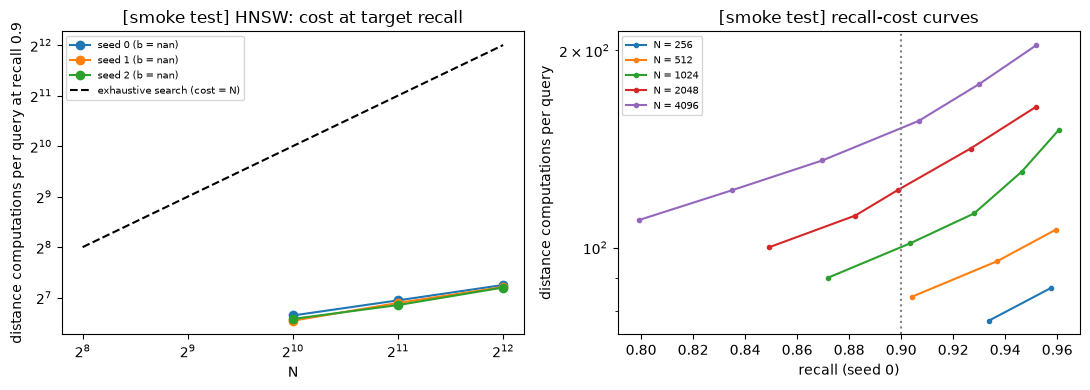

In [15]:
# ブートストラップの重み(記事を単位とする。全シード・全水準・全索引に同じ再標本を使う)
ANN_BOOTSTRAP_WEIGHTS = cluster_bootstrap_weights(ANN_QUERY_ARTICLES, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
_ONES = np.ones((1, len(ANN_QUERY_INDEX)))


def log_cost_of(sweep: dict, weights: np.ndarray) -> np.ndarray:
    # 掃引の結果から、再標本ごとの目標の recall での費用の対数(補間できなければ NaN)
    recalls, costs = weighted_curve(sweep["recall"], sweep["cost"], weights)
    return interpolate_log_cost_batch(recalls, costs, TARGET_RECALL)


_seeds = list(range(NUM_ANN_SEEDS))
A_LOG_COST = np.array([[log_cost_of(HNSW_RUNS[s]["sweeps"][n], _ONES)[0] for n in SIZE_LEVELS] for s in _seeds])  # (シード, 水準)
A_SLOPES = fit_log_log_slope(SIZE_LEVELS, A_LOG_COST)  # シードごとのべき指数 b
A_PER_SEED = 1.0 - A_SLOPES  # d_s = 1 - b_s
DELTA_A = float(A_PER_SEED.mean()) if not np.isnan(A_LOG_COST).any() else float("nan")
_boot_log_cost = np.stack(
    [np.stack([log_cost_of(HNSW_RUNS[s]["sweeps"][n], ANN_BOOTSTRAP_WEIGHTS) for n in SIZE_LEVELS], axis=1) for s in _seeds], axis=1
)  # (再標本, シード, 水準)
A_BOOT_NAN_FRACTION = float(np.isnan(_boot_log_cost).any(axis=(1, 2)).mean())
_boot_delta = 1.0 - fit_log_log_slope(SIZE_LEVELS, _boot_log_cost).mean(axis=1)  # 再標本ごとの対比量(シード平均)
A_BOOT_DELTA = _boot_delta[~np.isnan(_boot_delta)]
SIGMA_A = combined_sigma(A_PER_SEED, A_BOOT_DELTA) if len(A_BOOT_DELTA) > 1 and len(_seeds) > 1 else {"sigma": float("nan"), "seed_term": float("nan"), "bootstrap_term": float("nan")}

# 前提条件 P1(A): すべてのシード・水準で、格子が目標の recall を挟む(補間できる)。再標本で補間できない割合が 1% 以下
_bracketed = not np.isnan(A_LOG_COST).any()
precondition_status["P1(A)"] = bool(_bracketed and A_BOOT_NAN_FRACTION <= 0.01)
A_PRECONDITIONS = ["P1(A)"]
A_COMPUTED = judge(DELTA_A, SIGMA_A["sigma"]) if _bracketed else "判定不能"
A_VERDICT = A_COMPUTED if all(precondition_status[k] for k in A_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 A(シード {_seeds}、N の水準 {SIZE_LEVELS}、N_max = {N_MAX}、query {len(ANN_QUERY_INDEX)} 個、目標の recall {TARGET_RECALL})")
print("  目標の recall での費用 c(1 query あたりの距離計算の回数、シード平均の幾何平均): " + "、".join(f"N = {n}: {math.exp(float(np.mean(A_LOG_COST[:, k]))):.1f}" for k, n in enumerate(SIZE_LEVELS)))
print(f"  シードごとのべき指数 b_s: {rounded(A_SLOPES)}、d_s = 1 - b_s: {rounded(A_PER_SEED)}")
print(
    f"  Delta_A = {DELTA_A:+.4f}、sigma_A = {SIGMA_A['sigma']:.4f}(シード間 {SIGMA_A['seed_term']:.4f}・ブートストラップ {SIGMA_A['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,}、補間できない再標本の割合 {A_BOOT_NAN_FRACTION:.4f})、"
    f"閾値 2 sigma_A = {SIGMA_MULTIPLIER * SIGMA_A['sigma']:.4f}"
)
print(f"  前提条件: P1(A) {precondition_status['P1(A)']}(すべてのシード・水準で補間できる: {_bracketed}、再標本で補間できない割合 {A_BOOT_NAN_FRACTION:.4f} <= 0.01)")
print(f"  判定関数の結果 {A_COMPUTED} -> {RUN_TAG}最終判定: {A_VERDICT}")

# 診断量(判定なし)
_cost_by_level = np.exp(A_LOG_COST)
_residual = A_LOG_COST - (A_LOG_COST.mean(axis=1, keepdims=True) + A_SLOPES[:, None] * (np.log(SIZE_LEVELS) - np.log(SIZE_LEVELS).mean())[None, :])
print("  診断量(判定なし):")
print("    全探索の費用 N との比 c / N(シード平均): " + "、".join(f"N = {n}: {float(np.mean(_cost_by_level[:, k]) / n):.4f}" for k, n in enumerate(SIZE_LEVELS)))
print(f"    べき乗則のあてはめの残差(対数の費用の、あてはめとの差の二乗平均平方根。シードごと): {rounded(np.sqrt((_residual**2).mean(axis=1)))}")
print("    HNSW の構築の距離計算(シード 0、累積): " + "、".join(f"N = {n}: {HNSW_RUNS[0]['construction_distances'][n]:,}" for n in SIZE_LEVELS) + f"、層の大きさ(N_max){HNSW_RUNS[0]['layer_sizes'][N_MAX]}")
_flat_rows = []
for _k, _n in enumerate(SIZE_LEVELS):
    _flat = log_cost_of(HNSW_RUNS[0]["flat_sweeps"][_n], _ONES)[0]
    _flat_rows.append(f"N = {_n}: " + (f"{math.exp(_flat):.1f}(階層ありの {math.exp(A_LOG_COST[0, _k]):.1f} の {math.exp(_flat) / math.exp(A_LOG_COST[0, _k]):.2f} 倍)" if not np.isnan(_flat) else "格子の範囲で目標の recall に届かない(または最小で超える)"))
print("    階層の効果(シード 0): 最下層だけをランダムな入口から探索したときの目標の recall での費用: " + "、".join(_flat_rows))
print(
    f"    壁時計時間(観察): HNSW の構築 " + "、".join(f"シード {s}: {HNSW_RUNS[s]['build_seconds']:.1f} 秒" for s in _seeds) + "。判定には使わない"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for _s in _seeds:
    axes[0].plot(SIZE_LEVELS, np.exp(A_LOG_COST[_s]), "o-", label=f"seed {_s} (b = {A_SLOPES[_s]:.3f})")
axes[0].plot(SIZE_LEVELS, SIZE_LEVELS, "k--", label="exhaustive search (cost = N)")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=2)
axes[0].set_xlabel("N")
axes[0].set_ylabel("distance computations per query at recall 0.9")
axes[0].set_title(f"{PLOT_TAG}HNSW: cost at target recall")
axes[0].legend(fontsize=7)
for _n in SIZE_LEVELS:
    _sweep = HNSW_RUNS[0]["sweeps"][_n]
    axes[1].plot(_sweep["recall"].mean(axis=1), _sweep["cost"].mean(axis=1), "o-", markersize=3, label=f"N = {_n}")
axes[1].axvline(TARGET_RECALL, color="gray", linestyle=":")
axes[1].set_yscale("log")
axes[1].set_xlabel("recall (seed 0)")
axes[1].set_ylabel("distance computations per query")
axes[1].set_title(f"{PLOT_TAG}recall-cost curves")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6.9 実験 B: HNSW と転置ファイルの比較

[スモークテスト] 実験 B(シード [0, 1, 2]、N = N_max = 4096、転置ファイルのリスト数 [32, 64, 128, 256, 512]、query 300 個)
  目標の recall での費用(シード平均の幾何平均): HNSW 149.1、転置ファイル リスト数 32: 495.3、リスト数 64: 402.8、リスト数 128: 367.4、リスト数 256: 431.1、リスト数 512: 641.7。転置ファイルの値(シードごとに最小のリスト数を選んだもの): [377.3, 373.2, 352.3]
  d_s = log c_1 - log c_2(c_1: 転置ファイル、c_2: HNSW): [0.9077, 0.9243, 0.8736]、シードごとに選ばれたリスト数 [128, 128, 128]
  Delta_B = +0.9019、sigma_B = 0.0255(シード間 0.0149・ブートストラップ 0.0207、反復 1,000、補間できない再標本の割合 0.0000)、閾値 2 sigma_B = 0.0510
  前提条件: P0(B) True(費用のシード平均が最小のリスト数 128(5 点のうち 3 番目。内点は 2〜4 番目))
  前提条件: P1(B) True(HNSW・転置ファイルのすべての選択肢・シードで補間できる: True、再標本で補間できない割合 0.0000 <= 0.01)
  判定関数の結果 支持 -> [スモークテスト] 最終判定: 支持
  診断量(判定なし):
    転置ファイルの走査したベクトルの割合(目標の recall での費用 / N): リスト数 32: 0.1209、リスト数 64: 0.0983、リスト数 128: 0.0897、リスト数 256: 0.1052、リスト数 512: 0.1567、HNSW: 0.0364
    リストの大きさ(最小・平均・最大。シード 0): リスト数 32: 54・128.0・208、リスト数 64: 16・64.0・130、リスト数 128: 2・32.0・63、リスト数 256: 1・16.0・45、リスト数 512: 1・8.0・30
    壁時計時間(観察、判定には使わない): 転置ファイルの学習

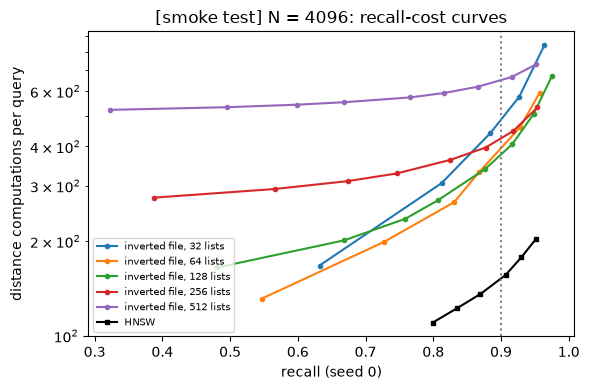

In [16]:
_inverted_file_options = sorted(INVERTED_FILE_RUNS[0]["num_lists"])


def best_option(row: np.ndarray) -> int:
    # 費用が最小の選択肢の位置(すべて補間できなければ中央)
    return int(np.nanargmin(row)) if not np.isnan(row).all() else len(row) // 2
B_IVF_LOG_COST = np.array([[log_cost_of(INVERTED_FILE_RUNS[s]["sweeps"][k], _ONES)[0] for k in _inverted_file_options] for s in _seeds])  # (シード, リスト数の選択肢)
B_HNSW_LOG_COST = A_LOG_COST[:, -1]  # N_max での HNSW(実験 A と同じ設定。調整しない)
_bracketed_b = bool(not np.isnan(B_IVF_LOG_COST).any() and not np.isnan(B_HNSW_LOG_COST).any())
_inverted_file_all_nan = np.isnan(B_IVF_LOG_COST).all(axis=1)
B_PER_SEED = np.where(_inverted_file_all_nan, np.nan, np.nanmin(np.where(np.isnan(B_IVF_LOG_COST), np.inf, B_IVF_LOG_COST), axis=1)) - B_HNSW_LOG_COST  # d_s = log(転置ファイルの最小の費用)- log(HNSW の費用)。転置ファイルはリスト数の選択肢の中で費用が最小のもの
DELTA_B = float(B_PER_SEED.mean()) if not np.isnan(B_PER_SEED).any() else float("nan")
_inverted_file_boot = np.stack([np.stack([log_cost_of(INVERTED_FILE_RUNS[s]["sweeps"][k], ANN_BOOTSTRAP_WEIGHTS) for k in _inverted_file_options], axis=1) for s in _seeds], axis=1)  # (再標本, シード, 選択肢)
_hnsw_boot = _boot_log_cost[:, :, -1]  # (再標本, シード)
B_BOOT_NAN_FRACTION = float((np.isnan(_inverted_file_boot).any(axis=(1, 2)) | np.isnan(_hnsw_boot).any(axis=1)).mean())
_boot_delta_b = (np.where(np.isnan(_inverted_file_boot).all(axis=2), np.nan, np.nanmin(np.where(np.isnan(_inverted_file_boot), np.inf, _inverted_file_boot), axis=2)) - _hnsw_boot).mean(axis=1)  # 再標本ごとに、リスト数の最小をとり直す
B_BOOT_DELTA = _boot_delta_b[~np.isnan(_boot_delta_b)]
SIGMA_B = combined_sigma(B_PER_SEED, B_BOOT_DELTA) if len(_seeds) > 1 else {"sigma": float("nan"), "seed_term": float("nan"), "bootstrap_term": float("nan")}
precondition_status["P1(B)"] = bool(_bracketed_b and B_BOOT_NAN_FRACTION <= 0.01)
# P0(B): 目標の recall での費用の対数のシード平均が最小のリスト数が、選択肢の端でない(内点である)こと
_mean_log_cost_by_lists = B_IVF_LOG_COST.mean(axis=0) if not np.isnan(B_IVF_LOG_COST).any() else None
_best_lists_by_mean = int(np.argmin(_mean_log_cost_by_lists)) if _mean_log_cost_by_lists is not None else None
precondition_status["P0(B)"] = bool(_best_lists_by_mean is not None and 0 < _best_lists_by_mean < len(_inverted_file_options) - 1)
B_PRECONDITIONS = ["P0(B)", "P1(B)"]
B_COMPUTED = judge(DELTA_B, SIGMA_B["sigma"]) if _bracketed_b else "判定不能"
B_VERDICT = B_COMPUTED if all(precondition_status[k] for k in B_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 B(シード {_seeds}、N = N_max = {N_MAX}、転置ファイルのリスト数 {_inverted_file_options}、query {len(ANN_QUERY_INDEX)} 個)")
print(
    f"  目標の recall での費用(シード平均の幾何平均): HNSW {math.exp(float(B_HNSW_LOG_COST.mean())):.1f}、転置ファイル "
    + "、".join(f"リスト数 {k}: {math.exp(float(np.nanmean(B_IVF_LOG_COST[:, j]))):.1f}" for j, k in enumerate(_inverted_file_options))
    + f"。転置ファイルの値(シードごとに最小のリスト数を選んだもの): {rounded(np.exp(B_PER_SEED + B_HNSW_LOG_COST), 1)}"
)
print(f"  d_s = log c_1 - log c_2(c_1: 転置ファイル、c_2: HNSW): {rounded(B_PER_SEED)}、シードごとに選ばれたリスト数 {[_inverted_file_options[best_option(row)] for row in B_IVF_LOG_COST]}")
print(
    f"  Delta_B = {DELTA_B:+.4f}、sigma_B = {SIGMA_B['sigma']:.4f}(シード間 {SIGMA_B['seed_term']:.4f}・ブートストラップ {SIGMA_B['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,}、補間できない再標本の割合 {B_BOOT_NAN_FRACTION:.4f})、"
    f"閾値 2 sigma_B = {SIGMA_MULTIPLIER * SIGMA_B['sigma']:.4f}"
)
print(
    f"  前提条件: P0(B) {precondition_status['P0(B)']}(費用のシード平均が最小のリスト数 "
    + (f"{_inverted_file_options[_best_lists_by_mean]}(5 点のうち {_best_lists_by_mean + 1} 番目。内点は 2〜4 番目)" if _best_lists_by_mean is not None else "未定義(補間できない選択肢がある)")
    + ")"
)
print(f"  前提条件: P1(B) {precondition_status['P1(B)']}(HNSW・転置ファイルのすべての選択肢・シードで補間できる: {_bracketed_b}、再標本で補間できない割合 {B_BOOT_NAN_FRACTION:.4f} <= 0.01)")
print(f"  判定関数の結果 {B_COMPUTED} -> {RUN_TAG}最終判定: {B_VERDICT}")
print("  診断量(判定なし):")
print(
    "    転置ファイルの走査したベクトルの割合(目標の recall での費用 / N): " + "、".join(f"リスト数 {k}: {math.exp(float(np.nanmean(B_IVF_LOG_COST[:, j]))) / N_MAX:.4f}" for j, k in enumerate(_inverted_file_options))
    + f"、HNSW: {math.exp(float(B_HNSW_LOG_COST.mean())) / N_MAX:.4f}"
)
print("    リストの大きさ(最小・平均・最大。シード 0): " + "、".join(f"リスト数 {k}: {INVERTED_FILE_RUNS[0]['list_size_stats'][k][0]}・{INVERTED_FILE_RUNS[0]['list_size_stats'][k][1]:.1f}・{INVERTED_FILE_RUNS[0]['list_size_stats'][k][2]}" for k in _inverted_file_options))
print(
    "    壁時計時間(観察、判定には使わない): 転置ファイルの学習と掃引 " + "、".join(f"シード {s}: {sum(INVERTED_FILE_RUNS[s]['fit_seconds'].values()):.1f} 秒(学習のみ)" for s in _seeds) + "。HNSW の構築 "
    + "、".join(f"シード {s}: {HNSW_RUNS[s]['build_seconds']:.1f} 秒" for s in _seeds)
)

fig, ax = plt.subplots(figsize=(6, 4))
for j, k in enumerate(_inverted_file_options):
    _sweep = INVERTED_FILE_RUNS[0]["sweeps"][k]
    ax.plot(_sweep["recall"].mean(axis=1), _sweep["cost"].mean(axis=1), "o-", markersize=3, label=f"inverted file, {k} lists")
_sweep = HNSW_RUNS[0]["sweeps"][N_MAX]
ax.plot(_sweep["recall"].mean(axis=1), _sweep["cost"].mean(axis=1), "s-", markersize=3, color="black", label="HNSW")
ax.axvline(TARGET_RECALL, color="gray", linestyle=":")
ax.set_yscale("log")
ax.set_xlabel("recall (seed 0)")
ax.set_ylabel("distance computations per query")
ax.set_title(f"{PLOT_TAG}N = {N_MAX}: recall-cost curves")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6.10 実験 C: Product Quantization の非対称距離計算と対称距離計算

[スモークテスト] 実験 C(シード [0, 1, 2]、N = N_max = 4096、m = 32、k* = 256: 符号 32 バイト = 1024 バイトの 32 分の 1、query 300 個)
  recall(上位 10 件の一致率)非対称距離計算: [0.692, 0.7153, 0.698]、対称距離計算: [0.5613, 0.588, 0.5887]
  d_s = recall(非対称)- recall(対称): [0.1307, 0.1273, 0.1093]
  Delta_C = +0.1224、sigma_C = 0.0084(シード間 0.0066・ブートストラップ 0.0051、反復 1,000)、閾値 2 sigma_C = 0.0167
  前提条件: P2(C) True(対称距離計算の recall の平均 0.5793 が 0.10 以上 0.90 以下)
  判定関数の結果 支持 -> [スモークテスト] 最終判定: 支持
  診断量(判定なし):
    距離の二乗誤差(20,000 組の平均、シード平均): 量子化の平均二乗誤差 D = 0.0887、query の量子化の誤差 E||e_x||^2 = 0.1718(D の 1.94 倍)。推定の偏り(推定 - 真の二乗距離の平均): 非対称 -0.0892(理論 -0.0887 = -D)、対称 -0.2748(理論 -0.2605 = -(E||e_x||^2 + D))。平均二乗誤差: 非対称 0.01204、対称 0.08677(比 7.21)
    再採点(上位 R 件を元のベクトルで再採点したときの recall、シード平均): asymmetric R = 10: 0.7018、asymmetric R = 20: 0.9049、asymmetric R = 50: 0.9926、asymmetric R = 100: 0.9998、asymmetric R = 200: 1.0000、symmetric R = 10: 0.5793、symmetric R = 20: 0.7802、symmetric R = 50: 0.9401、symmetric R = 100: 0.9843、symmetric R = 200: 0.9953
   

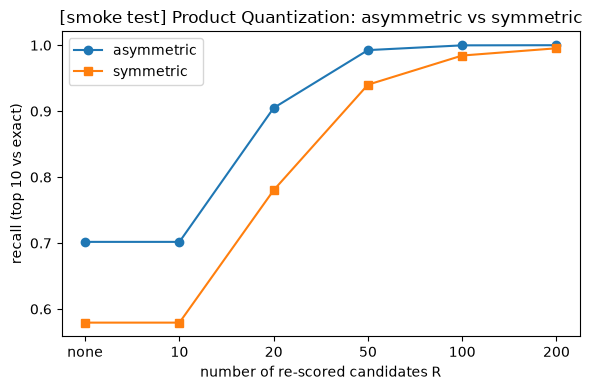

In [17]:
C_ADC = np.stack([PRODUCT_QUANTIZATION_RUNS[s]["recall"]["asymmetric"] for s in _seeds])  # (シード, query)
C_SDC = np.stack([PRODUCT_QUANTIZATION_RUNS[s]["recall"]["symmetric"] for s in _seeds])
C_PER_SEED = C_ADC.mean(axis=1) - C_SDC.mean(axis=1)  # d_s = recall(非対称)- recall(対称)
DELTA_C = float(C_PER_SEED.mean())
_boot_delta_c = ((ANN_BOOTSTRAP_WEIGHTS @ (C_ADC - C_SDC).T) / ANN_BOOTSTRAP_WEIGHTS.sum(axis=1, keepdims=True)).mean(axis=1)
SIGMA_C = combined_sigma(C_PER_SEED, _boot_delta_c) if len(_seeds) > 1 else {"sigma": float("nan"), "seed_term": float("nan"), "bootstrap_term": float("nan")}
C_SDC_MEAN = float(C_SDC.mean())
precondition_status["P2(C)"] = bool(0.10 <= C_SDC_MEAN <= 0.90)  # 改善の余地: 対称距離計算の recall が床にも天井にも達していない
C_PRECONDITIONS = ["P2(C)"]
C_COMPUTED = judge(DELTA_C, SIGMA_C["sigma"])
C_VERDICT = C_COMPUTED if all(precondition_status[k] for k in C_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 C(シード {_seeds}、N = N_max = {N_MAX}、m = {PRODUCT_QUANTIZATION_SUBVECTORS}、k* = {PRODUCT_QUANTIZATION_CODEWORDS}: 符号 {PRODUCT_QUANTIZATION_SUBVECTORS} バイト = {EMBEDDING_DIMENSION * 4} バイトの {PRODUCT_QUANTIZATION_SUBVECTORS} 分の 1、query {len(ANN_QUERY_INDEX)} 個)")
print(f"  recall(上位 10 件の一致率)非対称距離計算: {rounded(C_ADC.mean(axis=1))}、対称距離計算: {rounded(C_SDC.mean(axis=1))}")
print(f"  d_s = recall(非対称)- recall(対称): {rounded(C_PER_SEED)}")
print(
    f"  Delta_C = {DELTA_C:+.4f}、sigma_C = {SIGMA_C['sigma']:.4f}(シード間 {SIGMA_C['seed_term']:.4f}・ブートストラップ {SIGMA_C['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、"
    f"閾値 2 sigma_C = {SIGMA_MULTIPLIER * SIGMA_C['sigma']:.4f}"
)
print(f"  前提条件: P2(C) {precondition_status['P2(C)']}(対称距離計算の recall の平均 {C_SDC_MEAN:.4f} が 0.10 以上 0.90 以下)")
print(f"  判定関数の結果 {C_COMPUTED} -> {RUN_TAG}最終判定: {C_VERDICT}")
print("  診断量(判定なし):")
_diag = {k: np.mean([PRODUCT_QUANTIZATION_RUNS[s]["diagnostics"][k] for s in _seeds]) for k in PRODUCT_QUANTIZATION_RUNS[0]["diagnostics"]}
print(
    f"    距離の二乗誤差(20,000 組の平均、シード平均): 量子化の平均二乗誤差 D = {_diag['D']:.4f}、query の量子化の誤差 E||e_x||^2 = {_diag['query_error']:.4f}(D の {_diag['query_error'] / _diag['D']:.2f} 倍)。"
    f"推定の偏り(推定 - 真の二乗距離の平均): 非対称 {_diag['bias_asymmetric']:+.4f}(理論 {-_diag['D']:+.4f} = -D)、対称 {_diag['bias_symmetric']:+.4f}(理論 {-(_diag['query_error'] + _diag['D']):+.4f} = -(E||e_x||^2 + D))。"
    f"平均二乗誤差: 非対称 {_diag['mse_asymmetric']:.5f}、対称 {_diag['mse_symmetric']:.5f}(比 {_diag['mse_symmetric'] / _diag['mse_asymmetric']:.2f})"
)
print("    再採点(上位 R 件を元のベクトルで再採点したときの recall、シード平均): " + "、".join(
    f"{name} R = {r}: {np.mean([PRODUCT_QUANTIZATION_RUNS[s]['rescored_recall'][name][r].mean() for s in _seeds]):.4f}" for name in ("asymmetric", "symmetric") for r in PRODUCT_QUANTIZATION_RESCORE_COUNTS
))
_cost = PRODUCT_QUANTIZATION_RUNS[0]["cost"]["asymmetric"]
_cost_symmetric = PRODUCT_QUANTIZATION_RUNS[0]["cost"]["symmetric"]
print(
    f"    費用(1 query あたり): 非対称 参照表の作成 {_cost['table_entries']:.0f}・表引き {_cost['table_lookups']:.0f}、対称 query の量子化 {_cost_symmetric['table_entries']:.0f}・表引き {_cost_symmetric['table_lookups']:.0f}。"
    f"1 ベクトルあたりのバイト数 {PRODUCT_QUANTIZATION_RUNS[0]['code_bytes']}(元は {EMBEDDING_DIMENSION * 4}、圧縮率 {EMBEDDING_DIMENSION * 4 // PRODUCT_QUANTIZATION_RUNS[0]['code_bytes']} 倍)"
)

fig, ax = plt.subplots(figsize=(6, 4))
_x = np.arange(len(PRODUCT_QUANTIZATION_RESCORE_COUNTS) + 1)
for name, marker in (("asymmetric", "o"), ("symmetric", "s")):
    _values = [C_ADC.mean() if name == "asymmetric" else C_SDC.mean()] + [np.mean([PRODUCT_QUANTIZATION_RUNS[s]["rescored_recall"][name][r].mean() for s in _seeds]) for r in PRODUCT_QUANTIZATION_RESCORE_COUNTS]
    ax.plot(_x, _values, marker + "-", label=name)
ax.set_xticks(_x)
ax.set_xticklabels(["none"] + [str(r) for r in PRODUCT_QUANTIZATION_RESCORE_COUNTS])
ax.set_xlabel("number of re-scored candidates R")
ax.set_ylabel("recall (top 10 vs exact)")
ax.set_title(f"{PLOT_TAG}Product Quantization: asymmetric vs symmetric")
ax.legend()
plt.tight_layout()
plt.show()

### 6.11 実験 D: cross-encoder の相互作用の効果

[スモークテスト] 実験 D(シード [0, 1, 2]、T = 16、K = 50、並べ替えの query 100 個)
  並べ替えの Recall@10 R(D1): [0.11, 0.05, 0.1]、R(D2): [0.1, 0.1, 0.11]
  d_s = R(D1) - R(D2): [0.01, -0.05, -0.01]
  Delta_D = -0.0167、sigma_D = 0.0309(シード間 0.0176・ブートストラップ 0.0254、反復 1,000)、閾値 2 sigma_D = 0.0618
  前提条件: P0 False、P1 False((a)の不成立 [('D1', 0), ('D1', 1), ('D1', 2), ('D2', 0), ('D2', 1), ('D2', 2)]、最後の区間の損失の差の平均 / 標準誤差の最小 0.0(閾値 2.0)、最後の区間の訓練損失の最大 2.526(閾値 ln(1 + n) = 2.079)、参考として最後の区間の訓練損失 / 学習前のモデルの損失は 0.940〜1.029。(b)基準の条件の較正の query での Recall@10 の増分のシード平均 +0.0000(シードごと [0.0, -0.02, 0.02])、標準偏差 0.0155(シード間 0.0115・ブートストラップ 0.0103)、増分 / 標準偏差 0.0(閾値 2.0): False)、P2 True(R(D2) の平均 0.1033 <= coverage 0.2600 - 0.05)、P3 False(coverage 0.2600 >= 0.35、coverage - 並べ替えなしの Recall@10 0.1300 = 0.1300 >= 0.1)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量(判定なし):
    第 1 段の順位のまま(並べ替えなし)の指標(K = 50): Recall@10 0.1300、平均逆順位 0.0537、正規化割引累積利得(上位 10 件)0.0247、coverage(並べ替えの上限)0.2600
    D1: Recall@10 0.0867(シード間の標準偏差 0.0321)、平均逆順位 0.0356、

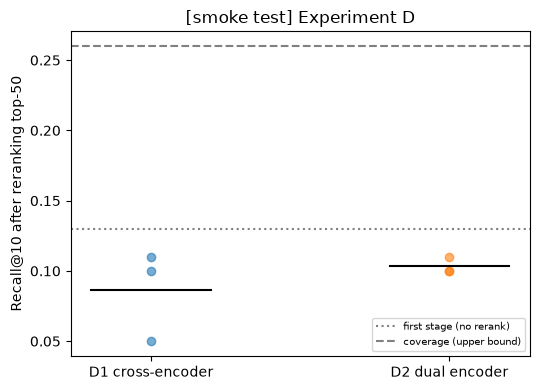

In [18]:
RERANK_BOOTSTRAP_WEIGHTS = cluster_bootstrap_weights(QUERY_ARTICLES[RERANK_QUERY_INDEX], BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)


def recall_of(condition: str, seeds: int) -> np.ndarray:
    return np.array([RUNS[(condition, s)]["hits"].mean() for s in range(seeds)])


def hits_of(condition: str, seeds: int) -> np.ndarray:
    return np.stack([RUNS[(condition, s)]["hits"] for s in range(seeds)]).astype(np.float64)  # (シード, query)


def check_learning(conditions: tuple[str, ...], baseline: str, seeds: int) -> dict:
    # 学習の成立(6.1 節): (a)全条件・全シードで、訓練損失がすべてのステップで有限、最後の区間の訓練損失が学習前のモデルの同じ組での損失より標準誤差の 2 倍以上低く、
    # かつ一様な予測の損失 ln(1 + n) 未満。(b)基準の条件の、較正の query での Recall@10 の増分(学習前のモデルとの差)のシード平均が、
    # 判定と同じ式の標準偏差(シード間の項 + ブートストラップの項)の 2 倍以上
    loss_ok = {(c, s): learning_precondition(RUNS[(c, s)]) for c in conditions for s in range(seeds)}
    statistics = {(c, s): learning_loss_statistics(RUNS[(c, s)]) for c in conditions for s in range(seeds)}
    gain = validation_gain_statistics([RUNS[(baseline, s)] for s in range(seeds)])
    gain_ok = validation_gain_precondition([RUNS[(baseline, s)] for s in range(seeds)])
    return {
        "ok": all(loss_ok.values()) and gain_ok,
        "loss_failed": [k for k, v in loss_ok.items() if not v],
        "gain_ok": gain_ok,
        "loss_margin_min": min(
            (abs(v["mean"]) / v["standard_error"] if v["standard_error"] > 0 else float("inf")) if v["mean"] < 0 else 0.0 for v in statistics.values()
        ),
        "ratio_range": (min(v["ratio"] for v in statistics.values()), max(v["ratio"] for v in statistics.values())),
        "final_loss_max": max(v["final_loss"] for v in statistics.values()),
        "gain": gain["gain"],
        "gain_sigma": gain["sigma"],
        "gain_seed_term": gain["seed_term"],
        "gain_bootstrap_term": gain["bootstrap_term"],
        "per_seed_gain": gain["per_seed_gain"],
    }


def describe_learning(result: dict) -> str:
    return (
        f"((a)の不成立 {result['loss_failed'] or 'なし'}、最後の区間の損失の差の平均 / 標準誤差の最小 {result['loss_margin_min']:.1f}(閾値 {P1_SIGMA_MULTIPLIER})、"
        f"最後の区間の訓練損失の最大 {result['final_loss_max']:.3f}(閾値 ln(1 + n) = {UNIFORM_LOSS:.3f})、参考として最後の区間の訓練損失 / 学習前のモデルの損失は {result['ratio_range'][0]:.3f}〜{result['ratio_range'][1]:.3f}。"
        f"(b)基準の条件の較正の query での Recall@10 の増分のシード平均 {result['gain']:+.4f}(シードごと {rounded(result['per_seed_gain'])})、標準偏差 {result['gain_sigma']:.4f}"
        f"(シード間 {result['gain_seed_term']:.4f}・ブートストラップ {result['gain_bootstrap_term']:.4f})、増分 / 標準偏差 {result['gain'] / result['gain_sigma'] if result['gain_sigma'] > 0 else float('inf'):.1f}"
        f"(閾値 {P1_SIGMA_MULTIPLIER}): {result['gain_ok']})"
    )


def precondition_first_stage() -> bool:
    # 第 1 段の候補(基準の条件の結果に依らない): coverage >= 下限、かつ coverage - 並べ替えなしの Recall@10 >= 余地の下限
    return bool(COVERAGE >= P3_MIN_COVERAGE and COVERAGE - FIRST_STAGE_RECALL >= P3_MIN_HEADROOM)


_seeds_d = list(range(SEEDS_D))
R_D1, R_D2 = recall_of("D1", SEEDS_D), recall_of("D2", SEEDS_D)
D_PER_SEED = R_D1 - R_D2
_hit_difference = hits_of("D1", SEEDS_D) - hits_of("D2", SEEDS_D)
_boot_d = ((RERANK_BOOTSTRAP_WEIGHTS @ _hit_difference.T) / RERANK_BOOTSTRAP_WEIGHTS.sum(axis=1, keepdims=True)).mean(axis=1)
DELTA_D = float(D_PER_SEED.mean())
SIGMA_D = combined_sigma(D_PER_SEED, _boot_d)
_p1_d = check_learning(("D1", "D2"), "D2", SEEDS_D)
precondition_status["P1(D)"] = _p1_d["ok"]
precondition_status["P2(D)"] = bool(R_D2.mean() <= COVERAGE - P2_ROOM)
precondition_status["P3(D)"] = precondition_first_stage()
D_PRECONDITIONS = ["P0(D)", "P1(D)", "P2(D)", "P3(D)"]
D_COMPUTED = judge(DELTA_D, SIGMA_D["sigma"])
D_VERDICT = D_COMPUTED if all(precondition_status[k] for k in D_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 D(シード {_seeds_d}、T = {NUM_STEPS}、K = {RERANK_CANDIDATES}、並べ替えの query {len(RERANK_QUERY_INDEX)} 個)")
print(f"  並べ替えの Recall@10 R(D1): {rounded(R_D1)}、R(D2): {rounded(R_D2)}")
print(f"  d_s = R(D1) - R(D2): {rounded(D_PER_SEED)}")
print(
    f"  Delta_D = {DELTA_D:+.4f}、sigma_D = {SIGMA_D['sigma']:.4f}(シード間 {SIGMA_D['seed_term']:.4f}・ブートストラップ {SIGMA_D['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、"
    f"閾値 2 sigma_D = {SIGMA_MULTIPLIER * SIGMA_D['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(D)']}、P1 {precondition_status['P1(D)']}{describe_learning(_p1_d)}、"
    f"P2 {precondition_status['P2(D)']}(R(D2) の平均 {R_D2.mean():.4f} <= coverage {COVERAGE:.4f} - {P2_ROOM})、"
    f"P3 {precondition_status['P3(D)']}(coverage {COVERAGE:.4f} >= {P3_MIN_COVERAGE}、coverage - 並べ替えなしの Recall@10 {FIRST_STAGE_RECALL:.4f} = {COVERAGE - FIRST_STAGE_RECALL:.4f} >= {P3_MIN_HEADROOM})"
)
print(f"  判定関数の結果 {D_COMPUTED} -> {RUN_TAG}最終判定: {D_VERDICT}")
print("  診断量(判定なし):")
print(
    f"    第 1 段の順位のまま(並べ替えなし)の指標(K = {RERANK_CANDIDATES}): Recall@10 {FIRST_STAGE_RECALL:.4f}、平均逆順位 {FIRST_STAGE_RERANK[RERANK_CANDIDATES].mean_reciprocal_rank():.4f}、"
    f"正規化割引累積利得(上位 10 件){FIRST_STAGE_RERANK[RERANK_CANDIDATES].mean_normalized_discounted_cumulative_gain_at_10():.4f}、coverage(並べ替えの上限){COVERAGE:.4f}"
)
for _c in ("D1", "D2"):
    _mean_reciprocal_rank = np.array([RUNS[(_c, s)]["mean_reciprocal_rank"] for s in _seeds_d])
    _normalized_discounted_cumulative_gain = np.array([RUNS[(_c, s)]["normalized_discounted_cumulative_gain"] for s in _seeds_d])
    print(f"    {_c}: Recall@10 {recall_of(_c, SEEDS_D).mean():.4f}(シード間の標準偏差 {recall_of(_c, SEEDS_D).std(ddof=1):.4f})、平均逆順位 {_mean_reciprocal_rank.mean():.4f}、正規化割引累積利得(上位 10 件){_normalized_discounted_cumulative_gain.mean():.4f}")
print(
    f"    並べ替えによる Recall@10 の変化(並べ替えた後 - 第 1 段の順位のまま。追加の学習量と交絡するので判定の対象にしない): D1 {R_D1.mean() - FIRST_STAGE_RECALL:+.4f}、D2 {R_D2.mean() - FIRST_STAGE_RECALL:+.4f}"
)
print(
    f"    1 query あたりの順伝播の回数: cross-encoder(D1){RERANK_CANDIDATES} 回(組ごと)、dual encoder(D2)1 回(query。passage の埋め込みは事前に計算でき、{RERANK_CANDIDATES} 回の内積)。"
    f"最後の区間の訓練損失: D1 {np.mean([RUNS[('D1', s)]['final_train_loss'] for s in _seeds_d]):.3f}、D2 {np.mean([RUNS[('D2', s)]['final_train_loss'] for s in _seeds_d]):.3f}(一様な予測の損失 ln(1 + n) = {math.log(1 + NUM_NEGATIVES):.3f})"
)

print(
    "    学習後のモデルの、query ごとの候補 50 件のスコアの標準偏差の中央値(崩壊の検出。判定には使わない): "
    + "、".join(f"{_c} {rounded([RUNS[(_c, s)]['score_std_median'] for s in _seeds_d], 4)}" for _c in ("D1", "D2"))
)

fig, ax = plt.subplots(figsize=(5.5, 4))
for _x, _c in enumerate(("D1", "D2")):
    _values = recall_of(_c, SEEDS_D)
    ax.scatter([_x] * len(_values), _values, alpha=0.6)
    ax.plot([_x - 0.2, _x + 0.2], [_values.mean()] * 2, "k-")
ax.axhline(FIRST_STAGE_RECALL, color="gray", linestyle=":", label="first stage (no rerank)")
ax.axhline(COVERAGE, color="gray", linestyle="--", label="coverage (upper bound)")
ax.set_xticks([0, 1])
ax.set_xticklabels(["D1 cross-encoder", "D2 dual encoder"])
ax.set_ylabel(f"Recall@10 after reranking top-{RERANK_CANDIDATES}")
ax.set_title(f"{PLOT_TAG}Experiment D")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6.12 実験 E: 困難な負例の効果

[スモークテスト] 実験 E(シード [0, 1, 2]、T = 16、K = 50、並べ替えの query 100 個。E1 = D1)
  並べ替えの Recall@10 R(E1): [0.11, 0.05, 0.1]、R(E2): [0.11, 0.07, 0.07]
  d_s = R(E1) - R(E2): [0.0, -0.02, 0.03]
  Delta_E = +0.0033、sigma_E = 0.0202(シード間 0.0145・ブートストラップ 0.0141、反復 1,000)、閾値 2 sigma_E = 0.0404
  前提条件: P0 False、P1 False((a)の不成立 [('D1', 0), ('D1', 1), ('D1', 2), ('E2', 0), ('E2', 1), ('E2', 2)]、最後の区間の損失の差の平均 / 標準誤差の最小 0.0(閾値 2.0)、最後の区間の訓練損失の最大 2.064(閾値 ln(1 + n) = 2.079)、参考として最後の区間の訓練損失 / 学習前のモデルの損失は 0.878〜1.029。(b)基準の条件の較正の query での Recall@10 の増分のシード平均 -0.0200(シードごと [-0.01, -0.02, -0.03])、標準偏差 0.0230(シード間 0.0058・ブートストラップ 0.0223)、増分 / 標準偏差 -0.9(閾値 2.0): False)、P2 True(R(E2) の平均 0.0833 <= coverage 0.2600 - 0.05)、P3 False(実験 D と同じ)
  判定関数の結果 判定不能 -> [スモークテスト] 最終判定: 前提不成立
  診断量(判定なし):
    ランダムな候補の中での指標(正例 1 個 + ランダムな負例 49 個、query 100 個): D1(困難な負例で学習) Recall@1 0.0133・Recall@10 0.1400
    ランダムな候補の中での指標(正例 1 個 + ランダムな負例 49 個、query 100 個): E2(ランダムな負例で学習) Recall@1 0.0100・Recall@10 0.2167
    ランダムな候補の中での指標(正例 1 個

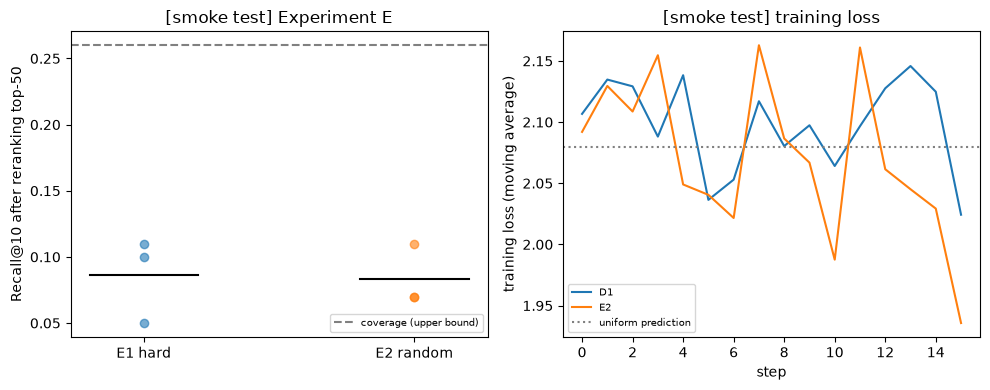

In [19]:
_seeds_e = list(range(SEEDS_E))
R_E1, R_E2 = recall_of("D1", SEEDS_E), recall_of("E2", SEEDS_E)  # E1 は実験 D の D1(同じ学習)
E_PER_SEED = R_E1 - R_E2
_hit_difference_e = hits_of("D1", SEEDS_E) - hits_of("E2", SEEDS_E)
_boot_e = ((RERANK_BOOTSTRAP_WEIGHTS @ _hit_difference_e.T) / RERANK_BOOTSTRAP_WEIGHTS.sum(axis=1, keepdims=True)).mean(axis=1)
DELTA_E = float(E_PER_SEED.mean())
SIGMA_E = combined_sigma(E_PER_SEED, _boot_e)
_p1_e = check_learning(("D1", "E2"), "E2", SEEDS_E)
precondition_status["P1(E)"] = _p1_e["ok"]
precondition_status["P2(E)"] = bool(R_E2.mean() <= COVERAGE - P2_ROOM)
precondition_status["P3(E)"] = precondition_first_stage()
E_PRECONDITIONS = ["P0(E)", "P1(E)", "P2(E)", "P3(E)"]
E_COMPUTED = judge(DELTA_E, SIGMA_E["sigma"])
E_VERDICT = E_COMPUTED if all(precondition_status[k] for k in E_PRECONDITIONS) else "前提不成立"

print(f"{RUN_TAG}実験 E(シード {_seeds_e}、T = {NUM_STEPS}、K = {RERANK_CANDIDATES}、並べ替えの query {len(RERANK_QUERY_INDEX)} 個。E1 = D1)")
print(f"  並べ替えの Recall@10 R(E1): {rounded(R_E1)}、R(E2): {rounded(R_E2)}")
print(f"  d_s = R(E1) - R(E2): {rounded(E_PER_SEED)}")
print(
    f"  Delta_E = {DELTA_E:+.4f}、sigma_E = {SIGMA_E['sigma']:.4f}(シード間 {SIGMA_E['seed_term']:.4f}・ブートストラップ {SIGMA_E['bootstrap_term']:.4f}、反復 {BOOTSTRAP_RESAMPLES:,})、"
    f"閾値 2 sigma_E = {SIGMA_MULTIPLIER * SIGMA_E['sigma']:.4f}"
)
print(
    f"  前提条件: P0 {precondition_status['P0(E)']}、P1 {precondition_status['P1(E)']}{describe_learning(_p1_e)}、"
    f"P2 {precondition_status['P2(E)']}(R(E2) の平均 {R_E2.mean():.4f} <= coverage {COVERAGE:.4f} - {P2_ROOM})、P3 {precondition_status['P3(E)']}(実験 D と同じ)"
)
print(f"  判定関数の結果 {E_COMPUTED} -> {RUN_TAG}最終判定: {E_VERDICT}")
print("  診断量(判定なし):")
for _c in ("D1", "E2", "D2"):
    _rc = [RUNS[(_c, s)]["random_candidates"] for s in range(NUM_SEEDS[_c])]
    print(
        f"    ランダムな候補の中での指標(正例 1 個 + ランダムな負例 {RANDOM_CANDIDATES - 1} 個、query {len(RANDOM_CANDIDATE_QUERIES_INDEX)} 個): {_c}({'困難な負例' if CONDITIONS[_c]['negatives'] == 'hard' else 'ランダムな負例'}で学習)"
        f" Recall@1 {np.mean([r['recall_at_1'] for r in _rc]):.4f}・Recall@10 {np.mean([r['recall_at_10'] for r in _rc]):.4f}"
    )
_window = final_loss_window(NUM_STEPS)
for _c in ("D1", "E2"):
    _first = np.mean([RUNS[(_c, s)]["train_loss"][:_window].mean() for s in range(NUM_SEEDS[_c])])
    _last = np.mean([RUNS[(_c, s)]["final_train_loss"] for s in range(NUM_SEEDS[_c])])
    print(f"    学習の損失の推移: {_c} 最初の {_window} ステップの平均 {_first:.3f} -> 最後の {_window} ステップの平均 {_last:.3f}(一様な予測の損失 ln(1 + n) = {math.log(1 + NUM_NEGATIVES):.3f})")

print(
    "    学習後のモデルの、query ごとの候補 50 件のスコアの標準偏差の中央値(崩壊の検出。判定には使わない): "
    + "、".join(f"{_c} {rounded([RUNS[(_c, s)]['score_std_median'] for s in _seeds_e], 4)}" for _c in ("D1", "E2"))
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for _x, (_c, _label) in enumerate((("D1", "E1 (hard negatives)"), ("E2", "E2 (random negatives)"))):
    _values = recall_of(_c, SEEDS_E)
    axes[0].scatter([_x] * len(_values), _values, alpha=0.6)
    axes[0].plot([_x - 0.2, _x + 0.2], [_values.mean()] * 2, "k-")
axes[0].axhline(COVERAGE, color="gray", linestyle="--", label="coverage (upper bound)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["E1 hard", "E2 random"])
axes[0].set_ylabel(f"Recall@10 after reranking top-{RERANK_CANDIDATES}")
axes[0].set_title(f"{PLOT_TAG}Experiment E")
axes[0].legend(fontsize=7)
for _c in ("D1", "E2"):
    _curves = np.stack([np.convolve(RUNS[(_c, s)]["train_loss"], np.ones(max(1, NUM_STEPS // 32)) / max(1, NUM_STEPS // 32), mode="valid") for s in range(NUM_SEEDS[_c])])
    axes[1].plot(_curves.mean(axis=0), label=_c)
axes[1].axhline(math.log(1 + NUM_NEGATIVES), color="gray", linestyle=":", label="uniform prediction")
axes[1].set_xlabel("step")
axes[1].set_ylabel("training loss (moving average)")
axes[1].set_title(f"{PLOT_TAG}training loss")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

### 6.13 実験 F: 2 段階の検索の全体(判定基準なし)

**観察であり、判定基準を設けない。** 第 1 段を全探索・HNSW・転置ファイル・Product Quantization(再採点なし・あり)に替え、それぞれの上位 100 件を、D1 のシード 0 のモデルで並べ替える。
並べ替える候補の数 $K = 10, 20, 50, 100$ は、第 1 段の上位 100 件の先頭 $K$ 件を使う。表の費用は、1 query あたりの第 1 段の距離計算の回数(Product Quantization は参照表の作成・表引き・再採点の距離計算を別々に)と、
第 2 段の順伝播の回数($K$)である。

**対象の索引**: 6.6 節で保持した、シード 0 の最大の $N$($N_{\max}$)の部分集合の索引(HNSW・転置ファイル・Product Quantization)。全探索も同じ部分集合である。**関連性は、部分集合の中での同じ記事の passage**
(部分集合は passage をランダムに間引くので、正解の数が実験 D・E のコーパス全体より少ない。正解が 1 つもない query は除く)。そのため、この表の Recall@10 の絶対値は、実験 D・E(コーパス全体)と比べない。
**第 1 段の設定**: HNSW は、実験 A のシード 0 の $N_{\max}$ の掃引で、目標の recall に初めて届いた探索の幅(上位 100 件を返すため、探索の幅は 101 以上にする)。転置ファイルは、実験 B のシード 0 で費用が最小だったリスト数と、
その掃引で目標の recall に初めて届いた探索するリストの数。Product Quantization は非対称距離計算で、再採点ありは上位 200 件を再採点する。

[スモークテスト] 実験 F(判定基準なしの観察。部分集合 N = 4096(シード 0)、query 17 個(正解がなく除いた query 33 個)、部分集合内の正解の数の中央値 1、D1 のシード 0 で並べ替え)
  第 1 段: exact search、費用(1 query あたり): distance computations 4,096
    K =  10: 順伝播 10 回、coverage 0.1176、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.1176
    K =  20: 順伝播 20 回、coverage 0.2353、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.0588
    K =  50: 順伝播 50 回、coverage 0.4118、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.0588
    K = 100: 順伝播 100 回、coverage 0.4706、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.0588
  第 1 段: HNSW (search width = 101)、費用(1 query あたり): distance computations 390
    K =  10: 順伝播 10 回、coverage 0.1176、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.1176
    K =  20: 順伝播 20 回、coverage 0.2353、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.0588
    K =  50: 順伝播 50 回、coverage 0.4118、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.0588
    K = 100: 順伝播 100 回、coverage 0.4706、Recall@10: 並べ替えなし 0.1176 -> D1 で並べ替え 0.0588
  第 1 段: inverted file (128 lists, p = 8)、費用(1 query あたり): distance computations 400


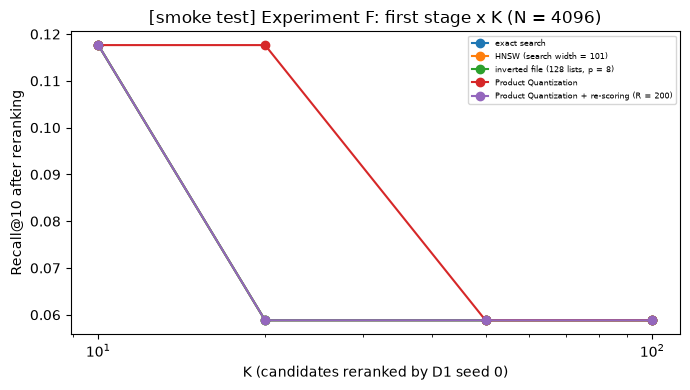

In [20]:
_t0_f = time.time()
F_SUBSET = ann_ordering(0)[:N_MAX]  # 6.6 節のシード 0 の索引と同じ部分集合
_positions = positions_in_subset(F_SUBSET, NUM_PASSAGES)
_subset_article_counts = np.bincount(PASSAGE_ARTICLES[F_SUBSET], minlength=int(PASSAGE_ARTICLES.max()) + 1)
_f_in_subset = _positions[QUERY_SOURCES[F_QUERY_INDEX]] >= 0
_f_num_positives = _subset_article_counts[QUERY_ARTICLES[F_QUERY_INDEX]] - _f_in_subset.astype(int)  # 部分集合の中の同じ記事の passage の数(元の passage を除く)
_f_keep = _f_num_positives >= 1
F_QUERIES = F_QUERY_INDEX[_f_keep]
F_NUM_POSITIVES = _f_num_positives[_f_keep]
_f_local_excluded = _positions[QUERY_SOURCES[F_QUERIES]]
_f_excluded = np.where(_f_local_excluded >= 0, QUERY_SOURCES[F_QUERIES], -1)
_f_query_embeddings = QUERY_EMBEDDINGS[F_QUERIES]
_f_depth = max(RERANK_KS)
F_FIRST_STAGE = {}  # 方法 -> (候補 (Q, 100)、費用の辞書)
# 全探索
_local, _ = exact_search(_f_query_embeddings, PASSAGE_EMBEDDINGS[torch.from_numpy(F_SUBSET)], _f_depth, excluded=_f_local_excluded)
F_FIRST_STAGE["exact search"] = (F_SUBSET[_local], {"distance computations": float(N_MAX)})
# HNSW
_sweep0 = HNSW_RUNS[0]["sweeps"][N_MAX]
_search_width_target = next((w for w, r in zip(_sweep0["grid"], _sweep0["recall"].mean(axis=1), strict=True) if r >= TARGET_RECALL), _sweep0["grid"][-1])
_search_width = max(_search_width_target, _f_depth + 1)
_ids, _costs = HNSW_RUNS[0]["index"].search_batch(QUERY_EMBEDDINGS_NP[F_QUERIES], _f_depth + 1, _search_width)
F_FIRST_STAGE[f"HNSW (search width = {_search_width})"] = (remove_excluded_and_truncate(_ids, _f_excluded, _f_depth), {"distance computations": float(_costs.mean())})
# 転置ファイル(実験 B のシード 0 で費用が最小のリスト数、その掃引で目標の recall に初めて届いた p)
_best_lists = _inverted_file_options[best_option(B_IVF_LOG_COST[0])]
_sweep_inverted_file = INVERTED_FILE_RUNS[0]["sweeps"][_best_lists]
_p_target = next((p for p, r in zip(_sweep_inverted_file["grid"], _sweep_inverted_file["recall"].mean(axis=1), strict=True) if r >= TARGET_RECALL), _sweep_inverted_file["grid"][-1])
_result = INVERTED_FILE_RUNS[0]["indices"][_best_lists].search_batch_by_probe_counts(_f_query_embeddings, _f_depth, [_p_target], excluded=_f_local_excluded)[_p_target]
F_FIRST_STAGE[f"inverted file ({_best_lists} lists, p = {_p_target})"] = (
    np.where(_result[0] >= 0, F_SUBSET[np.maximum(_result[0], 0)], -1), {"distance computations": float(_result[1].mean())}
)
# Product Quantization(非対称距離計算。再採点なし・あり)
_product_quantization_index = PRODUCT_QUANTIZATION_RUNS[0]["index"]
for _rescored in (0, 200):
    _ids, _costs = _product_quantization_index.search_asymmetric(_f_query_embeddings, _f_depth, excluded=_f_local_excluded, num_rescored=_rescored)
    F_FIRST_STAGE["Product Quantization" + (f" + re-scoring (R = {_rescored})" if _rescored else "")] = (
        F_SUBSET[_ids], {"table entries": float(_costs["table_entries"].mean()), "table lookups": float(_costs["table_lookups"].mean()), "re-scored distance computations": float(_costs["rescored_vectors"].mean())}
    )
assert all((ids >= 0).all() for ids, _ in F_FIRST_STAGE.values()), "候補が足りない query がある"
assert all(np.isin(ids, F_SUBSET).all() and (ids != _f_excluded[:, None]).all() for ids, _ in F_FIRST_STAGE.values())

# D1 のシード 0(アップロードするモデルと同じ重み)で、各方法の上位 100 件を並べ替える
_f_model = build_model("D1", 0).to(device)
_f_model.load_state_dict(SAVED_STATES[UPLOAD_RUN])
F_TABLE = {}
for _name, (_candidates, _cost) in F_FIRST_STAGE.items():
    _scores = score_candidates(_f_model, "cross_encoder", QUERY_TOKENS[torch.as_tensor(F_QUERIES, device=device)], PASSAGE_TOKENS, _candidates, SCORE_BATCH, USE_FP16_AUTOCAST)
    F_TABLE[_name] = {"cost": _cost}
    for _k in RERANK_KS:
        _after = rank_reranked_candidates(_scores[:, :_k], _candidates[:, :_k], QUERY_ARTICLES[F_QUERIES], PASSAGE_ARTICLES, F_NUM_POSITIVES)
        _before = rank_reranked_candidates(
            np.broadcast_to(FIRST_STAGE_ORDER_SCORES[:, :_k], (len(F_QUERIES), _k)), _candidates[:, :_k], QUERY_ARTICLES[F_QUERIES], PASSAGE_ARTICLES, F_NUM_POSITIVES
        )
        F_TABLE[_name][_k] = {"recall_after": _after.recall_at(10), "coverage": _after.coverage(), "recall_before": _before.recall_at(10)}
del _f_model
empty_device_cache()

print(
    f"{RUN_TAG}実験 F(判定基準なしの観察。部分集合 N = {N_MAX}(シード 0)、query {len(F_QUERIES)} 個(正解がなく除いた query {int((~_f_keep).sum())} 個)、"
    f"部分集合内の正解の数の中央値 {int(np.median(F_NUM_POSITIVES))}、D1 のシード 0 で並べ替え)"
)
for _name, _row in F_TABLE.items():
    print(f"  第 1 段: {_name}、費用(1 query あたり): " + "、".join(f"{k} {v:,.0f}" for k, v in _row["cost"].items()))
    for _k in RERANK_KS:
        _m = _row[_k]
        print(f"    K = {_k:>3}: 順伝播 {_k} 回、coverage {_m['coverage']:.4f}、Recall@10: 並べ替えなし {_m['recall_before']:.4f} -> D1 で並べ替え {_m['recall_after']:.4f}")
F_SECONDS = time.time() - _t0_f
print(f"実験 F {F_SECONDS:.1f} 秒")

fig, ax = plt.subplots(figsize=(7, 4))
for _name in F_TABLE:
    ax.plot(RERANK_KS, [F_TABLE[_name][_k]["recall_after"] for _k in RERANK_KS], "o-", label=_name)
ax.set_xscale("log")
ax.set_xlabel("K (candidates reranked by D1 seed 0)")
ax.set_ylabel("Recall@10 after reranking")
ax.set_title(f"{PLOT_TAG}Experiment F: first stage x K (N = {N_MAX})")
ax.legend(fontsize=6)
plt.tight_layout()
plt.show()

### 6.14 不変条件のアサーションと`SMOKE_TEST`の配線

- 実効水準の照合: 実際に使われた学習ステップ数・$N_{\max}$・シード数・条件・学習した回数が、5.2 節で印字した水準と 6.4 節で選ばれた計画に一致する。
- 同じシードの条件どうしで、query と正例の系列(ハッシュ)が一致し、D1 と D2 は負例も一致する(E2 だけ負例が異なる)。異なるシードでは異なる。
- 学習に使った query がすべて採掘の上位 50 件に同じ記事の passage がある query で、正例がその上位 50 件の中にある(使い回している学習の組のすべてで確かめる)。
- 学習率が、較正で選ばれた値(すべての格子点が候補から外れた条件は格子の中心)に一致する。
- 全条件で、学習ステップ数・バッチ・query と passage の長さ・並べ替えの候補・評価の query が同じである。
- 学習率が、較正した値に一致する。記録した順位から再計算した Recall@10 が、記録した hits の平均と一致する。
- 近似最近傍探索: すべての索引で、正解が部分集合での全探索の上位 10 件であること(再計算で一致)、HNSW・転置ファイル・Product Quantization の部分集合が同じシードで同じであること。
- キャッシュの導入前後の一致: 使い回している学習の組(`SCHEDULES`)が、毎回作り直した場合と完全に一致する。符号化したトークンと埋め込みのキャッシュは 5.3 節で、キャッシュの再計算との一致を確かめた。
- 評価用の索引・query の記事が、すべて 008 の事前学習とトークナイザの学習の範囲(参照コーパス)の外にある。

In [21]:
# --- 実効水準の照合(SMOKE_TEST の配線) ---
assert CURRENT_LEVEL_NAME == ("smoke" if SMOKE_TEST else "prod")
assert STEP_CANDIDATES == LEVELS[CURRENT_LEVEL_NAME]["STEP_CANDIDATES"] and NUM_STEPS in STEP_CANDIDATES
assert N_MAX_CANDIDATES == LEVELS[CURRENT_LEVEL_NAME]["N_MAX_CANDIDATES"] and N_MAX in N_MAX_CANDIDATES
assert BOOTSTRAP_RESAMPLES == LEVELS[CURRENT_LEVEL_NAME]["BOOTSTRAP_RESAMPLES"] and ANN_BOOTSTRAP_WEIGHTS.shape[0] == RERANK_BOOTSTRAP_WEIGHTS.shape[0] == BOOTSTRAP_RESAMPLES
assert SELECTED_PLAN == PLANS[SELECTED_PLAN["plan"]] and PLAN_SETTINGS == stage_settings(STAGE) and N_MAX == PLAN_SETTINGS["n_max"]
assert set(RUNS) == {(c, s) for c in CONDITIONS for s in range(NUM_SEEDS[c])}, "学習した条件・シードが選ばれた計画と一致しない"
assert set(HNSW_RUNS) == set(INVERTED_FILE_RUNS) == set(PRODUCT_QUANTIZATION_RUNS) == set(range(NUM_ANN_SEEDS))
assert all(r["num_steps"] == NUM_STEPS and len(r["train_loss"]) == NUM_STEPS for r in RUNS.values())
assert all(r["learning_rate"] == LEARNING_RATE[r["condition"]] == CALIBRATION[r["condition"]]["chosen"] for r in RUNS.values())
assert all(h["sizes"] == SIZE_LEVELS and set(h["sweeps"]) == set(SIZE_LEVELS) for h in HNSW_RUNS.values())
assert all(set(r["num_lists"]) == set(inverted_file_list_counts_for(N_MAX)) for r in INVERTED_FILE_RUNS.values())
assert len(ANN_QUERY_INDEX) == len(ANN_QUERY_ARTICLES) and (UPLOAD_RUN in SAVED_STATES) and set(SAVED_STATES) == {UPLOAD_RUN}
# --- 対応のある比較: 同じシードの条件どうしで、query と正例の系列が一致する。D1・D2 は負例も一致する。異なるシードでは異なる ---
for _s in range(min(NUM_SEEDS.values())):
    _schedule = get_schedule(_s, NUM_STEPS)
    assert len({RUNS[(c, _s)]["schedule_hash"] for c in ("D1", "D2")}) == 1, f"シード {_s} で D1 と D2 の学習の組が一致しない"
    assert RUNS[("E2", _s)]["schedule_hash"] != RUNS[("D1", _s)]["schedule_hash"]  # E2 だけ負例が異なる(ランダム)
assert len({get_schedule(s, NUM_STEPS).digest() for s in range(NUM_SEEDS["D1"])}) == NUM_SEEDS["D1"], "異なるシードで学習の組が同じ"
assert all(get_schedule(0, NUM_STEPS).digest() == get_schedule(0, NUM_STEPS).digest() for _ in [0])
# --- キャッシュの導入前後の一致: 使い回している学習の組(SCHEDULES)が、作り直した場合と完全に一致する ---
for (_seed_index, _steps), _cached in SCHEDULES.items():
    _fresh = sample_reranking_schedule(
        TRAIN_QUERY_INDEX, MINED_CANDIDATES, QUERY_ARTICLES, QUERY_SOURCES, PASSAGE_ARTICLES, TRAIN_PASSAGE_INDEX, _steps, BATCH_QUERIES, NUM_NEGATIVES, seed=SCHEDULE_SEED_BASE + _seed_index
    )
    assert all(np.array_equal(getattr(_cached, n), getattr(_fresh, n)) for n in ("query", "positive", "hard_negatives", "random_negatives")), (_seed_index, _steps)
print(f"学習の組のキャッシュ({len(SCHEDULES)} 通り)が、作り直した場合と完全に一致: OK")
# --- 学習に使った query は採掘の上位に同じ記事の passage がある query で、正例はその上位の中にある ---
_usable_query_set_check = set(TRAIN_QUERY_INDEX[USABLE_TRAIN_QUERY_MASK].tolist())
_mined_of_query_check = {int(q): set(MINED_CANDIDATES[i].tolist()) for i, q in enumerate(TRAIN_QUERY_INDEX)}
for (_seed_index, _steps), _cached in SCHEDULES.items():
    assert all(int(q) in _usable_query_set_check for q in _cached.query.ravel()), (_seed_index, _steps, "学習に使えない query が入っている")
    assert all(int(p) in _mined_of_query_check[int(q)] for q, p in zip(_cached.query.ravel(), _cached.positive.ravel(), strict=True)), (_seed_index, _steps, "正例が採掘の上位の中にない")
print(f"学習に使った query はすべて学習に使える query({NUM_USABLE_TRAIN_QUERIES:,} 個のうち)で、正例はすべて採掘の上位 {MINING_DEPTH} 件の中にある(学習の組 {len(SCHEDULES)} 通り): OK")
# --- 全条件で評価の分母が同じ ---
assert all(r["hits"].shape == (len(RERANK_QUERY_INDEX),) and r["rank"].shape == (len(RERANK_QUERY_INDEX),) for r in RUNS.values())
for _record in RUNS.values():
    assert np.array_equal(_record["rank"] <= 10, _record["hits"])
    assert _record["rank"].min() >= 1 and _record["rank"].max() <= RERANK_CANDIDATES + 1
assert RERANK_CANDIDATE_IDS.shape == (len(RERANK_QUERY_INDEX), RERANK_CANDIDATES) and CALIBRATION_CANDIDATE_IDS.shape == (len(CALIBRATION_QUERY_INDEX), RERANK_CANDIDATES)
# --- 近似最近傍探索: 正解の再計算と、同じシードの部分集合の一致 ---
for _s in _seeds:
    _subset = ann_ordering(_s)[:N_MAX]
    _truth, _, _ = ann_truth(_s, _subset)
    _positions_check = positions_in_subset(_subset, NUM_PASSAGES)
    _local = _positions_check[QUERY_SOURCES[ANN_QUERY_INDEX]]
    _again, _ = exact_search(ANN_QUERIES_TENSOR, PASSAGE_EMBEDDINGS[torch.from_numpy(_subset)], NEIGHBORS, excluded=_local)
    assert np.array_equal(_subset[_again], _truth), "正解が再計算と一致しない"
    assert np.array_equal(HNSW_RUNS[_s]["sweeps"][N_MAX]["recall"].shape[1:], (len(ANN_QUERY_INDEX),))
    assert np.array_equal(np.sort(INVERTED_FILE_RUNS[_s]["subset"]), np.sort(_subset)) and np.array_equal(np.sort(PRODUCT_QUANTIZATION_RUNS[_s]["subset"]), np.sort(_subset))
    _hnsw_subset = np.sort(HNSW_RUNS[0]["index"].inserted_elements()) if _s == 0 else None
    if _s == 0:
        assert np.array_equal(_hnsw_subset, np.sort(_subset)), "HNSW の挿入済みの要素が、転置ファイル・Product Quantization の部分集合と一致しない"
for _s in _seeds:  # 掃引の recall が 0 以上 1 以下で、費用が正
    for _sweep in list(HNSW_RUNS[_s]["sweeps"].values()) + list(INVERTED_FILE_RUNS[_s]["sweeps"].values()):
        assert (_sweep["recall"] >= 0).all() and (_sweep["recall"] <= 1).all() and (_sweep["cost"] > 0).all()
# --- 学習の成立の前提条件が、更新がない(学習率 0)の学習で不成立になる(基準の条件 D2・E2、32 ステップ)---
# 更新がなければ、(a)の損失の差と(b)の増分は 0(丸めの範囲)になる。(a)の「最後の区間の訓練損失 < ln(1 + n)」は、学習前のモデルの損失が一様な予測より高いか低いかに依るので、値を印字する
_zero_checks = {}
for _condition in BASELINE_CONDITIONS:
    _record = train_run(_condition, CALIBRATION_SEED_INDEX, 0.0, 32, main=False, with_untrained=True)
    _zero_checks[_condition] = (learning_loss_statistics(_record), validation_gain_statistics([_record]))
    assert not learning_precondition(_record), f"学習率 0 の学習で学習の成立 (a) が成立した({_condition})"
    assert not validation_gain_precondition([_record]), f"学習率 0 の学習で学習の成立 (b) が成立した({_condition})"
print(
    "学習の成立の前提条件は、学習率 0(更新なし)の学習で不成立になる: "
    + "、".join(
        f"{c}: (a) 損失の差の平均 {st['mean']:+.2e}・標準誤差 {st['standard_error']:.2e}・最後の区間の損失 {st['final_loss']:.3f}(ln(1 + n) = {UNIFORM_LOSS:.3f})、(b) 増分 {g['gain']:+.4f}"
        for c, (st, g) in _zero_checks.items()
    )
)
# --- 008 とトークナイザの学習の範囲の外 ---
_evaluated_articles = set(QUERY_ARTICLES[RERANK_QUERY_INDEX].tolist()) | set(QUERY_ARTICLES[ANN_QUERY_INDEX].tolist()) | set(PASSAGE_ARTICLES.tolist())
assert min(_evaluated_articles) >= NUM_REFERENCE_ARTICLES
assert all(r["finite"] for r in RUNS.values()), "有限でない損失の学習がある"
print(
    f"実効水準: T = {NUM_STEPS}、計画 {SELECTED_PLAN['plan']}(段階 {STAGE})、N_max = {N_MAX}、近似最近傍探索のシード数 {NUM_ANN_SEEDS}、並べ替えのシード数 {json.dumps(NUM_SEEDS)}、"
    f"学習 {len(RUNS)} 回、バッチ {BATCH_QUERIES} query x (正例 1 + 負例 {NUM_NEGATIVES})、K = {RERANK_CANDIDATES}、並べ替えの query {len(RERANK_QUERY_INDEX)} 個、近似最近傍探索の query {len(ANN_QUERY_INDEX)} 個、"
    f"ブートストラップ {BOOTSTRAP_RESAMPLES:,} 回: 照合 OK"
)
print(f"同じシードの D1 と D2 で学習の組(query・正例・負例)が一致、E2 は query と正例が同じで負例だけ異なる、異なるシードでは異なる(シード {min(NUM_SEEDS.values())} 個で確認): OK")

学習の組のキャッシュ(5 通り)が、作り直した場合と完全に一致: OK


学習に使った query はすべて学習に使える query(39,303 個のうち)で、正例はすべて採掘の上位 50 件の中にある(学習の組 5 通り): OK


学習の成立の前提条件は、学習率 0(更新なし)の学習で不成立になる: D2: (a) 損失の差の平均 +0.00e+00・標準誤差 0.00e+00・最後の区間の損失 2.521(ln(1 + n) = 2.079)、(b) 増分 +0.0000、E2: (a) 損失の差の平均 +0.00e+00・標準誤差 0.00e+00・最後の区間の損失 2.201(ln(1 + n) = 2.079)、(b) 増分 +0.0000
実効水準: T = 16、計画 0(段階 0)、N_max = 4096、近似最近傍探索のシード数 3、並べ替えのシード数 {"D1": 3, "D2": 3, "E2": 3}、学習 9 回、バッチ 8 query x (正例 1 + 負例 7)、K = 50、並べ替えの query 100 個、近似最近傍探索の query 300 個、ブートストラップ 1,000 回: 照合 OK
同じシードの D1 と D2 で学習の組(query・正例・負例)が一致、E2 は query と正例が同じで負例だけ異なる、異なるシードでは異なる(シード 3 個で確認): OK


### 6.15 判定結果の一覧

In [22]:
print(f"{RUN_TAG}判定結果(計画 {SELECTED_PLAN['plan']}、T = {NUM_STEPS}、段階 {STAGE}: {STAGE_CHANGES[STAGE]})")
VERDICTS = {
    "A": (DELTA_A, SIGMA_A["sigma"], A_COMPUTED, A_VERDICT, A_PRECONDITIONS),
    "B": (DELTA_B, SIGMA_B["sigma"], B_COMPUTED, B_VERDICT, B_PRECONDITIONS),
    "C": (DELTA_C, SIGMA_C["sigma"], C_COMPUTED, C_VERDICT, C_PRECONDITIONS),
    "D": (DELTA_D, SIGMA_D["sigma"], D_COMPUTED, D_VERDICT, D_PRECONDITIONS),
    "E": (DELTA_E, SIGMA_E["sigma"], E_COMPUTED, E_VERDICT, E_PRECONDITIONS),
}
for _experiment, (_delta, _sigma, _computed, _verdict, _preconditions) in VERDICTS.items():
    print(
        f"  実験 {_experiment}: 対比量 {_delta:+.4f}、標準偏差 {_sigma:.4f}、閾値 {SIGMA_MULTIPLIER * _sigma:.4f}、判定関数の結果 {_computed}、"
        f"前提条件 {json.dumps({k: precondition_status[k] for k in _preconditions})} -> {RUN_TAG}最終判定: {_verdict}"
    )
TOTAL_SECONDS = time.time() - NOTEBOOK_START_TIME
print(f"全体の経過時間 {TOTAL_SECONDS / 60:.1f} 分(予算 {SESSION_BUDGET_SECONDS / 60:.0f} 分、計画の見積もり {PLAN_ESTIMATES[SELECTED_PLAN['plan']]['total'] / 60:.1f} 分 + 選択時の経過 {ELAPSED_AT_SELECTION / 60:.1f} 分)")

[スモークテスト] 判定結果(計画 0、T = 16、段階 0: (削らない))
  実験 A: 対比量 +nan、標準偏差 nan、閾値 nan、判定関数の結果 判定不能、前提条件 {"P1(A)": false} -> [スモークテスト] 最終判定: 前提不成立
  実験 B: 対比量 +0.9019、標準偏差 0.0255、閾値 0.0510、判定関数の結果 支持、前提条件 {"P0(B)": true, "P1(B)": true} -> [スモークテスト] 最終判定: 支持
  実験 C: 対比量 +0.1224、標準偏差 0.0084、閾値 0.0167、判定関数の結果 支持、前提条件 {"P2(C)": true} -> [スモークテスト] 最終判定: 支持
  実験 D: 対比量 -0.0167、標準偏差 0.0309、閾値 0.0618、判定関数の結果 判定不能、前提条件 {"P0(D)": false, "P1(D)": false, "P2(D)": true, "P3(D)": false} -> [スモークテスト] 最終判定: 前提不成立
  実験 E: 対比量 +0.0033、標準偏差 0.0202、閾値 0.0404、判定関数の結果 判定不能、前提条件 {"P0(E)": false, "P1(E)": false, "P2(E)": true, "P3(E)": false} -> [スモークテスト] 最終判定: 前提不成立
全体の経過時間 11.6 分(予算 120 分、計画の見積もり 15.7 分 + 選択時の経過 1.8 分)


### 6.16 Hugging Face Hub へのアップロード(D1 のシード 0)

後続の RAG アプリ(`apps/`)の入力にするため、**D1(困難な負例で学習した cross-encoder)のシード 0** の学習後の重みを`kojikojiprg/ai-theories-cross-encoder-en`(新規、public)にアップロードする。
アップロードするモデルは結果を見て選ばない(条件とシードを事前に固定している)。

- **アップロードのセルは`UPLOAD_ARTIFACTS`で守る。既定は`False`。** `SMOKE_TEST`とは独立のフラグで、本番(`SMOKE_TEST = False`)でも、アップロードは`UPLOAD_ARTIFACTS`を別途`True`にしたときだけ行う。
- **公開の条件**: `UPLOAD_ARTIFACTS = True`でも、アップロードは **読み込み直した D1 のシード 0 の、評価用の query での Recall@10 が、並べ替えなしの Recall@10(第 1 段の順位のまま)を上回る場合だけ** 行う。
  満たさない場合はアップロードを行わず、その旨と両方の値を印字する(`HF_TOKEN`の取得も行わない)。**これは実験の判定ではなく、公開するかどうかの条件である**(判定の対比量にも、前提条件にも使わない)。
  並べ替えで第 1 段より悪くなるモデルを、後続のアプリの入力として公開しないためである。
- Colab Secrets の`HF_TOKEN`が取得できない場合は、例外で停止せず、アップロードをスキップしてその旨を印字する。取得した値は印字・記録・加工しない。
- アップロード後、`list_repo_files()`でリポジトリに意図したファイルが実際に存在することを確かめる。`upload_file`が例外を送出しなかったことだけを根拠にしない。
- **このセルの前半(ファイルの書き出し・読み込み直し・評価・モデルカードの組み立て)は、`UPLOAD_ARTIFACTS`によらず毎回実行する**(アップロードしなくてもモデルカードの下書きを確認できるように)。
  モデルカードの指標は、書き出した重みを新しいモデルに読み込み直して評価した値とする(学習中の途中の評価値は使わない)。
- トークナイザと第 1 段のモデルは同梱しない。モデルカードで`kojikojiprg/ai-theories-tokenizer-en`・`kojikojiprg/ai-theories-text-embedding-en`を参照する。索引・埋め込み・他の条件のモデルはアップロードしない。

In [23]:
_t0_upload = time.time()
MODEL_CARD_TEMPLATE = '''---
language: en
license: mit
tags:
- ai-theories
- cross-encoder
- reranking
- retrieval
- scratch-implementation
---

# ai-theories cross-encoder(英語、困難な負例で学習した並べ替えモデル)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`)を起点に、query と passage を連結して符号化し、終端の位置の出力から並べ替えのスコアを出す cross-encoder として、
全パラメータを更新して学習したもの。第 1 段の検索器(`kojikojiprg/ai-theories-text-embedding-en`)の上位から採掘した困難な負例で学習した。
スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 由来

- [025. ANN 検索とリランキング](https://github.com/kojikojiprg/ai-theories/blob/main/theories/07_retrieval/025_ann_search_and_reranking.ipynb)の
  条件 D1(困難な負例で学習した cross-encoder)のシード 0 の学習後の重み。結果を見て選んだものではなく、事前に固定した条件とシードである。
- 学習: {num_steps} ステップ、1 ステップ {batch_queries} query x(正例 1 + 負例 {num_negatives})、query {query_length} トークン・passage {passage_length} トークン、学習率 {learning_rate:.3g}、
  AdamW(重み減衰 {weight_decay})、warmup + cosine、gradient clipping {clip}。損失は、1 個の正例と {num_negatives} 個の負例の softmax 交差エントロピー。
  学習データは `kojikojiprg/ai-theories-corpus-en` の、先頭の 356 記事を除く記事のうち学習用に分けた {num_train_articles} 記事のみ(検証用・評価用の記事は含まない)。
  負例は、第 1 段の検索器の、学習用の記事の passage だけを対象にした全探索の上位 {mining_depth} 件から、query と同じ記事の passage を除いて一様に選んだ。

## 使うために必要な他のアーティファクト

- **トークナイザは同梱していない。** `kojikojiprg/ai-theories-tokenizer-en` を使用してください(語彙サイズ 8192、特殊トークンなし)。
- **第 1 段の検索器は同梱していない。** 並べ替える候補は、`kojikojiprg/ai-theories-text-embedding-en`(024 の Matryoshka Representation Learning で学習した埋め込みモデル。平均プール・因果マスク)の
  全探索または近似最近傍探索の上位 {rerank_candidates} 件を想定している。
- 本体の構成は `config.json`(008 の `config.json` と同じ構成に、cross-encoder の設定を加えたもの)を参照。

## 入力とスコア

入力の列は `[query のトークン {query_length} 個] [区切り] [passage のトークン {passage_length} 個] [終端]` の {sequence_length} トークン(パディングなし)。
008 のトークナイザには特殊トークンがないので、語彙を増やさず、コーパスに一度も現れない単一バイトのトークンを使う: 区切りは 0x1F(ID {separator_id})、終端は 0x1E(ID {terminal_id})。
スコアは、因果マスクのもとで query 全体と passage 全体を見ている **最後の位置(終端)** の、最終正規化層の後の隠れ状態に、線形の層(`head`)を掛けたスカラーである。

```python
import json
import torch
from huggingface_hub import hf_hub_download
from src.models.cross_encoder import CrossEncoder

config = json.load(open(hf_hub_download("{repo_id}", "config.json")))
# GPTLanguageModel の構築は 008(kojikojiprg/ai-theories-small-gpt-en)の config.json と同じ(025 のノートブックの build_gpt() を参照)
backbone = build_gpt(config)
model = CrossEncoder(backbone, config["separator_token_id"], config["terminal_token_id"])
model.load_state_dict(torch.load(hf_hub_download("{repo_id}", "model_state.pt"), map_location="cpu"))
model.eval()
with torch.no_grad():
    scores = model(query_token_ids, passage_token_ids)  # 形状 (B,)。query は (B, {query_length})、passage は (B, {passage_length}) のトークン ID
```

## 評価(アップロードした重みそのものを読み込み直して測った値)

評価用の記事の query {num_queries} 個(024 の評価用の集合と同じ手順で切り出した query から、記事ごとに等間隔に選んだもの)を、コーパス全体({num_passages} passage)に対する第 1 段(024 のモデルの全探索)の
上位 {rerank_candidates} 件を並べ替えて、Recall@10(上位 10 件に同じ記事の別の passage が 1 つ以上ある query の割合)などを測った。

| 指標 | 並べ替えなし(第 1 段の順位) | このモデルで並べ替え |
|---|---|---|
| Recall@10 | {first_stage_recall:.4f} | {recall:.4f} |
| 平均逆順位(Mean Reciprocal Rank) | {first_stage_mean_reciprocal_rank:.4f} | {mean_reciprocal_rank:.4f} |

- 並べ替えで到達できる Recall@10 の上限(上位 {rerank_candidates} 件に正例が入る query の割合): {coverage:.4f}。ランダムな順位の Recall@10 の期待値: {random_recall:.4f}。
- 上の値は {smoke_note}

## 注意

- 学習データは英語 Wikipedia の長大な記事(Special:LongPages の長い順に選んだ記事。約 {list_like_share} がリスト系の記事)に限られ、汎用の並べ替えモデルとして使えるものではない。
- 関連性は「query と同じ記事の別の passage」と定義した評価であり、内容が関連する別の記事の passage は負例として扱われる。
- 評価用の集合は、ノートブックの実行時点のコーパス(`article_offsets` を含む `metadata.json`)に依存する。
'''


def build_card_and_files(directory: Path) -> dict:
    # 学習後の重みをファイルに書き出し、新しいモデルに読み込み直して評価した値でモデルカードを組み立てる
    state = SAVED_STATES[UPLOAD_RUN]
    torch.save(state, directory / "model_state.pt")
    config = dict(REFERENCE_CONFIG) | {
        "model_type": "cross_encoder",
        "separator_token_id": SEPARATOR_TOKEN_ID,
        "terminal_token_id": TERMINAL_TOKEN_ID,
        "head": "linear(d_model -> 1) applied to the final-normalized hidden state of the last position",
        "query_length": QUERY_LENGTH,
        "passage_length": PASSAGE_LENGTH,
        "rerank_candidates": RERANK_CANDIDATES,
        "tokenizer_repo": TOKENIZER_REPO_ID,
        "base_model_repo": REFERENCE_MODEL_REPO_ID,
        "first_stage_repo": FIRST_STAGE_REPO_ID,
        "source_notebook": "theories/07_retrieval/025_ann_search_and_reranking.ipynb",
    }
    (directory / "config.json").write_text(json.dumps(config, indent=2, ensure_ascii=False), encoding="utf-8")
    torch.manual_seed(0)
    reloaded = CrossEncoder(build_gpt(REFERENCE_CONFIG), SEPARATOR_TOKEN_ID, TERMINAL_TOKEN_ID, HEAD_INIT_STD)
    reloaded.load_state_dict(torch.load(directory / "model_state.pt", map_location="cpu"))
    assert all(torch.equal(a, b) for a, b in zip(reloaded.state_dict().values(), state.values(), strict=True)), "書き出した重みが一致しない"
    reloaded = reloaded.to(device)
    evaluated, _ = evaluate_rerank(reloaded, "cross_encoder", RERANK_QUERY_INDEX, RERANK_CANDIDATE_IDS)
    del reloaded
    empty_device_cache()
    # 学習直後の値(記録した順位)と、読み込み直した重みでの値が一致する(同じ関数・同じデバイス。バッチの大きさは結果に影響しない)
    assert abs(evaluated.recall_at(10) - float(RUNS[UPLOAD_RUN]["hits"].mean())) <= 2 / len(RERANK_QUERY_INDEX), evaluated.recall_at(10)
    card = MODEL_CARD_TEMPLATE.format(
        num_steps=NUM_STEPS, batch_queries=BATCH_QUERIES, num_negatives=NUM_NEGATIVES, query_length=QUERY_LENGTH, passage_length=PASSAGE_LENGTH, learning_rate=LEARNING_RATE["D1"],
        weight_decay=WEIGHT_DECAY, clip=GRADIENT_CLIP_THRESHOLD, num_train_articles=f"{len(SPLIT.train):,}", mining_depth=MINING_DEPTH, rerank_candidates=RERANK_CANDIDATES,
        sequence_length=QUERY_LENGTH + 1 + PASSAGE_LENGTH + 1, separator_id=SEPARATOR_TOKEN_ID, terminal_id=TERMINAL_TOKEN_ID, repo_id=UPLOAD_REPO_ID,
        num_queries=len(RERANK_QUERY_INDEX), num_passages=f"{NUM_PASSAGES:,}", first_stage_recall=FIRST_STAGE_RECALL, recall=evaluated.recall_at(10),
        first_stage_mean_reciprocal_rank=FIRST_STAGE_RERANK[RERANK_CANDIDATES].mean_reciprocal_rank(), mean_reciprocal_rank=evaluated.mean_reciprocal_rank(), coverage=evaluated.coverage(), random_recall=RANDOM_RECALL,
        smoke_note="スモークテストの値であり、意味を持たない。" if SMOKE_TEST else "本番の実行の値である。", list_like_share=f"{len(LIST_LIKE_ARTICLES) / len(CANDIDATE_ARTICLES):.0%}",
    )
    (directory / "README.md").write_text(card, encoding="utf-8")
    return {"evaluated": evaluated, "card": card, "files": sorted(p.name for p in directory.iterdir())}


with tempfile.TemporaryDirectory() as _temporary_directory:
    _built = build_card_and_files(Path(_temporary_directory))
    UPLOAD_FILES = _built["files"]
    assert UPLOAD_FILES == ["README.md", "config.json", "model_state.pt"], "トークナイザなど、同梱しないファイルが含まれている"
    print(
        f"{RUN_TAG}モデルカードの下書きと書き出したファイル {UPLOAD_FILES} を作成し、重みを読み込み直して評価した"
        f"(並べ替えの Recall@10 {_built['evaluated'].recall_at(10):.4f}、記録した値 {float(RUNS[UPLOAD_RUN]['hits'].mean()):.4f})"
    )
    print("--- モデルカードの先頭 ---")
    print("\n".join(_built["card"].splitlines()[:22]))

    UPLOAD_RECALL, UPLOAD_FIRST_STAGE_RECALL = _built["evaluated"].recall_at(10), FIRST_STAGE_RECALL
    UPLOAD_CONDITION_MET = bool(UPLOAD_RECALL > UPLOAD_FIRST_STAGE_RECALL)  # 公開の条件(判定ではない): 並べ替えた後の Recall@10 > 並べ替えなしの Recall@10
    print(
        f"{RUN_TAG}公開の条件(判定ではない): 読み込み直した D1 のシード 0 の Recall@10 {UPLOAD_RECALL:.4f} > 並べ替えなしの Recall@10 {UPLOAD_FIRST_STAGE_RECALL:.4f}: {UPLOAD_CONDITION_MET}"
    )
    if not UPLOAD_ARTIFACTS:
        print("UPLOAD_ARTIFACTS = False のため、アップロードは行わない(モデルカードの下書きの確認のみ)")
    elif not UPLOAD_CONDITION_MET:
        print(
            f"公開の条件を満たさないため、アップロードを行わない: 読み込み直した D1 のシード 0 の Recall@10 {UPLOAD_RECALL:.4f} が、並べ替えなしの Recall@10 {UPLOAD_FIRST_STAGE_RECALL:.4f} を上回らない"
        )
    else:
        try:
            from google.colab import userdata  # noqa: E402

            _token = userdata.get("HF_TOKEN")
        except Exception:  # noqa: BLE001  # Colab 以外・Secrets 未設定・取得失敗のいずれでも、停止せずスキップする
            _token = None
        if not _token:
            print("Colab Secrets から HF_TOKEN を取得できないため、アップロードをスキップする")
        else:
            from huggingface_hub import HfApi

            _api = HfApi(token=_token)
            _api.create_repo(UPLOAD_REPO_ID, repo_type="model", exist_ok=True, private=False)
            for _name in UPLOAD_FILES:
                _api.upload_file(path_or_fileobj=str(Path(_temporary_directory) / _name), path_in_repo=_name, repo_id=UPLOAD_REPO_ID, repo_type="model")
            _remote = sorted(_api.list_repo_files(UPLOAD_REPO_ID, repo_type="model"))
            _missing = [n for n in UPLOAD_FILES if n not in _remote]
            assert not _missing, f"アップロードしたはずのファイルがリポジトリにない: {_missing}"
            print(f"アップロード完了: {UPLOAD_REPO_ID} のファイル {_remote}(意図したファイルがすべて存在することを list_repo_files() で確認)")
print(f"アップロードの準備 {time.time() - _t0_upload:.1f} 秒")

[スモークテスト] モデルカードの下書きと書き出したファイル ['README.md', 'config.json', 'model_state.pt'] を作成し、重みを読み込み直して評価した(並べ替えの Recall@10 0.1100、記録した値 0.1100)
--- モデルカードの先頭 ---
---
language: en
license: mit
tags:
- ai-theories
- cross-encoder
- reranking
- retrieval
- scratch-implementation
---

# ai-theories cross-encoder(英語、困難な負例で学習した並べ替えモデル)

`ai-theories`(https://github.com/kojikojiprg/ai-theories)プロジェクトの成果物。
008 の小型 GPT(`kojikojiprg/ai-theories-small-gpt-en`)を起点に、query と passage を連結して符号化し、終端の位置の出力から並べ替えのスコアを出す cross-encoder として、
全パラメータを更新して学習したもの。第 1 段の検索器(`kojikojiprg/ai-theories-text-embedding-en`)の上位から採掘した困難な負例で学習した。
スクラッチ実装であり、研究・教育目的のモデルである。品質保証は行っていない。商用・実運用での利用は想定しない。

## 由来

- [025. ANN 検索とリランキング](https://github.com/kojikojiprg/ai-theories/blob/main/theories/07_retrieval/025_ann_search_and_reranking.ipynb)の
  条件 D1(困難な負例で学習した cross-encoder)のシード 0 の学習後の重み。結果を見て選んだものではなく、事前に固定した条件とシードである。
[スモークテスト] 公開の条件(判定ではない): 読み込み直した D1 のシード 0 の Recall@10 0.1100 > 並べ替えなしの Recall@10 0.1300: False
UPLOAD_ARTIFACT

## 7. 結果・考察 / Results and Discussion

**本番実行の前の状態(第 1 段階の完了状態)である。この節には、本番実行の後に、各見出しの下に書く内容を、セル出力の数値と突き合わせて記す。** 現在は、見出しと、何を書くかの箇条書きだけを置いている。
判定(7.3〜7.7 節)は 6.1 節で事前に宣言した基準のみから導き、結果を見た後に立てた解釈は 7.11 節に分けて記し、検証済みの結論としては扱わない。
本文の数値は、各節に示したセルの出力の値とし、出力にない値を計算して書く場合は、元にした出力の値と計算を併記する。

### 7.1 実行の概要

- 実行環境(5.1 節の出力)・コミット・実行日時・精度
- データ(5.3 節の出力): 使った記事・コーパスの passage と query の数・024 の評価用の集合との一致・024 の Recall@10 の再現・第 1 段の coverage(上位 $K$ 件に正例が入る割合)・学習に使える query の数と割合・エポック換算
- 準備と計測の時間(6.3 節の出力)・選ばれた実行計画(6.4 節の出力)と、削られた段階
- 学習率の較正(6.5 節の出力。条件ごとの格子・較正の query での平均逆順位(指標)と Recall@10・ブートストラップの標準偏差・P1(a)を満たさず候補から外れた学習率とその理由・候補 50 件のスコアの標準偏差の中央値(崩壊の検出)・選ばれた学習率・内点か)

### 7.2 前提条件

- 実験ごとの前提条件(較正(学習率、転置ファイルのリスト数)・学習の成立・改善の余地・第 1 段の候補・格子が目標の recall を挟むこと・対称距離計算の recall が床にも天井にも届いていないこと)の成否の表
- 学習の成立の 2 つの成分((a)訓練損失、(b)較正の query での Recall@10 の増分)と、6.2.6 節のパイロットの値の対応

### 7.3 実験 A: HNSW の探索の費用の件数への依存性

- 対比量 $\Delta_A$・標準偏差・閾値・判定、前提条件
- 目標の recall での費用 $c(N)$、べき指数のシードごとの値、全探索の費用 $N$ との比、あてはめの残差
- 診断量: 階層の効果(最下層だけをランダムな入口から探索したときの費用との比較)、構築の距離計算、層の大きさ
- 判定が確かめたことの範囲(測った $N$ の範囲のべき指数であり、漸近の主張ではないこと)

### 7.4 実験 B: HNSW と転置ファイルの比較

- 対比量 $\Delta_B$・標準偏差・閾値・判定、前提条件
- 転置ファイルのリスト数 5 点ごとの費用と、選ばれたリスト数(端でないか)、HNSW の費用、走査した割合
- 転置ファイルに有利な調整(リスト数の選択)が結論に与える向き

### 7.5 実験 C: Product Quantization の非対称距離計算と対称距離計算

- 対比量 $\Delta_C$・標準偏差・閾値・判定、前提条件
- recall の値、再採点の recall、距離の誤差の診断量と理論(偏り $-D$ と $-(\mathbb{E}\lVert e_x \rVert^2 + D)$)との対応、1 ベクトルあたりのバイト数

### 7.6 実験 D: cross-encoder の相互作用の効果

- 対比量 $\Delta_D$・標準偏差・閾値・判定、前提条件
- 診断量: 並べ替えなしの指標、並べ替えによる変化、訓練損失、候補 50 件のスコアの標準偏差の中央値(崩壊の検出)、1 query あたりの順伝播の回数

### 7.7 実験 E: 困難な負例の効果

- 対比量 $\Delta_E$・標準偏差・閾値・判定、前提条件
- 診断量: ランダムな候補の中での指標、学習の損失の推移、候補 50 件のスコアの標準偏差の中央値(崩壊の検出)、除いた同じ記事の passage の件数

### 7.8 実験 F: 2 段階の検索の全体(判定なし)

- 第 1 段の方法 × 並べ替える候補の数 $K$ の表(検索指標・費用)の読み取り
- 実験 D・E のコーパス全体との違い(部分集合の関連性)に注意した読み方

### 7.9 実行時間と見積もりの対応

- 6.3 節の計測と見積もり、実際の所要時間(近似最近傍探索・較正・本番・実験 F)の対応と、見積もりの外れ
- 壁時計時間の観察(HNSW の構築・転置ファイル・Product Quantization)

### 7.10 アップロードしたモデルの評価

- 読み込み直した重みの評価(モデルカードの値)、公開の条件(読み込み直した D1 のシード 0 の Recall@10 が並べ替えなしを上回るか。判定ではない)の成否、`list_repo_files()`での存在の確認

### 7.11 事後的な解釈(検証済みの結論ではない)

- 支持以外(反証・判定不能・前提不成立)になった実験について、「なぜそうなったか」の考察(原因の候補・根拠となる診断量・確かめる方法・教訓)
- 事前の判定とは節を分け、事後的な解釈であることを明示する

### 7.12 制約と一般化の範囲

- 1 つのコーパス(9,470 記事、長大な記事に偏る)・1 つの第 1 段(024 の 1 つのチェックポイント)・008 の 1 つのチェックポイント・限られた学習量(エポック数)
- HNSW の $M$ と格子の選択が結論に与える範囲、転置ファイルのリスト数の選択、評価の query の数